# 03a - Base operativa dFBA Zenteno

Este notebook deja preparado el punto de partida para desarrollar la capa mecanística dinámica sin arrastrar celdas exploratorias largas. La intención es separar con claridad cuatro niveles:

1. **Modelo estructural**: carga del SBML y curación estructural mínima de `r_4598`.
2. **Medio vínico estático**: bounds de medio, anaerobiosis, fuentes de carbono/nitrógeno, vitaminas, iones, ATPM y productos permitidos.
3. **Modelo operativo curado**: copia del modelo con medio vínico más curación Caso C: cierre de leaks/sumideros alternativos, etanol abierto y esteroles no excretables.
4. **Infraestructura base para dFBA**: parámetros Zenteno, límites cinéticos, estados/flujos previos si existen y constructor de snapshots por tiempo/fase.

Lo que **no** se incluye aquí como desarrollo principal son las capas pairwise, redox V2 o redox V3. Esas deben empezar después del último bloque, usando `model_operativo` y `_build_phase_snapshot_model(...)` como punto de entrada.

El notebook original `03_dFBA_SOA_mecanistic.ipynb` queda intacto.

## 1. Configuración global

Esta celda centraliza rutas, switches y IDs canónicos. Los switches importantes son:

- `RUN_PFBA_DIAGNOSTIC`: ejecuta pFBA sobre el modelo operativo para revisar flujos plausibles.
- `RUN_FVA_DIAGNOSTIC`: queda apagado por defecto porque FVA es más costoso; se puede activar para una auditoría dirigida.
- `APPLY_PRODUCT_CAPS`: controla si los límites Zenteno capean productos/biomasa. Por defecto queda apagado para evitar que un diagnóstico en `t=0` contamine la base operativa.
- `USE_T0_LIMITS_AS_OPERATIONAL_BASE`: queda apagado. El modelo operativo parte del medio vínico estático; las restricciones dinámicas se aplican después en snapshots.

In [2]:
from pathlib import Path
import os
import re
import json
import warnings
import copy

import numpy as np
import pandas as pd
try:
    import cobra
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Este notebook requiere COBRApy (`cobra`). Activa el kernel/ambiente donde "
        "corrías el notebook 03 original, o instala la dependencia con `pip install cobra` "
        "en este ambiente."
    ) from exc
from IPython.display import display

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

SBML_PATH = Path("yeast-GEM.xml")
if not SBML_PATH.is_file():
    raise FileNotFoundError(f"No se encontró el SBML esperado: {SBML_PATH.resolve()}")

MODEL_OPERATIVO_SBML = OUT_DIR / "model_operativo_curado.xml"
MEDIUM_LOG_CSV = OUT_DIR / "03a_medium_bounds_log.csv"
CURATION_LOG_CSV = OUT_DIR / "03a_model_operativo_curation_log.csv"
OPERATIVE_BOUNDS_CSV = OUT_DIR / "03a_model_operativo_bounds.csv"
SNAPSHOT_AUDIT_CSV = OUT_DIR / "03a_snapshot_base_audit.csv"

RUN_PFBA_DIAGNOSTIC = True
RUN_FVA_DIAGNOSTIC = False
EXPORT_MODEL_OPERATIVO = True

APPLY_PRODUCT_CAPS = False
USE_T0_LIMITS_AS_OPERATIONAL_BASE = False

OBJ_ID = "r_2111"
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"
ATPM_ID = "r_4046"
PROT_RXN_ID = "r_4047"
RXN_NH4 = "r_1654"

KEY_RXN_LABELS = {
    OBJ_ID: "Biomasa",
    GLU_ID: "Uptake glucosa",
    FRU_ID: "Uptake fructosa",
    ETH_ID: "Intercambio etanol",
    O2_ID: "Intercambio O2",
    ATPM_ID: "Mantenimiento ATP",
}

print(f"SBML: {SBML_PATH.resolve()}")
print(f"OUT_DIR: {OUT_DIR.resolve()}")
print(f"RUN_PFBA_DIAGNOSTIC={RUN_PFBA_DIAGNOSTIC}")
print(f"RUN_FVA_DIAGNOSTIC={RUN_FVA_DIAGNOSTIC}")
print(f"APPLY_PRODUCT_CAPS={APPLY_PRODUCT_CAPS}")
print(f"USE_T0_LIMITS_AS_OPERATIONAL_BASE={USE_T0_LIMITS_AS_OPERATIONAL_BASE}")

SBML: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\yeast-GEM.xml
OUT_DIR: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out
RUN_PFBA_DIAGNOSTIC=True
RUN_FVA_DIAGNOSTIC=False
APPLY_PRODUCT_CAPS=False
USE_T0_LIMITS_AS_OPERATIONAL_BASE=False


## 2. Utilidades compactas

Las funciones de esta sección evitan repetir lógica de bounds, diagnósticos y auditoría. Todas las modificaciones de bounds quedan registradas en un `DataFrame` con grupo, ID, nombre, bounds antiguos y bounds nuevos. Esto hace más fácil revisar qué cambió y reutilizar el código en nuevos ensayos.

In [3]:
import inspect
import re


def _call_with_supported_kwargs(func, *args, **kwargs):
    """Llama funciones legacy descartando kwargs que su firma no soporta."""
    try:
        signature = inspect.signature(func)
        params = signature.parameters
        if not any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values()):
            kwargs = {key: value for key, value in kwargs.items() if key in params}
    except (TypeError, ValueError):
        pass
    return func(*args, **kwargs)

STRICT_MODELING_CONFIG_DEFAULTS = {
    "mode": "strict",
    "physiological_strict": True,
    "regularization_note": "sin floors/caps operacionales de productos ni forcing empirico",
    "product_policy": {
        "apply_product_caps": False,
        "allow_product_secretion": True,
        "allow_product_forcing": False,
        "glycerol_floor_enabled": False,
        "pyruvate_hard_min_enabled": False,
        "acetaldehyde_hard_min_enabled": False,
        "acetate_hard_min_enabled": False,
        "succinate_hard_min_enabled": False,
        "aroma_hard_min_enabled": False,
        "ester_hard_min_enabled": False,
    },
    "phase_policy": {
        "mu_lag_max": 1e-4,
        "strict_zero_growth_lag": False,
        "no_biomass_primary_objective_in_lag": True,
    },
    "nitrogen_policy": {
        "prevent_reopening_depleted_sources": True,
        "external_n_eps": 1e-9,
        "turnover_may_open_external_exchanges": False,
    },
    "gam_policy": {
        "safe_exact_atp_hydrolysis_only": True,
        "fail_closed_if_atpm_not_inferred": True,
    },
    "turnover_policy": {
        "mode": "internal_or_macro_audited",
        "debit_cProt": True,
        "allow_external_aa_exchange_from_turnover": False,
        "min_protein_depletion_time_h": 24.0,
        "cProt_eps": 1e-12,
        "regularized_allow_external_aa_exchange_from_turnover": False,
    },
    "audit_policy": {
        "collect_bound_changes": True,
        "collect_module_flags": True,
        "collect_solver_status": True,
    },
}

MODEL_CONFIG_MODE_OVERRIDES = {
    "strict": {},
    "diagnostic": {
        "mode": "diagnostic",
        "physiological_strict": True,
        "regularization_note": "solo senales fisiologicas y auditoria; no modifica bounds de productos por politica",
        "product_policy": {
            "apply_product_caps": False,
            "allow_product_secretion": True,
            "allow_product_forcing": False,
            "glycerol_floor_enabled": False,
            "pyruvate_hard_min_enabled": False,
            "acetaldehyde_hard_min_enabled": False,
        },
        "audit_policy": {
            "collect_bound_changes": True,
            "collect_module_flags": True,
            "collect_solver_status": True,
            "diagnostic_only": True,
        },
    },
    "regularized": {
        "mode": "regularized",
        "physiological_strict": False,
        "regularization_note": "permite floors/caps operacionales; no es estrictamente fisiologico",
        "product_policy": {
            "apply_product_caps": False,
            "allow_product_secretion": True,
            "allow_product_forcing": True,
            "glycerol_floor_enabled": True,
            "pyruvate_hard_min_enabled": True,
            "acetaldehyde_hard_min_enabled": True,
            "acetate_hard_min_enabled": True,
            "succinate_hard_min_enabled": True,
            "aroma_hard_min_enabled": True,
            "ester_hard_min_enabled": True,
            "operational_floors_or_caps_enabled": True,
        },
    },
}

_CONFIG_RISK_KEYWORDS = ("floor", "hard_min", "forced", "required", "product_cap", "min_flux")

STRICT_SAFETY_LOCKS = {
    "product_policy": {
        "apply_product_caps": False,
        "allow_product_forcing": False,
        "glycerol_floor_enabled": False,
        "pyruvate_hard_min_enabled": False,
        "acetaldehyde_hard_min_enabled": False,
        "acetate_hard_min_enabled": False,
        "succinate_hard_min_enabled": False,
        "aroma_hard_min_enabled": False,
        "ester_hard_min_enabled": False,
    },
    "nitrogen_policy": {
        "turnover_may_open_external_exchanges": False,
    },
    "turnover_policy": {
        "allow_external_aa_exchange_from_turnover": False,
    },
}


def deep_update(base: dict, overrides: dict | None = None) -> dict:
    """Actualiza diccionarios anidados sin mutar `base` ni `overrides`."""
    out = copy.deepcopy(base or {})
    for key, value in copy.deepcopy(overrides or {}).items():
        if isinstance(value, dict) and isinstance(out.get(key), dict):
            out[key] = deep_update(out[key], value)
        else:
            out[key] = value
    return out


def build_modeling_config(
    base_config: dict | None = None,
    mode: str = "strict",
    overrides: dict | None = None,
) -> dict:
    """Construye una configuraci?n integrada de modelado sin mutar defaults globales."""
    requested_mode = str(mode or "strict")
    if requested_mode not in MODEL_CONFIG_MODE_OVERRIDES:
        raise ValueError(f"Modo de configuraci?n no reconocido: {requested_mode!r}. Use strict, diagnostic o regularized.")
    cfg = deep_update(STRICT_MODELING_CONFIG_DEFAULTS, base_config)
    cfg = deep_update(cfg, MODEL_CONFIG_MODE_OVERRIDES[requested_mode])
    cfg = deep_update(cfg, overrides)
    if requested_mode in ("strict", "diagnostic"):
        cfg = deep_update(cfg, STRICT_SAFETY_LOCKS)
    cfg["mode"] = requested_mode
    cfg["available_modes"] = tuple(MODEL_CONFIG_MODE_OVERRIDES.keys())
    cfg["config_version"] = "modeling_config_v1_strict_diagnostic_regularized"
    return cfg


def _normalize_modeling_config_mode(mode, default="strict"):
    """Mapea modos legacy de snapshot a modos v?lidos de build_modeling_config."""
    requested = str(mode or default)
    if requested in MODEL_CONFIG_MODE_OVERRIDES:
        return requested
    return default


def _iter_config_leaf_items(mapping, prefix="config"):
    """Itera hojas de diccionarios/listas para auditorias de configuraci?n."""
    if isinstance(mapping, dict):
        for key, value in mapping.items():
            path = f"{prefix}.{key}" if prefix else str(key)
            yield from _iter_config_leaf_items(value, path)
    elif isinstance(mapping, (list, tuple)):
        for idx, value in enumerate(mapping):
            yield from _iter_config_leaf_items(value, f"{prefix}[{idx}]")
    else:
        yield prefix, mapping


def _audit_status_for_flag(value, expected_false=True):
    """Devuelve PASS/FAIL para flags booleanos o num?ricos de forcing/floors."""
    if isinstance(value, (bool, np.bool_)):
        active = bool(value)
    elif isinstance(value, (int, float, np.integer, np.floating)):
        active = bool(np.isfinite(float(value)) and abs(float(value)) > 0.0)
    else:
        active = value not in (None, "", "none", "None", "disabled", "off")
    if expected_false:
        return "FAIL" if active else "PASS"
    return "PASS" if active else "FAIL"


def assert_config_is_physiological_strict(config: dict) -> pd.DataFrame:
    """Audita si la configuraci?n efectiva evita forcing/caps/floors no fisiol?gicos."""
    cfg = build_modeling_config(base_config=config, mode=dict(config or {}).get("mode", "strict"))
    rows = []

    def add(module, parameter, value, status, message):
        rows.append({
            "module": module,
            "parameter": parameter,
            "value": value,
            "status": status,
            "message": message,
        })

    product_policy = cfg.get("product_policy", {})
    add(
        "effective_config_checks.product_policy",
        "allow_product_forcing",
        product_policy.get("allow_product_forcing"),
        _audit_status_for_flag(product_policy.get("allow_product_forcing"), expected_false=True),
        "PASS si la configuraci?n efectiva no permite forcing de productos.",
    )
    add(
        "effective_config_checks.product_policy",
        "apply_product_caps",
        product_policy.get("apply_product_caps"),
        _audit_status_for_flag(product_policy.get("apply_product_caps"), expected_false=True),
        "PASS si la configuraci?n efectiva no activa caps de productos/biomasa.",
    )

    add(
        "global_legacy_risk_checks",
        "APPLY_PRODUCT_CAPS",
        globals().get("APPLY_PRODUCT_CAPS"),
        _audit_status_for_flag(globals().get("APPLY_PRODUCT_CAPS"), expected_false=True),
        "Riesgo legacy/global: se reporta separado de la configuraci?n efectiva strict.",
    )

    redox_defaults = globals().get("REDOX_GLYCEROL_FLOOR_DEFAULTS")
    if isinstance(redox_defaults, dict):
        add(
            "global_legacy_risk_checks.REDOX_GLYCEROL_FLOOR_DEFAULTS",
            "enable",
            redox_defaults.get("enable"),
            "WARN" if bool(redox_defaults.get("enable")) and not bool(product_policy.get("glycerol_floor_enabled")) else _audit_status_for_flag(redox_defaults.get("enable"), expected_false=True),
            "Riesgo hist?rico/global: no se aplica en strict si los aplicadores respetan config['mode'] y product_policy.glycerol_floor_enabled.",
        )

    pyr_defaults = globals().get("PYR_ACALD_RELEASE_DEFAULTS")
    if isinstance(pyr_defaults, dict):
        add(
            "global_legacy_risk_checks.PYR_ACALD_RELEASE_DEFAULTS",
            "apply_hard_min_flux_constraints",
            pyr_defaults.get("apply_hard_min_flux_constraints"),
            "WARN" if bool(pyr_defaults.get("apply_hard_min_flux_constraints")) and not bool(product_policy.get("pyruvate_hard_min_enabled")) and not bool(product_policy.get("acetaldehyde_hard_min_enabled")) else _audit_status_for_flag(pyr_defaults.get("apply_hard_min_flux_constraints"), expected_false=True),
            "Riesgo hist?rico/global: no se aplica en strict si los aplicadores respetan config['mode'] y product_policy de hard-min.",
        )

    for path, value in _iter_config_leaf_items(cfg):
        key = path.lower()
        if any(token in key for token in _CONFIG_RISK_KEYWORDS):
            add(
                "effective_config_checks",
                path,
                value,
                _audit_status_for_flag(value, expected_false=True),
                "Clave sensible a forcing/floors/caps detectada en la configuraci?n efectiva.",
            )

    return pd.DataFrame(rows, columns=["module", "parameter", "value", "status", "message"])


def reaction_map(mdl):
    return {r.id: r for r in mdl.reactions}


def metabolite_map(mdl):
    return {m.id: m for m in mdl.metabolites}


def short_text(txt, n=80):
    txt = (txt or "").strip()
    return txt if len(txt) <= n else txt[: n - 3] + "..."


def format_bound(x):
    if x is None:
        return "None"
    if isinstance(x, (int, float, np.floating)):
        return f"{float(x):.6g}"
    return str(x)


def require_reactions(mdl, ids, context="modelo"):
    ids = list(ids)
    present = {r.id for r in mdl.reactions}
    missing = [rid for rid in ids if rid not in present]
    if missing:
        raise RuntimeError(f"Faltan reacciones requeridas en {context}: {missing}")
    return True


def set_objective_if_present(mdl, objective_id=OBJ_ID, direction="max"):
    if objective_id not in {r.id for r in mdl.reactions}:
        raise RuntimeError(f"No existe la reacción objetivo {objective_id}")
    mdl.objective = objective_id
    mdl.objective_direction = direction


def set_bounds_logged(mdl, rid, lb=None, ub=None, group="", note="", log=None, verbose=False):
    if log is None:
        log = []
    rxns = reaction_map(mdl)
    rec = {
        "group": group,
        "rid": rid,
        "name": None,
        "note": note,
        "status": "missing",
        "old_lb": np.nan,
        "old_ub": np.nan,
        "new_lb": np.nan,
        "new_ub": np.nan,
    }

    if rid not in rxns:
        log.append(rec)
        if verbose:
            print(f"[MISSING] {rid:8s} | {group}")
        return rec

    rxn = rxns[rid]
    old_lb = float(rxn.lower_bound)
    old_ub = float(rxn.upper_bound)
    new_lb = old_lb if lb is None else float(lb)
    new_ub = old_ub if ub is None else float(ub)
    if new_lb > new_ub:
        raise ValueError(f"Bounds inválidos para {rid}: lb={new_lb} > ub={new_ub}")

    rxn.lower_bound = new_lb
    rxn.upper_bound = new_ub
    rec.update({
        "name": rxn.name,
        "status": "updated",
        "old_lb": old_lb,
        "old_ub": old_ub,
        "new_lb": new_lb,
        "new_ub": new_ub,
    })
    log.append(rec)

    if verbose:
        print(
            f"[OK] {rid:8s} | {short_text(rxn.name, 42):42s} | "
            f"({format_bound(old_lb):>10s}, {format_bound(old_ub):>10s}) -> "
            f"({format_bound(new_lb):>10s}, {format_bound(new_ub):>10s})"
        )
    return rec


def _append_bound_change_record(model, record):
    """Agrega un registro de bounds al modelo si el objeto permite atributos din?micos."""
    try:
        log = getattr(model, "_bound_change_log", None)
        if not isinstance(log, list):
            log = []
            setattr(model, "_bound_change_log", log)
        log.append(dict(record))
    except Exception:
        pass
    return record


def _finite_bound_or_none(value):
    if value is None:
        return None
    try:
        out = float(value)
    except (TypeError, ValueError):
        return np.nan
    return out


def set_reaction_bounds_with_audit(
    model,
    reaction_id: str,
    lower_bound=None,
    upper_bound=None,
    module: str = "unknown",
    reason: str = "",
    mode: str | None = None,
    phase: str | None = None,
    state: dict | None = None,
    allow_lb_tightening: bool = True,
    allow_ub_tightening: bool = True,
    allow_lb_relaxation: bool = True,
    allow_ub_relaxation: bool = True,
    strict_no_product_forcing: bool = False,
    product_role: str | None = None,
) -> dict:
    """Actualiza bounds de una reacci?n y registra trazabilidad local en el modelo."""
    rxns = reaction_map(model)
    rec = {
        "reaction_id": reaction_id,
        "old_lb": np.nan,
        "old_ub": np.nan,
        "new_lb": np.nan,
        "new_ub": np.nan,
        "module": module,
        "reason": reason,
        "mode": mode,
        "phase": phase,
        "product_role": product_role,
        "strict_no_product_forcing": bool(strict_no_product_forcing),
        "status": "FAIL",
        "message": "",
    }
    if reaction_id not in rxns:
        rec["status"] = "MISSING"
        rec["message"] = f"reacci?n ausente: {reaction_id}"
        return _append_bound_change_record(model, rec)

    rxn = rxns[reaction_id]
    old_lb = float(rxn.lower_bound)
    old_ub = float(rxn.upper_bound)
    new_lb = old_lb if lower_bound is None else _finite_bound_or_none(lower_bound)
    new_ub = old_ub if upper_bound is None else _finite_bound_or_none(upper_bound)
    rec.update({"old_lb": old_lb, "old_ub": old_ub, "new_lb": new_lb, "new_ub": new_ub})

    if not np.isfinite(new_lb) or not np.isfinite(new_ub):
        rec["status"] = "FAIL"
        rec["message"] = "bound NaN/inf no permitido"
        return _append_bound_change_record(model, rec)
    if float(new_lb) > float(new_ub):
        rec["status"] = "FAIL"
        rec["message"] = f"lower_bound > upper_bound ({new_lb} > {new_ub})"
        return _append_bound_change_record(model, rec)

    if float(new_lb) > old_lb and not allow_lb_tightening:
        rec["status"] = "FAIL"
        rec["message"] = "tightening de lower_bound no permitido"
        return _append_bound_change_record(model, rec)
    if float(new_lb) < old_lb and not allow_lb_relaxation:
        rec["status"] = "FAIL"
        rec["message"] = "relajaci?n de lower_bound no permitida"
        return _append_bound_change_record(model, rec)
    if float(new_ub) < old_ub and not allow_ub_tightening:
        rec["status"] = "FAIL"
        rec["message"] = "tightening de upper_bound no permitido"
        return _append_bound_change_record(model, rec)
    if float(new_ub) > old_ub and not allow_ub_relaxation:
        rec["status"] = "FAIL"
        rec["message"] = "relajaci?n de upper_bound no permitida"
        return _append_bound_change_record(model, rec)

    strict_product_forcing = bool(
        strict_no_product_forcing
        and product_role is not None
        and lower_bound is not None
        and float(new_lb) > max(0.0, old_lb)
    )

    rxn.lower_bound = float(new_lb)
    rxn.upper_bound = float(new_ub)
    changed = bool(float(new_lb) != old_lb or float(new_ub) != old_ub)
    rec["status"] = "WARN" if strict_product_forcing else ("UPDATED" if changed else "UNCHANGED")
    rec["message"] = (
        "modo strict: lower bound obligatorio sobre producto detectado"
        if strict_product_forcing
        else ("bounds actualizados" if changed else "bounds sin cambio")
    )
    return _append_bound_change_record(model, rec)


def get_biomass_reaction_id(
    model,
    biomass_rxn_id: str | None = None,
    config: dict | None = None,
) -> tuple[str | None, str]:
    """Identifica de forma no destructiva la reacción de biomasa del modelo."""
    rxns = reaction_map(model) if model is not None else {}
    if not rxns:
        return None, "modelo ausente o sin reacciones disponibles"

    candidates = []
    if biomass_rxn_id is not None:
        candidates.append((str(biomass_rxn_id), "biomass_rxn_id explícito"))
    obj_id = globals().get("OBJ_ID", None)
    if obj_id is not None:
        candidates.append((str(obj_id), "OBJ_ID global"))
    candidates.append(("r_2111", "id canónico r_2111"))

    for rid, source in candidates:
        if rid in rxns:
            return rid, f"biomasa identificada por {source}: {rid}"

    try:
        from cobra.util.solver import linear_reaction_coefficients

        coeffs = linear_reaction_coefficients(model)
        active = [rxn.id for rxn, coef in coeffs.items() if abs(float(coef)) > 1e-12]
        if len(active) == 1 and active[0] in rxns:
            return active[0], f"biomasa inferida desde objetivo único actual: {active[0]}"
        if len(active) > 1:
            return None, f"objetivo actual no único; reacciones activas: {active}"
    except Exception:
        pass

    try:
        coeffs = model.objective.expression.as_coefficients_dict()
        objective_rxn_ids = set()
        rxn_ids = sorted(rxns.keys(), key=len, reverse=True)
        for variable, coef in coeffs.items():
            try:
                if abs(float(coef)) <= 1e-12:
                    continue
            except Exception:
                continue
            var_name = str(getattr(variable, "name", variable))
            for rid in rxn_ids:
                if var_name == rid or var_name.startswith(f"{rid}_"):
                    objective_rxn_ids.add(rid)
                    break
        if len(objective_rxn_ids) == 1:
            rid = next(iter(objective_rxn_ids))
            return rid, f"biomasa inferida desde expresión objetivo única: {rid}"
        if len(objective_rxn_ids) > 1:
            return None, f"objetivo actual no único; reacciones inferidas: {sorted(objective_rxn_ids)}"
    except Exception as exc:
        return None, f"no se pudo inspeccionar objetivo actual: {exc}"

    return None, "no se identificó reacción de biomasa por id explícito, OBJ_ID, r_2111 ni objetivo único"


def apply_phase_growth_policy(
    model,
    phase: str,
    config: dict | None = None,
    biomass_rxn_id: str | None = None,
    state: dict | None = None,
    t: float | None = None,
) -> dict:
    """Aplica la política de crecimiento específica de fase sin cambiar arquitectura."""
    _mode = _normalize_modeling_config_mode(dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict")
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    phase_policy = modeling_config.get("phase_policy", {})
    mode = modeling_config.get("mode", "strict")
    mu_lag_max = float(phase_policy.get("mu_lag_max", 1e-4))
    strict_zero_growth_lag = bool(phase_policy.get("strict_zero_growth_lag", False))
    cap_ub = 0.0 if strict_zero_growth_lag else mu_lag_max
    info = {
        "phase": phase,
        "mode": mode,
        "biomass_rxn_id": None,
        "old_lb": np.nan,
        "old_ub": np.nan,
        "new_lb": np.nan,
        "new_ub": np.nan,
        "mu_lag_max": mu_lag_max,
        "strict_zero_growth_lag": strict_zero_growth_lag,
        "applied": False,
        "status": "PASS",
        "message": "fase no lag: no se aplica restricción de crecimiento lag",
        "t_h": t,
    }

    resolved_biomass_id, detection_message = get_biomass_reaction_id(
        model,
        biomass_rxn_id=biomass_rxn_id,
        config=modeling_config,
    )
    info["biomass_rxn_id"] = resolved_biomass_id
    rxns = reaction_map(model) if model is not None else {}
    if resolved_biomass_id in rxns:
        rxn = rxns[resolved_biomass_id]
        info.update({"old_lb": float(rxn.lower_bound), "old_ub": float(rxn.upper_bound)})

    if phase != "F0_LAG_OSMO":
        if resolved_biomass_id in rxns:
            info.update({"new_lb": info["old_lb"], "new_ub": info["old_ub"]})
        setattr(model, "_phase_growth_policy", info) if model is not None else None
        return info

    if resolved_biomass_id is None or resolved_biomass_id not in rxns:
        info.update({
            "status": "WARN",
            "message": f"F0_LAG_OSMO sin reacción de biomasa detectable; {detection_message}",
        })
        setattr(model, "_phase_growth_policy", info) if model is not None else None
        return info

    if mode == "regularized":
        permits_significant_growth = bool(float(info["old_ub"]) > mu_lag_max + 1e-9)
        info.update({
            "new_lb": info["old_lb"],
            "new_ub": info["old_ub"],
            "status": "WARN" if permits_significant_growth else "PASS",
            "message": (
                "modo regularized conserva comportamiento legacy y permite crecimiento lag significativo"
                if permits_significant_growth
                else "modo regularized conserva comportamiento legacy; biomasa ya está cerca de cero"
            ),
        })
        setattr(model, "_phase_growth_policy", info)
        return info

    if mode in ("strict", "diagnostic"):
        rec = set_reaction_bounds_with_audit(
            model,
            reaction_id=resolved_biomass_id,
            lower_bound=0.0,
            upper_bound=cap_ub,
            module="phase_growth_policy",
            reason="enforce_no_growth_or_near_zero_growth_in_lag",
            mode=mode,
            phase=phase,
            state=state,
        )
        rxn = rxns[resolved_biomass_id]
        info.update({
            "new_lb": float(rxn.lower_bound),
            "new_ub": float(rxn.upper_bound),
            "applied": bool(rec.get("status") in {"UPDATED", "UNCHANGED"}),
            "status": "PASS" if rec.get("status") in {"UPDATED", "UNCHANGED"} else "ERROR",
            "message": rec.get("message", "política lag aplicada"),
            "bound_audit_status": rec.get("status"),
            "bound_audit_message": rec.get("message"),
        })
        setattr(model, "_phase_growth_policy", info)
        return info

    info.update({
        "new_lb": info["old_lb"],
        "new_ub": info["old_ub"],
        "status": "WARN",
        "message": f"modo no reconocido para política de crecimiento por fase: {mode}",
    })
    setattr(model, "_phase_growth_policy", info)
    return info


def get_bound_change_log(model) -> pd.DataFrame:
    """Devuelve el log centralizado de cambios de bounds asociado al modelo."""
    rows = getattr(model, "_bound_change_log", []) if model is not None else []
    columns = [
        "reaction_id", "old_lb", "old_ub", "new_lb", "new_ub", "module",
        "reason", "mode", "phase", "product_role", "strict_no_product_forcing",
        "status", "message",
    ]
    return pd.DataFrame(list(rows or []), columns=columns)


PRODUCT_FORCING_FLAG_DEFAULTS = {
    "glycerol_floor_applied": False,
    "glycerol_forcing_applied": False,
    "glycerol_floor_value_applied": 0.0,
    "pyruvate_hard_min_applied": False,
    "pyruvate_forcing_applied": False,
    "pyruvate_hard_min_value_applied": 0.0,
    "acetaldehyde_hard_min_applied": False,
    "acetaldehyde_forcing_applied": False,
    "acetaldehyde_hard_min_value_applied": 0.0,
    "regularized_product_constraints_added": 0,
    "strict_product_constraints_skipped": 0,
}

CRITICAL_PRODUCT_REACTION_IDS = {
    "glycerol": ["r_1808"],
    "pyruvate": ["r_2033"],
    "acetaldehyde": ["r_1631"],
    "acetate": ["r_1634"],
    "succinate": ["r_2056"],
    "butanediol_23": ["r_1549", "r_1546", "r_1552"],
    "higher_alcohols": ["r_1867", "r_1866", "r_1862", "r_1865"],
    "esters": ["r_1765", "r_2000", "r_4647", "r_4739", "r_4644"],
}

PRODUCT_CONSTRAINT_SUSPICIOUS_PATTERNS = (
    "glycerol", "gly", "redox_floor", "osmotic_floor", "pyr", "pyruvate",
    "acald", "acetaldehyde", "hard_min", "min_flux", "required",
    "forced", "product_floor", "floor",
)


def _resolve_modeling_config_for_products(config=None) -> dict:
    """Resolve la configuracion efectiva para politica de productos."""
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    return build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )


def _product_forcing_mode(modeling_config: dict) -> str:
    mode = str((modeling_config or {}).get("mode", "strict"))
    return mode if mode in {"strict", "diagnostic", "regularized"} else "strict"


def _get_product_forcing_flags(container=None) -> dict:
    flags = dict(PRODUCT_FORCING_FLAG_DEFAULTS)
    if isinstance(container, dict):
        flags.update(container.get("product_forcing_flags", {}) or {})
        meta = container.get("meta", {}) or {}
        if isinstance(meta, dict):
            flags.update(meta.get("product_forcing_flags", {}) or {})
    elif container is not None:
        flags.update(getattr(container, "_product_forcing_flags", {}) or {})
    return flags


def _set_product_forcing_flags(container, flags: dict) -> dict:
    merged = _get_product_forcing_flags(container)
    merged.update(dict(flags or {}))
    if isinstance(container, dict):
        container["product_forcing_flags"] = merged
        if isinstance(container.get("meta"), dict):
            container["meta"]["product_forcing_flags"] = merged
    elif container is not None:
        try:
            setattr(container, "_product_forcing_flags", merged)
        except Exception:
            pass
    return merged


def _increment_product_flag(container, key: str, amount=1) -> dict:
    flags = _get_product_forcing_flags(container)
    flags[key] = int(flags.get(key, 0) or 0) + int(amount)
    return _set_product_forcing_flags(container, flags)


def _append_product_constraint_policy_record(model, record: dict) -> dict:
    rec = dict(record or {})
    try:
        log = list(getattr(model, "_product_constraint_policy_log", []) or [])
        log.append(rec)
        setattr(model, "_product_constraint_policy_log", log)
    except Exception:
        pass
    return rec


def _critical_product_map_from_globals() -> dict:
    product_map = {k: list(v) for k, v in CRITICAL_PRODUCT_REACTION_IDS.items()}
    target_map = (
        globals().get("MECHANISTIC_PIPELINE_DEFAULTS", {})
        .get("target_reactions", {})
        if isinstance(globals().get("MECHANISTIC_PIPELINE_DEFAULTS", {}), dict)
        else {}
    )
    for module_targets in dict(target_map or {}).values():
        for label, ids in dict(module_targets or {}).items():
            product_map.setdefault(str(label), [])
            product_map[str(label)].extend(list(ids or []))
    return {k: list(dict.fromkeys(v)) for k, v in product_map.items()}


def _reaction_product_role(reaction_id: str, fallback_role=None) -> str | None:
    if fallback_role:
        return str(fallback_role)
    for role, ids in _critical_product_map_from_globals().items():
        if reaction_id in set(ids or []):
            return role
    return None


def add_product_constraint_with_policy(
    model,
    reaction_id: str,
    constraint_expr,
    lb=None,
    ub=None,
    module: str = "unknown",
    product_role: str | None = None,
    reason: str = "",
    config: dict | None = None,
    name: str | None = None,
):
    """Agrega un constraint de producto solo si la politica efectiva lo permite."""
    _mode = _normalize_modeling_config_mode(dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict")
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    role = _reaction_product_role(reaction_id, fallback_role=product_role)
    constraint_name = name or re.sub(
        r"[^A-Za-z0-9_]+",
        "_",
        f"{module}_{role or reaction_id}_product_constraint",
    )
    record = {
        "reaction_id": reaction_id,
        "constraint_name": constraint_name,
        "module": module,
        "product_role": role,
        "reason": reason,
        "mode": mode,
        "lb": lb,
        "ub": ub,
        "status": "PENDING",
        "message": "",
    }
    if model is None:
        record.update({"status": "FAILED_NO_MODEL", "message": "modelo ausente"})
        return _append_product_constraint_policy_record(model, record)

    is_product_constraint = bool(role is not None)
    if mode == "strict" and is_product_constraint:
        record.update({
            "status": "SKIPPED_STRICT_NO_PRODUCT_FORCING",
            "message": "constraint de producto omitido en strict; solo se permite capacidad de secrecion",
        })
        _increment_product_flag(model, "strict_product_constraints_skipped", 1)
        return _append_product_constraint_policy_record(model, record)
    if mode == "diagnostic" and is_product_constraint:
        record.update({
            "status": "SKIPPED_DIAGNOSTIC",
            "message": "constraint de producto omitido en modo diagnostic",
        })
        return _append_product_constraint_policy_record(model, record)
    if mode == "regularized" and is_product_constraint and not bool(product_policy.get("allow_product_forcing", False)):
        record.update({
            "status": "SKIPPED_REGULARIZED_FORCING_DISABLED",
            "message": "regularized sin allow_product_forcing=True",
        })
        return _append_product_constraint_policy_record(model, record)

    try:
        constraint = model.solver.interface.Constraint(
            constraint_expr,
            lb=None if lb is None else float(lb),
            ub=None if ub is None else float(ub),
            name=constraint_name,
        )
        if hasattr(model, "add_cons_vars"):
            model.add_cons_vars([constraint])
        else:
            model.solver.add([constraint])
        model.solver.update()
        status = "ADDED_REGULARIZED_PRODUCT_CONSTRAINT" if is_product_constraint else "ADDED_NON_PRODUCT_CONSTRAINT"
        record.update({"status": status, "message": "constraint agregado"})
        if is_product_constraint and mode == "regularized":
            _increment_product_flag(model, "regularized_product_constraints_added", 1)
    except Exception as exc:
        record.update({"status": "FAILED_ADD_CONSTRAINT", "message": str(exc)})
    return _append_product_constraint_policy_record(model, record)


def audit_product_forcing(snapshot_model, config=None) -> pd.DataFrame:
    """Audita forcing de productos por bounds, constraints del solver y flags."""
    _mode = _normalize_modeling_config_mode(dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict")
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    snapshot = snapshot_model if isinstance(snapshot_model, dict) else None
    model = snapshot_model.get("model") if isinstance(snapshot_model, dict) else snapshot_model
    flags = _get_product_forcing_flags(snapshot_model)
    if model is not None:
        flags.update(getattr(model, "_product_forcing_flags", {}) or {})

    rxns = reaction_map(model) if model is not None else {}
    product_map = _critical_product_map_from_globals()
    rows = []
    constraint_names = []
    try:
        solver_constraints = getattr(getattr(model, "solver", None), "constraints", {})
        iterable = solver_constraints.values() if hasattr(solver_constraints, "values") else solver_constraints
        for cons in list(iterable or []):
            cname = str(getattr(cons, "name", cons))
            low = cname.lower()
            if any(pattern in low for pattern in PRODUCT_CONSTRAINT_SUSPICIOUS_PATTERNS):
                constraint_names.append(cname)
    except Exception:
        constraint_names = []

    policy_log = list(getattr(model, "_product_constraint_policy_log", []) or []) if model is not None else []
    log_df = get_bound_change_log(model) if model is not None else pd.DataFrame()

    flag_keys_by_product = {
        "glycerol": ["glycerol_floor_applied", "glycerol_forcing_applied"],
        "pyruvate": ["pyruvate_hard_min_applied", "pyruvate_forcing_applied"],
        "acetaldehyde": ["acetaldehyde_hard_min_applied", "acetaldehyde_forcing_applied"],
    }
    for product, ids in product_map.items():
        rid = next((candidate for candidate in ids if candidate in rxns), ids[0] if ids else None)
        lb = np.nan
        ub = np.nan
        if rid in rxns:
            lb = float(rxns[rid].lower_bound)
            ub = float(rxns[rid].upper_bound)

        bound_forcing = bool(np.isfinite(lb) and lb > 0.0) or bool(np.isfinite(ub) and ub < 0.0)
        if not log_df.empty:
            product_log = log_df.loc[
                (log_df["reaction_id"].astype(str).isin([str(x) for x in ids]))
                | (log_df["product_role"].astype(str).str.lower() == str(product).lower())
            ]
            if not product_log.empty:
                reason_text = product_log["reason"].astype(str)
                message_text = product_log["message"].astype(str)
                risky_log = product_log[
                    (pd.to_numeric(product_log["new_lb"], errors="coerce") > 0.0)
                    | (
                        reason_text.str.contains("floor|hard|min|required|forced|forcing", case=False, na=False)
                        & ~reason_text.str.contains("without_forcing|no_product_forcing|allow_product_secretion", case=False, na=False)
                    )
                    | (
                        message_text.str.contains("floor|hard|min|required|forced|forcing", case=False, na=False)
                        & ~message_text.str.contains("without_forcing|no_product_forcing|allow_product_secretion", case=False, na=False)
                    )
                ]
                bound_forcing = bool(bound_forcing or not risky_log.empty)

        product_constraints = []
        product_tokens = set([str(product).lower()])
        product_tokens.update(str(x).lower() for x in ids)
        product_tokens.update({
            "gly" if product == "glycerol" else "",
            "pyr" if product == "pyruvate" else "",
            "acald" if product == "acetaldehyde" else "",
        })
        for cname in constraint_names:
            low = str(cname).lower()
            if any(token and token in low for token in product_tokens):
                product_constraints.append(cname)
        for rec in policy_log:
            if str(rec.get("product_role", "")).lower() == str(product).lower() or str(rec.get("reaction_id", "")) in set(ids):
                if str(rec.get("status", "")).startswith("ADDED"):
                    product_constraints.append(str(rec.get("constraint_name", "")))

        solver_forcing = bool(product_constraints)
        flag_forcing = any(bool(flags.get(key, False)) for key in flag_keys_by_product.get(product, []))

        if mode == "strict":
            status = "FAIL" if (bound_forcing or solver_forcing or flag_forcing) else "PASS"
            message = "sin forcing de producto en strict" if status == "PASS" else "forcing de producto detectado en strict"
            legacy_warn = (
                bool(globals().get("REDOX_GLYCEROL_FLOOR_DEFAULTS", {}).get("enable", False))
                or bool(globals().get("PYR_ACALD_RELEASE_DEFAULTS", {}).get("apply_hard_min_flux_constraints", False))
            )
            if status == "PASS" and legacy_warn and product in {"glycerol", "pyruvate", "acetaldehyde"}:
                message = "defaults legacy activos pero no aplicados por politica efectiva strict"
        elif mode == "diagnostic":
            status = "PASS" if not (bound_forcing or solver_forcing) else "FAIL"
            message = "diagnostic sin modificacion de producto" if status == "PASS" else "diagnostic con modificacion/constraint de producto"
        else:
            declared = bool(product_policy.get("allow_product_forcing", False))
            if bound_forcing or solver_forcing or flag_forcing:
                status = "WARN" if declared else "FAIL"
                message = "forcing regularizado declarado" if declared else "forcing regularizado no declarado"
            else:
                status = "PASS"
                message = "sin forcing regularizado aplicado"

        rows.append({
            "product": product,
            "reaction_id": rid,
            "mode": mode,
            "lower_bound": lb,
            "upper_bound": ub,
            "bound_forcing_detected": bool(bound_forcing),
            "solver_constraint_forcing_detected": bool(solver_forcing),
            "forcing_flag_detected": bool(flag_forcing),
            "constraint_names": ", ".join(dict.fromkeys([x for x in product_constraints if x])),
            "status": status,
            "message": message,
        })
    return pd.DataFrame(rows, columns=[
        "product", "reaction_id", "mode", "lower_bound", "upper_bound",
        "bound_forcing_detected", "solver_constraint_forcing_detected",
        "forcing_flag_detected", "constraint_names", "status", "message",
    ])


def audit_bounds_consistency(model) -> pd.DataFrame:
    """Audita consistencia b?sica de bounds y forcing estricto de productos."""
    rows = []
    product_ids = {
        globals().get("ETH_ID", "r_1761"): "ethanol",
        "r_1808": "glycerol",
        "r_2033": "pyruvate",
        "r_1631": "acetaldehyde",
        "r_1634": "acetate",
        "r_2056": "succinate",
    }
    critical_ids = set(product_ids) | {
        globals().get("GLU_ID", "r_1714"),
        globals().get("FRU_ID", "r_1709"),
        globals().get("O2_ID", "r_1992"),
        globals().get("ATPM_ID", "r_4046"),
        globals().get("OBJ_ID", "r_2111"),
    }

    for rxn in model.reactions:
        lb = float(rxn.lower_bound)
        ub = float(rxn.upper_bound)
        if lb > ub:
            rows.append({"reaction_id": rxn.id, "check": "lb_le_ub", "status": "FAIL", "message": f"lb {lb} > ub {ub}"})
        if not np.isfinite(lb) or not np.isfinite(ub):
            rows.append({"reaction_id": rxn.id, "check": "finite_bounds", "status": "FAIL", "message": f"bounds no finitos: ({lb}, {ub})"})
        is_critical = rxn.id in critical_ids or any(token in (rxn.name or "").lower() for token in ["glycerol", "pyruvate", "acetaldehyde", "acetate", "succinate", "ester"])
        if is_critical and abs(lb) > 1000.0 + 1e-9:
            rows.append({"reaction_id": rxn.id, "check": "critical_exchange_lb", "status": "WARN", "message": f"lb cr?tico amplio/sospechoso: {lb}"})
        if is_critical and abs(ub) > 1000.0 + 1e-9:
            rows.append({"reaction_id": rxn.id, "check": "critical_exchange_ub", "status": "WARN", "message": f"ub cr?tico amplio/sospechoso: {ub}"})
        if rxn.id in product_ids and lb > 0.0:
            rows.append({"reaction_id": rxn.id, "check": "strict_product_forcing", "status": "WARN", "message": f"producto {product_ids[rxn.id]} con lower bound positivo: {lb}"})

    log_df = get_bound_change_log(model)
    if not log_df.empty:
        risky = log_df.loc[
            log_df["status"].astype(str).isin(["WARN", "FAIL"])
            | log_df["message"].astype(str).str.contains("strict|NaN|inf|lower_bound > upper_bound", case=False, na=False)
        ]
        for _, row in risky.iterrows():
            rows.append({
                "reaction_id": row.get("reaction_id"),
                "check": "bound_change_log",
                "status": row.get("status"),
                "message": row.get("message"),
            })
    return pd.DataFrame(rows, columns=["reaction_id", "check", "status", "message"])


def apply_bounds_map(mdl, bounds_map, group, note="", log=None, verbose=False):
    if log is None:
        log = []
    for rid, bounds in bounds_map.items():
        lb, ub = bounds
        set_bounds_logged(mdl, rid, lb=lb, ub=ub, group=group, note=note, log=log, verbose=verbose)
    return log


def bounds_dataframe(mdl):
    return pd.DataFrame([
        {"rid": r.id, "name": r.name, "lower_bound": float(r.lower_bound), "upper_bound": float(r.upper_bound)}
        for r in mdl.reactions
    ])


def key_bounds_dataframe(mdl, ids=None):
    ids = list(ids or KEY_RXN_LABELS.keys())
    rxns = reaction_map(mdl)
    rows = []
    for rid in ids:
        if rid not in rxns:
            rows.append({"rid": rid, "label": KEY_RXN_LABELS.get(rid, rid), "status": "missing"})
            continue
        r = rxns[rid]
        rows.append({
            "rid": rid,
            "label": KEY_RXN_LABELS.get(rid, rid),
            "name": r.name,
            "lower_bound": float(r.lower_bound),
            "upper_bound": float(r.upper_bound),
            "status": "present",
        })
    return pd.DataFrame(rows)


def carbon_atoms_from_formula(formula):
    if not formula:
        return 0
    match = re.search(r"C(?![a-z])(\d*)", str(formula))
    if not match:
        return 0
    value = match.group(1)
    return 1 if value == "" else int(value)


def active_carbon_exchanges(mdl, sol, top_n=15, flux_tol=1e-9):
    if getattr(sol, "status", None) != "optimal":
        return pd.DataFrame()
    rows = []
    for ex in mdl.exchanges:
        rid = ex.id
        v = float(sol.fluxes.get(rid, 0.0))
        if abs(v) <= flux_tol:
            continue
        met = next(iter(ex.metabolites.keys()))
        c_atoms = carbon_atoms_from_formula(getattr(met, "formula", ""))
        if c_atoms <= 0:
            continue
        rows.append({
            "rid": rid,
            "name": ex.name,
            "metabolite": met.id,
            "formula": met.formula,
            "flux": v,
            "direction": "uptake" if v < 0 else "secretion",
            "C_atoms": c_atoms,
            "C_abs_flux": abs(v) * c_atoms,
        })
    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values("C_abs_flux", ascending=False).head(top_n).reset_index(drop=True)
    return out


def solve_fba(mdl, label, objective_id=OBJ_ID, run_pfba=False, key_ids=None):
    set_objective_if_present(mdl, objective_id)
    sol_fba = mdl.optimize()
    print(f"\n{label}")
    print(f"FBA status: {sol_fba.status}")
    if sol_fba.status == "optimal":
        print(f"FBA {objective_id}: {float(sol_fba.fluxes.get(objective_id, np.nan)):.6g}")
    else:
        print("[WARN] FBA no llegó a óptimo.")
        return sol_fba, pd.DataFrame(), pd.DataFrame()

    sol = sol_fba
    if run_pfba:
        try:
            sol = cobra.flux_analysis.pfba(mdl, fraction_of_optimum=1.0)
            print(f"pFBA status: {sol.status}")
            print(f"pFBA {objective_id}: {float(sol.fluxes.get(objective_id, np.nan)):.6g}")
        except Exception as exc:
            print(f"[WARN] pFBA falló; se conserva solución FBA. Detalle: {exc}")
            sol = sol_fba

    key_ids = list(key_ids or KEY_RXN_LABELS.keys())
    rxns = reaction_map(mdl)
    flux_rows = []
    for rid in key_ids:
        if rid not in rxns:
            flux_rows.append({"rid": rid, "label": KEY_RXN_LABELS.get(rid, rid), "status": "missing"})
            continue
        r = rxns[rid]
        flux_rows.append({
            "rid": rid,
            "label": KEY_RXN_LABELS.get(rid, rid),
            "name": r.name,
            "flux": float(sol.fluxes.get(rid, np.nan)),
            "lower_bound": float(r.lower_bound),
            "upper_bound": float(r.upper_bound),
            "status": "present",
        })
    flux_df = pd.DataFrame(flux_rows)
    carbon_df = active_carbon_exchanges(mdl, sol)
    return sol, flux_df, carbon_df

strict_config_probe = build_modeling_config(mode="strict")
strict_config_audit_df = assert_config_is_physiological_strict(strict_config_probe)
display(strict_config_audit_df)



## 3. Carga del SBML y curación estructural

Se cargan dos objetos separados:

- `model_raw`: copia directa del SBML, sin tocar.
- `model_structural`: copia curada estructuralmente.

La curación de `r_4598` elimina metabolitos que en los ensayos previos abrían un bypass anaeróbico no fisiológico. Esta modificación no depende del medio ni de parámetros dinámicos; por eso queda antes de cualquier bound de cultivo.

In [4]:
METS_ANAEROBIC_BYPASS = ["s_3714[c]", "s_1198[c]", "s_1203[c]", "s_1207[c]", "s_1212[c]", "s_0529[c]"]
KEY_RXN_IDS = [OBJ_ID, ETH_ID, GLU_ID, FRU_ID, O2_ID, ATPM_ID, "r_4598"]


def find_metabolite(mdl, mid):
    mets = metabolite_map(mdl)
    if mid in mets:
        return mets[mid]
    clean = mid.replace("[c]", "")
    return mets.get(clean)


def curate_r4598(mdl, verbose=True):
    log = []
    rxns = reaction_map(mdl)
    if "r_4598" not in rxns:
        log.append({"rid": "r_4598", "status": "missing", "removed_metabolites": 0, "removed_abs_coef": 0.0})
        return pd.DataFrame(log)

    rxn = rxns["r_4598"]
    before = rxn.build_reaction_string()
    updates = {}
    removed_abs_coef = 0.0
    removed_ids = []

    for mid in METS_ANAEROBIC_BYPASS:
        met = find_metabolite(mdl, mid)
        if met is None:
            continue
        coef = float(rxn.metabolites.get(met, 0.0))
        if coef != 0.0:
            updates[met] = -coef
            removed_abs_coef += abs(coef)
            removed_ids.append(met.id)

    if updates:
        rxn.add_metabolites(updates)
    after = rxn.build_reaction_string()

    if verbose:
        print("r_4598 antes:", before)
        print("r_4598 después:", after)
        print(f"Metabolitos removidos: {len(removed_ids)} | suma abs coef: {removed_abs_coef:.6g}")

    log.append({
        "rid": "r_4598",
        "status": "updated" if updates else "unchanged",
        "removed_metabolites": len(removed_ids),
        "removed_ids": ";".join(removed_ids),
        "removed_abs_coef": removed_abs_coef,
        "reaction_before": before,
        "reaction_after": after,
    })
    return pd.DataFrame(log)


model_raw = cobra.io.read_sbml_model(str(SBML_PATH))
model_structural = model_raw.copy()

print("Modelo raw cargado")
print(f"- Metabolitos: {len(model_raw.metabolites)}")
print(f"- Reacciones: {len(model_raw.reactions)}")
print(f"- Genes: {len(model_raw.genes)}")

require_reactions(model_structural, [rid for rid in KEY_RXN_IDS if rid != "r_4598"] + ["r_4598"], "modelo estructural")
structural_curation_df = curate_r4598(model_structural)
display(structural_curation_df)

print("\nReacciones clave:")
display(key_bounds_dataframe(model_structural, KEY_RXN_IDS))

Modelo raw cargado
- Metabolitos: 2806
- Reacciones: 4131
- Genes: 1161
r_4598 antes: 0.000190000006114133 s_0529 + 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.00264999992214143 s_1198 + 0.000150000007124618 s_1203 + 0.000569999974686652 s_1207 + 0.00270000007003546 s_1212 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 + 9.99999997475243e-07 s_3714 --> s_4205
r_4598 después: 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 --> s_4205
Metabolitos removidos: 6 | suma abs coef: 0.006261


,rid,status,removed_metabolites,removed_ids,removed_abs_coef,reaction_before,reaction_after
0,r_4598,updated,6,s_3714;s_1198;s_1203;s_1207;s_1212;s_0529,0.006261,0.000190000006114133 s_0529 + 9.99999974737875...,9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0...



Reacciones clave:


,rid,label,name,lower_bound,upper_bound,status
0,r_2111,Biomasa,growth,0.0,1000.0,present
1,r_1761,Intercambio etanol,ethanol exchange,0.0,1000.0,present
2,r_1714,Uptake glucosa,D-glucose exchange,-1.0,1000.0,present
3,r_1709,Uptake fructosa,D-fructose exchange,0.0,1000.0,present
4,r_1992,Intercambio O2,oxygen exchange,-1000.0,1000.0,present
5,r_4046,Mantenimiento ATP,non-growth associated maintenance reaction,0.7,0.7,present
6,r_4598,r_4598,cofactor pseudoreaction,0.0,1000.0,present


## 4. Medio vínico estático

Este bloque define el entorno de cultivo sin introducir todavía la cinética Zenteno dependiente del estado. El medio estático cumple tres funciones:

- limita entradas/salidas incompatibles con fermentación vínica anaeróbica;
- habilita las fuentes de carbono y nitrógeno que después serán moduladas por cinética;
- deja trazabilidad de todos los cambios en `medium_change_df`.

El resultado es `model_medium`. Este objeto sirve como base estable para diagnósticos y para construir `model_operativo`.

In [5]:
VITAMIN_TRACE_LB = -1e-2
ION_TRACE_LB = -1e-3

ALL_N_SOURCE_IDS = [
    "r_1654", "r_1904", "r_1891", "r_1889", "r_1880", "r_1881",
    "r_1873", "r_1879", "r_1810", "r_1906", "r_1911", "r_1914",
    "r_1899", "r_1897", "r_1903", "r_1913", "r_1912", "r_1893",
    "r_1900", "r_1902", "r_1883", "r_1987", "r_1800",
]

KINETIC_N_SOURCE_IDS = [
    "r_1654",  # NH4+
    "r_1879",  # Arg
    "r_1891",  # Gln
    "r_1889",  # Glu
    "r_1906",  # Ser
    "r_1911",  # Thr
    "r_1873",  # Ala
    "r_1912",  # Trp
    "r_1899",  # Leu
]

VITAMIN_EX_IDS = ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"]
N_VITAMIN_EX_IDS = VITAMIN_EX_IDS.copy()

MEDIUM_RULES = [
    {"group": "Anaerobiosis (O2 apagado)", "ids": [O2_ID], "lb": 0.0, "ub": 0.0, "note": "Forzar intercambio de oxígeno en cero."},
    {"group": "Suplementos anaeróbicos abiertos", "ids": ["r_1757", "r_1915", "r_1994", "r_2106", "r_2134", "r_2137", "r_2189"], "lb": -1000.0, "ub": 0.0, "note": "Permitir captación de suplementos en anaerobiosis."},
    {"group": "Fuentes de carbono", "ids": [GLU_ID, FRU_ID], "lb": -1000.0, "ub": 0.0, "note": "Glucosa y fructosa solo como uptake."},
    {"group": "Fuentes de nitrógeno (todos)", "ids": ALL_N_SOURCE_IDS, "lb": 0.0, "ub": 0.0, "note": "Fuentes de N inhabilitadas antes de reabrir el subconjunto cinético."},
    {"group": "Fuentes de nitrógeno (medio vínico) - cinética", "ids": KINETIC_N_SOURCE_IDS, "lb": -1000.0, "ub": 0.0, "note": "Fuentes de N habilitadas para ser limitadas por cinética."},
    {"group": "Vitaminas", "ids": VITAMIN_EX_IDS, "lb": VITAMIN_TRACE_LB, "ub": 0.0, "note": "Vitaminas en traza; evita uso masivo como carbono."},
    {"group": "Fosfato abierto", "ids": ["r_2005"], "lb": -1000.0, "ub": 0.0, "note": "Captación de fosfato habilitada."},
    {"group": "Sulfato abierto", "ids": ["r_2060"], "lb": -1000.0, "ub": 0.0, "note": "Captación de sulfato habilitada."},
    {"group": "Iones esenciales", "ids": ["r_2020", "r_1861", "r_4596", "r_4597", "r_4594", "r_4600", "r_4595", "r_4593"], "lb": ION_TRACE_LB, "ub": 0.0, "note": "Iones en traza."},
    {"group": "Productos abiertos", "ids": [ETH_ID, "r_1808", "r_1634", "r_2056", "r_1549", "r_1546", "r_1552", "r_1765", "r_1867", "r_1866", "r_1862", "r_1865"], "lb": 0.0, "ub": 1000.0, "note": "Secreción permitida; uptake artificial cerrado."},
    {"group": "Agua y protones", "ids": ["r_2100", "r_1832"], "lb": -1000.0, "ub": 1000.0, "note": "Intercambio reversible amplio."},
]

SHUTTLE_BOUNDS = {
    "r_0713": (0.0, None),
    "r_0714": (0.0, None),
    "r_0487": (None, 0.0),
}


def apply_wine_medium(mdl, verbose=False):
    log = []
    for rule in MEDIUM_RULES:
        for rid in rule["ids"]:
            set_bounds_logged(
                mdl,
                rid,
                lb=rule.get("lb"),
                ub=rule.get("ub"),
                group=rule["group"],
                note=rule.get("note", ""),
                log=log,
                verbose=verbose,
            )

    for rid, (lb, ub) in SHUTTLE_BOUNDS.items():
        set_bounds_logged(mdl, rid, lb=lb, ub=ub, group="Shuttles cerrados", note="Cierre asimétrico", log=log, verbose=verbose)

    set_bounds_logged(mdl, ATPM_ID, lb=0.7, ub=0.7, group="ATPM", note="Mantenimiento ATP fijo", log=log, verbose=verbose)
    return pd.DataFrame(log)


model_medium = model_structural.copy()
medium_change_df = apply_wine_medium(model_medium, verbose=False)
medium_change_df.to_csv(MEDIUM_LOG_CSV, index=False)

print("Resumen medio vínico")
print(f"- Reglas procesadas: {len(medium_change_df)}")
print(f"- Actualizadas: {(medium_change_df['status'] == 'updated').sum()}")
print(f"- Faltantes: {(medium_change_df['status'] == 'missing').sum()}")
print(f"- Log: {MEDIUM_LOG_CSV}")

if (medium_change_df["status"] == "missing").any():
    display(medium_change_df.loc[medium_change_df["status"] == "missing", ["group", "rid", "note"]])

print("\nBounds clave después de medio vínico:")
display(key_bounds_dataframe(model_medium, list(KEY_RXN_LABELS.keys()) + KINETIC_N_SOURCE_IDS))

sol_medium, medium_flux_df, medium_carbon_df = solve_fba(model_medium, "Diagnóstico FBA - medio vínico", run_pfba=False)
display(medium_flux_df)
print("\nTop exchanges de carbono activos:")
display(medium_carbon_df)

Resumen medio vínico
- Reglas procesadas: 77
- Actualizadas: 77
- Faltantes: 0
- Log: out\03a_medium_bounds_log.csv

Bounds clave después de medio vínico:


,rid,label,name,lower_bound,upper_bound,status
0,r_2111,Biomasa,growth,0.0,1000.0,present
1,r_1714,Uptake glucosa,D-glucose exchange,-1000.0,0.0,present
2,r_1709,Uptake fructosa,D-fructose exchange,-1000.0,0.0,present
3,r_1761,Intercambio etanol,ethanol exchange,0.0,1000.0,present
4,r_1992,Intercambio O2,oxygen exchange,0.0,0.0,present
5,r_4046,Mantenimiento ATP,non-growth associated maintenance reaction,0.7,0.7,present
6,r_1654,r_1654,ammonium exchange,-1000.0,0.0,present
7,r_1879,r_1879,L-arginine exchange,-1000.0,0.0,present
8,r_1891,r_1891,L-glutamine exchange,-1000.0,0.0,present
9,r_1889,r_1889,L-glutamate exchange,-1000.0,0.0,present



Diagnóstico FBA - medio vínico
FBA status: optimal
FBA r_2111: 0.275482


,rid,label,name,flux,lower_bound,upper_bound,status
0,r_2111,Biomasa,growth,0.275482,0.0,1000.0,present
1,r_1714,Uptake glucosa,D-glucose exchange,0.000000,-1000.0,0.0,present
2,r_1709,Uptake fructosa,D-fructose exchange,-12.307579,-1000.0,0.0,present
3,r_1761,Intercambio etanol,ethanol exchange,21.416291,0.0,1000.0,present
4,r_1992,Intercambio O2,oxygen exchange,0.000000,0.0,0.0,present
5,r_4046,Mantenimiento ATP,non-growth associated maintenance reaction,0.700000,0.7,0.7,present



Top exchanges de carbono activos:


,rid,name,metabolite,formula,flux,direction,C_atoms,C_abs_flux
0,r_1709,D-fructose exchange,s_0554,C6H12O6,-12.307579,uptake,6,73.845475
1,r_1761,ethanol exchange,s_0681,C2H6O,21.416291,secretion,2,42.832583
2,r_1672,carbon dioxide exchange,s_0458,CO2,22.590097,secretion,1,22.590097
3,r_1912,L-tryptophan exchange,s_1049,C11H12N2O2,-0.607941,uptake,11,6.687354
4,r_2083,tryptophol exchange,s_1530,C10H11NO,0.598954,secretion,10,5.989544
5,r_1808,glycerol exchange,s_0766,C3H8O3,0.602738,secretion,3,1.808213
6,r_1891,L-glutamine exchange,s_1000,C5H10N2O3,-0.192919,uptake,5,0.964593
7,r_1879,L-arginine exchange,s_0966,C6H15N4O2,-0.144366,uptake,6,0.866198
8,r_1906,L-serine exchange,s_1041,C3H7NO3,-0.193617,uptake,3,0.580851
9,r_1899,L-leucine exchange,s_1022,C6H13NO2,-0.093793,uptake,6,0.562756


## 5. Parámetros Zenteno y diagnóstico `t=0`

Aquí se define la infraestructura cinética del modelo base Zenteno. La celda calcula límites de glucosa, fructosa, nitrógeno, etanol y biomasa para un estado dado.

El punto importante es que el diagnóstico en `t=0` se aplica sobre una **copia** (`model_t0_zenteno`). Esto evita que las restricciones dinámicas iniciales queden pegadas al modelo operativo. En el desarrollo posterior, esas restricciones se aplicarán por snapshot con `_build_phase_snapshot_model(...)`.

In [6]:
ZENTENO_PARAMETER_SETS = {
    "paper2010": {
        "MU0": 0.18,
        "YXN": 19.69,
        "YXG": 1.60,
        "YXF": 1.60,
        "YEG": 0.49,
        "YEF": 0.49,
        "Kn0": 0.01,
        "Kg0": 7.5,
        "Kf0": 7.5,
        "Kig0": 55.0,
        "Kie0": 40.0,
        "Kd0": 0.00044,
        "betaG0": 0.225,
        "betaF0": 0.225,
    },
    "legacy_calibrated": {
        "MU0": 0.141665,
        "YXN": 9.80576,
        "YXG": 0.394345,
        "YXF": 0.18622,
        "YEG": 0.14133,
        "YEF": 0.96932,
        "Kn0": 0.226882,
        "Kg0": 3.1514,
        "Kf0": 2.97625,
        "Kig0": 29.5276,
        "Kie0": 2.99809,
        "Kd0": 0.0000311736,
        "betaG0": 1.41182,
        "betaF0": 8.49482,
    },
}

ZENTENO_PARAM_SET = os.getenv("ZENTENO_PARAM_SET", "paper2010").strip().lower()
if ZENTENO_PARAM_SET not in ZENTENO_PARAMETER_SETS:
    raise ValueError(f"ZENTENO_PARAM_SET inválido: {ZENTENO_PARAM_SET}")
ZENTENO = ZENTENO_PARAMETER_SETS[ZENTENO_PARAM_SET].copy()

R_GAS = 8.314
R = R_GAS
EPS = 1e-9
EPS_LOC = EPS
MRATE_0 = 0.01

MW_N = 0.014007
MW_GLU = 0.180156
MW_FRU = 0.180156
MW_ETH = 0.046070
MW_O2 = 0.032000

T_BASE = float(os.getenv("T_CONST", "298.15"))
T_STEPS = [36.0, 96.0]
T_DELTAS = [5.0, 3.0]
T_STEEP = 0.5

INITIAL_STATE = {
    "cX": 0.5,
    "cN": 0.14,
    "cG": 110.0,
    "cF": 110.0,
    "cE": 0.0,
    "cO2": 0.0,
}

N_atoms_map = {
    "r_1654": 1.0,
    "r_1879": 4.0,
    "r_1891": 2.0,
    "r_1889": 1.0,
    "r_1906": 1.0,
    "r_1911": 1.0,
    "r_1873": 1.0,
    "r_1912": 2.0,
    "r_1899": 1.0,
}
N_profile_map = {
    "r_1654": 0.40,
    "r_1879": 0.20,
    "r_1891": 0.10,
    "r_1889": 0.05,
    "r_1906": 0.05,
    "r_1911": 0.05,
    "r_1873": 0.05,
    "r_1912": 0.05,
    "r_1899": 0.05,
}
N_frac_map = {
    rid: N_profile_map[rid] / (N_atoms_map[rid] * MW_N)
    for rid in KINETIC_N_SOURCE_IDS
    if rid in N_atoms_map and rid in N_profile_map
}


def dynamic_temperature(t):
    val = float(T_BASE)
    for step_t, delta_t in zip(T_STEPS, T_DELTAS):
        sigmoid = 1.0 / (1.0 + np.exp(-T_STEEP * (float(t) - step_t)))
        val += delta_t * sigmoid
    return float(val)


def death_rate_T(E, T_val):
    Td = -0.0001 * E**3 + 0.0049 * E**2 - 0.1279 * E + 315.89
    s = 0.5 * (1.0 + np.tanh(0.5 * (T_val - Td)))
    base = ZENTENO["Kd0"] * np.exp(0.0415 * E + (130000.0 * (T_val - 305.65)) / (305.65 * R_GAS * T_val))
    return float(base * s)


SQRT_2PI = np.sqrt(2.0 * np.pi)
def smooth_injection(t, t_shot, dose, width=1.0):
    if abs(float(t) - float(t_shot)) > 5.0 * float(width):
        return 0.0
    return float(dose) / (float(width) * SQRT_2PI) * np.exp(-0.5 * ((float(t) - float(t_shot)) / float(width)) ** 2)


def zenteno_limits(cX, cN, cG, cF, cE, cO2, t=0.0):
    T_val = dynamic_temperature(t)
    mu_T = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
    Kg_T = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
    b_T = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
    mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

    cN = max(0.0, float(cN))
    cG = max(0.0, float(cG))
    cF = max(0.0, float(cF))
    cE = max(0.0, float(cE))

    mu = ZENTENO["MU0"] * mu_T * (cN / (cN + ZENTENO["Kn0"] * Kg_T + EPS))
    betaG = (
        ZENTENO["betaG0"] * b_T
        * (cG / (cG + ZENTENO["Kg0"] * Kg_T + EPS))
        * (ZENTENO["Kie0"] * Kg_T / (cE + ZENTENO["Kie0"] * Kg_T + EPS))
    )
    betaF = (
        ZENTENO["betaF0"] * b_T
        * (cF / (cF + ZENTENO["Kf0"] * Kg_T + EPS))
        * (ZENTENO["Kig0"] * Kg_T / (cG + ZENTENO["Kig0"] * Kg_T + EPS))
        * (ZENTENO["Kie0"] * Kg_T / (cE + ZENTENO["Kie0"] * Kg_T + EPS))
    )

    vx = float(mu)
    vg = mu / ZENTENO["YXG"] + betaG / ZENTENO["YEG"] + mrate * (cG / (cG + cF + EPS))
    vf = mu / ZENTENO["YXF"] + betaF / ZENTENO["YEF"] + mrate * (cF / (cG + cF + EPS))
    vn = mu / ZENTENO["YXN"]
    ve = (betaG + betaF) / MW_ETH

    lim_n_map = {rid: max(0.0, float(vn) * float(N_frac_map.get(rid, 0.0))) for rid in KINETIC_N_SOURCE_IDS}
    return {
        "T_K": float(T_val),
        "mu": float(mu),
        "mrate": float(mrate),
        "betaG": float(betaG),
        "betaF": float(betaF),
        "lim_glu": max(0.0, float(vg) / MW_GLU),
        "lim_fru": max(0.0, float(vf) / MW_FRU),
        "lim_eth": max(0.0, float(ve)),
        "lim_obj": max(0.0, float(vx)),
        "lim_n_map": lim_n_map,
    }


def _kinetic_limits(cX, cN, cG, cF, cE, cO2, t=0.0):
    limits = zenteno_limits(cX, cN, cG, cF, cE, cO2, t=t)
    return limits["lim_glu"], limits["lim_fru"], limits["lim_eth"], limits["lim_obj"], limits["lim_n_map"]


_kinetic_limits_fn = _kinetic_limits


def apply_zenteno_limits_to_model(mdl, limits, apply_product_caps=APPLY_PRODUCT_CAPS, config=None):
    rxns = reaction_map(mdl)
    _modeling_config = None
    _mode = None
    strict_no_product_forcing = False
    if config is not None:
        _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
        _modeling_config = build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=_mode)
        apply_product_caps = bool(_modeling_config.get("product_policy", {}).get("apply_product_caps", False))
        strict_no_product_forcing = bool(_mode == "strict" and not _modeling_config.get("product_policy", {}).get("allow_product_forcing", False))
    if GLU_ID in rxns:
        set_reaction_bounds_with_audit(
            mdl, GLU_ID,
            lower_bound=max(float(rxns[GLU_ID].lower_bound), -float(limits["lim_glu"])),
            upper_bound=min(float(rxns[GLU_ID].upper_bound), 0.0),
            module="zenteno_limits", reason="glucose uptake kinetic limit", mode=_mode,
        )
    if FRU_ID in rxns:
        set_reaction_bounds_with_audit(
            mdl, FRU_ID,
            lower_bound=max(float(rxns[FRU_ID].lower_bound), -float(limits["lim_fru"])),
            upper_bound=min(float(rxns[FRU_ID].upper_bound), 0.0),
            module="zenteno_limits", reason="fructose uptake kinetic limit", mode=_mode,
        )
    for rid in KINETIC_N_SOURCE_IDS:
        if rid in rxns:
            Li = float(limits["lim_n_map"].get(rid, 0.0))
            set_reaction_bounds_with_audit(
                mdl, rid,
                lower_bound=max(float(rxns[rid].lower_bound), -Li),
                upper_bound=min(float(rxns[rid].upper_bound), 0.0),
                module="zenteno_limits", reason="nitrogen uptake kinetic limit", mode=_mode,
            )
    if O2_ID in rxns:
        set_reaction_bounds_with_audit(
            mdl, O2_ID, lower_bound=0.0, upper_bound=0.0,
            module="zenteno_limits", reason="base anaerobic oxygen closure", mode=_mode,
        )
    if apply_product_caps:
        if ETH_ID in rxns:
            set_reaction_bounds_with_audit(
                mdl, ETH_ID, upper_bound=min(float(rxns[ETH_ID].upper_bound), float(limits["lim_eth"])),
                module="zenteno_limits", reason="optional ethanol product cap", mode=_mode,
                strict_no_product_forcing=strict_no_product_forcing, product_role="ethanol",
            )
        if OBJ_ID in rxns:
            set_reaction_bounds_with_audit(
                mdl, OBJ_ID, upper_bound=min(float(rxns[OBJ_ID].upper_bound), float(limits["lim_obj"])),
                module="zenteno_limits", reason="optional biomass cap", mode=_mode, product_role="biomass",
            )
    else:
        if ETH_ID in rxns:
            set_reaction_bounds_with_audit(
                mdl, ETH_ID, upper_bound=max(float(rxns[ETH_ID].upper_bound), 1000.0),
                module="zenteno_limits", reason="product caps disabled: keep ethanol secretion open", mode=_mode,
                strict_no_product_forcing=strict_no_product_forcing, product_role="ethanol",
            )
        if OBJ_ID in rxns:
            set_reaction_bounds_with_audit(
                mdl, OBJ_ID, upper_bound=max(float(rxns[OBJ_ID].upper_bound), 1000.0),
                module="zenteno_limits", reason="product caps disabled: keep biomass uncapped", mode=_mode, product_role="biomass",
            )
    return mdl


t0_limits = zenteno_limits(**INITIAL_STATE, t=0.0)
print(f"Parámetros Zenteno cargados: {ZENTENO_PARAM_SET}")
print(json.dumps({k: ZENTENO[k] for k in ["MU0", "YXN", "YXG", "YXF", "YEG", "YEF", "Kn0", "Kg0", "Kf0"]}, indent=2))
print("\nLímites t=0 calculados:")
print(f"- T_K:           {t0_limits['T_K']:.6g}")
print(f"- lim_glu:       {t0_limits['lim_glu']:.6g}")
print(f"- lim_fru:       {t0_limits['lim_fru']:.6g}")
print(f"- lim_eth:       {t0_limits['lim_eth']:.6g}")
print(f"- lim_obj:       {t0_limits['lim_obj']:.6g}")
print(f"- lim_N total:   {sum(t0_limits['lim_n_map'].values()):.6g}")

model_t0_zenteno = model_medium.copy()
apply_zenteno_limits_to_model(model_t0_zenteno, t0_limits, apply_product_caps=APPLY_PRODUCT_CAPS)

print("\nBounds clave en copia diagnóstica t=0:")
display(key_bounds_dataframe(model_t0_zenteno, list(KEY_RXN_LABELS.keys()) + KINETIC_N_SOURCE_IDS))

sol_t0_zenteno, t0_flux_df, t0_carbon_df = solve_fba(model_t0_zenteno, "Diagnóstico FBA - copia t=0 Zenteno", run_pfba=False)
display(t0_flux_df)
print("\nTop exchanges de carbono activos en t=0:")
display(t0_carbon_df)

Parámetros Zenteno cargados: paper2010
{
  "MU0": 0.18,
  "YXN": 19.69,
  "YXG": 1.6,
  "YXF": 1.6,
  "YEG": 0.49,
  "YEF": 0.49,
  "Kn0": 0.01,
  "Kg0": 7.5,
  "Kf0": 7.5
}

Límites t=0 calculados:
- T_K:           298.15
- lim_glu:       2.92775
- lim_fru:       1.5037
- lim_eth:       6.47475
- lim_obj:       0.141388
- lim_N total:   0.397304

Bounds clave en copia diagnóstica t=0:


,rid,label,name,lower_bound,upper_bound,status
0,r_2111,Biomasa,growth,0.000000,1000.0,present
1,r_1714,Uptake glucosa,D-glucose exchange,-2.927747,0.0,present
2,r_1709,Uptake fructosa,D-fructose exchange,-1.503697,0.0,present
3,r_1761,Intercambio etanol,ethanol exchange,0.000000,1000.0,present
4,r_1992,Intercambio O2,oxygen exchange,0.000000,0.0,present
5,r_4046,Mantenimiento ATP,non-growth associated maintenance reaction,0.700000,0.7,present
6,r_1654,r_1654,ammonium exchange,-0.205060,0.0,present
7,r_1879,r_1879,L-arginine exchange,-0.025633,0.0,present
8,r_1891,r_1891,L-glutamine exchange,-0.025633,0.0,present
9,r_1889,r_1889,L-glutamate exchange,-0.025633,0.0,present



Diagnóstico FBA - copia t=0 Zenteno
FBA status: optimal
FBA r_2111: 0.0806947


,rid,label,name,flux,lower_bound,upper_bound,status
0,r_2111,Biomasa,growth,0.080695,0.000000,1000.0,present
1,r_1714,Uptake glucosa,D-glucose exchange,-2.605676,-2.927747,0.0,present
2,r_1709,Uptake fructosa,D-fructose exchange,-1.503697,-1.503697,0.0,present
3,r_1761,Intercambio etanol,ethanol exchange,7.086411,0.000000,1000.0,present
4,r_1992,Intercambio O2,oxygen exchange,0.000000,0.000000,0.0,present
5,r_4046,Mantenimiento ATP,non-growth associated maintenance reaction,0.700000,0.700000,0.7,present



Top exchanges de carbono activos en t=0:


,rid,name,metabolite,formula,flux,direction,C_atoms,C_abs_flux
0,r_1714,D-glucose exchange,s_0565,C6H12O6,-2.605676,uptake,6,15.634054
1,r_1761,ethanol exchange,s_0681,C2H6O,7.086411,secretion,2,14.172821
2,r_1709,D-fructose exchange,s_0554,C6H12O6,-1.503697,uptake,6,9.022184
3,r_1672,carbon dioxide exchange,s_0458,CO2,7.334780,secretion,1,7.334780
4,r_1808,glycerol exchange,s_0766,C3H8O3,0.340715,secretion,3,1.022145
5,r_1879,L-arginine exchange,s_0966,C6H15N4O2,-0.025633,uptake,6,0.153795
6,r_1899,L-leucine exchange,s_1022,C6H13NO2,-0.025633,uptake,6,0.153795
7,r_1912,L-tryptophan exchange,s_1049,C11H12N2O2,-0.012816,uptake,11,0.140979
8,r_1889,L-glutamate exchange,s_0992,C5H8NO4,-0.025633,uptake,5,0.128163
9,r_1891,L-glutamine exchange,s_1000,C5H10N2O3,-0.025633,uptake,5,0.128163


## 6. Modelo operativo curado

El modelo operativo se construye desde `model_medium`, salvo que `USE_T0_LIMITS_AS_OPERATIONAL_BASE=True`. Por defecto no se usan los límites de `t=0` como base, porque esos límites deben ser recalculados en cada snapshot.

La curación Caso C hace lo siguiente:

- cierra leaks estructurales que podían operar como válvulas de carbono;
- restringe sumideros alternativos sospechosos;
- deja etanol abierto como producto fisiológico;
- fija ATPM;
- cierra excreción de esteroles;
- guarda logs y, opcionalmente, exporta el SBML operativo.

El objeto importante al final de esta sección es `model_operativo`.

In [7]:
LEAK_BOUNDS_CASE_C = {
    "r_4501": (0.0, 0.0),      # turanose exchange
    "r_1650": (0.0, 0.0),      # trehalose exchange
    "r_4502": (0.0, 0.0),      # D-glucose 6-phosphate exchange
    "r_4538": (0.0, 0.0),      # 6-phospho-D-gluconate exchange
}

ALT_SINK_BOUNDS_CASE_C = {
    "r_1549": (0.0, 0.12),     # (R,R)-2,3-butanediol exchange
    "r_4659": (0.0, 0.02),     # propanol exchange
    "r_4731": (0.0, 0.0003),   # diethyl-succinate exchange
    "r_4737": (0.0, 0.000003), # ethyl-pyruvate exchange
    "r_1989": (0.0, 0.0),      # oxaloacetate exchange
}

ETHANOL_BOUNDS_CASE_C_OPEN = (0.0, 1000.0)
ATPM_BOUNDS_CASE_C = (0.7, 0.7)
STEROL_KEYWORDS_CASE_C = ("sterol", "ergosterol", "lanosterol", "zymosterol", "fecosterol", "episterol")
CLOSE_STEROL_EXCRETION_CASE_C = True


def close_sterol_excretion(mdl, log=None, verbose=False):
    if log is None:
        log = []
    for ex in mdl.exchanges:
        txt = f"{ex.id} {ex.name or ''}".lower()
        if not any(k in txt for k in STEROL_KEYWORDS_CASE_C):
            continue
        old_lb = float(ex.lower_bound)
        old_ub = float(ex.upper_bound)
        ex.upper_bound = min(float(ex.upper_bound), 0.0)
        rec = {
            "group": "sterol_excretion_closed",
            "rid": ex.id,
            "name": ex.name,
            "note": "Cerrar excreción de esteroles; uptake se conserva si lb<0.",
            "status": "updated",
            "old_lb": old_lb,
            "old_ub": old_ub,
            "new_lb": float(ex.lower_bound),
            "new_ub": float(ex.upper_bound),
        }
        log.append(rec)
        if verbose:
            print(f"[OK] {ex.id:8s} | sterol excretion ub {old_ub:.6g} -> {ex.upper_bound:.6g}")
    return log


def build_operational_model(base_model, verbose=False):
    mdl = base_model.copy()
    log = []
    require_reactions(mdl, [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID], "modelo operativo")

    apply_bounds_map(mdl, LEAK_BOUNDS_CASE_C, "structural_leak_closed", "Cierre de leaks Caso C", log=log, verbose=verbose)
    apply_bounds_map(mdl, ALT_SINK_BOUNDS_CASE_C, "alt_sink_manual_bounds", "Ajuste de sumideros alternativos", log=log, verbose=verbose)
    apply_bounds_map(mdl, {ETH_ID: ETHANOL_BOUNDS_CASE_C_OPEN}, "ethanol_open", "Etanol abierto para secreción", log=log, verbose=verbose)
    apply_bounds_map(mdl, {ATPM_ID: ATPM_BOUNDS_CASE_C}, "atpm_manual_bounds", "ATPM fijo", log=log, verbose=verbose)

    if CLOSE_STEROL_EXCRETION_CASE_C:
        close_sterol_excretion(mdl, log=log, verbose=verbose)

    set_objective_if_present(mdl, OBJ_ID)
    return mdl, pd.DataFrame(log)


operational_base = model_t0_zenteno if USE_T0_LIMITS_AS_OPERATIONAL_BASE else model_medium
model_operativo, curation_operativo_df = build_operational_model(operational_base, verbose=False)
model_case_c_open_eth = model_operativo
rxn_by_id = reaction_map(model_operativo)

curation_operativo_df.to_csv(CURATION_LOG_CSV, index=False)
base_bounds_operativo_df = bounds_dataframe(model_operativo)
base_bounds_operativo_df.to_csv(OPERATIVE_BOUNDS_CSV, index=False)
_base_lb = dict(zip(base_bounds_operativo_df["rid"], base_bounds_operativo_df["lower_bound"]))
_base_ub = dict(zip(base_bounds_operativo_df["rid"], base_bounds_operativo_df["upper_bound"]))
_required_ids = list(base_bounds_operativo_df["rid"])

print("Modelo operativo curado")
print(f"- Base usada: {'model_t0_zenteno' if USE_T0_LIMITS_AS_OPERATIONAL_BASE else 'model_medium'}")
print(f"- Reacciones revisadas/modificadas: {len(curation_operativo_df)}")
print(f"- Log curación: {CURATION_LOG_CSV}")
print(f"- Bounds base: {OPERATIVE_BOUNDS_CSV}")

display(curation_operativo_df)
print("\nBounds clave del modelo operativo:")
display(key_bounds_dataframe(model_operativo, list(KEY_RXN_LABELS.keys()) + list(ALT_SINK_BOUNDS_CASE_C.keys())))

sol_operativo, operativo_flux_df, operativo_carbon_df = solve_fba(
    model_operativo,
    "Diagnóstico FBA/pFBA - modelo operativo",
    run_pfba=RUN_PFBA_DIAGNOSTIC,
    key_ids=list(KEY_RXN_LABELS.keys()) + list(ALT_SINK_BOUNDS_CASE_C.keys()),
)
sol_case_c_open_eth = sol_operativo

display(operativo_flux_df)
print("\nTop exchanges de carbono activos:")
display(operativo_carbon_df)

fva_operativo_df = None
if RUN_FVA_DIAGNOSTIC and getattr(sol_operativo, "status", None) == "optimal":
    fva_ids = list(dict.fromkeys(list(KEY_RXN_LABELS.keys()) + KINETIC_N_SOURCE_IDS + list(ALT_SINK_BOUNDS_CASE_C.keys())))
    fva_ids = [rid for rid in fva_ids if rid in rxn_by_id]
    fva_operativo_df = cobra.flux_analysis.flux_variability_analysis(
        model_operativo,
        reaction_list=fva_ids,
        fraction_of_optimum=0.99,
    )
    display(fva_operativo_df)

if EXPORT_MODEL_OPERATIVO:
    cobra.io.write_sbml_model(model_operativo, str(MODEL_OPERATIVO_SBML))
    print(f"\nSBML operativo exportado: {MODEL_OPERATIVO_SBML}")

Modelo operativo curado
- Base usada: model_medium
- Reacciones revisadas/modificadas: 17
- Log curación: out\03a_model_operativo_curation_log.csv
- Bounds base: out\03a_model_operativo_bounds.csv


,group,rid,name,note,status,old_lb,old_ub,new_lb,new_ub
0,structural_leak_closed,r_4501,turanose exchange,Cierre de leaks Caso C,updated,0.0,1000.0,0.0,0.000000
1,structural_leak_closed,r_1650,trehalose exchange,Cierre de leaks Caso C,updated,0.0,1000.0,0.0,0.000000
2,structural_leak_closed,r_4502,D-glucose 6-phosphate exchange,Cierre de leaks Caso C,updated,0.0,1000.0,0.0,0.000000
3,structural_leak_closed,r_4538,6-phospho-D-gluconate exchange,Cierre de leaks Caso C,updated,0.0,1000.0,0.0,0.000000
4,alt_sink_manual_bounds,r_1549,"(R,R)-2,3-butanediol exchange",Ajuste de sumideros alternativos,updated,0.0,1000.0,0.0,0.120000
5,alt_sink_manual_bounds,r_4659,propanol exchange,Ajuste de sumideros alternativos,updated,0.0,1000.0,0.0,0.020000
6,alt_sink_manual_bounds,r_4731,diethyl-succinate exchange,Ajuste de sumideros alternativos,updated,0.0,1000.0,0.0,0.000300
7,alt_sink_manual_bounds,r_4737,ethyl-pyruvate exchange,Ajuste de sumideros alternativos,updated,0.0,1000.0,0.0,0.000003
8,alt_sink_manual_bounds,r_1989,oxaloacetate(2-) exchange,Ajuste de sumideros alternativos,updated,0.0,1000.0,0.0,0.000000
9,ethanol_open,r_1761,ethanol exchange,Etanol abierto para secreción,updated,0.0,1000.0,0.0,1000.000000



Bounds clave del modelo operativo:


,rid,label,name,lower_bound,upper_bound,status
0,r_2111,Biomasa,growth,0.0,1000.000000,present
1,r_1714,Uptake glucosa,D-glucose exchange,-1000.0,0.000000,present
2,r_1709,Uptake fructosa,D-fructose exchange,-1000.0,0.000000,present
3,r_1761,Intercambio etanol,ethanol exchange,0.0,1000.000000,present
4,r_1992,Intercambio O2,oxygen exchange,0.0,0.000000,present
5,r_4046,Mantenimiento ATP,non-growth associated maintenance reaction,0.7,0.700000,present
6,r_1549,r_1549,"(R,R)-2,3-butanediol exchange",0.0,0.120000,present
7,r_4659,r_4659,propanol exchange,0.0,0.020000,present
8,r_4731,r_4731,diethyl-succinate exchange,0.0,0.000300,present
9,r_4737,r_4737,ethyl-pyruvate exchange,0.0,0.000003,present



Diagnóstico FBA/pFBA - modelo operativo
FBA status: optimal
FBA r_2111: 0.275482
pFBA status: optimal
pFBA r_2111: 0.275482


,rid,label,name,flux,lower_bound,upper_bound,status
0,r_2111,Biomasa,growth,0.275482,0.0,1000.000000,present
1,r_1714,Uptake glucosa,D-glucose exchange,-0.709166,-1000.0,0.000000,present
2,r_1709,Uptake fructosa,D-fructose exchange,-10.885316,-1000.0,0.000000,present
3,r_1761,Intercambio etanol,ethanol exchange,20.530718,0.0,1000.000000,present
4,r_1992,Intercambio O2,oxygen exchange,0.000000,0.0,0.000000,present
5,r_4046,Mantenimiento ATP,non-growth associated maintenance reaction,0.700000,0.7,0.700000,present
6,r_1549,r_1549,"(R,R)-2,3-butanediol exchange",0.000000,0.0,0.120000,present
7,r_4659,r_4659,propanol exchange,0.020000,0.0,0.020000,present
8,r_4731,r_4731,diethyl-succinate exchange,0.000300,0.0,0.000300,present
9,r_4737,r_4737,ethyl-pyruvate exchange,0.000000,0.0,0.000003,present



Top exchanges de carbono activos:


,rid,name,metabolite,formula,flux,direction,C_atoms,C_abs_flux
0,r_1709,D-fructose exchange,s_0554,C6H12O6,-10.885316,uptake,6,65.311895
1,r_1761,ethanol exchange,s_0681,C2H6O,20.530718,secretion,2,41.061435
2,r_1672,carbon dioxide exchange,s_0458,CO2,21.323660,secretion,1,21.323660
3,r_1714,D-glucose exchange,s_0565,C6H12O6,-0.709166,uptake,6,4.254995
4,r_1891,L-glutamine exchange,s_1000,C5H10N2O3,-0.419809,uptake,5,2.099046
5,r_1808,glycerol exchange,s_0766,C3H8O3,0.443696,secretion,3,1.331087
6,r_1906,L-serine exchange,s_1041,C3H7NO3,-0.374373,uptake,3,1.123118
7,r_1879,L-arginine exchange,s_0966,C6H15N4O2,-0.124808,uptake,6,0.748847
8,r_1899,L-leucine exchange,s_1022,C6H13NO2,-0.093793,uptake,6,0.562756
9,r_4520,2-aminobutanoate exchange,s_4080,C4H9NO2,0.121483,secretion,4,0.485933



SBML operativo exportado: out\model_operativo_curado.xml


## 7. Bootstrap de infraestructura

Este bloque deja disponibles las constantes y tablas que suelen necesitar las capas posteriores. Si existen CSVs de simulaciones previas en `out/`, se cargan automáticamente; si no existen, el notebook sigue siendo utilizable para construir snapshots desde estados que se agreguen después.

Variables principales:

- `states_df_phase`, `flux_df_phase`, `phase_meta_df`: trayectoria previa y metadatos de fases, si están disponibles.
- `AROMA_TARGETS`, `available_aroma_targets`: exchanges de aromas detectados en el modelo.
- `_compute_full_gam`, `_apply_variable_gam`: helpers para GAM variable.
- `_found_precursors`, `AA_ALPHA`: configuración mínima para aminoácidos precursores en snapshots.

In [8]:
def load_first_existing_csv(names, out_dir=OUT_DIR):
    for name in names:
        path = out_dir / name
        if path.exists():
            return pd.read_csv(path), path
    return None, None


states_df_phase, states_source = load_first_existing_csv([
    "dfba_vargam_replica_states_cell23.csv",
    "dfba_vargam_states_aerobic_vargam.csv",
    "dfba_soa_states_cell9.csv",
])

flux_df_phase, flux_source = load_first_existing_csv([
    "dfba_vargam_replica_flux_cell23.csv",
    "redox_v3_time_comparison_cell45_v3.csv",
    "redox_v2_time_comparison_cell44.csv",
])

if states_df_phase is not None:
    if "t_h" in states_df_phase.columns:
        states_df_phase["t_h"] = states_df_phase["t_h"].astype(float)
    for col, default in [
        ("N_gN_L", 0.0),
        ("N_free_gN_L", np.nan),
        ("G_g_L", 0.0),
        ("F_g_L", 0.0),
        ("E_g_L", 0.0),
        ("O2_g_L", 0.0),
        ("X_gDW_L", 0.0),
        ("Prot_g_L", 0.0),
        ("Carb_g_L", 0.0),
    ]:
        if col not in states_df_phase.columns:
            if col == "N_free_gN_L" and "N_gN_L" in states_df_phase.columns:
                states_df_phase[col] = states_df_phase["N_gN_L"]
            else:
                states_df_phase[col] = default

if flux_df_phase is not None:
    if "t_h" in flux_df_phase.columns:
        flux_df_phase["t_h"] = flux_df_phase["t_h"].astype(float)
    if "mu_h_inv" not in flux_df_phase.columns:
        if "mu_baseline" in flux_df_phase.columns:
            flux_df_phase["mu_h_inv"] = flux_df_phase["mu_baseline"]
        elif "mu_v3" in flux_df_phase.columns:
            flux_df_phase["mu_h_inv"] = flux_df_phase["mu_v3"]
        else:
            flux_df_phase["mu_h_inv"] = 0.0
    if "mode" not in flux_df_phase.columns:
        flux_df_phase["mode"] = "BIOMASS"

if flux_df_phase is None and states_df_phase is not None and "t_h" in states_df_phase.columns:
    tt = states_df_phase["t_h"].to_numpy(dtype=float)
    flux_df_phase = pd.DataFrame({"t_h": tt, "mode": "BIOMASS", "mu_h_inv": 0.0})
    flux_source = "derivado mínimo desde states_df_phase"

phase_meta_df = None
if states_df_phase is not None and flux_df_phase is not None and len(flux_df_phase):
    mu = flux_df_phase["mu_h_inv"].to_numpy(dtype=float)
    tt = flux_df_phase["t_h"].to_numpy(dtype=float)
    lag_idx = 0
    exp_idx = int(np.nanargmax(mu)) if len(mu) else 0
    stationary_mask = flux_df_phase["mode"].astype(str).eq("TURNOVER_ATPM").to_numpy()
    if stationary_mask.any():
        stat_idx = int(np.where(stationary_mask)[0][0])
        stat_label = "estacionaria"
    else:
        stat_idx = len(tt) - 1
        stat_label = "estacionaria_aprox"
    phase_points = {
        "lag": float(tt[lag_idx]),
        "exponencial": float(tt[exp_idx]),
        stat_label: float(tt[stat_idx]),
    }
    rows = []
    for fase, t_val in phase_points.items():
        rf = flux_df_phase.iloc[int(np.argmin(np.abs(flux_df_phase["t_h"].to_numpy(dtype=float) - t_val)))]
        rs = states_df_phase.iloc[int(np.argmin(np.abs(states_df_phase["t_h"].to_numpy(dtype=float) - t_val)))]
        rows.append({
            "fase": fase,
            "t_h": t_val,
            "mode": rf.get("mode", "BIOMASS"),
            "mu_h_inv": rf.get("mu_h_inv", np.nan),
            "X_gDW_L": rs.get("X_gDW_L", np.nan),
            "N_gN_L": rs.get("N_gN_L", np.nan),
            "E_g_L": rs.get("E_g_L", np.nan),
            "O2_g_L": rs.get("O2_g_L", np.nan),
        })
    phase_meta_df = pd.DataFrame(rows)

AROMA_TARGETS = {
    "r_1765": "ethyl acetate exchange",
    "r_1867": "isobutyl acetate exchange",
    "r_1862": "isoamyl acetate exchange",
    "r_2000": "phenethyl acetate exchange",
    "r_1727": "decanoate exchange",
    "r_1984": "octanoate exchange",
    "r_4644": "ethyl hexanoate exchange",
    "r_4647": "hexyl acetate exchange",
    "r_4739": "benzyl-acetate exchange",
}
available_aroma_targets = {rid: label for rid, label in AROMA_TARGETS.items() if rid in rxn_by_id}
missing_aroma_targets = [rid for rid in AROMA_TARGETS if rid not in available_aroma_targets]

RNA_FRAC = 0.06
Pbase_global = 0.46
Cbase_global = 0.37
Rbase_global = RNA_FRAC
GAM_BASE = 30.49
GAM_COEFF_P = 16.965
GAM_COEFF_R = 1.638
GAM_COEFF_C = 5.210

O2_VMAX_UPTAKE = 10.0
O2_KO_G_L = 1e-3
O2_DEPLETION_THRESHOLD = 1e-6
K_AA_UPTAKE_GROWTH = 0.08
TURNOVER_LAMBDA = 0.03
N_TOTAL_DEPLETION_THRESHOLD = 1e-3
XA_FRACTION = 1.0
ATPM_LB_NO_GROWTH = 0.7
ATPM_UB_NO_GROWTH = 1000.0

_found_precursors = {
    key: rid for key, rid in {
        "phe": "r_1903",
        "leu": "r_1899",
        "val": "r_1914",
        "met": "r_1902",
        "tyr": "r_1913",
    }.items()
    if rid in rxn_by_id
}
AA_ALPHA = {key: 1.0 / max(1, len(_found_precursors)) for key in _found_precursors}


def _compute_full_gam(P, R, C, Pbase, Rbase, Cbase):
    Pfactor = float(P) / max(float(Pbase), EPS_LOC)
    Rfactor = float(R) / max(float(Rbase), EPS_LOC)
    Cfactor = (float(Cbase) + float(Pbase) - float(P) - float(R)) / max(float(Cbase), EPS_LOC)
    Cfactor = max(0.0, Cfactor)
    return float(GAM_BASE + GAM_COEFF_P * Pfactor + GAM_COEFF_R * Rfactor + GAM_COEFF_C * Cfactor)


def _find_biomass_rxn(mdl):
    if OBJ_ID in {r.id for r in mdl.reactions}:
        return mdl.reactions.get_by_id(OBJ_ID)
    for r in mdl.reactions:
        text = f"{r.id} {r.name or ''}".lower()
        if "biomass" in text or "growth" in text:
            return r
    raise RuntimeError("No se encontró reacción de biomasa.")


def _apply_variable_gam(mdl, full_gam):
    """Legacy fallback; not used in strict mode."""
    try:
        bio_rxn = _find_biomass_rxn(mdl)
    except Exception as exc:
        warnings.warn(f"No se aplicó GAM variable: {exc}")
        return

    targets = {"atp", "adp", "h2o", "h+", "phosphate", "water", "proton"}
    updates = {}
    for met, coef in bio_rxn.metabolites.items():
        nm = (met.name or "").lower()
        if any(token in nm for token in targets):
            updates[met] = float(np.sign(coef)) * round(float(full_gam), 4) - float(coef)
    if updates:
        bio_rxn.add_metabolites(updates)

print("Bootstrap de infraestructura")
print(f"- states_df_phase: {'OK desde ' + str(states_source) if states_df_phase is not None else 'no disponible'}")
print(f"- flux_df_phase:   {'OK desde ' + str(flux_source) if flux_df_phase is not None else 'no disponible'}")
print(f"- phase_meta_df:   {'OK' if phase_meta_df is not None else 'no disponible'}")
print(f"- aromas disponibles: {len(available_aroma_targets)}/{len(AROMA_TARGETS)}")
if missing_aroma_targets:
    print(f"- aromas faltantes: {missing_aroma_targets}")
print(f"- precursores AA detectados: {_found_precursors}")

if phase_meta_df is not None:
    display(phase_meta_df)

Bootstrap de infraestructura
- states_df_phase: OK desde out\dfba_vargam_replica_states_cell23.csv
- flux_df_phase:   OK desde out\dfba_vargam_replica_flux_cell23.csv
- phase_meta_df:   OK
- aromas disponibles: 9/9
- precursores AA detectados: {'phe': 'r_1903', 'leu': 'r_1899', 'val': 'r_1914', 'met': 'r_1902', 'tyr': 'r_1913'}


,fase,t_h,mode,mu_h_inv,X_gDW_L,N_gN_L,E_g_L,O2_g_L
0,lag,0.0,BIOMASS,0.158718,0.500000,0.140000,0.000000,0.008
1,exponencial,0.0,BIOMASS,0.158718,0.500000,0.140000,0.000000,0.008
2,estacionaria,53.0,TURNOVER_ATPM,0.000000,2.120726,0.000955,8.503701,0.000


## 8. Constructor de snapshots base

`_build_phase_snapshot_model(t_phase, solve=True)` reconstruye un modelo COBRApy correspondiente a un tiempo/fase específica. Su función es aplicar sobre `model_operativo` las restricciones dependientes del estado, sin modificar `model_operativo`.

Flujo interno:

1. toma el estado más cercano a `t_phase` desde `states_df_phase`;
2. copia `model_operativo`;
3. restaura bounds base del modelo operativo;
4. aplica límites Zenteno de glucosa, fructosa, nitrógeno, oxígeno, etanol/biomasa si corresponde;
5. aplica GAM variable;
6. selecciona modo `BIOMASS` o `TURNOVER_ATPM` según nitrógeno total;
7. opcionalmente optimiza el snapshot.

Este es el punto limpio desde el cual conviene añadir las capas mecanísticas dinámicas posteriores.

In [9]:
def _state_row_for_time(t_phase, exact_time=False):
    if states_df_phase is None:
        raise RuntimeError("states_df_phase no está disponible. Ejecuta o carga una simulación dFBA antes de construir snapshots temporales.")
    if "t_h" not in states_df_phase.columns:
        raise RuntimeError("states_df_phase no tiene columna t_h.")

    t_phase = float(t_phase)
    if exact_time:
        row = states_df_phase.loc[states_df_phase["t_h"].astype(float) == t_phase]
        if row.empty:
            raise RuntimeError(f"No se encontró estado exacto para t={t_phase}")
        return row.iloc[0]

    idx = int(np.argmin(np.abs(states_df_phase["t_h"].to_numpy(dtype=float) - t_phase)))
    return states_df_phase.iloc[idx]


def _extract_state_values(row):
    cX = max(0.0, float(row.get("X_gDW_L", INITIAL_STATE["cX"])))
    cN_free = max(0.0, float(row.get("N_free_gN_L", row.get("N_gN_L", INITIAL_STATE["cN"]))))
    cG = max(0.0, float(row.get("G_g_L", INITIAL_STATE["cG"])))
    cF = max(0.0, float(row.get("F_g_L", INITIAL_STATE["cF"])))
    cE = max(0.0, float(row.get("E_g_L", INITIAL_STATE["cE"])))
    cO2 = max(0.0, float(row.get("O2_g_L", INITIAL_STATE["cO2"])))
    cProt = max(0.0, float(row.get("Prot_g_L", 0.0)))
    cCarb = max(0.0, float(row.get("Carb_g_L", 0.0)))

    aa_state = {}
    for aa_key in _found_precursors:
        col = f"AA_{aa_key}_mmol_L"
        aa_state[aa_key] = max(0.0, float(row.get(col, 0.0)))

    return {
        "cX": cX,
        "cN_free": cN_free,
        "cG": cG,
        "cF": cF,
        "cE": cE,
        "cO2": cO2,
        "cProt": cProt,
        "cCarb": cCarb,
        "aa_state": aa_state,
    }


def _restore_operational_bounds(mdl):
    rxns = reaction_map(mdl)
    for rid in _required_ids:
        if rid in rxns and rid in _base_lb and rid in _base_ub:
            rxns[rid].lower_bound = float(_base_lb[rid])
            rxns[rid].upper_bound = float(_base_ub[rid])


def _apply_snapshot_constraints(mdl, state, t_phase, config=None):
    rxns = reaction_map(mdl)
    _modeling_config = None
    _mode = None
    strict_no_product_forcing = False
    if config is not None:
        _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
        _modeling_config = build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=_mode)
        strict_no_product_forcing = bool(_mode == "strict" and not _modeling_config.get("product_policy", {}).get("allow_product_forcing", False))
    limits = zenteno_limits(
        state["cX"], state["cN_free"], state["cG"], state["cF"], state["cE"], state["cO2"], t=float(t_phase)
    )
    apply_zenteno_limits_to_model(mdl, limits, apply_product_caps=APPLY_PRODUCT_CAPS, config=config)

    if O2_ID in rxns:
        lim_o2 = O2_VMAX_UPTAKE * (state["cO2"] / (state["cO2"] + O2_KO_G_L + EPS_LOC))
        lim_o2 = 0.0 if state["cO2"] <= O2_DEPLETION_THRESHOLD else max(0.0, float(lim_o2))
        set_reaction_bounds_with_audit(
            mdl, O2_ID, lower_bound=-lim_o2, upper_bound=0.0,
            module="snapshot_constraints", reason="oxygen uptake limit from dissolved oxygen",
            mode=_mode, state=state,
        )

    aa_n_sum = MW_N * sum(state["aa_state"].values())
    cN_total = state["cN_free"] + aa_n_sum

    P_frac = state["cProt"] / max(state["cX"], EPS_LOC)
    C_frac = state["cCarb"] / max(state["cX"], EPS_LOC)
    full_gam = _compute_full_gam(P_frac, RNA_FRAC, C_frac, Pbase_global, Rbase_global, Cbase_global)
    if "apply_variable_gam_exact" in globals():
        gam_info = apply_variable_gam_exact(mdl, full_gam, reference_gam=GAM_BASE if "GAM_BASE" in globals() else None, config=config)
        try:
            setattr(mdl, "_dynamic_gam_info", gam_info)
        except Exception:
            pass
    elif _mode == "regularized":
        _gam_policy = (_modeling_config or {}).get("gam_policy", {}) if isinstance(_modeling_config, dict) else {}
        if bool(_gam_policy.get("regularized_allow_legacy_gam_fallback", False)):
            _apply_variable_gam(mdl, full_gam)

    if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
        mode = "BIOMASS"
        for aa_key, rid in _found_precursors.items():
            if rid in rxns:
                q_i = K_AA_UPTAKE_GROWTH * state["aa_state"].get(aa_key, 0.0) / max(state["cX"], EPS_LOC)
                set_reaction_bounds_with_audit(
                    mdl, rid, lower_bound=-max(0.0, float(q_i)), upper_bound=min(float(rxns[rid].upper_bound), 0.0),
                    module="snapshot_constraints", reason="growth amino acid precursor uptake",
                    mode=_mode, phase="BIOMASS", state=state,
                )
        set_objective_if_present(mdl, OBJ_ID)
        objective_id = OBJ_ID
    else:
        mode = "TURNOVER_ATPM"
        if OBJ_ID in rxns:
            set_reaction_bounds_with_audit(
                mdl, OBJ_ID, lower_bound=0.0, upper_bound=0.0,
                module="snapshot_constraints", reason="turnover mode closes biomass objective flux",
                mode=_mode, phase="TURNOVER_ATPM", state=state, product_role="biomass",
            )
        if ATPM_ID in rxns:
            set_reaction_bounds_with_audit(
                mdl, ATPM_ID,
                lower_bound=max(float(rxns[ATPM_ID].lower_bound), ATPM_LB_NO_GROWTH),
                upper_bound=ATPM_UB_NO_GROWTH,
                module="snapshot_constraints", reason="turnover mode ATPM maintenance bounds",
                mode=_mode, phase="TURNOVER_ATPM", state=state,
            )
        for rid in KINETIC_N_SOURCE_IDS:
            if rid in rxns:
                set_reaction_bounds_with_audit(
                    mdl, rid,
                    lower_bound=max(float(rxns[rid].lower_bound), 0.0),
                    upper_bound=min(float(rxns[rid].upper_bound), 0.0),
                    module="snapshot_constraints", reason="turnover mode closes external nitrogen uptake",
                    mode=_mode, phase="TURNOVER_ATPM", state=state,
                )
        Xa = XA_FRACTION * state["cX"]
        for aa_key, rid in _found_precursors.items():
            if rid in rxns:
                q_i = TURNOVER_LAMBDA * state["cProt"] * float(AA_ALPHA.get(aa_key, 0.0)) / max(Xa, EPS_LOC)
                set_reaction_bounds_with_audit(
                    mdl, rid, lower_bound=-max(0.0, float(q_i)), upper_bound=min(float(rxns[rid].upper_bound), 0.0),
                    module="snapshot_constraints", reason="turnover recycled amino acid precursor uptake",
                    mode=_mode, phase="TURNOVER_ATPM", state=state,
                )
        set_objective_if_present(mdl, ATPM_ID)
        objective_id = ATPM_ID

    return {
        "mode": mode,
        "objective_id": objective_id,
        "full_gam": full_gam,
        "cN_total": cN_total,
        "limits": limits,
        "modeling_config_mode": (_modeling_config or {}).get("mode"),
        "modeling_config": copy.deepcopy(_modeling_config) if _modeling_config is not None else None,
    }


def _build_phase_snapshot_model(t_phase, solve=True, exact_time=False, config=None):
    row = _state_row_for_time(t_phase, exact_time=exact_time)
    actual_t = float(row.get("t_h", t_phase))
    state = _extract_state_values(row)

    mtmp = model_operativo.copy()
    _restore_operational_bounds(mtmp)
    meta = _apply_snapshot_constraints(mtmp, state, actual_t, config=config)
    phase_label = None
    phase_growth_policy_info = {
        "phase": None,
        "mode": (meta.get("modeling_config") or {}).get("mode"),
        "biomass_rxn_id": None,
        "old_lb": np.nan,
        "old_ub": np.nan,
        "new_lb": np.nan,
        "new_ub": np.nan,
        "mu_lag_max": np.nan,
        "strict_zero_growth_lag": False,
        "applied": False,
        "status": "WARN",
        "message": "classify_phase no disponible durante construcción retrospectiva temprana",
    }
    if "classify_phase" in globals():
        try:
            indicators = compute_phase_indicators(state, meta=meta) if "compute_phase_indicators" in globals() else {}
            phase_info = classify_phase(state, params={"meta": meta, "phase_indicators": indicators})
            phase_label = phase_info.get("phase_label") if isinstance(phase_info, dict) else phase_info
            if "apply_phase_growth_policy" in globals():
                phase_growth_policy_info = apply_phase_growth_policy(
                    mtmp,
                    phase_label,
                    config=config,
                    state=state,
                    t=actual_t,
                )
        except Exception as exc:
            phase_growth_policy_info["message"] = f"no se pudo aplicar política de crecimiento retrospectiva: {exc}"

    sol = mtmp.optimize() if solve else None
    return {
        "model": mtmp,
        "solution": sol,
        "mode": meta["mode"],
        "objective_id": meta["objective_id"],
        "full_gam": meta["full_gam"],
        "cN_total": meta["cN_total"],
        "limits": meta["limits"],
        "phase_label": phase_label,
        "phase_growth_policy": phase_growth_policy_info,
        "phase_growth_policy_applied": bool(phase_growth_policy_info.get("applied", False)),
        "biomass_rxn_id": phase_growth_policy_info.get("biomass_rxn_id"),
        "biomass_lb_after_phase_policy": phase_growth_policy_info.get("new_lb"),
        "biomass_ub_after_phase_policy": phase_growth_policy_info.get("new_ub"),
        "mu_lag_max": phase_growth_policy_info.get("mu_lag_max"),
        "modeling_config_mode": meta.get("modeling_config_mode"),
        "modeling_config": meta.get("modeling_config"),
        "state": state,
        "state_row": row,
        "requested_t_h": float(t_phase),
        "actual_t_h": actual_t,
    }


def build_initial_snapshot_model(solve=True, config=None):
    row = pd.Series({
        "t_h": 0.0,
        "X_gDW_L": INITIAL_STATE["cX"],
        "N_free_gN_L": INITIAL_STATE["cN"],
        "N_gN_L": INITIAL_STATE["cN"],
        "G_g_L": INITIAL_STATE["cG"],
        "F_g_L": INITIAL_STATE["cF"],
        "E_g_L": INITIAL_STATE["cE"],
        "O2_g_L": INITIAL_STATE["cO2"],
        "Prot_g_L": 0.0,
        "Carb_g_L": 0.0,
    })
    state = _extract_state_values(row)
    mtmp = model_operativo.copy()
    _restore_operational_bounds(mtmp)
    meta = _apply_snapshot_constraints(mtmp, state, 0.0, config=config)
    phase_label = None
    phase_growth_policy_info = {
        "phase": None,
        "mode": (meta.get("modeling_config") or {}).get("mode"),
        "biomass_rxn_id": None,
        "old_lb": np.nan,
        "old_ub": np.nan,
        "new_lb": np.nan,
        "new_ub": np.nan,
        "mu_lag_max": np.nan,
        "strict_zero_growth_lag": False,
        "applied": False,
        "status": "WARN",
        "message": "classify_phase no disponible durante construcci?n inicial temprana",
    }
    if "classify_phase" in globals():
        try:
            indicators = compute_phase_indicators(state, meta=meta) if "compute_phase_indicators" in globals() else {}
            phase_info = classify_phase(state, params={"meta": meta, "phase_indicators": indicators})
            phase_label = phase_info.get("phase_label") if isinstance(phase_info, dict) else phase_info
            if "apply_phase_growth_policy" in globals():
                phase_growth_policy_info = apply_phase_growth_policy(
                    mtmp,
                    phase_label,
                    config=config,
                    state=state,
                    t=0.0,
                )
        except Exception as exc:
            phase_growth_policy_info["message"] = f"no se pudo aplicar pol?tica de crecimiento inicial: {exc}"
    sol = mtmp.optimize() if solve else None
    return {
        "model": mtmp,
        "solution": sol,
        "mode": meta["mode"],
        "objective_id": meta["objective_id"],
        "full_gam": meta["full_gam"],
        "cN_total": meta["cN_total"],
        "limits": meta["limits"],
        "phase_label": phase_label,
        "phase_growth_policy": phase_growth_policy_info,
        "phase_growth_policy_applied": bool(phase_growth_policy_info.get("applied", False)),
        "biomass_rxn_id": phase_growth_policy_info.get("biomass_rxn_id"),
        "biomass_lb_after_phase_policy": phase_growth_policy_info.get("new_lb"),
        "biomass_ub_after_phase_policy": phase_growth_policy_info.get("new_ub"),
        "mu_lag_max": phase_growth_policy_info.get("mu_lag_max"),
        "modeling_config_mode": meta.get("modeling_config_mode"),
        "modeling_config": meta.get("modeling_config"),
        "state": state,
        "state_row": row,
        "requested_t_h": 0.0,
        "actual_t_h": 0.0,
    }


snapshot_audit_rows = []
try:
    if states_df_phase is not None and len(states_df_phase):
        t_probe = float(states_df_phase["t_h"].iloc[0])
        snap_probe = _build_phase_snapshot_model(t_probe, solve=True)
    else:
        snap_probe = build_initial_snapshot_model(solve=True)

    sol_probe = snap_probe["solution"]
    snapshot_audit_rows.append({
        "requested_t_h": snap_probe["requested_t_h"],
        "actual_t_h": snap_probe["actual_t_h"],
        "mode": snap_probe["mode"],
        "objective_id": snap_probe["objective_id"],
        "status": getattr(sol_probe, "status", None),
        "objective_flux": float(sol_probe.fluxes.get(snap_probe["objective_id"], np.nan)) if getattr(sol_probe, "status", None) == "optimal" else np.nan,
        "full_gam": snap_probe["full_gam"],
        "cN_total": snap_probe["cN_total"],
    })
    snapshot_audit_df = pd.DataFrame(snapshot_audit_rows)
    snapshot_audit_df.to_csv(SNAPSHOT_AUDIT_CSV, index=False)
    print("Snapshot probe OK")
    display(snapshot_audit_df)
    print(f"Audit snapshot: {SNAPSHOT_AUDIT_CSV}")
except Exception as exc:
    snapshot_audit_df = pd.DataFrame()
    print(f"[WARN] No se pudo construir snapshot probe: {exc}")

print("\nFunciones listas:")
print("- _build_phase_snapshot_model(t_phase, solve=True, exact_time=False)")
print("- build_initial_snapshot_model(solve=True)")

Snapshot probe OK


,requested_t_h,actual_t_h,mode,objective_id,status,objective_flux,full_gam,cN_total
0,0.0,0.0,BIOMASS,r_2111,optimal,0.197042,53.458135,0.14


Audit snapshot: out\03a_snapshot_base_audit.csv

Funciones listas:
- _build_phase_snapshot_model(t_phase, solve=True, exact_time=False)
- build_initial_snapshot_model(solve=True)


## 9. API final disponible

Al terminar este notebook, el desarrollo de la capa mecanística dinámica debería empezar desde estos objetos:

- `model_operativo`: modelo COBRApy curado, sin contaminar con una restricción dinámica fija de `t=0`.
- `sol_operativo`: solución FBA/pFBA diagnóstica del modelo operativo.
- `_build_phase_snapshot_model(t_phase, solve=True)`: constructor de modelo por tiempo/fase usando la infraestructura Zenteno.
- `build_initial_snapshot_model(solve=True)`: snapshot inicial cuando aún no hay trayectoria dFBA cargada.
- `states_df_phase`, `flux_df_phase`, `phase_meta_df`: trayectoria previa si se encontró en `out/`.
- `available_aroma_targets`, `_found_precursors`, `AA_ALPHA`: infraestructura mínima para capas de aromas, redox o Ehrlich.

Siguiente paso recomendado: crear un nuevo bloque/notebook que reciba un snapshot base y añada una capa mecanística concreta, por ejemplo una función del estilo:

```python
def build_dynamic_mechanistic_layer(snapshot, config):
    m = snapshot["model"].copy()
    # agregar restricciones nuevas aquí
    return {"model": m, "metadata": config}
```

Así se conserva la base Zenteno y cada hipótesis nueva queda aislada.

In [10]:
DEVELOPMENT_ENTRYPOINT = {
    "model_operativo": "Modelo base curado para nuevas capas",
    "sol_operativo": "Solución diagnóstica del modelo operativo",
    "_build_phase_snapshot_model": "Snapshot temporal/fase desde states_df_phase",
    "build_initial_snapshot_model": "Snapshot inicial sin trayectoria previa",
    "available_aroma_targets": "Aromas detectados en el modelo",
    "_found_precursors": "Precursores AA disponibles",
}

print("Notebook base listo. Objetos principales:")
for name, desc in DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:28s}: {desc} | {'OK' if name in globals() else 'MISSING'}")

print("\nArchivos generados:")
for path in [MEDIUM_LOG_CSV, CURATION_LOG_CSV, OPERATIVE_BOUNDS_CSV, SNAPSHOT_AUDIT_CSV, MODEL_OPERATIVO_SBML]:
    print(f"- {path}: {'OK' if Path(path).exists() else 'no generado'}")

Notebook base listo. Objetos principales:
- model_operativo             : Modelo base curado para nuevas capas | OK
- sol_operativo               : Solución diagnóstica del modelo operativo | OK
- _build_phase_snapshot_model : Snapshot temporal/fase desde states_df_phase | OK
- build_initial_snapshot_model: Snapshot inicial sin trayectoria previa | OK
- available_aroma_targets     : Aromas detectados en el modelo | OK
- _found_precursors           : Precursores AA disponibles | OK

Archivos generados:
- out\03a_medium_bounds_log.csv: OK
- out\03a_model_operativo_curation_log.csv: OK
- out\03a_model_operativo_bounds.csv: OK
- out\03a_snapshot_base_audit.csv: OK
- out\model_operativo_curado.xml: OK


### Fase 1 - Infraestructura secuencial mecanística

Esta fase agrega una capa wrapper sobre los snapshots operativos ya existentes, manteniendo intacto el comportamiento numérico del notebook base. El objetivo es separar explícitamente cuatro puntos de extensión futuros: construcción del snapshot base, clasificación de fase, aplicación de modificaciones mecanísticas y estrategia de resolución.

Se implementan un clasificador de fase placeholder, un resolvedor lexicográfico infraestructural, wrappers para snapshots temporales e iniciales, y un nuevo entrypoint de desarrollo mecanístico. En esta fase el clasificador solo traduce de manera conservadora la lógica operativa actual: snapshots con objetivo de biomasa se etiquetan como crecimiento y snapshots de mantenimiento/turnover se etiquetan como estacionarios.

No se activan todavía cambios de fisiología ni nuevas restricciones: no se modifica biomasa, GAM, turnover proteico, NCR, redox/osmótica, Ehrlich/benzenoides, acetato-ésteres ni FAEE. Por diseño, cualquier cambio mecanístico futuro deberá entrar después de construir el snapshot base y antes de resolverlo.

La auditoría esperada debe mostrar que el wrapper reproduce el estado del modelo base: mismo estado de solución, mismo valor objetivo, mismo objetivo activo, mismo modo operativo, mismos bounds relevantes y mismo `full_gam`. Las únicas diferencias esperadas son metadatos nuevos (`phase_label`, `solver_strategy`, versión de capa y lista vacía de cambios mecanísticos aplicados).


In [11]:
def classify_phase(state, prev_state=None, prev_phase=None, params=None):
    """Clasifica un snapshot en una etiqueta canónica de fase.

    Esta función es una pieza de infraestructura preparatoria para el desarrollo
    secuencial del modelo mecanístico. En la Fase 1 no introduce fisiología nueva
    ni altera constraints: solo entrega una etiqueta estable que permite conectar,
    en fases posteriores, reglas específicas para crecimiento, limitación de N,
    estacionariedad, decaimiento, estrés osmótico u otras capas.

    Parameters
    ----------
    state : dict-like or pandas.Series
        Estado del snapshot. Puede ser el diccionario producido por
        `_extract_state_values`, una fila de `states_df_phase`, o un diccionario
        enriquecido con `mode` y `cN_total`.
    prev_state : dict-like or pandas.Series, optional
        Estado previo. Se conserva para compatibilidad futura con clasificadores
        dependientes de trayectoria. En Fase 1 solo se usa si se habilita
        explícitamente `enable_placeholder_decay_detection` en `params`.
    prev_phase : str, optional
        Fase previa. Si no hay información suficiente del estado actual y la fase
        previa es canónica, se reutiliza como fallback conservador.
    params : dict, optional
        Configuración opcional. Campos reconocidos en Fase 1:
        `phase_override`/`force_phase` para pruebas controladas, `mode` para
        inyectar el modo operativo base, `n_total_depletion_threshold` para
        reproducir el umbral vigente, y
        `enable_placeholder_decay_detection` desactivado por defecto.

    Returns
    -------
    str
        Una etiqueta canónica entre `F0_LAG_OSMO`, `F1_EXP_GROWTH`,
        `F2_N_LIMITED_CARB_ACC`, `F3_STATIONARY` y `F4_DECAY`.

    Notes
    -----
    La política por defecto replica la semántica operativa actual del notebook:
    `BIOMASS` se etiqueta como `F1_EXP_GROWTH` y `TURNOVER_ATPM` como
    `F3_STATIONARY`. Las fases F0, F2 y F4 quedan reservadas para reglas
    explícitas posteriores, salvo que se fuercen mediante `phase_override`.
    """
    canonical_phases = (
        "F0_LAG_OSMO",
        "F1_EXP_GROWTH",
        "F2_N_LIMITED_CARB_ACC",
        "F3_STATIONARY",
        "F4_DECAY",
    )
    params = {} if params is None else dict(params)

    forced_phase = params.get("phase_override", params.get("force_phase"))
    if forced_phase is not None:
        if forced_phase not in canonical_phases:
            raise ValueError(f"Fase no canónica: {forced_phase!r}. Opciones válidas: {canonical_phases}")
        return forced_phase

    mode = params.get("mode")
    if isinstance(state, dict):
        mode = state.get("mode", mode)
    elif hasattr(state, "get"):
        mode = state.get("mode", mode)

    if mode in {"BIOMASS", "GROWTH", globals().get("OBJ_ID", "r_2111")}:
        return "F1_EXP_GROWTH"
    if mode in {"TURNOVER_ATPM", globals().get("ATPM_ID", "r_4046")}:
        return "F3_STATIONARY"

    def _biomass_from(obj):
        if obj is None:
            return None
        if isinstance(obj, dict):
            value = obj.get("cX", obj.get("X_gDW_L"))
        elif hasattr(obj, "get"):
            value = obj.get("X_gDW_L", obj.get("cX", None))
        else:
            value = None
        try:
            return None if value is None else float(value)
        except (TypeError, ValueError):
            return None

    if params.get("enable_placeholder_decay_detection", False):
        x_now = _biomass_from(state)
        x_prev = _biomass_from(prev_state)
        if x_now is not None and x_prev is not None:
            decay_tol = float(params.get("decay_detection_tol", 1e-12))
            if x_now < x_prev - decay_tol:
                return "F4_DECAY"

    c_n_total = None
    if isinstance(state, dict):
        if state.get("cN_total") is not None:
            c_n_total = state.get("cN_total")
        elif state.get("cN_free") is not None:
            aa_state = state.get("aa_state", {}) or {}
            mw_n = float(globals().get("MW_N", 0.014))
            c_n_total = float(state.get("cN_free", 0.0)) + mw_n * sum(float(v) for v in aa_state.values())
    elif hasattr(state, "get"):
        n_free = state.get("N_free_gN_L", state.get("N_gN_L", None))
        if n_free is not None:
            aa_sum = 0.0
            for col in getattr(state, "index", []):
                col_str = str(col)
                if col_str.startswith("AA_") and col_str.endswith("_mmol_L"):
                    aa_sum += float(state.get(col, 0.0))
            mw_n = float(globals().get("MW_N", 0.014))
            c_n_total = float(n_free) + mw_n * aa_sum

    try:
        c_n_total = None if c_n_total is None else float(c_n_total)
    except (TypeError, ValueError):
        c_n_total = None

    threshold = float(params.get(
        "n_total_depletion_threshold",
        globals().get("N_TOTAL_DEPLETION_THRESHOLD", 0.0),
    ))
    if c_n_total is not None and np.isfinite(c_n_total):
        return "F3_STATIONARY" if c_n_total <= threshold else "F1_EXP_GROWTH"

    if prev_phase in canonical_phases:
        return prev_phase
    return "F1_EXP_GROWTH"


def solve_snapshot_lexicographic(mdl, meta, config=None):
    """Resuelve un snapshot mediante una interfaz lexicográfica preparatoria.

    En Fase 1 esta función conserva el comportamiento actual del notebook base:
    no cambia el objetivo activo, no agrega objetivos secundarios y no ejecuta
    pFBA. Por defecto delega directamente en `mdl.optimize()`, que es el mismo
    patrón usado por `_build_phase_snapshot_model(..., solve=True)`.

    Parameters
    ----------
    mdl : cobra.Model
        Modelo de snapshot ya construido y con bounds/objetivo base aplicados.
    meta : dict
        Metadatos del snapshot. Se espera que incluya `objective_id`, `mode` y,
        si ya fue calculado, `phase_label`. La función puede actualizar
        `solver_strategy` dentro de este diccionario.
    config : dict, optional
        Configuración futura del resolvedor. En Fase 1 se reconocen las llaves
        `use_phase_objectives`, `objective_by_phase`, `objective_direction`,
        `secondary_objectives` y `use_pfba`. Todas están inactivas por defecto.
        Si `use_phase_objectives=True`, se permite seleccionar explícitamente un
        objetivo primario por fase para experimentos controlados; la auditoría de
        compatibilidad debe dejar este valor en `False`.

    Returns
    -------
    cobra.Solution
        Solución FBA del modelo con el objetivo activo al entrar a la función,
        salvo configuración explícita en sentido contrario.

    Notes
    -----
    El nombre lexicográfico describe la interfaz prevista, no un cambio activo de
    algoritmo en esta fase. Los hooks de objetivos secundarios y pFBA quedan
    documentados pero no se aplican para preservar el óptimo del flujo actual.
    """
    config = {} if config is None else dict(config)
    meta = {} if meta is None else meta
    if not isinstance(meta, dict):
        raise TypeError("meta debe ser un diccionario para conservar trazabilidad del snapshot.")

    phase_label = meta.get("phase_label")
    strategy_tokens = ["phase1_base_objective_direct_optimize"]

    if bool(config.get("use_phase_objectives", False)):
        objective_by_phase = config.get("objective_by_phase", {}) or {}
        configured_objective = objective_by_phase.get(phase_label)
        if configured_objective is not None:
            rxns = reaction_map(mdl)
            if configured_objective not in rxns:
                raise KeyError(f"Objetivo configurado para {phase_label} no existe en el modelo: {configured_objective}")
            set_objective_if_present(
                mdl,
                configured_objective,
                direction=config.get("objective_direction", "max"),
            )
            meta["objective_id"] = configured_objective
            strategy_tokens.append("explicit_phase_primary_objective")

    if config.get("secondary_objectives"):
        warnings.warn(
            "Fase 1 no aplica objetivos secundarios lexicográficos; se conserva el FBA base.",
            RuntimeWarning,
        )
        strategy_tokens.append("secondary_objectives_reserved")

    if bool(config.get("use_pfba", False)):
        warnings.warn(
            "Fase 1 no ejecuta pFBA por fase; se conserva mdl.optimize() para compatibilidad numérica.",
            RuntimeWarning,
        )
        strategy_tokens.append("pfba_reserved")

    meta["solver_strategy"] = "+".join(strategy_tokens)
    return mdl.optimize()


def build_mechanistic_snapshot_model(
    t_phase,
    solve=True,
    exact_time=False,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    config=None,
):
    """Construye un snapshot temporal mediante la nueva capa mecanística wrapper.

    La función envuelve a `_build_phase_snapshot_model(t_phase, solve=False)`,
    copia el modelo resultante y agrega metadatos de fase/desarrollo antes de
    resolver. En Fase 1 no aplica restricciones mecanísticas nuevas; por tanto,
    con `solver_config=None`, debe reproducir el comportamiento práctico del
    constructor base salvo por campos adicionales de trazabilidad.

    Parameters
    ----------
    t_phase : float
        Tiempo solicitado para el snapshot.
    solve : bool, default True
        Si es True, resuelve el modelo usando `solve_snapshot_lexicographic`.
        Si es False, retorna el modelo construido sin solución, igual que el
        patrón del constructor base.
    exact_time : bool, default False
        Se pasa sin cambios a `_build_phase_snapshot_model`.
    prev_state : dict-like or pandas.Series, optional
        Estado previo reservado para clasificadores de fases dependientes de
        trayectoria en fases posteriores.
    prev_phase : str, optional
        Fase previa reservada para continuidad futura del clasificador.
    params : dict, optional
        Parámetros del clasificador de fase. En Fase 1 no deben activar cambios
        fisiológicos.
    solver_config : dict, optional
        Configuración del resolvedor lexicográfico. Debe permanecer en None para
        auditorías de compatibilidad con el notebook base.

    Returns
    -------
    dict
        Diccionario compatible con `_build_phase_snapshot_model`, con las mismas
        llaves base (`model`, `solution`, `mode`, `objective_id`, `full_gam`,
        `cN_total`, `limits`, `state_row`, `requested_t_h`, `actual_t_h`) y
        metadatos nuevos: `phase_label`, `phase_origin`, `solver_strategy`,
        `mechanistic_layer_version`, `mechanistic_changes_applied`, `state` y
        `meta`.
    """
    base_snapshot = _build_phase_snapshot_model(t_phase, solve=False, exact_time=exact_time, config=config)
    mdl = base_snapshot["model"].copy()
    state = _extract_state_values(base_snapshot["state_row"])

    phase_state = dict(state)
    phase_state["cN_total"] = base_snapshot.get("cN_total")
    phase_state["mode"] = base_snapshot.get("mode")
    phase_state["actual_t_h"] = base_snapshot.get("actual_t_h")

    phase_params = {} if params is None else dict(params)
    phase_params.setdefault("mode", base_snapshot.get("mode"))
    phase_label = classify_phase(
        phase_state,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=phase_params,
    )

    meta = {
        "mode": base_snapshot.get("mode"),
        "objective_id": base_snapshot.get("objective_id"),
        "full_gam": base_snapshot.get("full_gam"),
        "cN_total": base_snapshot.get("cN_total"),
        "limits": base_snapshot.get("limits"),
        "requested_t_h": base_snapshot.get("requested_t_h"),
        "actual_t_h": base_snapshot.get("actual_t_h"),
        "modeling_config_mode": base_snapshot.get("modeling_config_mode"),
        "modeling_config": copy.deepcopy(base_snapshot.get("modeling_config")) if base_snapshot.get("modeling_config") is not None else None,
        "phase_label": phase_label,
        "phase_origin": "phase1_placeholder_from_base_mode_and_n_pool",
        "solver_strategy": "phase1_base_objective_direct_optimize",
        "mechanistic_layer_version": "phase1_infrastructure_v1",
        "mechanistic_changes_applied": [],
    }

    sol = solve_snapshot_lexicographic(mdl, meta, config=solver_config) if solve else None

    result = dict(base_snapshot)
    result["model"] = mdl
    result["solution"] = sol
    result["state"] = state
    for key in (
        "phase_label",
        "phase_origin",
        "solver_strategy",
        "mechanistic_layer_version",
        "mechanistic_changes_applied",
    ):
        result[key] = list(meta[key]) if key == "mechanistic_changes_applied" else meta[key]
    result["objective_id"] = meta.get("objective_id")
    result["meta"] = dict(meta)
    result["meta"]["mechanistic_changes_applied"] = list(meta["mechanistic_changes_applied"])
    return result


def build_mechanistic_initial_snapshot_model(
    solve=True,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
):
    """Construye el snapshot inicial mediante la capa mecanística wrapper.

    Esta función es el equivalente mecanístico de `build_initial_snapshot_model`.
    Usa el constructor inicial base con `solve=False`, copia el modelo resultante,
    agrega la misma metadata de infraestructura que el wrapper temporal y resuelve
    mediante `solve_snapshot_lexicographic` cuando corresponde.

    Parameters
    ----------
    solve : bool, default True
        Si es True, resuelve el snapshot inicial; si es False, retorna el modelo
        sin solución.
    prev_state : dict-like or pandas.Series, optional
        Reservado para continuidad futura de clasificación de fases.
    prev_phase : str, optional
        Fase previa opcional para fallback del clasificador.
    params : dict, optional
        Parámetros del clasificador. En Fase 1 deben conservar el comportamiento
        del snapshot base.
    solver_config : dict, optional
        Configuración futura del resolvedor. En auditoría de compatibilidad debe
        permanecer en None.

    Returns
    -------
    dict
        Diccionario compatible con `build_initial_snapshot_model`, enriquecido con
        metadatos mecanísticos de Fase 1.
    """
    base_snapshot = build_initial_snapshot_model(solve=False)
    mdl = base_snapshot["model"].copy()
    state = _extract_state_values(base_snapshot["state_row"])

    phase_state = dict(state)
    phase_state["cN_total"] = base_snapshot.get("cN_total")
    phase_state["mode"] = base_snapshot.get("mode")
    phase_state["actual_t_h"] = base_snapshot.get("actual_t_h")

    phase_params = {} if params is None else dict(params)
    phase_params.setdefault("mode", base_snapshot.get("mode"))
    phase_label = classify_phase(
        phase_state,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=phase_params,
    )

    meta = {
        "mode": base_snapshot.get("mode"),
        "objective_id": base_snapshot.get("objective_id"),
        "full_gam": base_snapshot.get("full_gam"),
        "cN_total": base_snapshot.get("cN_total"),
        "limits": base_snapshot.get("limits"),
        "requested_t_h": base_snapshot.get("requested_t_h"),
        "actual_t_h": base_snapshot.get("actual_t_h"),
        "phase_label": phase_label,
        "phase_origin": "phase1_placeholder_initial_from_base_mode_and_n_pool",
        "solver_strategy": "phase1_base_objective_direct_optimize",
        "mechanistic_layer_version": "phase1_infrastructure_v1",
        "mechanistic_changes_applied": [],
    }

    sol = solve_snapshot_lexicographic(mdl, meta, config=solver_config) if solve else None

    result = dict(base_snapshot)
    result["model"] = mdl
    result["solution"] = sol
    result["state"] = state
    for key in (
        "phase_label",
        "phase_origin",
        "solver_strategy",
        "mechanistic_layer_version",
        "mechanistic_changes_applied",
    ):
        result[key] = list(meta[key]) if key == "mechanistic_changes_applied" else meta[key]
    result["objective_id"] = meta.get("objective_id")
    result["meta"] = dict(meta)
    result["meta"]["mechanistic_changes_applied"] = list(meta["mechanistic_changes_applied"])
    return result


MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    "classify_phase": "Clasificador canónico placeholder para fases mecanísticas futuras",
    "solve_snapshot_lexicographic": "Resolvedor wrapper que conserva FBA base en Fase 1",
    "build_mechanistic_snapshot_model": "Wrapper mecanístico retrocompatible para snapshots temporales",
    "build_mechanistic_initial_snapshot_model": "Wrapper mecanístico retrocompatible para el snapshot inicial",
}

print("Capa mecanística Fase 1 lista. Objetos principales:")
for name, desc in MECHANISTIC_DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:42s}: {desc} | {'OK' if name in globals() else 'MISSING'}")


Capa mecanística Fase 1 lista. Objetos principales:
- classify_phase                            : Clasificador canónico placeholder para fases mecanísticas futuras | OK
- solve_snapshot_lexicographic              : Resolvedor wrapper que conserva FBA base en Fase 1 | OK
- build_mechanistic_snapshot_model          : Wrapper mecanístico retrocompatible para snapshots temporales | OK
- build_mechanistic_initial_snapshot_model  : Wrapper mecanístico retrocompatible para el snapshot inicial | OK


In [12]:
phase1_abs_tol = 1e-8
phase1_rel_tol = 1e-7
phase1_bound_tol = 1e-10

phase1_trajectory_available = (
    "states_df_phase" in globals()
    and states_df_phase is not None
    and len(states_df_phase) > 0
    and "t_h" in states_df_phase.columns
)

if phase1_trajectory_available:
    phase1_t_values = np.asarray(states_df_phase["t_h"].to_numpy(dtype=float), dtype=float)
    phase1_t_values = phase1_t_values[np.isfinite(phase1_t_values)]
    phase1_t_values = np.unique(phase1_t_values)
    if len(phase1_t_values) == 0:
        phase1_trajectory_available = False
        phase1_audit_times = [0.0]
    else:
        phase1_idx = sorted({
            0,
            int(round(0.15 * (len(phase1_t_values) - 1))),
            int(round(0.50 * (len(phase1_t_values) - 1))),
            int(round(0.85 * (len(phase1_t_values) - 1))),
            len(phase1_t_values) - 1,
        })
        phase1_audit_times = [float(phase1_t_values[i]) for i in phase1_idx]
        if not any(abs(t) <= phase1_bound_tol for t in phase1_audit_times):
            phase1_audit_times.insert(0, 0.0)
else:
    phase1_audit_times = [0.0]

phase1_audit_times_unique = []
for t in phase1_audit_times:
    if not any(abs(t - t_prev) <= phase1_bound_tol for t_prev in phase1_audit_times_unique):
        phase1_audit_times_unique.append(float(t))
phase1_audit_times = phase1_audit_times_unique

phase1_primary_bound_ids = {
    "glucose": GLU_ID,
    "fructose": FRU_ID,
    "nh4": RXN_NH4,
    "o2": O2_ID,
}
phase1_n_source_ids = []
for rid in list(globals().get("KINETIC_N_SOURCE_IDS", [])) + list(globals().get("_found_precursors", {}).values()):
    if rid not in phase1_n_source_ids:
        phase1_n_source_ids.append(rid)
if RXN_NH4 not in phase1_n_source_ids:
    phase1_n_source_ids.insert(0, RXN_NH4)

phase1_rows = []
phase1_failures = []
phase1_warnings = []

if not phase1_trajectory_available:
    phase1_warnings.append("states_df_phase no disponible; auditoría limitada al snapshot inicial.")

for t_probe in phase1_audit_times:
    if phase1_trajectory_available:
        base_snap = _build_phase_snapshot_model(t_probe, solve=True, exact_time=False)
        mech_snap = build_mechanistic_snapshot_model(t_probe, solve=True, exact_time=False)
    else:
        base_snap = build_initial_snapshot_model(solve=True)
        mech_snap = build_mechanistic_initial_snapshot_model(solve=True)

    base_sol = base_snap.get("solution")
    mech_sol = mech_snap.get("solution")
    base_status = getattr(base_sol, "status", None)
    mech_status = getattr(mech_sol, "status", None)

    try:
        base_objective_value = float(base_sol.objective_value)
    except (AttributeError, TypeError, ValueError):
        base_objective_value = np.nan
    try:
        mech_objective_value = float(mech_sol.objective_value)
    except (AttributeError, TypeError, ValueError):
        mech_objective_value = np.nan

    base_objective_id = base_snap.get("objective_id")
    mech_objective_id = mech_snap.get("objective_id")
    try:
        base_objective_flux = float(base_sol.fluxes.get(base_objective_id, np.nan))
    except (AttributeError, TypeError, ValueError):
        base_objective_flux = np.nan
    try:
        mech_objective_flux = float(mech_sol.fluxes.get(mech_objective_id, np.nan))
    except (AttributeError, TypeError, ValueError):
        mech_objective_flux = np.nan

    base_rxns = reaction_map(base_snap["model"])
    mech_rxns = reaction_map(mech_snap["model"])

    phase1_bound_diffs = {}
    phase1_bound_pairs = {}
    for label, rid in phase1_primary_bound_ids.items():
        base_pair = None if rid not in base_rxns else (float(base_rxns[rid].lower_bound), float(base_rxns[rid].upper_bound))
        mech_pair = None if rid not in mech_rxns else (float(mech_rxns[rid].lower_bound), float(mech_rxns[rid].upper_bound))
        phase1_bound_pairs[f"{label}_bounds_base"] = base_pair
        phase1_bound_pairs[f"{label}_bounds_mech"] = mech_pair
        if base_pair is None and mech_pair is None:
            phase1_bound_diffs[f"{label}_bound_abs_diff"] = 0.0
        elif base_pair is None or mech_pair is None:
            phase1_bound_diffs[f"{label}_bound_abs_diff"] = np.inf
        else:
            phase1_bound_diffs[f"{label}_bound_abs_diff"] = max(
                abs(base_pair[0] - mech_pair[0]),
                abs(base_pair[1] - mech_pair[1]),
            )

    n_source_max_bound_abs_diff = 0.0
    n_source_bound_mismatches = []
    for rid in phase1_n_source_ids:
        base_pair = None if rid not in base_rxns else (float(base_rxns[rid].lower_bound), float(base_rxns[rid].upper_bound))
        mech_pair = None if rid not in mech_rxns else (float(mech_rxns[rid].lower_bound), float(mech_rxns[rid].upper_bound))
        if base_pair is None and mech_pair is None:
            diff = 0.0
        elif base_pair is None or mech_pair is None:
            diff = np.inf
        else:
            diff = max(abs(base_pair[0] - mech_pair[0]), abs(base_pair[1] - mech_pair[1]))
        if not np.isfinite(diff) or diff > phase1_bound_tol:
            n_source_bound_mismatches.append(rid)
        n_source_max_bound_abs_diff = max(n_source_max_bound_abs_diff, diff)

    base_full_gam = float(base_snap.get("full_gam", np.nan))
    mech_full_gam = float(mech_snap.get("full_gam", np.nan))
    full_gam_abs_diff = abs(base_full_gam - mech_full_gam)

    if np.isfinite(base_objective_value) and np.isfinite(mech_objective_value):
        objective_abs_diff = abs(base_objective_value - mech_objective_value)
        objective_rel_diff = objective_abs_diff / max(abs(base_objective_value), phase1_abs_tol)
    else:
        objective_abs_diff = np.nan
        objective_rel_diff = np.nan

    if np.isfinite(base_objective_flux) and np.isfinite(mech_objective_flux):
        objective_flux_abs_diff = abs(base_objective_flux - mech_objective_flux)
        objective_flux_rel_diff = objective_flux_abs_diff / max(abs(base_objective_flux), phase1_abs_tol)
    else:
        objective_flux_abs_diff = np.nan
        objective_flux_rel_diff = np.nan

    base_phase_state = _extract_state_values(base_snap["state_row"])
    base_phase_state["cN_total"] = base_snap.get("cN_total")
    base_phase_state["mode"] = base_snap.get("mode")
    base_phase_label = classify_phase(base_phase_state, params={"mode": base_snap.get("mode")})
    mech_phase_label = mech_snap.get("phase_label")

    row_issues = []
    row_notes = []
    if base_status != mech_status:
        row_issues.append(f"status base={base_status} mech={mech_status}")
    if base_snap.get("mode") != mech_snap.get("mode"):
        row_issues.append(f"mode base={base_snap.get('mode')} mech={mech_snap.get('mode')}")
    if base_objective_id != mech_objective_id:
        row_issues.append(f"objective_id base={base_objective_id} mech={mech_objective_id}")
    if np.isfinite(objective_abs_diff):
        if objective_abs_diff > phase1_abs_tol and objective_rel_diff > phase1_rel_tol:
            row_issues.append(f"objective_value diff={objective_abs_diff:.3e} rel={objective_rel_diff:.3e}")
    else:
        row_notes.append("objective_value no comparable")
    if np.isfinite(objective_flux_abs_diff):
        if objective_flux_abs_diff > phase1_abs_tol and objective_flux_rel_diff > phase1_rel_tol:
            row_issues.append(f"objective_flux diff={objective_flux_abs_diff:.3e} rel={objective_flux_rel_diff:.3e}")
    else:
        row_notes.append("objective_flux no comparable")
    if full_gam_abs_diff > phase1_abs_tol:
        row_issues.append(f"full_gam diff={full_gam_abs_diff:.3e}")
    for diff_name, diff_value in phase1_bound_diffs.items():
        if not np.isfinite(diff_value) or diff_value > phase1_bound_tol:
            row_issues.append(f"{diff_name}={diff_value}")
    if not np.isfinite(n_source_max_bound_abs_diff) or n_source_max_bound_abs_diff > phase1_bound_tol:
        row_issues.append(f"n_source bounds diff={n_source_max_bound_abs_diff}; ids={n_source_bound_mismatches}")
    if base_phase_label != mech_phase_label:
        row_issues.append(f"phase_label base_classifier={base_phase_label} mech={mech_phase_label}")

    if row_issues:
        row_diagnostic = "FAIL"
        phase1_failures.append({
            "t_h": float(base_snap.get("actual_t_h", t_probe)),
            "issues": row_issues,
        })
    elif row_notes:
        row_diagnostic = "WARNING"
        phase1_warnings.append(f"t={base_snap.get('actual_t_h', t_probe)}: {', '.join(row_notes)}")
    else:
        row_diagnostic = "PASS"

    phase1_rows.append({
        "requested_t_h": float(t_probe),
        "actual_t_h_base": float(base_snap.get("actual_t_h", np.nan)),
        "actual_t_h_mech": float(mech_snap.get("actual_t_h", np.nan)),
        "status_base": base_status,
        "status_mech": mech_status,
        "objective_value_base": base_objective_value,
        "objective_value_mech": mech_objective_value,
        "objective_abs_diff": objective_abs_diff,
        "objective_rel_diff": objective_rel_diff,
        "objective_flux_base": base_objective_flux,
        "objective_flux_mech": mech_objective_flux,
        "objective_flux_abs_diff": objective_flux_abs_diff,
        "objective_flux_rel_diff": objective_flux_rel_diff,
        "objective_id_base": base_objective_id,
        "objective_id_mech": mech_objective_id,
        "mode_base": base_snap.get("mode"),
        "mode_mech": mech_snap.get("mode"),
        "full_gam_base": base_full_gam,
        "full_gam_mech": mech_full_gam,
        "full_gam_abs_diff": full_gam_abs_diff,
        "phase_label_base_classifier": base_phase_label,
        "phase_label_mech": mech_phase_label,
        "solver_strategy_mech": mech_snap.get("solver_strategy"),
        "mechanistic_changes_applied": mech_snap.get("mechanistic_changes_applied"),
        "n_source_bounds_max_abs_diff": n_source_max_bound_abs_diff,
        "n_source_bound_mismatches": n_source_bound_mismatches,
        "diagnostic": row_diagnostic,
        **phase1_bound_pairs,
        **phase1_bound_diffs,
    })

mechanistic_phase1_audit_df = pd.DataFrame(phase1_rows)
display(mechanistic_phase1_audit_df)

if phase1_failures:
    print("FAIL: el wrapper mecanístico cambió el comportamiento base en al menos un snapshot.")
    for failure in phase1_failures:
        print(f"- t={failure['t_h']}: " + "; ".join(failure["issues"]))
    warnings.warn(
        "Fase 1 no es compatible numéricamente con el snapshot base. Revisar filas con diagnostic=FAIL.",
        RuntimeWarning,
    )
elif phase1_warnings:
    print("WARNING: no se detectaron cambios numéricos críticos, pero la auditoría tiene observaciones.")
    for note in phase1_warnings:
        print(f"- {note}")
    warnings.warn(
        "Auditoría Fase 1 con observaciones; revisar filas con diagnostic=WARNING.",
        RuntimeWarning,
    )
else:
    print("PASS: wrapper compatible. La capa mecanística Fase 1 reproduce los snapshots base evaluados.")


,requested_t_h,actual_t_h_base,actual_t_h_mech,status_base,status_mech,objective_value_base,objective_value_mech,objective_abs_diff,objective_rel_diff,objective_flux_base,...,fructose_bounds_base,fructose_bounds_mech,nh4_bounds_base,nh4_bounds_mech,o2_bounds_base,o2_bounds_mech,glucose_bound_abs_diff,fructose_bound_abs_diff,nh4_bound_abs_diff,o2_bound_abs_diff
0,0.0,0.0,0.0,optimal,optimal,0.197042,0.197042,8.604228e-16,4.366691e-15,0.197042,...,"(-1.463484522233698, 0.0)","(-1.463484522233698, 0.0)","(-0.18824883541140994, 0.0)","(-0.18824883541140994, 0.0)","(-8.888887901234678, 0.0)","(-8.888887901234678, 0.0)",0.0,0.0,0.0,0.0
1,11.0,11.0,11.0,optimal,optimal,0.073579,0.073579,3.039236e-15,4.130589e-14,0.073579,...,"(-1.3254671831022498, 0.0)","(-1.3254671831022498, 0.0)","(-0.14399627908552115, 0.0)","(-0.14399627908552115, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)",0.0,0.0,0.0,0.0
2,36.0,36.0,36.0,optimal,optimal,0.003176,0.003176,5.044874e-09,1.588263e-06,0.003176,...,"(-1.050561736854829, 0.0)","(-1.050561736854829, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)",0.0,0.0,0.0,0.0
3,61.0,61.0,61.0,optimal,optimal,6.565673,6.565673,4.440892e-15,6.763804e-16,6.565673,...,"(-1.1237538262742615, 0.0)","(-1.1237538262742615, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)",0.0,0.0,0.0,0.0
4,72.0,72.0,72.0,optimal,optimal,6.195230,6.195230,1.509903e-14,2.437203e-15,6.195230,...,"(-1.0934318995154193, 0.0)","(-1.0934318995154193, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)","(-0.0, 0.0)",0.0,0.0,0.0,0.0


PASS: wrapper compatible. La capa mecanística Fase 1 reproduce los snapshots base evaluados.


### Interpretación esperada de la Fase 1

La Fase 1 dejó implementada una capa de infraestructura mecanística sin activar cambios fisiológicos. Los snapshots mecanísticos se construyen desde los snapshots base, conservan sus bounds, objetivo activo, modo operativo y `full_gam`, y agregan únicamente metadata nueva para trazabilidad y desarrollo secuencial.

La evidencia de auditoría debe provenir del `DataFrame` `mechanistic_phase1_audit_df`: las columnas de status, objetivo, modo, bounds de carbono/nitrógeno/O2 y `full_gam` deben coincidir entre base y wrapper dentro de tolerancias numéricas. Un diagnóstico `PASS` indica que la nueva capa es retrocompatible; cualquier `FAIL` debe revisarse antes de usar esta infraestructura como punto de partida.

Queda preparada la inserción de Fase 2 entre la construcción del snapshot base y la resolución: el clasificador podrá reemplazarse por reglas multifase explícitas, y el resolvedor podrá incorporar objetivos secundarios o pFBA por fase sin cambiar la API externa.

En la Fase 2 se espera activar una clasificación fisiológica real y comenzar a introducir modificaciones mecanísticas controladas, manteniendo auditorías comparativas para separar cambios esperados del nuevo modelo de regresiones accidentales sobre la base operativa.


### Fase 2 - Clasificador fisiológico explícito

La Fase 2 reemplaza el placeholder de Fase 1 por un clasificador fisiológico explícito de cinco fases. El objetivo es que cada snapshot tenga una etiqueta interpretable, una razón de clasificación y señales macroscópicas auditables, sin cambiar todavía el núcleo LP ni las restricciones mecanísticas internas del modelo base.

El switching binario `BIOMASS`/`TURNOVER_ATPM` es suficiente para preservar el flujo operativo actual, pero es demasiado pobre para el desarrollo secuencial: no distingue lag osmótico, crecimiento exponencial, transición por limitación de nitrógeno, estacionariedad ni decaimiento. Esa distinción será necesaria antes de introducir objetivos, restricciones o balances adicionales por fase.

Las fases canónicas se interpretan así: `F0_LAG_OSMO` representa el inicio con alta carga de hexosas y adaptación osmótica sin evidencia sostenida de crecimiento; `F1_EXP_GROWTH` representa crecimiento activo con nitrógeno efectivo disponible; `F2_N_LIMITED_CARB_ACC` representa transición con nitrógeno bajo, carbono aún disponible y actividad metabólica; `F3_STATIONARY` representa crecimiento muy reducido o nulo con células todavía activas; `F4_DECAY` representa etapa tardía con pérdida clara de actividad/viabilidad o estrés alto por etanol.

La clasificación usa señales disponibles en el notebook: hexosas totales, nitrógeno libre y total, etanol, temperatura, biomasa, señal de crecimiento, estrés osmótico, limitación de nitrógeno y señal de decaimiento. Los cortes que ya existen en el notebook se reutilizan; los cortes relativos sin soporte directo se dejan configurables en `PHASE_CLASSIFIER_DEFAULTS` y se documentan como priors operacionales.

Al auditar esperamos observar fases canónicas, razones legibles, ausencia de oscilaciones absurdas y compatibilidad operativa con la base. La histéresis evita retrocesos espurios cerca de umbrales, pero permite reactivación fisiológica si un pulso nutricional produce recuperación clara de nitrógeno o crecimiento. Es decir, aunque la etiqueta fisiológica sea más rica, los bounds, objetivos activos y resolución del snapshot siguen viniendo del constructor base hasta que una fase posterior active cambios mecanísticos reales.


In [13]:
PHASE2_CLASSIFIER_VERSION = "phase2_explicit_classifier_v2_stationary_gate"

PHASE_CLASSIFIER_DEFAULTS = {
    "canonical_phases": (
        "F0_LAG_OSMO",
        "F1_EXP_GROWTH",
        "F2_N_LIMITED_CARB_ACC",
        "F3_STATIONARY",
        "F4_DECAY",
    ),
    "phase_order": {
        "F0_LAG_OSMO": 0,
        "F1_EXP_GROWTH": 1,
        "F2_N_LIMITED_CARB_ACC": 2,
        "F3_STATIONARY": 3,
        "F4_DECAY": 4,
    },
    "hex_initial_g_L": float(INITIAL_STATE.get("cG", 0.0) + INITIAL_STATE.get("cF", 0.0)),
    "hex_high_fraction_initial": 0.50,
    "hex_low_fraction_initial": 0.05,
    "hex_depleted_fraction_initial": 0.01,
    "osmotic_high_fraction_initial": 0.70,
    "n_initial_gN_L": float(INITIAL_STATE.get("cN", np.nan)),
    "n_low_fraction_initial": 0.03,
    "n_depleted_gN_L": float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3)),
    "n_free_low_gN_L": float(globals().get("N_TOTAL_DEPLETION_THRESHOLD", 1e-3)),
    "growth_active_mu_h_inv": max(0.01, 0.05 * float(ZENTENO.get("MU0", 0.18))),
    "growth_low_mu_h_inv": max(1e-3, 0.01 * float(ZENTENO.get("MU0", 0.18))),
    "lag_window_h": 2.0,
    "lag_exit_requires_time_h": 2.0,
    "ethanol_high_g_L": 0.50 * float(ZENTENO.get("Kie0", 40.0)),
    "ethanol_decay_g_L": float(ZENTENO.get("Kie0", 40.0)),
    "decay_x_drop_fraction": 0.02,
    "decay_min_fraction_of_observed_time": 0.75,
    "prevent_backward_chatter": True,
    "max_backward_steps_without_strong_signal": 0,
    "allow_phase_reactivation": True,
    "reactivation_n_total_factor": 3.0,
    "reactivation_growth_factor": 2.0,
    "reactivation_hex_required": True,
}

PHASE_TO_LEGACY_MODE = {
    "F0_LAG_OSMO": "BIOMASS",
    "F1_EXP_GROWTH": "BIOMASS",
    "F2_N_LIMITED_CARB_ACC": "BIOMASS",
    "F3_STATIONARY": "TURNOVER_ATPM",
    "F4_DECAY": "TURNOVER_ATPM",
}

PHASE_TO_FUTURE_OBJECTIVE_HINT = {
    "F0_LAG_OSMO": "biomass_with_osmotic_adaptation_secondary_reserved",
    "F1_EXP_GROWTH": "biomass_growth_primary",
    "F2_N_LIMITED_CARB_ACC": "nitrogen_limited_growth_carbon_storage_tradeoff_reserved",
    "F3_STATIONARY": "maintenance_ATPM_and_turnover_reserved",
    "F4_DECAY": "maintenance_decay_viability_reserved",
}


def _phase2_safe_float(value, default=np.nan):
    """Convierte un valor escalar a `float` sin propagar errores de datos faltantes."""
    try:
        if value is None:
            return default
        out = float(value)
        return out if np.isfinite(out) else default
    except (TypeError, ValueError):
        return default


def _phase2_get_value(obj, keys, default=np.nan):
    """Extrae el primer valor disponible desde dict/Series usando una lista de llaves."""
    if obj is None:
        return default
    if isinstance(keys, str):
        keys = [keys]
    for key in keys:
        try:
            if isinstance(obj, dict) and key in obj:
                return obj[key]
            if hasattr(obj, "get"):
                value = obj.get(key, None)
                if value is not None:
                    return value
        except Exception:
            continue
    return default


def _phase2_nearest_flux_value(t_h, column, default=np.nan):
    """Obtiene un valor de `flux_df_phase` en el tiempo más cercano cuando existe."""
    if "flux_df_phase" not in globals() or flux_df_phase is None:
        return default
    if column not in flux_df_phase.columns or "t_h" not in flux_df_phase.columns:
        return default
    t_val = _phase2_safe_float(t_h)
    if not np.isfinite(t_val) or len(flux_df_phase) == 0:
        return default
    tt = flux_df_phase["t_h"].to_numpy(dtype=float)
    if len(tt) == 0 or not np.isfinite(tt).any():
        return default
    idx = int(np.nanargmin(np.abs(tt - t_val)))
    return _phase2_safe_float(flux_df_phase.iloc[idx].get(column, default), default=default)


def _phase2_observed_time_horizon(default=np.nan):
    """Devuelve el mayor tiempo observado en `states_df_phase` si está disponible."""
    if "states_df_phase" not in globals() or states_df_phase is None:
        return default
    if "t_h" not in states_df_phase.columns or len(states_df_phase) == 0:
        return default
    values = states_df_phase["t_h"].to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    return float(np.nanmax(values)) if len(values) else default


def _phase2_merge_classifier_params(params=None):
    """Combina configuración por defecto con overrides del usuario."""
    cfg = dict(PHASE_CLASSIFIER_DEFAULTS)
    if params:
        for key, value in dict(params).items():
            if key not in {"meta", "phase_indicators"}:
                cfg[key] = value
    cfg["hex_high_g_L"] = float(cfg.get("hex_high_g_L", cfg["hex_high_fraction_initial"] * cfg["hex_initial_g_L"]))
    cfg["hex_low_g_L"] = float(cfg.get("hex_low_g_L", cfg["hex_low_fraction_initial"] * cfg["hex_initial_g_L"]))
    cfg["hex_depleted_g_L"] = float(cfg.get("hex_depleted_g_L", cfg["hex_depleted_fraction_initial"] * cfg["hex_initial_g_L"]))
    cfg["osmotic_hex_g_L"] = float(cfg.get("osmotic_hex_g_L", cfg["osmotic_high_fraction_initial"] * cfg["hex_initial_g_L"]))
    n_initial = _phase2_safe_float(cfg.get("n_initial_gN_L"), default=np.nan)
    n_prior_low = cfg.get("n_low_fraction_initial", 0.03) * n_initial if np.isfinite(n_initial) else np.nan
    cfg["n_low_gN_L"] = float(cfg.get(
        "n_low_gN_L",
        max(float(cfg["n_depleted_gN_L"]) * 5.0, n_prior_low if np.isfinite(n_prior_low) else float(cfg["n_depleted_gN_L"]) * 5.0),
    ))
    observed_horizon = _phase2_observed_time_horizon(default=np.nan)
    if np.isfinite(observed_horizon):
        cfg["decay_min_h"] = float(cfg.get(
            "decay_min_h",
            cfg.get("decay_min_fraction_of_observed_time", 0.75) * observed_horizon,
        ))
    else:
        cfg["decay_min_h"] = cfg.get("decay_min_h", np.nan)
    return cfg


def compute_phase_indicators(state, meta=None, prev_state=None, params=None):
    """Calcula indicadores fisiológicos auditables para clasificación de fase.

    Parameters
    ----------
    state : dict-like or pandas.Series
        Estado disponible del snapshot. Puede corresponder al diccionario de
        `_extract_state_values`, a una fila de `states_df_phase`, o a un estado
        enriquecido por wrappers mecanísticos.
    meta : dict, optional
        Metadatos del snapshot base o mecanístico. Se usan para recuperar tiempo,
        límites Zenteno, modo base y `cN_total` si ya fue calculado.
    prev_state : dict-like or pandas.Series, optional
        Estado anterior para estimar señales de caída de biomasa.
    params : dict, optional
        Overrides de `PHASE_CLASSIFIER_DEFAULTS`.

    Returns
    -------
    dict
        Diccionario con señales numéricas, banderas booleanas y notas
        diagnósticas. La función tolera datos faltantes y usa `NaN` más notas
        explícitas cuando una señal no puede derivarse.
    """
    meta = {} if meta is None else dict(meta)
    cfg = _phase2_merge_classifier_params(params)
    notes = []

    t_h = _phase2_safe_float(
        meta.get("actual_t_h", meta.get("requested_t_h", _phase2_get_value(state, ["actual_t_h", "t_h"]))),
        default=np.nan,
    )
    x_total = _phase2_safe_float(_phase2_get_value(state, ["cX", "X_gDW_L"]), default=np.nan)
    x_active = _phase2_safe_float(_phase2_get_value(state, ["x_active", "X_active_gDW_L"]), default=x_total)
    x_viable = _phase2_safe_float(_phase2_get_value(state, ["x_viable", "X_viable_gDW_L"]), default=x_total)

    c_g = _phase2_safe_float(_phase2_get_value(state, ["cG", "G_g_L"]), default=np.nan)
    c_f = _phase2_safe_float(_phase2_get_value(state, ["cF", "F_g_L"]), default=np.nan)
    hex_total = np.nan
    if np.isfinite(c_g) or np.isfinite(c_f):
        hex_total = max(0.0, c_g if np.isfinite(c_g) else 0.0) + max(0.0, c_f if np.isfinite(c_f) else 0.0)
    else:
        notes.append("hexosas no disponibles")

    n_free = _phase2_safe_float(_phase2_get_value(state, ["cN_free", "N_free_gN_L", "N_gN_L"]), default=np.nan)
    aa_state = _phase2_get_value(state, "aa_state", default=None)
    aa_n_sum = np.nan
    if isinstance(aa_state, dict):
        aa_n_sum = float(globals().get("MW_N", 0.014007)) * sum(_phase2_safe_float(v, 0.0) for v in aa_state.values())
    elif hasattr(state, "get"):
        aa_cols = [col for col in getattr(state, "index", []) if str(col).startswith("AA_") and str(col).endswith("_mmol_L")]
        if aa_cols:
            aa_n_sum = float(globals().get("MW_N", 0.014007)) * sum(_phase2_safe_float(state.get(col, 0.0), 0.0) for col in aa_cols)

    n_total = _phase2_safe_float(meta.get("cN_total", _phase2_get_value(state, ["cN_total", "N_total_gN_L", "N_gN_L"])), default=np.nan)
    if not np.isfinite(n_total) and np.isfinite(n_free):
        n_total = n_free + (aa_n_sum if np.isfinite(aa_n_sum) else 0.0)
    if not np.isfinite(n_free):
        notes.append("nitrógeno libre no disponible")
    if not np.isfinite(n_total):
        notes.append("nitrógeno total no disponible")

    ethanol = _phase2_safe_float(_phase2_get_value(state, ["cE", "E_g_L", "ethanol_g_L"]), default=np.nan)
    if not np.isfinite(ethanol):
        notes.append("etanol no disponible")

    limits = meta.get("limits", None)
    if not isinstance(limits, dict):
        limits = None
    if limits is None and all(np.isfinite(v) for v in [x_total, n_free, c_g, c_f, ethanol]):
        try:
            limits = zenteno_limits(
                x_total,
                n_free,
                c_g,
                c_f,
                ethanol,
                _phase2_safe_float(_phase2_get_value(state, ["cO2", "O2_g_L"]), default=0.0),
                t=0.0 if not np.isfinite(t_h) else t_h,
            )
        except Exception as exc:
            limits = None
            notes.append(f"no se pudo recalcular zenteno_limits: {exc}")

    temperature = _phase2_safe_float(
        limits.get("T_K", np.nan) if isinstance(limits, dict) else np.nan,
        default=np.nan,
    )
    if not np.isfinite(temperature) and np.isfinite(t_h):
        try:
            temperature = float(dynamic_temperature(t_h))
        except Exception as exc:
            notes.append(f"temperatura no disponible: {exc}")

    flux_mu = _phase2_nearest_flux_value(t_h, "mu_h_inv", default=np.nan)
    limits_mu = _phase2_safe_float(limits.get("mu", np.nan) if isinstance(limits, dict) else np.nan, default=np.nan)
    growth_candidates = [v for v in [flux_mu, limits_mu] if np.isfinite(v)]
    growth_signal = max(growth_candidates) if growth_candidates else np.nan
    if not np.isfinite(growth_signal):
        notes.append("señal de crecimiento no disponible")

    v_glu = abs(_phase2_nearest_flux_value(t_h, "v_glu", default=np.nan))
    v_fru = abs(_phase2_nearest_flux_value(t_h, "v_fru", default=np.nan))
    v_eth = abs(_phase2_nearest_flux_value(t_h, "v_eth", default=np.nan))
    metabolic_flux_candidates = [v for v in [v_glu, v_fru, v_eth] if np.isfinite(v)]
    if isinstance(limits, dict):
        metabolic_flux_candidates.extend([
            _phase2_safe_float(limits.get("lim_glu"), default=np.nan),
            _phase2_safe_float(limits.get("lim_fru"), default=np.nan),
            _phase2_safe_float(limits.get("lim_eth"), default=np.nan),
        ])
        metabolic_flux_candidates = [v for v in metabolic_flux_candidates if np.isfinite(v)]
    metabolic_activity_signal = max(metabolic_flux_candidates) if metabolic_flux_candidates else np.nan

    prev_x_total = _phase2_safe_float(_phase2_get_value(prev_state, ["cX", "X_gDW_L"]), default=np.nan)
    x_drop_fraction = np.nan
    if np.isfinite(x_total) and np.isfinite(prev_x_total) and prev_x_total > 0:
        x_drop_fraction = max(0.0, (prev_x_total - x_total) / prev_x_total)

    hex_available = bool(np.isfinite(hex_total) and hex_total > cfg["hex_low_g_L"])
    hex_high = bool(np.isfinite(hex_total) and hex_total >= cfg["hex_high_g_L"])
    hex_depleted = bool(np.isfinite(hex_total) and hex_total <= cfg["hex_depleted_g_L"])
    osmotic_signal = bool(np.isfinite(hex_total) and hex_total >= cfg["osmotic_hex_g_L"])

    n_effective_low = bool(np.isfinite(n_total) and n_total <= cfg["n_low_gN_L"])
    n_free_low = bool(np.isfinite(n_free) and n_free <= cfg["n_free_low_gN_L"])
    n_depleted = bool(np.isfinite(n_total) and n_total <= cfg["n_depleted_gN_L"])
    nitrogen_starvation_signal = bool(n_effective_low)

    growth_active = bool(np.isfinite(growth_signal) and growth_signal >= cfg["growth_active_mu_h_inv"])
    growth_low = bool(np.isfinite(growth_signal) and growth_signal <= cfg["growth_low_mu_h_inv"])
    early_time_signal = bool(not np.isfinite(t_h) or t_h <= cfg["lag_window_h"])
    ethanol_high = bool(np.isfinite(ethanol) and ethanol >= cfg["ethanol_high_g_L"])
    ethanol_decay_level = bool(np.isfinite(ethanol) and ethanol >= cfg["ethanol_decay_g_L"])
    late_time_signal = bool(np.isfinite(t_h) and np.isfinite(_phase2_safe_float(cfg.get("decay_min_h"))) and t_h >= cfg["decay_min_h"])
    x_drop_signal = bool(np.isfinite(x_drop_fraction) and x_drop_fraction >= cfg["decay_x_drop_fraction"])
    decay_signal = bool((x_drop_signal and growth_low) or (late_time_signal and ethanol_decay_level and growth_low))

    if not np.isfinite(x_drop_fraction):
        notes.append("caída de biomasa no evaluable sin estado previo")

    return {
        "time_h": t_h,
        "hex_total": hex_total,
        "glucose": c_g,
        "fructose": c_f,
        "n_free": n_free,
        "n_total": n_total,
        "aa_n_sum": aa_n_sum,
        "ethanol": ethanol,
        "temperature": temperature,
        "x_active": x_active,
        "x_viable": x_viable,
        "x_total": x_total,
        "growth_signal": growth_signal,
        "growth_signal_flux_mu": flux_mu,
        "growth_signal_zenteno_mu": limits_mu,
        "metabolic_activity_signal": metabolic_activity_signal,
        "nitrogen_starvation_signal": nitrogen_starvation_signal,
        "n_effective_low": n_effective_low,
        "n_free_low": n_free_low,
        "n_depleted": n_depleted,
        "osmotic_signal": osmotic_signal,
        "hex_available": hex_available,
        "hex_high": hex_high,
        "hex_depleted": hex_depleted,
        "growth_active": growth_active,
        "growth_low": growth_low,
        "early_time_signal": early_time_signal,
        "late_time_signal": late_time_signal,
        "ethanol_high": ethanol_high,
        "ethanol_decay_level": ethanol_decay_level,
        "x_drop_fraction": x_drop_fraction,
        "x_drop_signal": x_drop_signal,
        "decay_signal": decay_signal,
        "base_mode": meta.get("mode"),
        "diagnostic_notes": notes,
        "thresholds_used": {
            "hex_high_g_L": cfg["hex_high_g_L"],
            "hex_low_g_L": cfg["hex_low_g_L"],
            "hex_depleted_g_L": cfg["hex_depleted_g_L"],
            "osmotic_hex_g_L": cfg["osmotic_hex_g_L"],
            "n_low_gN_L": cfg["n_low_gN_L"],
            "n_depleted_gN_L": cfg["n_depleted_gN_L"],
            "n_free_low_gN_L": cfg["n_free_low_gN_L"],
            "growth_active_mu_h_inv": cfg["growth_active_mu_h_inv"],
            "growth_low_mu_h_inv": cfg["growth_low_mu_h_inv"],
            "lag_window_h": cfg["lag_window_h"],
            "ethanol_high_g_L": cfg["ethanol_high_g_L"],
            "ethanol_decay_g_L": cfg["ethanol_decay_g_L"],
            "decay_min_h": cfg["decay_min_h"],
            "decay_x_drop_fraction": cfg["decay_x_drop_fraction"],
        },
    }



def _phase2_has_strong_reactivation_signal(indicators, cfg):
    """Evalúa si un retroceso de fase está justificado por reactivación fisiológica.

    El objetivo es separar dos casos que se ven parecidos en una serie temporal:
    chatter alrededor de umbrales y reactivación real por pulso nutricional. Un
    retroceso como `F3_STATIONARY -> F2_N_LIMITED_CARB_ACC` se permite solo si
    hay carbono disponible y recuperación clara de nitrógeno total o de señal de
    crecimiento. Si no, la histéresis conserva la fase previa.
    """
    cfg = _phase2_merge_classifier_params(cfg)
    n_total = _phase2_safe_float(indicators.get("n_total"), default=np.nan)
    growth_signal = _phase2_safe_float(indicators.get("growth_signal"), default=np.nan)

    n_recovered = (
        np.isfinite(n_total)
        and n_total >= float(cfg["n_depleted_gN_L"]) * float(cfg.get("reactivation_n_total_factor", 3.0))
    )
    growth_recovered = (
        np.isfinite(growth_signal)
        and growth_signal >= float(cfg["growth_low_mu_h_inv"]) * float(cfg.get("reactivation_growth_factor", 2.0))
    )
    hex_ok = (
        bool(indicators.get("hex_available"))
        or not bool(cfg.get("reactivation_hex_required", True))
    )

    return bool(hex_ok and (n_recovered or growth_recovered))

def classify_phase(state, prev_state=None, prev_phase=None, params=None):
    """Clasifica un snapshot en una fase fisiológica explícita y auditable.

    Esta redefinición de Fase 2 reemplaza el placeholder de Fase 1. La función
    es determinística, tolera datos faltantes y devuelve un diccionario con la
    fase asignada, razón textual, flags, scores simples y transición detectada.
    No modifica modelos COBRA ni cambia objetivos; solo clasifica.
    """
    params = {} if params is None else dict(params)
    cfg = _phase2_merge_classifier_params(params)
    canonical = tuple(cfg["canonical_phases"])

    forced_phase = params.get("phase_override", params.get("force_phase"))
    if forced_phase is not None:
        if forced_phase not in canonical:
            raise ValueError(f"Fase no canónica: {forced_phase!r}. Opciones válidas: {canonical}")
        indicators = params.get("phase_indicators") or compute_phase_indicators(
            state,
            meta=params.get("meta"),
            prev_state=prev_state,
            params=cfg,
        )
        return {
            "phase_label": forced_phase,
            "phase_reason": f"fase forzada por configuración: {forced_phase}",
            "phase_flags": {key: indicators.get(key) for key in [
                "osmotic_signal", "growth_active", "growth_low", "nitrogen_starvation_signal",
                "n_depleted", "hex_available", "ethanol_high", "decay_signal",
            ]},
            "phase_scores": {phase: 1.0 if phase == forced_phase else 0.0 for phase in canonical},
            "phase_transition_detected": bool(prev_phase is not None and prev_phase != forced_phase),
            "phase_transition_from": prev_phase,
            "phase_transition_to": forced_phase,
            "phase_indicators": indicators,
            "classifier_version": PHASE2_CLASSIFIER_VERSION,
        }

    indicators = params.get("phase_indicators") or compute_phase_indicators(
        state,
        meta=params.get("meta"),
        prev_state=prev_state,
        params=cfg,
    )
    base_mode = indicators.get("base_mode", params.get("mode"))
    reasons = []
    scores = {phase: 0.0 for phase in canonical}

    if indicators["osmotic_signal"]:
        scores["F0_LAG_OSMO"] += 1.0
    if indicators["early_time_signal"]:
        scores["F0_LAG_OSMO"] += 1.0
    if indicators["growth_active"]:
        scores["F1_EXP_GROWTH"] += 1.0
    if not indicators["nitrogen_starvation_signal"] and not indicators["n_depleted"]:
        scores["F1_EXP_GROWTH"] += 1.0
    if indicators["nitrogen_starvation_signal"]:
        scores["F2_N_LIMITED_CARB_ACC"] += 1.0
    if indicators["hex_available"]:
        scores["F2_N_LIMITED_CARB_ACC"] += 0.5
    if indicators["growth_low"]:
        scores["F3_STATIONARY"] += 0.75
    if base_mode == "TURNOVER_ATPM":
        scores["F3_STATIONARY"] += 0.25
    if indicators["n_depleted"]:
        scores["F3_STATIONARY"] += 0.50
    if indicators["decay_signal"]:
        scores["F4_DECAY"] += 2.0
    if indicators["ethanol_high"] and indicators["growth_low"]:
        scores["F4_DECAY"] += 0.5

    stationary_time_or_exhaustion = bool(
        indicators["late_time_signal"]
        or indicators["ethanol_high"]
        or not indicators["hex_available"]
    )
    stationary_gate = bool(indicators["growth_low"] and stationary_time_or_exhaustion)
    stationary_turnover_gate = bool(
        base_mode == "TURNOVER_ATPM"
        and indicators["growth_low"]
        and stationary_time_or_exhaustion
    )
    stationary_n_depletion_gate = bool(
        indicators["n_depleted"]
        and indicators["growth_low"]
        and stationary_time_or_exhaustion
    )

    if indicators["decay_signal"]:
        raw_phase = "F4_DECAY"
        reasons.append("señal de decaimiento prioritaria por caída de biomasa o etanol alto tardío con bajo crecimiento")
    elif (
        indicators["early_time_signal"]
        and indicators["osmotic_signal"]
        and (prev_phase in {None, "F0_LAG_OSMO"})
    ):
        raw_phase = "F0_LAG_OSMO"
        reasons.append("ventana temprana con hexosas altas: adaptación lag/osmótica")
    elif stationary_turnover_gate or stationary_n_depletion_gate or (indicators["growth_low"] and not indicators["hex_available"]):
        raw_phase = "F3_STATIONARY"
        reasons.append("crecimiento bajo con evidencia estacionaria real (tiempo tardío/etanol alto/agote de hexosas) y soporte por TURNOVER_ATPM o N agotado")
    elif indicators["nitrogen_starvation_signal"] and indicators["hex_available"]:
        raw_phase = "F2_N_LIMITED_CARB_ACC"
        reasons.append("nitrógeno efectivo bajo con carbono aún disponible")
    elif indicators["growth_active"] and not indicators["nitrogen_starvation_signal"]:
        raw_phase = "F1_EXP_GROWTH"
        reasons.append("crecimiento activo con nitrógeno efectivo disponible")
    elif base_mode == "BIOMASS":
        raw_phase = "F1_EXP_GROWTH"
        reasons.append("fallback conservador: modo base BIOMASS sin señal dominante alternativa")
    elif base_mode == "TURNOVER_ATPM":
        if indicators["nitrogen_starvation_signal"] and indicators["hex_available"]:
            raw_phase = "F2_N_LIMITED_CARB_ACC"
            reasons.append("fallback conservador: TURNOVER_ATPM temprano se mantiene en F2 mientras persiste carbono disponible")
        else:
            raw_phase = "F3_STATIONARY"
            reasons.append("fallback conservador: modo base TURNOVER_ATPM con soporte estacionario insuficiente para otra fase")
    else:
        raw_phase = "F1_EXP_GROWTH"
        reasons.append("fallback por información incompleta: se conserva fase de crecimiento compatible")

    final_phase = raw_phase
    if (
        cfg.get("prevent_backward_chatter", True)
        and prev_phase in canonical
        and raw_phase in canonical
        and raw_phase != "F4_DECAY"
    ):
        prev_order = cfg["phase_order"][prev_phase]
        raw_order = cfg["phase_order"][raw_phase]

        if raw_order < prev_order:
            has_reactivation = (
                bool(cfg.get("allow_phase_reactivation", True))
                and _phase2_has_strong_reactivation_signal(indicators, cfg)
            )

            if has_reactivation:
                reasons.append(
                    f"reactivación permitida: retroceso fisiológico {prev_phase} -> {raw_phase} "
                    "por recuperación de nitrógeno/crecimiento"
                )
            else:
                final_phase = prev_phase
                reasons.append(
                    f"histéresis: se evita retroceso no sustentado {prev_phase} -> {raw_phase}"
                )

    flags = {
        "osmotic_signal": indicators["osmotic_signal"],
        "early_time_signal": indicators["early_time_signal"],
        "growth_active": indicators["growth_active"],
        "growth_low": indicators["growth_low"],
        "nitrogen_starvation_signal": indicators["nitrogen_starvation_signal"],
        "n_effective_low": indicators["n_effective_low"],
        "n_free_low": indicators["n_free_low"],
        "n_depleted": indicators["n_depleted"],
        "hex_available": indicators["hex_available"],
        "hex_high": indicators["hex_high"],
        "hex_depleted": indicators["hex_depleted"],
        "ethanol_high": indicators["ethanol_high"],
        "ethanol_decay_level": indicators["ethanol_decay_level"],
        "x_drop_signal": indicators["x_drop_signal"],
        "decay_signal": indicators["decay_signal"],
    }

    return {
        "phase_label": final_phase,
        "phase_reason": "; ".join(reasons),
        "phase_flags": flags,
        "phase_scores": scores,
        "phase_transition_detected": bool(prev_phase is not None and final_phase != prev_phase),
        "phase_transition_from": prev_phase,
        "phase_transition_to": final_phase,
        "phase_indicators": indicators,
        "raw_phase_label": raw_phase,
        "classifier_version": PHASE2_CLASSIFIER_VERSION,
    }


def phase_to_legacy_mode(phase_label):
    """Mapea una fase fisiológica explícita al modo legacy compatible vigente."""
    if phase_label not in PHASE_TO_LEGACY_MODE:
        raise KeyError(f"Fase sin mapeo legacy: {phase_label}")
    return PHASE_TO_LEGACY_MODE[phase_label]


def future_phase_objective_hint(phase_label):
    """Entrega una pista documentada del objetivo futuro esperado para la fase."""
    if phase_label not in PHASE_TO_FUTURE_OBJECTIVE_HINT:
        raise KeyError(f"Fase sin hint futuro: {phase_label}")
    return PHASE_TO_FUTURE_OBJECTIVE_HINT[phase_label]


def build_mechanistic_snapshot_model(
    t_phase,
    solve=True,
    exact_time=False,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    config=None,
):
    """Construye un snapshot mecanístico con clasificación explícita de Fase 2.

    La función sigue siendo un wrapper sobre `_build_phase_snapshot_model`:
    construye el snapshot base sin resolver, copia el modelo, calcula indicadores,
    clasifica fase, registra metadata extensa y resuelve con la estrategia actual.
    No cambia bounds ni objetivos LP respecto del snapshot base.
    """
    base_snapshot = _build_phase_snapshot_model(t_phase, solve=False, exact_time=exact_time, config=config)
    mdl = base_snapshot["model"].copy()
    state = _extract_state_values(base_snapshot["state_row"])

    meta = {
        "mode": base_snapshot.get("mode"),
        "base_mode": base_snapshot.get("mode"),
        "objective_id": base_snapshot.get("objective_id"),
        "full_gam": base_snapshot.get("full_gam"),
        "cN_total": base_snapshot.get("cN_total"),
        "limits": base_snapshot.get("limits"),
        "requested_t_h": base_snapshot.get("requested_t_h"),
        "actual_t_h": base_snapshot.get("actual_t_h"),
        "modeling_config_mode": base_snapshot.get("modeling_config_mode"),
        "modeling_config": copy.deepcopy(base_snapshot.get("modeling_config")) if base_snapshot.get("modeling_config") is not None else None,
        "mechanistic_layer_version": PHASE2_CLASSIFIER_VERSION,
        "mechanistic_changes_applied": [],
    }
    indicators = compute_phase_indicators(state, meta=meta, prev_state=prev_state, params=params)
    classification_params = {} if params is None else dict(params)
    classification_params.update({
        "meta": meta,
        "phase_indicators": indicators,
        "mode": base_snapshot.get("mode"),
    })
    phase_info = classify_phase(
        state,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=classification_params,
    )
    phase_label = phase_info["phase_label"]
    legacy_mode = phase_to_legacy_mode(phase_label)
    objective_hint = future_phase_objective_hint(phase_label)

    meta.update({
        "phase_label": phase_label,
        "phase_reason": phase_info["phase_reason"],
        "phase_flags": dict(phase_info["phase_flags"]),
        "phase_scores": dict(phase_info["phase_scores"]),
        "phase_indicators": dict(phase_info["phase_indicators"]),
        "phase_transition_detected": phase_info["phase_transition_detected"],
        "phase_transition_from": phase_info["phase_transition_from"],
        "phase_transition_to": phase_info["phase_transition_to"],
        "raw_phase_label": phase_info.get("raw_phase_label"),
        "phase_origin": "phase2_explicit_physiological_classifier",
        "classifier_version": PHASE2_CLASSIFIER_VERSION,
        "legacy_mode_assigned": legacy_mode,
        "legacy_mode_effective": base_snapshot.get("mode"),
        "legacy_mode_matches_base": bool(legacy_mode == base_snapshot.get("mode")),
        "future_phase_objective_hint": objective_hint,
        "solver_strategy": "phase2_base_objective_direct_optimize",
    })

    sol = solve_snapshot_lexicographic(mdl, meta, config=solver_config) if solve else None

    result = dict(base_snapshot)
    result["model"] = mdl
    result["solution"] = sol
    result["state"] = state
    for key, value in meta.items():
        result[key] = value
    result["meta"] = dict(meta)
    result["meta"]["mechanistic_changes_applied"] = list(meta["mechanistic_changes_applied"])
    return result


def build_mechanistic_initial_snapshot_model(
    solve=True,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
):
    """Construye el snapshot inicial con el clasificador explícito de Fase 2.

    Usa `build_initial_snapshot_model(solve=False)` como kernel operativo,
    agrega indicadores y fase explícita, y resuelve sin modificar objetivos ni
    restricciones del snapshot base.
    """
    base_snapshot = build_initial_snapshot_model(solve=False)
    mdl = base_snapshot["model"].copy()
    state = _extract_state_values(base_snapshot["state_row"])

    meta = {
        "mode": base_snapshot.get("mode"),
        "base_mode": base_snapshot.get("mode"),
        "objective_id": base_snapshot.get("objective_id"),
        "full_gam": base_snapshot.get("full_gam"),
        "cN_total": base_snapshot.get("cN_total"),
        "limits": base_snapshot.get("limits"),
        "requested_t_h": base_snapshot.get("requested_t_h"),
        "actual_t_h": base_snapshot.get("actual_t_h"),
        "mechanistic_layer_version": PHASE2_CLASSIFIER_VERSION,
        "mechanistic_changes_applied": [],
    }
    indicators = compute_phase_indicators(state, meta=meta, prev_state=prev_state, params=params)
    classification_params = {} if params is None else dict(params)
    classification_params.update({
        "meta": meta,
        "phase_indicators": indicators,
        "mode": base_snapshot.get("mode"),
    })
    phase_info = classify_phase(
        state,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=classification_params,
    )
    phase_label = phase_info["phase_label"]
    legacy_mode = phase_to_legacy_mode(phase_label)
    objective_hint = future_phase_objective_hint(phase_label)

    meta.update({
        "phase_label": phase_label,
        "phase_reason": phase_info["phase_reason"],
        "phase_flags": dict(phase_info["phase_flags"]),
        "phase_scores": dict(phase_info["phase_scores"]),
        "phase_indicators": dict(phase_info["phase_indicators"]),
        "phase_transition_detected": phase_info["phase_transition_detected"],
        "phase_transition_from": phase_info["phase_transition_from"],
        "phase_transition_to": phase_info["phase_transition_to"],
        "raw_phase_label": phase_info.get("raw_phase_label"),
        "phase_origin": "phase2_explicit_physiological_classifier_initial",
        "classifier_version": PHASE2_CLASSIFIER_VERSION,
        "legacy_mode_assigned": legacy_mode,
        "legacy_mode_effective": base_snapshot.get("mode"),
        "legacy_mode_matches_base": bool(legacy_mode == base_snapshot.get("mode")),
        "future_phase_objective_hint": objective_hint,
        "solver_strategy": "phase2_base_objective_direct_optimize",
    })

    sol = solve_snapshot_lexicographic(mdl, meta, config=solver_config) if solve else None

    result = dict(base_snapshot)
    result["model"] = mdl
    result["solution"] = sol
    result["state"] = state
    for key, value in meta.items():
        result[key] = value
    result["meta"] = dict(meta)
    result["meta"]["mechanistic_changes_applied"] = list(meta["mechanistic_changes_applied"])
    return result


MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    "classify_phase": "Clasificador fisiológico explícito Fase 2",
    "compute_phase_indicators": "Indicadores macroscópicos auditables para clasificación de fase",
    "phase_to_legacy_mode": "Mapeo conservador fase explícita -> modo legacy",
    "future_phase_objective_hint": "Hint documentado de objetivo futuro por fase",
    "solve_snapshot_lexicographic": "Resolvedor wrapper que conserva FBA base en Fase 2",
    "build_mechanistic_snapshot_model": "Wrapper mecanístico con clasificación explícita para snapshots temporales",
    "build_mechanistic_initial_snapshot_model": "Wrapper mecanístico con clasificación explícita para snapshot inicial",
    "PHASE_CLASSIFIER_DEFAULTS": "Configuración auditable del clasificador explícito",
    "PHASE_TO_LEGACY_MODE": "Mapa fase -> modo legacy compatible",
}

print("Capa mecanística Fase 2 lista. Objetos principales:")
for name, desc in MECHANISTIC_DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:42s}: {desc} | {'OK' if name in globals() else 'MISSING'}")


Capa mecanística Fase 2 lista. Objetos principales:
- classify_phase                            : Clasificador fisiológico explícito Fase 2 | OK
- compute_phase_indicators                  : Indicadores macroscópicos auditables para clasificación de fase | OK
- phase_to_legacy_mode                      : Mapeo conservador fase explícita -> modo legacy | OK
- future_phase_objective_hint               : Hint documentado de objetivo futuro por fase | OK
- solve_snapshot_lexicographic              : Resolvedor wrapper que conserva FBA base en Fase 2 | OK
- build_mechanistic_snapshot_model          : Wrapper mecanístico con clasificación explícita para snapshots temporales | OK
- build_mechanistic_initial_snapshot_model  : Wrapper mecanístico con clasificación explícita para snapshot inicial | OK
- PHASE_CLASSIFIER_DEFAULTS                 : Configuración auditable del clasificador explícito | OK
- PHASE_TO_LEGACY_MODE                      : Mapa fase -> modo legacy compatible | OK


In [14]:
phase2_allowed_phases = set(PHASE_CLASSIFIER_DEFAULTS["canonical_phases"])
phase2_phase_order = PHASE_CLASSIFIER_DEFAULTS["phase_order"]
# Tolerancias de auditoría para comparar dos optimizaciones LP independientes
# del mismo snapshot. Diferencias absolutas ~1e-7 son ruido numérico normal del
# solver/optlang y no deben marcarse como cambio operativo del modelo.
phase2_abs_tol = 1e-6
phase2_rel_tol = 1e-7

phase2_trajectory_available = (
    "states_df_phase" in globals()
    and states_df_phase is not None
    and len(states_df_phase) > 0
    and "t_h" in states_df_phase.columns
)

if phase2_trajectory_available:
    phase2_t_values = np.asarray(states_df_phase["t_h"].to_numpy(dtype=float), dtype=float)
    phase2_t_values = np.unique(phase2_t_values[np.isfinite(phase2_t_values)])
    if len(phase2_t_values) == 0:
        phase2_trajectory_available = False
        phase2_audit_times = [0.0]
    else:
        phase2_representative_idx = {
            0,
            int(round(0.05 * (len(phase2_t_values) - 1))),
            int(round(0.25 * (len(phase2_t_values) - 1))),
            int(round(0.50 * (len(phase2_t_values) - 1))),
            int(round(0.75 * (len(phase2_t_values) - 1))),
            len(phase2_t_values) - 1,
        }
        phase2_mesh_idx = set(np.linspace(0, len(phase2_t_values) - 1, min(18, len(phase2_t_values))).round().astype(int))
        phase2_idx = sorted(phase2_representative_idx | phase2_mesh_idx)
        phase2_audit_times = [float(phase2_t_values[i]) for i in phase2_idx]
else:
    phase2_audit_times = [0.0]

phase2_rows = []
phase2_failures = []
phase2_warnings = []
phase2_prev_state = None
phase2_prev_phase = None
phase2_prev_order = None

if not phase2_trajectory_available:
    phase2_warnings.append("states_df_phase no disponible; auditoría limitada al snapshot inicial.")

for t_probe in phase2_audit_times:
    if phase2_trajectory_available:
        base_snap = _build_phase_snapshot_model(t_probe, solve=True, exact_time=False)
        mech_snap = build_mechanistic_snapshot_model(
            t_probe,
            solve=True,
            exact_time=False,
            prev_state=phase2_prev_state,
            prev_phase=phase2_prev_phase,
        )
    else:
        base_snap = build_initial_snapshot_model(solve=True)
        mech_snap = build_mechanistic_initial_snapshot_model(
            solve=True,
            prev_state=phase2_prev_state,
            prev_phase=phase2_prev_phase,
        )

    sol = mech_snap.get("solution")
    base_sol = base_snap.get("solution")
    solver_status = getattr(sol, "status", None)
    base_status = getattr(base_sol, "status", None)
    try:
        objective_value = float(sol.objective_value)
    except (AttributeError, TypeError, ValueError):
        objective_value = np.nan
    try:
        base_objective_value = float(base_sol.objective_value)
    except (AttributeError, TypeError, ValueError):
        base_objective_value = np.nan

    if np.isfinite(objective_value) and np.isfinite(base_objective_value):
        objective_abs_diff_vs_base = abs(objective_value - base_objective_value)
        objective_rel_diff_vs_base = objective_abs_diff_vs_base / max(abs(base_objective_value), phase2_abs_tol)
    else:
        objective_abs_diff_vs_base = np.nan
        objective_rel_diff_vs_base = np.nan

    indicators = mech_snap.get("phase_indicators", {}) or {}
    flags = mech_snap.get("phase_flags", {}) or {}
    thresholds = indicators.get("thresholds_used", {}) or {}
    phase_label = mech_snap.get("phase_label")
    phase_order = phase2_phase_order.get(phase_label, np.nan)

    row_issues = []
    row_notes = []
    if phase_label not in phase2_allowed_phases:
        row_issues.append(f"fase no canónica: {phase_label}")
    if phase_label is None:
        row_issues.append("phase_label es None")
    if mech_snap.get("legacy_mode_assigned") is None:
        row_issues.append("legacy_mode_assigned faltante")
    if phase_label in phase2_allowed_phases and phase_label not in PHASE_TO_LEGACY_MODE:
        row_issues.append(f"fase sin mapeo legacy: {phase_label}")
    if solver_status is None:
        row_issues.append("solver no entregó status")
    elif solver_status != "optimal":
        row_issues.append(f"solver_status={solver_status}")
    if base_status != solver_status:
        row_issues.append(f"status cambió vs base: base={base_status}, mech={solver_status}")
    if base_snap.get("objective_id") != mech_snap.get("objective_id"):
        row_issues.append(f"objective_id cambió vs base: base={base_snap.get('objective_id')}, mech={mech_snap.get('objective_id')}")
    if np.isfinite(objective_abs_diff_vs_base):
        if objective_abs_diff_vs_base > phase2_abs_tol and objective_rel_diff_vs_base > phase2_rel_tol:
            row_issues.append(
                f"objective_value cambió vs base: abs={objective_abs_diff_vs_base:.3e}, rel={objective_rel_diff_vs_base:.3e}"
            )
    else:
        row_notes.append("objective_value no comparable con base")

    if phase2_prev_order is not None and np.isfinite(phase_order):
        if phase_order < phase2_prev_order:
            has_reactivation = _phase2_has_strong_reactivation_signal(indicators, PHASE_CLASSIFIER_DEFAULTS)

            if has_reactivation:
                row_notes.append(
                    f"retroceso permitido por reactivación fisiológica: {phase2_prev_phase} -> {phase_label}"
                )
            else:
                row_issues.append(
                    f"oscilación hacia atrás no sustentada: {phase2_prev_phase} -> {phase_label}"
                )
        elif phase_order - phase2_prev_order > 2 and phase_label != "F4_DECAY":
            row_notes.append(f"salto de fase amplio: {phase2_prev_phase} -> {phase_label}")

    if mech_snap.get("legacy_mode_assigned") != base_snap.get("mode"):
        row_notes.append(
            f"fase explícita sugiere legacy={mech_snap.get('legacy_mode_assigned')} pero el LP conserva base={base_snap.get('mode')}"
        )
    if indicators.get("diagnostic_notes"):
        row_notes.extend([str(note) for note in indicators.get("diagnostic_notes", [])])

    if row_issues:
        diagnostic = "FAIL"
        phase2_failures.append({"time": mech_snap.get("actual_t_h", t_probe), "issues": row_issues})
    elif row_notes:
        diagnostic = "WARNING"
        phase2_warnings.append({"time": mech_snap.get("actual_t_h", t_probe), "notes": row_notes})
    else:
        diagnostic = "PASS"

    phase2_rows.append({
        "time": float(mech_snap.get("actual_t_h", t_probe)),
        "requested_time": float(t_probe),
        "phase_label": phase_label,
        "raw_phase_label": mech_snap.get("raw_phase_label"),
        "phase_reason": mech_snap.get("phase_reason"),
        "legacy_mode_assigned": mech_snap.get("legacy_mode_assigned"),
        "legacy_mode_effective": mech_snap.get("legacy_mode_effective"),
        "future_phase_objective_hint": mech_snap.get("future_phase_objective_hint"),
        "hex_total": indicators.get("hex_total"),
        "n_free": indicators.get("n_free"),
        "n_total": indicators.get("n_total"),
        "ethanol": indicators.get("ethanol"),
        "temperature": indicators.get("temperature"),
        "x_total": indicators.get("x_total"),
        "growth_signal": indicators.get("growth_signal"),
        "metabolic_activity_signal": indicators.get("metabolic_activity_signal"),
        "osmotic_signal": indicators.get("osmotic_signal"),
        "nitrogen_starvation_signal": indicators.get("nitrogen_starvation_signal"),
        "decay_signal": indicators.get("decay_signal"),
        "n_depleted": indicators.get("n_depleted"),
        "growth_active": indicators.get("growth_active"),
        "growth_low": indicators.get("growth_low"),
        "solver_status": solver_status,
        "objective_value": objective_value,
        "base_objective_value": base_objective_value,
        "objective_abs_diff_vs_base": objective_abs_diff_vs_base,
        "objective_rel_diff_vs_base": objective_rel_diff_vs_base,
        "base_mode": base_snap.get("mode"),
        "base_objective_id": base_snap.get("objective_id"),
        "mech_objective_id": mech_snap.get("objective_id"),
        "phase_transition_detected": mech_snap.get("phase_transition_detected"),
        "phase_transition_from": mech_snap.get("phase_transition_from"),
        "phase_transition_to": mech_snap.get("phase_transition_to"),
        "hex_low_threshold": thresholds.get("hex_low_g_L"),
        "n_low_threshold": thresholds.get("n_low_gN_L"),
        "n_depleted_threshold": thresholds.get("n_depleted_gN_L"),
        "growth_active_threshold": thresholds.get("growth_active_mu_h_inv"),
        "growth_low_threshold": thresholds.get("growth_low_mu_h_inv"),
        "diagnostic": diagnostic,
        "diagnostic_notes": "; ".join(row_notes + row_issues),
    })

    phase2_prev_state = mech_snap.get("state")
    phase2_prev_phase = phase_label
    phase2_prev_order = phase_order if np.isfinite(phase_order) else phase2_prev_order

mechanistic_phase2_audit_df = pd.DataFrame(phase2_rows)
display(mechanistic_phase2_audit_df)

phase2_palette = {
    "F0_LAG_OSMO": "background-color: #dbeafe; color: #111827",
    "F1_EXP_GROWTH": "background-color: #dcfce7; color: #111827",
    "F2_N_LIMITED_CARB_ACC": "background-color: #fef9c3; color: #111827",
    "F3_STATIONARY": "background-color: #e5e7eb; color: #111827",
    "F4_DECAY": "background-color: #fee2e2; color: #111827",
}

def _phase2_style_rows(row):
    style = phase2_palette.get(row.get("phase_label"), "")
    return [style for _ in row]

phase2_timeline = " | ".join(
    f"{row.time:g}h:{str(row.phase_label).replace('F', '')}" for row in mechanistic_phase2_audit_df.itertuples()
)
print("Timeline de fases:")
print(phase2_timeline)

phase2_display_cols = [
    "time",
    "phase_label",
    "phase_reason",
    "legacy_mode_assigned",
    "hex_total",
    "n_total",
    "ethanol",
    "growth_signal",
    "nitrogen_starvation_signal",
    "decay_signal",
    "solver_status",
    "diagnostic",
]
display(mechanistic_phase2_audit_df[phase2_display_cols].style.apply(_phase2_style_rows, axis=1))

phase2_unique_phases = mechanistic_phase2_audit_df["phase_label"].dropna().unique().tolist()
phase2_fail_conditions = []
if mechanistic_phase2_audit_df["phase_label"].isna().any():
    phase2_fail_conditions.append("hay phase_label nulos")
bad_phases = sorted(set(mechanistic_phase2_audit_df["phase_label"].dropna()) - phase2_allowed_phases)
if bad_phases:
    phase2_fail_conditions.append(f"hay fases fuera del conjunto permitido: {bad_phases}")
if not mechanistic_phase2_audit_df["legacy_mode_assigned"].notna().all():
    phase2_fail_conditions.append("hay snapshots sin mapeo legacy")
if not mechanistic_phase2_audit_df["solver_status"].notna().all():
    phase2_fail_conditions.append("hay snapshots sin status de solver")
if (mechanistic_phase2_audit_df["solver_status"] != "optimal").any():
    phase2_fail_conditions.append("hay snapshots no óptimos")
if phase2_failures:
    phase2_fail_conditions.append("hay filas con diagnóstico FAIL")

phase2_warning_conditions = []
if len(phase2_unique_phases) <= 1 and len(mechanistic_phase2_audit_df) > 1:
    phase2_warning_conditions.append("la auditoría solo observó una fase; revisar umbrales o rango temporal")
if phase2_warnings:
    phase2_warning_conditions.append("hay filas con diagnóstico WARNING")
if not mechanistic_phase2_audit_df["legacy_mode_assigned"].eq(mechanistic_phase2_audit_df["base_mode"]).all():
    phase2_warning_conditions.append(
        "algunas fases explícitas sugieren un modo legacy distinto del modo base efectivo; no se aplicó al LP en Fase 2"
    )

if phase2_fail_conditions:
    print("FAIL: inconsistencias graves en el clasificador explícito de Fase 2.")
    for item in phase2_fail_conditions:
        print(f"- {item}")
    for failure in phase2_failures:
        print(f"- t={failure['time']}: " + "; ".join(failure["issues"]))
    warnings.warn("Auditoría Fase 2 falló; revisar `mechanistic_phase2_audit_df`.", RuntimeWarning)
elif phase2_warning_conditions:
    print("WARNING: clasificador explícito ejecutable y compatible, con observaciones.")
    for item in phase2_warning_conditions:
        print(f"- {item}")
    warnings.warn("Auditoría Fase 2 con observaciones; revisar notas diagnósticas.", RuntimeWarning)
else:
    print("PASS: clasificación explícita coherente y wrapper operativamente compatible con el snapshot base.")


,time,requested_time,phase_label,raw_phase_label,phase_reason,legacy_mode_assigned,legacy_mode_effective,future_phase_objective_hint,hex_total,n_free,...,phase_transition_detected,phase_transition_from,phase_transition_to,hex_low_threshold,n_low_threshold,n_depleted_threshold,growth_active_threshold,growth_low_threshold,diagnostic,diagnostic_notes
0,0.0,0.0,F0_LAG_OSMO,F0_LAG_OSMO,ventana temprana con hexosas altas: adaptación...,BIOMASS,BIOMASS,biomass_with_osmotic_adaptation_secondary_rese...,220.000000,7.000000e-02,...,False,None,F0_LAG_OSMO,11.0,0.005,0.001,0.01,0.0018,WARNING,caída de biomasa no evaluable sin estado previo
1,4.0,4.0,F1_EXP_GROWTH,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,BIOMASS,BIOMASS,biomass_growth_primary,218.122259,6.061152e-02,...,True,F0_LAG_OSMO,F1_EXP_GROWTH,11.0,0.005,0.001,0.01,0.0018,PASS,
2,8.0,8.0,F1_EXP_GROWTH,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,BIOMASS,BIOMASS,biomass_growth_primary,215.451991,4.351304e-02,...,False,F1_EXP_GROWTH,F1_EXP_GROWTH,11.0,0.005,0.001,0.01,0.0018,PASS,
3,13.0,13.0,F1_EXP_GROWTH,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,BIOMASS,BIOMASS,biomass_growth_primary,211.121442,1.143796e-02,...,False,F1_EXP_GROWTH,F1_EXP_GROWTH,11.0,0.005,0.001,0.01,0.0018,PASS,
4,17.0,17.0,F1_EXP_GROWTH,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,BIOMASS,BIOMASS,biomass_growth_primary,208.959469,2.458758e-05,...,False,F1_EXP_GROWTH,F1_EXP_GROWTH,11.0,0.005,0.001,0.01,0.0018,PASS,
5,18.0,18.0,F1_EXP_GROWTH,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,BIOMASS,BIOMASS,biomass_growth_primary,208.677182,4.557275e-07,...,False,F1_EXP_GROWTH,F1_EXP_GROWTH,11.0,0.005,0.001,0.01,0.0018,PASS,
6,21.0,21.0,F1_EXP_GROWTH,F1_EXP_GROWTH,fallback conservador: modo base BIOMASS sin se...,BIOMASS,BIOMASS,biomass_growth_primary,207.894846,0.000000e+00,...,False,F1_EXP_GROWTH,F1_EXP_GROWTH,11.0,0.005,0.001,0.01,0.0018,PASS,
7,25.0,25.0,F1_EXP_GROWTH,F1_EXP_GROWTH,fallback conservador: modo base BIOMASS sin se...,BIOMASS,BIOMASS,biomass_growth_primary,206.961286,0.000000e+00,...,False,F1_EXP_GROWTH,F1_EXP_GROWTH,11.0,0.005,0.001,0.01,0.0018,PASS,
8,30.0,30.0,F1_EXP_GROWTH,F1_EXP_GROWTH,fallback conservador: modo base BIOMASS sin se...,BIOMASS,BIOMASS,biomass_growth_primary,205.919540,0.000000e+00,...,False,F1_EXP_GROWTH,F1_EXP_GROWTH,11.0,0.005,0.001,0.01,0.0018,PASS,
9,34.0,34.0,F2_N_LIMITED_CARB_ACC,F2_N_LIMITED_CARB_ACC,nitrógeno efectivo bajo con carbono aún dispon...,BIOMASS,BIOMASS,nitrogen_limited_growth_carbon_storage_tradeof...,205.155629,0.000000e+00,...,True,F1_EXP_GROWTH,F2_N_LIMITED_CARB_ACC,11.0,0.005,0.001,0.01,0.0018,PASS,


Timeline de fases:
0h:0_LAG_OSMO | 4h:1_EXP_GROWTH | 8h:1_EXP_GROWTH | 13h:1_EXP_GROWTH | 17h:1_EXP_GROWTH | 18h:1_EXP_GROWTH | 21h:1_EXP_GROWTH | 25h:1_EXP_GROWTH | 30h:1_EXP_GROWTH | 34h:2_N_LIMITED_CARB_ACC | 36h:2_N_LIMITED_CARB_ACC | 38h:2_N_LIMITED_CARB_ACC | 42h:2_N_LIMITED_CARB_ACC | 47h:2_N_LIMITED_CARB_ACC | 51h:2_N_LIMITED_CARB_ACC | 54h:3_STATIONARY | 55h:3_STATIONARY | 59h:3_STATIONARY | 64h:3_STATIONARY | 68h:3_STATIONARY | 72h:3_STATIONARY


,time,phase_label,phase_reason,legacy_mode_assigned,hex_total,n_total,ethanol,growth_signal,nitrogen_starvation_signal,decay_signal,solver_status,diagnostic
0,0.000000,F0_LAG_OSMO,ventana temprana con hexosas altas: adaptación lag/osmótica,BIOMASS,220.000000,0.140000,0.000000,0.158718,False,False,optimal,WARNING
1,4.000000,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disponible,BIOMASS,218.122259,0.113384,0.843658,0.126582,False,False,optimal,PASS
2,8.000000,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disponible,BIOMASS,215.451991,0.083701,2.078934,0.118018,False,False,optimal,PASS
3,13.000000,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disponible,BIOMASS,211.121442,0.038268,4.047519,0.070561,False,False,optimal,PASS
4,17.000000,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disponible,BIOMASS,208.959469,0.019246,5.036693,0.011307,False,False,optimal,PASS
5,18.000000,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disponible,BIOMASS,208.677182,0.017684,5.169791,0.010294,False,False,optimal,PASS
6,21.000000,F1_EXP_GROWTH,fallback conservador: modo base BIOMASS sin señal dominante alternativa,BIOMASS,207.894846,0.013770,5.541191,0.008171,False,False,optimal,PASS
7,25.000000,F1_EXP_GROWTH,fallback conservador: modo base BIOMASS sin señal dominante alternativa,BIOMASS,206.961286,0.009865,5.989291,0.006163,False,False,optimal,PASS
8,30.000000,F1_EXP_GROWTH,fallback conservador: modo base BIOMASS sin señal dominante alternativa,BIOMASS,205.919540,0.006502,6.495731,0.004517,False,False,optimal,PASS
9,34.000000,F2_N_LIMITED_CARB_ACC,nitrógeno efectivo bajo con carbono aún disponible,BIOMASS,205.155629,0.004658,6.871911,0.003648,True,False,optimal,PASS


- hay filas con diagnóstico WARNING


C:\Users\ctorrealba\AppData\Local\Temp\ipykernel_26856\110772758.py:269: RuntimeWarning: Auditoría Fase 2 con observaciones; revisar notas diagnósticas.
  warnings.warn("Auditoría Fase 2 con observaciones; revisar notas diagnósticas.", RuntimeWarning)


### Interpretación esperada de la Fase 2

La Fase 2 introdujo un clasificador fisiológico explícito sobre la infraestructura de Fase 1. La arquitectura ahora separa con claridad indicadores macroscópicos, decisión de fase, trazabilidad de transición y mapeo conservador hacia el modo legacy compatible.

El cambio principal respecto a Fase 1 es que `classify_phase(...)` ya no solo traduce el modo base, sino que calcula y usa señales fisiológicas auditables: hexosas, nitrógeno, etanol, temperatura, biomasa, crecimiento, estrés osmótico y decaimiento. Aun así, el wrapper no cambia bounds ni objetivos LP; la solución sigue viniendo del snapshot base para mantener compatibilidad operativa.

La evidencia de funcionamiento queda en `mechanistic_phase2_audit_df`: cada fila debe tener una fase canónica, razón legible, indicadores principales, mapeo legacy, status del solver y comparación contra el objetivo base. Un diagnóstico `PASS` indica clasificación coherente y compatibilidad; un `WARNING` suele indicar señales débiles, datos faltantes, una reactivación permitida por pulso nutricional o una fase explícita cuyo modo legacy futuro todavía no se aplica al LP.

Las limitaciones restantes son deliberadas: no hay biomasa variable nueva, GAM refinado, turnover proteico explícito, NCR refinada ni restricciones redox/aromas/ésteres activas. Esas capas deben entrar solo después de que la clasificación por fase sea estable y auditable.

En Fase 3 se espera usar `phase_label`, `phase_flags` y `future_phase_objective_hint` para introducir objetivos secundarios y restricciones reales por fase, manteniendo auditorías comparativas para distinguir cambios fisiológicos esperados de regresiones del kernel operativo.


### Fase 3 - Biomasa variable y GAM dinámico modular

La Fase 3 formaliza biomasa variable y GAM dinámico como un módulo explícito, separado del clasificador de fase y del constructor base de snapshots. El objetivo es que cada snapshot tenga una composición de biomasa auditable y que el GAM aplicado al modelo pueda explicarse a partir de esa composición.

Una biomasa fija y un GAM fijo son insuficientes para el desarrollo mecanístico porque ocultan cambios fisiológicos macroscópicos relevantes: bajo limitación de nitrógeno se espera menor inversión relativa en proteína/RNA y mayor compensación estructural por carbohidratos u otros componentes. Si el GAM depende de la composición instantánea, debe calcularse como consecuencia de esa composición y no como un escalar aislado.

El módulo usa señales ya disponibles en el pipeline: nitrógeno libre y total, proteína/carbón de reserva si existen en el estado, fase fisiológica, biomasa total y metadatos del snapshot. La proteína se modela como una respuesta conservadora a disponibilidad de nitrógeno, el RNA escala con la proteína, y carbohidratos/otros componentes cierran la composición con clamps explícitos. Los defaults de esta versión son priors operacionales informados por literatura de composición de levadura, fermentación vínica y costos relativos de macromoléculas; no se tratan como constantes universales.

Al auditar esperamos observar fracciones no negativas, cierre de composición cercano a 1, GAM finito y positivo, respuesta cualitativa de proteína/RNA frente al nitrógeno, y snapshots que sigan resolviendo. Se mantiene conservado el kernel Zenteno, el clasificador de Fase 2, los objetivos legacy y la estrategia de resolución; la novedad es que el wrapper mecanístico registra y aplica un GAM dinámico modular.


In [15]:
PHASE3_BIOMASS_GAM_VERSION = "phase3_biomass_dynamic_gam_v1_1_literature_priors"

if "_call_with_supported_kwargs" not in globals():
    import inspect

    def _call_with_supported_kwargs(func, *args, **kwargs):
        try:
            signature = inspect.signature(func)
            params = signature.parameters
            if not any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values()):
                kwargs = {key: value for key, value in kwargs.items() if key in params}
        except (TypeError, ValueError):
            pass
        return func(*args, **kwargs)

if "_PHASE2_BUILD_MECHANISTIC_SNAPSHOT_MODEL" not in globals():
    _PHASE2_BUILD_MECHANISTIC_SNAPSHOT_MODEL = build_mechanistic_snapshot_model
if "_PHASE2_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL" not in globals():
    _PHASE2_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL = build_mechanistic_initial_snapshot_model

# Priors operacionales informados por la revisión de literatura del 2026-04-22.
# No se tratan como constantes universales: son defaults auditables y
# sobreescribibles mediante `biomass_params` y `gam_params`.
_PHASE3_PROT_REF = 0.46
_PHASE3_RNA_REF = 0.08
_PHASE3_CARB_REF = 0.30
_PHASE3_CONST_REF = 0.15

BIOMASS_COMPOSITION_DEFAULTS = {
    "parameterization_note": "v1 robusta: priors operacionales informados por literatura de composición de levadura y fermentación vínica",
    "protein_ref": _PHASE3_PROT_REF,
    "protein_min": 0.28,
    "protein_max": 0.52,
    "rna_ref": _PHASE3_RNA_REF,
    "rna_to_protein_ref": 0.17,
    "rna_to_protein_min": 0.10,
    "rna_to_protein_max": 0.24,
    "carb_ref": _PHASE3_CARB_REF,
    "carb_min": 0.20,
    "carb_max": 0.45,
    "const_fraction": _PHASE3_CONST_REF,
    "other_min": 0.02,
    "n_depleted_gN_L": 0.02,
    "n_reference_gN_L": max(float(INITIAL_STATE.get("cN", 0.14)), 0.14),
    "n_saturation_gN_L": 0.10,
    "n_saturation_fraction_initial": 0.60,
    "nitrogen_response_power": 1.5,
    "observed_state_weight": 0.40,
    "min_observed_fraction": 0.03,
    "phase_protein_adjustments": {
        "F0_LAG_OSMO": 0.00,
        "F1_EXP_GROWTH": 0.02,
        "F2_N_LIMITED_CARB_ACC": -0.03,
        "F3_STATIONARY": -0.05,
        "F4_DECAY": -0.08,
    },
    "closure_tolerance": 1e-6,
    "epsilon": 1e-9,
}

DYNAMIC_GAM_DEFAULTS = {
    "parameterization_note": "v1 robusta: GAM anclado a continuidad del notebook con pesos relativos proteína/RNA/carbohidrato",
    "gam_ref": 30.49,
    "ngam_ref": 0.70,
    "protein_weight": 1.00,
    "rna_weight": 1.30,
    "carb_weight": 0.35,
    "composition_sensitivity": 0.80,
    "gam_min": 20.0,
    "gam_max": 65.0,
    "multiplier_min": 0.80,
    "multiplier_max": 1.30,
    "epsilon": 1e-9,
}


def _phase3_safe_float(value, default=np.nan):
    """Convierte un escalar a float finito y entrega `default` si no es posible."""
    try:
        if value is None:
            return default
        out = float(value)
        return out if np.isfinite(out) else default
    except (TypeError, ValueError):
        return default


def _phase3_get_value(obj, keys, default=np.nan):
    """Extrae el primer valor disponible desde un dict, Series u objeto compatible."""
    if obj is None:
        return default
    if isinstance(keys, str):
        keys = [keys]
    for key in keys:
        try:
            if isinstance(obj, dict) and key in obj:
                return obj[key]
            if hasattr(obj, "get"):
                value = obj.get(key, None)
                if value is not None:
                    return value
        except Exception:
            continue
    return default


def _phase3_clip(value, low, high, notes, label):
    """Clampea un valor y registra la corrección si fue necesaria."""
    value = _phase3_safe_float(value)
    if not np.isfinite(value):
        notes.append(f"{label}: valor no finito; se usa límite inferior {low}")
        return float(low), True
    clipped = min(max(value, float(low)), float(high))
    was_clipped = abs(clipped - value) > 1e-12
    if was_clipped:
        notes.append(f"{label}: clamp {value:.6g} -> {clipped:.6g}")
    return float(clipped), was_clipped


def _phase3_merge_biomass_params(params=None):
    """Combina defaults del módulo de biomasa con overrides auditables."""
    cfg = dict(BIOMASS_COMPOSITION_DEFAULTS)
    if params:
        cfg.update(dict(params))
    cfg["n_saturation_gN_L"] = float(cfg.get(
        "n_saturation_gN_L",
        max(
            float(cfg["n_depleted_gN_L"]) * 5.0,
            float(cfg["n_reference_gN_L"]) * float(cfg.get("n_saturation_fraction_initial", 0.25)),
        ),
    ))
    return cfg


def _phase3_merge_gam_params(params=None):
    """Combina defaults del módulo GAM con overrides auditables."""
    cfg = dict(DYNAMIC_GAM_DEFAULTS)
    if params:
        cfg.update(dict(params))
    return cfg


def _phase3_effective_modeling_config(config=None):
    """Resuelve configuración integrada tolerando modos legacy de snapshot."""
    raw_mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    if "_normalize_modeling_config_mode" in globals():
        mode = _normalize_modeling_config_mode(raw_mode)
    else:
        mode = raw_mode if raw_mode in MODEL_CONFIG_MODE_OVERRIDES else "strict"
    return build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=mode)


def _phase3_gam_policy_context(config=None):
    modeling_config = _phase3_effective_modeling_config(config)
    mode = modeling_config.get("mode", "strict")
    gam_policy = modeling_config.get("gam_policy", {})
    return {
        "modeling_config": modeling_config,
        "mode": mode,
        "gam_policy": gam_policy,
        "safe_exact": bool(gam_policy.get("safe_exact_atp_hydrolysis_only", True)),
        "fail_closed": bool(gam_policy.get("fail_closed_if_atpm_not_inferred", True)),
        "diagnostic_no_apply": bool(gam_policy.get("diagnostic_no_apply", False)),
        "regularized_allow_legacy_gam_fallback": bool(gam_policy.get("regularized_allow_legacy_gam_fallback", False)),
    }


def _phase3_met_token_set(met):
    text = " ".join(str(x or "").lower() for x in [getattr(met, "id", ""), getattr(met, "name", "")])
    return set(re.split(r"[^a-z0-9+]+", text))


def _phase3_formula(met):
    return str(getattr(met, "formula", "") or "").replace(" ", "")


def _phase3_compartment(met):
    return str(getattr(met, "compartment", "") or "").lower()


def _phase3_score_atp_role_candidate(met, coeff, role):
    tokens = _phase3_met_token_set(met)
    text = " ".join(str(x or "").lower() for x in [getattr(met, "id", ""), getattr(met, "name", "")])
    formula = _phase3_formula(met)
    score = 0
    evidence = []
    if role == "atp" and coeff < 0:
        if formula in {"C10H16N5O13P3", "C10H12N5O13P3"}:
            score += 5; evidence.append("formula_atp")
        if "atp" in tokens or "atp" in text:
            score += 3; evidence.append("id_or_name_atp")
    elif role == "adp" and coeff > 0:
        if formula in {"C10H15N5O10P2", "C10H12N5O10P2"}:
            score += 5; evidence.append("formula_adp")
        if "adp" in tokens or "adp" in text:
            score += 3; evidence.append("id_or_name_adp")
    elif role == "h2o" and coeff < 0:
        if formula == "H2O":
            score += 5; evidence.append("formula_h2o")
        if {"h2o", "water"} & tokens or "water" in text:
            score += 3; evidence.append("id_or_name_h2o")
    elif role == "pi" and coeff > 0:
        if formula in {"HO4P", "HPO4", "H3O4P", "O4P"}:
            score += 4; evidence.append("formula_pi")
        if {"pi", "phosphate", "orthophosphate"} & tokens or "phosphate" in text:
            score += 3; evidence.append("id_or_name_pi")
    elif role == "h" and coeff > 0:
        if formula == "H":
            score += 5; evidence.append("formula_h")
        met_id = str(getattr(met, "id", "") or "").lower()
        if "h" in tokens or met_id.startswith("h_") or met_id == "h":
            score += 3; evidence.append("id_or_name_h")
        if "proton" in text:
            score += 2; evidence.append("name_proton")
    return score, evidence


def infer_atp_hydrolysis_stoichiometry(
    model,
    atpm_rxn_id: str | None = None,
    preferred_compartment: str | None = None,
    config: dict | None = None,
) -> dict:
    """Infiere ATP + H2O -> ADP + Pi + H desde la reacción ATPM."""
    ctx = _phase3_gam_policy_context(config)
    rxns = reaction_map(model) if model is not None else {}
    rid_candidates = []
    if atpm_rxn_id is not None:
        rid_candidates.append(str(atpm_rxn_id))
    if globals().get("ATPM_ID", None) is not None:
        rid_candidates.append(str(globals().get("ATPM_ID")))
    rid_candidates.append("r_4046")
    resolved_atpm = next((rid for rid in rid_candidates if rid in rxns), None)
    if resolved_atpm is None:
        return {
            "status": "ERROR",
            "message": "no se encontró reacción ATPM por id explícito, ATPM_ID ni r_4046",
            "atpm_rxn_id": None,
            "roles": {"atp": None, "h2o": None, "adp": None, "pi": None, "h": None},
            "stoichiometry": {},
            "confidence": "low",
        }

    rxn = rxns[resolved_atpm]
    stoich = {met.id: float(coeff) for met, coeff in rxn.metabolites.items()}
    roles = {key: None for key in ["atp", "h2o", "adp", "pi", "h"]}
    role_evidence = {}
    notes = []
    preferred = str(preferred_compartment or "").lower().strip()

    for role in roles:
        scored = []
        for met, coeff in rxn.metabolites.items():
            score, evidence = _phase3_score_atp_role_candidate(met, float(coeff), role)
            if score > 0:
                comp_bonus = 1 if preferred and _phase3_compartment(met) == preferred else 0
                scored.append((score + comp_bonus, score, met, evidence))
        if not scored:
            notes.append(f"no se identificó candidato para rol {role}")
            continue
        scored.sort(key=lambda item: (item[0], item[1], item[2].id), reverse=True)
        best = scored[0]
        tied = [item for item in scored if item[0] == best[0]]
        if len(tied) > 1:
            notes.append(f"múltiples candidatos equivalentes para rol {role}: {[item[2].id for item in tied]}")
            continue
        roles[role] = best[2].id
        role_evidence[role] = list(best[3])

    missing = [role for role, met_id in roles.items() if met_id is None]
    duplicate_ids = [met_id for met_id in set(roles.values()) if met_id is not None and list(roles.values()).count(met_id) > 1]
    if missing or duplicate_ids:
        status = "WARN"
        confidence = "low"
        if duplicate_ids:
            notes.append(f"roles no únicos en ATPM: {duplicate_ids}")
    else:
        status = "PASS"
        confidence = "high" if all(role_evidence.get(role) for role in roles) else "medium"
        notes.append("hidrólisis ATP inferida desde ATPM con signos estequiométricos esperados")

    return {
        "status": status,
        "message": "; ".join(notes),
        "atpm_rxn_id": resolved_atpm,
        "roles": roles,
        "stoichiometry": stoich,
        "role_evidence": role_evidence,
        "confidence": confidence,
        "mode": ctx["mode"],
    }


def apply_variable_gam_exact(
    model,
    gam_value,
    biomass_rxn_id: str | None = None,
    atpm_rxn_id: str | None = None,
    reference_gam: float | None = None,
    config: dict | None = None,
) -> dict:
    """Aplica GAM modificando solo la hidrólisis ATP inferida desde ATPM."""
    ctx = _phase3_gam_policy_context(config)
    mode = ctx["mode"]
    gam_value = _phase3_safe_float(gam_value, default=np.nan)
    reference_gam_value = _phase3_safe_float(reference_gam, default=np.nan)
    info = {
        "status": "ERROR",
        "message": "",
        "mode": mode,
        "biomass_rxn_id": None,
        "atpm_rxn_id": None,
        "gam_value": gam_value,
        "reference_gam": reference_gam_value,
        "changed_metabolites": [],
        "original_coefficients": {},
        "new_coefficients": {},
        "atp_hydrolysis_roles": {},
        "atpm_inference_status": None,
        "dynamic_gam_applied": False,
        "possible_energy_double_counting_warn": False,
    }
    if model is None or not np.isfinite(gam_value) or gam_value <= 0:
        info.update({"status": "ERROR", "message": "modelo ausente o gam_value no positivo/no finito"})
        return info

    if "get_biomass_reaction_id" in globals():
        biomass_id, biomass_msg = get_biomass_reaction_id(model, biomass_rxn_id=biomass_rxn_id, config=ctx["modeling_config"])
    else:
        rxns_local = reaction_map(model)
        biomass_id = biomass_rxn_id if biomass_rxn_id in rxns_local else globals().get("OBJ_ID", "r_2111")
        biomass_msg = "fallback local de biomasa"
    rxns = reaction_map(model)
    if biomass_id not in rxns:
        info.update({"status": "ERROR", "message": f"no se encontró reacción de biomasa; {biomass_msg}", "biomass_rxn_id": biomass_id})
        return info
    biomass_rxn = rxns[biomass_id]
    info["biomass_rxn_id"] = biomass_id

    atpm_info = infer_atp_hydrolysis_stoichiometry(model, atpm_rxn_id=atpm_rxn_id, config=ctx["modeling_config"])
    info["atpm_rxn_id"] = atpm_info.get("atpm_rxn_id")
    info["atp_hydrolysis_roles"] = dict(atpm_info.get("roles", {}))
    info["atpm_inference_status"] = atpm_info.get("status")
    if atpm_info.get("status") != "PASS" or any(v is None for v in atpm_info.get("roles", {}).values()):
        msg = f"ATPM no inferido con seguridad: {atpm_info.get('message')}"
        if mode in ("strict", "diagnostic") and ctx["fail_closed"]:
            info.update({"status": "WARN", "message": msg + "; no se modifica biomasa"})
            setattr(model, "_dynamic_gam_info", info)
            return info
        if mode == "regularized" and ctx["regularized_allow_legacy_gam_fallback"]:
            _apply_variable_gam(model, gam_value)
            info.update({"status": "WARN", "message": msg + "; fallback legacy regularized aplicado"})
            setattr(model, "_dynamic_gam_info", info)
            return info
        info.update({"status": "WARN", "message": msg + "; no se modifica biomasa"})
        setattr(model, "_dynamic_gam_info", info)
        return info

    if mode == "diagnostic" and ctx["diagnostic_no_apply"]:
        info.update({"status": "WARN", "message": "modo diagnostic_no_apply: inferencia segura, biomasa no modificada"})
        setattr(model, "_dynamic_gam_info", info)
        return info

    role_signs = {"atp": -1.0, "h2o": -1.0, "adp": 1.0, "pi": 1.0, "h": 1.0}
    roles = dict(atpm_info["roles"])
    mets_by_id = {met.id: met for met in biomass_rxn.metabolites}
    updates = {}
    for role, met_id in roles.items():
        met = mets_by_id.get(met_id)
        if met is None:
            info["original_coefficients"][met_id] = 0.0
            met = model.metabolites.get_by_id(met_id)
        else:
            info["original_coefficients"][met_id] = float(biomass_rxn.metabolites[met])
        target_coeff = role_signs[role] * float(gam_value)
        delta = target_coeff - float(info["original_coefficients"][met_id])
        if abs(delta) > 1e-12:
            updates[met] = delta
        info["new_coefficients"][met_id] = float(target_coeff)

    if updates:
        biomass_rxn.add_metabolites(updates)
    changed = [
        met.id for met, delta in updates.items()
        if abs(float(delta)) > 1e-12
    ]
    info["changed_metabolites"] = changed
    info["dynamic_gam_applied"] = bool(changed)
    info["status"] = "PASS"
    info["message"] = "GAM dinámico aplicado solo a hidrólisis ATP inferida desde ATPM" if changed else "GAM dinámico igual a coeficientes actuales; sin cambios"

    atpm_capacity_active = False
    atpm_capacity_value = np.nan
    if "ATPM_MAINTENANCE_CAPACITY_DEFAULTS" in globals():
        cap_cfg = globals().get("ATPM_MAINTENANCE_CAPACITY_DEFAULTS", {}) or {}
        atpm_capacity_active = bool(cap_cfg.get("enable", cap_cfg.get("active", False)))
        atpm_capacity_value = _phase3_safe_float(cap_cfg.get("capacity", cap_cfg.get("atpm_capacity", np.nan)), default=np.nan)
    if atpm_capacity_active and np.isfinite(reference_gam_value) and gam_value > reference_gam_value * 1.1:
        info["possible_energy_double_counting_warn"] = True
        info["message"] += "; Dynamic GAM and ATPM maintenance capacity are both active; verify that growth-associated and non-growth-associated energy terms are not double counted."
    info["atpm_capacity_active"] = atpm_capacity_active
    info["atpm_capacity_value"] = atpm_capacity_value
    setattr(model, "_dynamic_gam_info", info)
    return info


def audit_gam_changes(
    model_before,
    model_after,
    biomass_rxn_id: str | None = None,
    atpm_roles: dict | None = None,
    config: dict | None = None,
) -> pd.DataFrame:
    """Compara biomasa antes/después y verifica que solo cambie hidrólisis ATP."""
    ctx = _phase3_gam_policy_context(config)
    before_id, _ = get_biomass_reaction_id(model_before, biomass_rxn_id=biomass_rxn_id, config=ctx["modeling_config"]) if "get_biomass_reaction_id" in globals() else (biomass_rxn_id or globals().get("OBJ_ID", "r_2111"), "")
    after_id, _ = get_biomass_reaction_id(model_after, biomass_rxn_id=biomass_rxn_id, config=ctx["modeling_config"]) if "get_biomass_reaction_id" in globals() else (biomass_rxn_id or globals().get("OBJ_ID", "r_2111"), "")
    rows = []
    if before_id not in reaction_map(model_before) or after_id not in reaction_map(model_after):
        return pd.DataFrame([{"metabolite_id": None, "metabolite_name": None, "role": None, "old_coeff": np.nan, "new_coeff": np.nan, "delta": np.nan, "allowed_to_change": False, "status": "WARN", "message": "no se encontró reacción de biomasa para auditar GAM"}])
    before_rxn = reaction_map(model_before)[before_id]
    after_rxn = reaction_map(model_after)[after_id]
    before = {met.id: float(coeff) for met, coeff in before_rxn.metabolites.items()}
    after = {met.id: float(coeff) for met, coeff in after_rxn.metabolites.items()}
    roles = {} if atpm_roles is None else dict(atpm_roles)
    allowed = {met_id: role for role, met_id in roles.items() if met_id is not None}
    changed_ids = {
        met_id for met_id in (set(before) | set(after))
        if abs(after.get(met_id, 0.0) - before.get(met_id, 0.0)) > 1e-12
    }
    audit_ids = sorted(changed_ids | set(allowed))
    if not audit_ids:
        return pd.DataFrame([{
            "metabolite_id": None,
            "metabolite_name": None,
            "role": None,
            "old_coeff": np.nan,
            "new_coeff": np.nan,
            "delta": 0.0,
            "allowed_to_change": True,
            "status": "WARN",
            "message": "no hubo cambios GAM; modo diagnóstico, GAM igual a referencia o inferencia fallida",
        }])
    met_lookup = {met.id: met for met in list(model_after.metabolites) + list(model_before.metabolites)}
    any_changed = False
    for met_id in audit_ids:
        old = before.get(met_id, 0.0)
        new = after.get(met_id, 0.0)
        delta = new - old
        changed = abs(delta) > 1e-12
        any_changed = any_changed or changed
        role = allowed.get(met_id)
        allowed_to_change = bool(role is not None)
        failures = []
        warnings_local = []
        if changed and not allowed_to_change:
            failures.append("metabolito no permitido cambió en biomasa")
        if changed and allowed_to_change:
            if role in {"atp", "h2o"} and new >= 0:
                failures.append("signo inconsistente: ATP/H2O deben consumirse")
            if role in {"adp", "pi", "h"} and new <= 0:
                failures.append("signo inconsistente: ADP/Pi/H deben producirse")
        status = "FAIL" if failures else ("WARN" if warnings_local else "PASS")
        message = "; ".join(failures or warnings_local or ["sin cambio no permitido"])
        if changed and allowed_to_change:
            message = "cambio permitido en hidrólisis ATP"
        rows.append({
            "metabolite_id": met_id,
            "metabolite_name": getattr(met_lookup.get(met_id), "name", met_id),
            "role": role,
            "old_coeff": old,
            "new_coeff": new,
            "delta": delta,
            "allowed_to_change": allowed_to_change,
            "status": status,
            "message": message,
        })
    if not any_changed:
        rows.append({
            "metabolite_id": None,
            "metabolite_name": None,
            "role": None,
            "old_coeff": np.nan,
            "new_coeff": np.nan,
            "delta": 0.0,
            "allowed_to_change": True,
            "status": "WARN",
            "message": "no hubo cambios GAM; modo diagnóstico, GAM igual a referencia o inferencia fallida",
        })
    return pd.DataFrame(rows)


def compute_biomass_composition(state, indicators=None, phase_label=None, params=None):
    """Calcula composición dinámica de biomasa desde el estado macroscópico.

    Parameters
    ----------
    state : dict-like or pandas.Series
        Estado del snapshot. Se usan `cX`/`X_gDW_L`, `cProt`/`Prot_g_L`,
        `cCarb`/`Carb_g_L` y señales de nitrógeno cuando están disponibles.
    indicators : dict, optional
        Indicadores de Fase 2. Si no se entregan, la función intenta calcularlos
        con `compute_phase_indicators`.
    phase_label : str, optional
        Fase fisiológica explícita. Se usa solo para ajustes conservadores y
        configurables de proteína.
    params : dict, optional
        Overrides de `BIOMASS_COMPOSITION_DEFAULTS`.

    Returns
    -------
    dict
        Composición con `f_prot`, `f_rna`, `f_carb`, `f_const`, `f_other`,
        `closure_error`, `composition_valid`, notas y señales intermedias.

    Notes
    -----
    Los rangos por defecto son priors operacionales informados por literatura:
    proteína y RNA se anclan a composiciones típicas de levadura, carbohidratos
    permiten acumulación bajo limitación de nitrógeno, y la fracción constante
    agrupa DNA, lípidos, cenizas y componentes no modelados. Deben calibrarse si
    se dispone de mediciones directas por cepa, mosto o condición.
    """
    cfg = _phase3_merge_biomass_params(params)
    notes = []
    clamps = []

    if indicators is None:
        try:
            indicators = compute_phase_indicators(state, meta=None, prev_state=None, params=None)
        except Exception as exc:
            indicators = {}
            notes.append(f"no se pudieron calcular indicadores de fase: {exc}")
    indicators = {} if indicators is None else dict(indicators)

    x_total = _phase3_safe_float(_phase3_get_value(state, ["cX", "X_gDW_L"], indicators.get("x_total")), default=np.nan)
    n_total = _phase3_safe_float(indicators.get("n_total", _phase3_get_value(state, ["cN_total", "N_gN_L"])), default=np.nan)
    n_free = _phase3_safe_float(indicators.get("n_free", _phase3_get_value(state, ["cN_free", "N_free_gN_L"])), default=np.nan)
    if not np.isfinite(n_total) and np.isfinite(n_free):
        n_total = n_free
        notes.append("n_total ausente; se usa n_free como proxy")

    n_low = float(cfg["n_depleted_gN_L"])
    n_high = max(float(cfg["n_saturation_gN_L"]), n_low + float(cfg["epsilon"]))
    if np.isfinite(n_total):
        n_signal = (n_total - n_low) / max(n_high - n_low, float(cfg["epsilon"]))
        n_signal = min(max(n_signal, 0.0), 1.0)
        n_signal = n_signal ** float(cfg.get("nitrogen_response_power", 1.0))
    else:
        n_signal = 0.5
        notes.append("n_total no finito; se usa señal de nitrógeno neutra 0.5")

    protein_prior = float(cfg["protein_min"]) + (float(cfg["protein_ref"]) - float(cfg["protein_min"])) * n_signal
    phase_adjust = dict(cfg.get("phase_protein_adjustments", {})).get(phase_label, 0.0)
    protein_prior += float(phase_adjust)

    c_prot = _phase3_safe_float(_phase3_get_value(state, ["cProt", "Prot_g_L"]), default=np.nan)
    observed_prot = np.nan
    if np.isfinite(c_prot) and np.isfinite(x_total) and x_total > 0:
        observed_prot = c_prot / max(x_total, float(cfg["epsilon"]))
    observed_prot_valid = bool(
        np.isfinite(observed_prot)
        and observed_prot >= float(cfg["min_observed_fraction"])
        and observed_prot <= 1.0
    )
    if observed_prot_valid:
        observed_prot_clamped, clipped = _phase3_clip(observed_prot, cfg["protein_min"], cfg["protein_max"], notes, "f_prot observado")
        clamps.append(clipped)
        obs_w = float(cfg.get("observed_state_weight", 0.25))
        f_prot_raw = obs_w * observed_prot_clamped + (1.0 - obs_w) * protein_prior
    else:
        f_prot_raw = protein_prior
        notes.append("proteína observada no disponible o no válida; domina prior por nitrógeno")
    f_prot, clipped = _phase3_clip(f_prot_raw, cfg["protein_min"], cfg["protein_max"], notes, "f_prot")
    clamps.append(clipped)

    rna_ratio = float(cfg["rna_to_protein_min"]) + (
        float(cfg["rna_to_protein_ref"]) - float(cfg["rna_to_protein_min"])
    ) * n_signal
    rna_ratio, clipped = _phase3_clip(rna_ratio, cfg["rna_to_protein_min"], cfg["rna_to_protein_max"], notes, "rna_to_protein")
    clamps.append(clipped)
    f_rna_raw = f_prot * rna_ratio
    f_rna, clipped = _phase3_clip(f_rna_raw, 0.0, max(float(cfg["rna_ref"]) * 1.8, f_rna_raw), notes, "f_rna")
    clamps.append(clipped)

    f_const, clipped = _phase3_clip(cfg["const_fraction"], 0.0, 0.40, notes, "f_const")
    clamps.append(clipped)

    minimum_nonprotein = float(cfg["carb_min"]) + float(cfg.get("other_min", 0.0)) + f_const
    if f_prot + f_rna + minimum_nonprotein > 1.0:
        scale = max(0.0, (1.0 - minimum_nonprotein) / max(f_prot + f_rna, float(cfg["epsilon"])))
        f_prot *= scale
        f_rna *= scale
        notes.append(f"proteína/RNA reducidas proporcionalmente para permitir cierre: scale={scale:.6g}")
        clamps.append(True)

    residual = 1.0 - f_const - f_prot - f_rna
    c_carb = _phase3_safe_float(_phase3_get_value(state, ["cCarb", "Carb_g_L"]), default=np.nan)
    observed_carb = np.nan
    if np.isfinite(c_carb) and np.isfinite(x_total) and x_total > 0:
        observed_carb = c_carb / max(x_total, float(cfg["epsilon"]))
    observed_carb_valid = bool(
        np.isfinite(observed_carb)
        and observed_carb >= float(cfg["min_observed_fraction"])
        and observed_carb <= 1.0
    )

    if residual <= 0:
        f_carb = 0.0
        f_other = 0.0
        notes.append("residual no positivo después de proteína/RNA/constante; composición inválida")
    else:
        if observed_carb_valid:
            carb_target = 0.50 * observed_carb + 0.50 * min(max(residual, cfg["carb_min"]), cfg["carb_max"])
        else:
            carb_target = residual
            notes.append("carbohidrato observado no disponible o no válido; se usa residual de cierre")
        carb_upper = min(float(cfg["carb_max"]), residual)
        f_carb, clipped = _phase3_clip(carb_target, min(float(cfg["carb_min"]), residual), carb_upper, notes, "f_carb")
        clamps.append(clipped)
        f_other = max(0.0, residual - f_carb)

    total = f_prot + f_rna + f_carb + f_const + f_other
    closure_error = abs(total - 1.0)
    if closure_error > float(cfg["closure_tolerance"]):
        f_other += 1.0 - total
        total = f_prot + f_rna + f_carb + f_const + f_other
        closure_error = abs(total - 1.0)
        notes.append("f_other corregido para cierre exacto de composición")

    fractions = [f_prot, f_rna, f_carb, f_const, f_other]
    composition_valid = bool(
        all(np.isfinite(v) for v in fractions)
        and all(v >= -float(cfg["closure_tolerance"]) for v in fractions)
        and closure_error <= float(cfg["closure_tolerance"])
    )
    if not composition_valid:
        notes.append("composición marcada como inválida por fracciones no finitas/negativas o cierre insuficiente")

    return {
        "f_prot": float(f_prot),
        "f_rna": float(f_rna),
        "f_carb": float(f_carb),
        "f_const": float(f_const),
        "f_other": float(f_other),
        "total_fraction": float(total),
        "closure_error": float(closure_error),
        "composition_valid": composition_valid,
        "composition_notes": notes,
        "clamps_applied": bool(any(clamps)),
        "n_signal": float(n_signal),
        "n_total_used": float(n_total) if np.isfinite(n_total) else np.nan,
        "n_free_used": float(n_free) if np.isfinite(n_free) else np.nan,
        "observed_prot_fraction": float(observed_prot) if np.isfinite(observed_prot) else np.nan,
        "observed_carb_fraction": float(observed_carb) if np.isfinite(observed_carb) else np.nan,
        "phase_label": phase_label,
        "parameters_used": {
            key: cfg[key] for key in [
                "protein_min", "protein_ref", "protein_max", "rna_to_protein_min",
                "rna_to_protein_ref", "rna_to_protein_max", "carb_min", "carb_max",
                "const_fraction", "n_depleted_gN_L", "n_saturation_gN_L",
                "observed_state_weight",
            ]
        },
    }


def compute_dynamic_gam(composition, params=None, base_gam=None):
    """Calcula un GAM dinámico desde una composición de biomasa.

    Parameters
    ----------
    composition : dict
        Resultado de `compute_biomass_composition`.
    params : dict, optional
        Overrides de `DYNAMIC_GAM_DEFAULTS`.
    base_gam : float, optional
        GAM aplicado por el snapshot base. Se registra para auditoría, pero el
        cálculo queda anclado a `gam_ref`.

    Returns
    -------
    dict
        Resultado con `gam_value`, `gam_multiplier`, componentes de carga,
        validez y notas diagnósticas.

    Notes
    -----
    Los pesos por defecto son relativos y auditables: proteína es la referencia,
    RNA se penaliza más por su costo biosintético, y carbohidrato se penaliza
    menos. `gam_ref=30.49` conserva continuidad con el notebook base.
    """
    cfg = _phase3_merge_gam_params(params)
    notes = []
    comp = {} if composition is None else dict(composition)

    f_prot = _phase3_safe_float(comp.get("f_prot"), default=np.nan)
    f_rna = _phase3_safe_float(comp.get("f_rna"), default=np.nan)
    f_carb = _phase3_safe_float(comp.get("f_carb"), default=np.nan)
    refs = {
        "prot": max(float(BIOMASS_COMPOSITION_DEFAULTS["protein_ref"]), float(cfg["epsilon"])),
        "rna": max(float(BIOMASS_COMPOSITION_DEFAULTS["rna_ref"]), float(cfg["epsilon"])),
        "carb": max(float(BIOMASS_COMPOSITION_DEFAULTS["carb_ref"]), float(cfg["epsilon"])),
    }
    factors = {
        "protein_factor": f_prot / refs["prot"] if np.isfinite(f_prot) else np.nan,
        "rna_factor": f_rna / refs["rna"] if np.isfinite(f_rna) else np.nan,
        "carb_factor": f_carb / refs["carb"] if np.isfinite(f_carb) else np.nan,
    }
    weights = {
        "protein_weight": float(cfg["protein_weight"]),
        "rna_weight": float(cfg["rna_weight"]),
        "carb_weight": float(cfg["carb_weight"]),
    }
    weight_sum = max(sum(abs(v) for v in weights.values()), float(cfg["epsilon"]))

    if not all(np.isfinite(v) for v in factors.values()):
        notes.append("factores composicionales no finitos; se usa multiplicador 1.0")
        weighted_delta = 0.0
    else:
        weighted_delta = (
            weights["protein_weight"] * (factors["protein_factor"] - 1.0)
            + weights["rna_weight"] * (factors["rna_factor"] - 1.0)
            + weights["carb_weight"] * (factors["carb_factor"] - 1.0)
        ) / weight_sum

    multiplier_raw = 1.0 + float(cfg["composition_sensitivity"]) * weighted_delta
    multiplier = min(max(multiplier_raw, float(cfg["multiplier_min"])), float(cfg["multiplier_max"]))
    if abs(multiplier - multiplier_raw) > 1e-12:
        notes.append(f"gam_multiplier clamp {multiplier_raw:.6g} -> {multiplier:.6g}")

    gam_ref = float(cfg["gam_ref"])
    gam_raw = gam_ref * multiplier
    gam_value = min(max(gam_raw, float(cfg["gam_min"])), float(cfg["gam_max"]))
    if abs(gam_value - gam_raw) > 1e-12:
        notes.append(f"gam_value clamp {gam_raw:.6g} -> {gam_value:.6g}")

    legacy_gam = _phase3_safe_float(base_gam, default=np.nan)
    gam_valid = bool(np.isfinite(gam_value) and gam_value > 0 and comp.get("composition_valid", False))
    if not gam_valid:
        notes.append("GAM marcado como inválido por valor no positivo/no finito o composición inválida")

    return {
        "gam_value": float(gam_value),
        "gam_multiplier": float(multiplier),
        "gam_components": {
            **factors,
            **weights,
            "weighted_delta": float(weighted_delta),
            "composition_sensitivity": float(cfg["composition_sensitivity"]),
            "gam_ref": float(gam_ref),
            "legacy_base_gam": float(legacy_gam) if np.isfinite(legacy_gam) else np.nan,
            "delta_vs_legacy_base_gam": float(gam_value - legacy_gam) if np.isfinite(legacy_gam) else np.nan,
        },
        "gam_valid": gam_valid,
        "gam_notes": notes,
    }


def compute_biomass_and_gam_module(
    state,
    indicators=None,
    phase_label=None,
    biomass_params=None,
    gam_params=None,
    base_gam=None,
):
    """Ejecuta el módulo completo de composición de biomasa y GAM dinámico.

    Esta función consolida las dos etapas separadas: primero calcula composición
    dinámica de biomasa y luego calcula el GAM dependiente de esa composición.
    El resultado queda listo para ser inyectado en `meta` del snapshot.
    """
    composition = compute_biomass_composition(
        state,
        indicators=indicators,
        phase_label=phase_label,
        params=biomass_params,
    )
    gam = compute_dynamic_gam(
        composition,
        params=gam_params,
        base_gam=base_gam,
    )
    notes = list(composition.get("composition_notes", [])) + list(gam.get("gam_notes", []))
    valid = bool(composition.get("composition_valid", False) and gam.get("gam_valid", False))
    return {
        "composition": composition,
        "gam": gam,
        "valid": valid,
        "notes": notes,
        "module_version": PHASE3_BIOMASS_GAM_VERSION,
    }



def _phase3_apply_dynamic_gam_to_model(mdl, gam_value, config=None):
    """Aplica GAM dinámico usando hidrólisis ATP exacta; legacy solo regularized explícito."""
    before = mdl.copy()
    gam_info = apply_variable_gam_exact(mdl, float(gam_value), reference_gam=DYNAMIC_GAM_DEFAULTS.get("gam_ref"), config=config)
    try:
        gam_audit = audit_gam_changes(before, mdl, atpm_roles=gam_info.get("atp_hydrolysis_roles"), config=config)
        setattr(mdl, "_gam_audit_df", gam_audit)
    except Exception as exc:
        gam_info["message"] = f"{gam_info.get('message', '')}; auditoría GAM falló: {exc}"
    setattr(mdl, "_dynamic_gam_info", gam_info)
    return gam_info


def _phase3_enrich_snapshot_with_biomass_gam(snapshot, solve=True, biomass_params=None, gam_params=None, solver_config=None, config=None):
    """Agrega módulo biomasa/GAM a un snapshot mecanístico Fase 2 ya construido."""
    mdl = snapshot["model"].copy()
    model_before_gam = mdl.copy()
    state = snapshot.get("state")
    if state is None:
        state = _extract_state_values(snapshot["state_row"])
    indicators = snapshot.get("phase_indicators")
    phase_label = snapshot.get("phase_label")
    legacy_full_gam = snapshot.get("full_gam")

    module = compute_biomass_and_gam_module(
        state,
        indicators=indicators,
        phase_label=phase_label,
        biomass_params=biomass_params,
        gam_params=gam_params,
        base_gam=legacy_full_gam,
    )
    composition = module["composition"]
    gam = module["gam"]

    if module["valid"]:
        gam_info = _phase3_apply_dynamic_gam_to_model(mdl, gam["gam_value"], config=config)
        gam_application_status = gam_info.get("status")
    else:
        gam_info = {
            "status": "WARN",
            "message": "not_applied_invalid_biomass_or_gam",
            "gam_value": gam.get("gam_value"),
            "dynamic_gam_applied": False,
            "changed_metabolites": [],
            "atpm_inference_status": None,
            "atp_hydrolysis_roles": {},
        }
        gam_application_status = "not_applied_invalid_biomass_or_gam"
    gam_audit_df = audit_gam_changes(
        model_before_gam,
        mdl,
        atpm_roles=gam_info.get("atp_hydrolysis_roles"),
        config=config,
    )
    try:
        setattr(mdl, "_dynamic_gam_info", gam_info)
        setattr(mdl, "_gam_audit_df", gam_audit_df)
    except Exception:
        pass

    meta = dict(snapshot.get("meta", {}))
    meta.update({
        "mechanistic_layer_version": PHASE3_BIOMASS_GAM_VERSION,
        "mechanistic_changes_applied": list(snapshot.get("mechanistic_changes_applied", [])) + [
            "dynamic_biomass_composition",
            "dynamic_gam_module",
        ],
        "legacy_full_gam": legacy_full_gam,
        "full_gam": gam["gam_value"] if module["valid"] else legacy_full_gam,
        "biomass_composition": composition,
        "biomass_composition_valid": composition.get("composition_valid"),
        "biomass_composition_notes": list(composition.get("composition_notes", [])),
        "dynamic_gam": gam["gam_value"],
        "dynamic_gam_details": gam,
        "dynamic_gam_info": gam_info,
        "gam_audit": gam_audit_df,
        "dynamic_gam_applied": bool(gam_info.get("dynamic_gam_applied", False)),
        "dynamic_gam_status": gam_info.get("status"),
        "gam_value": gam_info.get("gam_value", gam.get("gam_value")),
        "atpm_inference_status": gam_info.get("atpm_inference_status"),
        "gam_changed_metabolites_n": len(gam_info.get("changed_metabolites", []) or []),
        "gam_audit_fail_count": int((gam_audit_df["status"] == "FAIL").sum()) if not gam_audit_df.empty else 0,
        "gam_audit_warn_count": int((gam_audit_df["status"] == "WARN").sum()) if not gam_audit_df.empty else 0,
        "possible_energy_double_counting_warn": bool(gam_info.get("possible_energy_double_counting_warn", False)),
        "dynamic_gam_valid": gam.get("gam_valid"),
        "dynamic_gam_notes": list(gam.get("gam_notes", [])),
        "dynamic_gam_multiplier": gam.get("gam_multiplier"),
        "biomass_gam_module": module,
        "biomass_gam_module_valid": module.get("valid"),
        "biomass_gam_module_notes": list(module.get("notes", [])),
        "gam_application_status": gam_application_status,
    })

    sol = solve_snapshot_lexicographic(mdl, meta, config=solver_config) if solve else None
    meta["solver_strategy"] = "phase3_dynamic_gam_base_objective_direct_optimize"

    result = dict(snapshot)
    result["model"] = mdl
    result["solution"] = sol
    result["dynamic_gam_info"] = gam_info
    result["gam_audit"] = gam_audit_df
    for key, value in meta.items():
        result[key] = value
    result["meta"] = dict(meta)
    return result

def build_mechanistic_snapshot_model(
    t_phase,
    solve=True,
    exact_time=False,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    config=None,
):
    """Construye un snapshot mecanístico con biomasa variable y GAM dinámico.

    La función conserva la arquitectura secuencial: delega la construcción base,
    indicadores y fase explícita al wrapper de Fase 2; luego calcula composición
    de biomasa, calcula GAM dinámico, aplica ese GAM al modelo copiado y resuelve
    con el objetivo legacy vigente. No introduce objetivos lexicográficos nuevos.
    """
    phase2_snapshot = _call_with_supported_kwargs(
        _PHASE2_BUILD_MECHANISTIC_SNAPSHOT_MODEL,
        t_phase,
        solve=False,
        exact_time=exact_time,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        config=config,
    )
    return _phase3_enrich_snapshot_with_biomass_gam(
        phase2_snapshot,
        solve=solve,
        biomass_params=biomass_params,
        gam_params=gam_params,
        solver_config=solver_config,
        config=config,
    )


def build_mechanistic_initial_snapshot_model(
    solve=True,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    config=None,
):
    """Construye el snapshot inicial con biomasa variable y GAM dinámico."""
    phase2_snapshot = _call_with_supported_kwargs(
        _PHASE2_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL,
        solve=False,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        config=config,
    )
    return _phase3_enrich_snapshot_with_biomass_gam(
        phase2_snapshot,
        solve=solve,
        biomass_params=biomass_params,
        gam_params=gam_params,
        solver_config=solver_config,
        config=config,
    )


MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    "classify_phase": "Clasificador fisiológico explícito Fase 2 conservado",
    "compute_phase_indicators": "Indicadores macroscópicos auditables para clasificación de fase",
    "compute_biomass_composition": "Módulo explícito de composición dinámica de biomasa",
    "compute_dynamic_gam": "Módulo explícito de GAM dependiente de composición",
    "compute_biomass_and_gam_module": "Wrapper composición + GAM listo para snapshots",
    "phase_to_legacy_mode": "Mapeo conservador fase explícita -> modo legacy",
    "future_phase_objective_hint": "Hint documentado de objetivo futuro por fase",
    "solve_snapshot_lexicographic": "Resolvedor wrapper que conserva objetivo legacy",
    "build_mechanistic_snapshot_model": "Wrapper Fase 3 con biomasa variable y GAM dinámico",
    "build_mechanistic_initial_snapshot_model": "Wrapper inicial Fase 3 con biomasa variable y GAM dinámico",
    "BIOMASS_COMPOSITION_DEFAULTS": "Configuración auditable del módulo de biomasa",
    "DYNAMIC_GAM_DEFAULTS": "Configuración auditable del módulo GAM",
}

print("Capa mecanística Fase 3 lista. Objetos principales:")
for name, desc in MECHANISTIC_DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:42s}: {desc} | {'OK' if name in globals() else 'MISSING'}")


Capa mecanística Fase 3 lista. Objetos principales:
- classify_phase                            : Clasificador fisiológico explícito Fase 2 conservado | OK
- compute_phase_indicators                  : Indicadores macroscópicos auditables para clasificación de fase | OK
- compute_biomass_composition               : Módulo explícito de composición dinámica de biomasa | OK
- compute_dynamic_gam                       : Módulo explícito de GAM dependiente de composición | OK
- compute_biomass_and_gam_module            : Wrapper composición + GAM listo para snapshots | OK
- phase_to_legacy_mode                      : Mapeo conservador fase explícita -> modo legacy | OK
- future_phase_objective_hint               : Hint documentado de objetivo futuro por fase | OK
- solve_snapshot_lexicographic              : Resolvedor wrapper que conserva objetivo legacy | OK
- build_mechanistic_snapshot_model          : Wrapper Fase 3 con biomasa variable y GAM dinámico | OK
- build_mechanistic_initial_sn

,time,phase_label,n_free,n_total,n_signal,f_prot,f_rna,f_carb,f_const,f_other,...,dynamic_gam_multiplier,protein_factor,rna_factor,carb_factor,dynamic_gam_valid,gam_application_status,solver_status,objective_value,diagnostic,diagnostic_notes
0,0.0,F0_LAG_OSMO,7.000000e-02,0.140000,1.000000,0.460000,0.078200,0.311800,0.15,0.000000,...,0.995326,1.000000,0.977500,1.039333,True,applied_dynamic_gam,optimal,0.197042,WARNING,clamps/correcciones aplicadas en composición; ...
1,4.0,F1_EXP_GROWTH,6.061152e-02,0.113384,1.000000,0.496000,0.084320,0.269680,0.15,0.000000,...,1.034140,1.078261,1.054000,0.898933,True,applied_dynamic_gam,optimal,0.095256,WARNING,clamps/correcciones aplicadas en composición; ...
2,8.0,F1_EXP_GROWTH,4.351304e-02,0.083701,0.710541,0.464738,0.069589,0.315673,0.15,0.000000,...,0.957557,1.010301,0.869862,1.052242,True,applied_dynamic_gam,optimal,0.090400,WARNING,clamps/correcciones aplicadas en composición; ...
3,13.0,F1_EXP_GROWTH,1.143796e-02,0.038268,0.109123,0.399785,0.043032,0.381562,0.15,0.025621,...,0.807858,0.869098,0.537904,1.271872,True,applied_dynamic_gam,optimal,0.053320,WARNING,clamps/correcciones aplicadas en composición; ...
4,17.0,F1_EXP_GROWTH,2.458758e-05,0.019246,0.000000,0.388000,0.038800,0.387101,0.15,0.036099,...,0.800000,0.843478,0.485000,1.290335,True,applied_dynamic_gam,optimal,0.010470,WARNING,clamps/correcciones aplicadas en composición; ...
5,18.0,F1_EXP_GROWTH,4.557275e-07,0.017684,0.000000,0.388000,0.038800,0.386339,0.15,0.036861,...,0.800000,0.843478,0.485000,1.287797,True,applied_dynamic_gam,optimal,0.009532,WARNING,clamps/correcciones aplicadas en composición; ...
6,21.0,F1_EXP_GROWTH,0.000000e+00,0.013770,0.000000,0.388000,0.038800,0.384065,0.15,0.039135,...,0.800000,0.843478,0.485000,1.280218,True,applied_dynamic_gam,optimal,0.007598,WARNING,clamps/correcciones aplicadas en composición; ...
7,25.0,F1_EXP_GROWTH,0.000000e+00,0.009865,0.000000,0.388000,0.038800,0.381061,0.15,0.042139,...,0.800000,0.843478,0.485000,1.270203,True,applied_dynamic_gam,optimal,0.005770,WARNING,clamps/correcciones aplicadas en composición; ...
8,30.0,F1_EXP_GROWTH,0.000000e+00,0.006502,0.000000,0.388000,0.038800,0.377343,0.15,0.045857,...,0.800000,0.843478,0.485000,1.257809,True,applied_dynamic_gam,optimal,0.004270,WARNING,clamps/correcciones aplicadas en composición; ...
9,34.0,F2_N_LIMITED_CARB_ACC,0.000000e+00,0.004658,0.000000,0.358000,0.035800,0.387801,0.15,0.068399,...,0.800000,0.778261,0.447500,1.292670,True,applied_dynamic_gam,optimal,0.003478,WARNING,clamps/correcciones aplicadas en composición; ...


Diagnóstico de respuesta composición/GAM:
- correlación n_total vs f_prot = 0.814
- f_prot bajo N=0.2800; alto N=0.4328


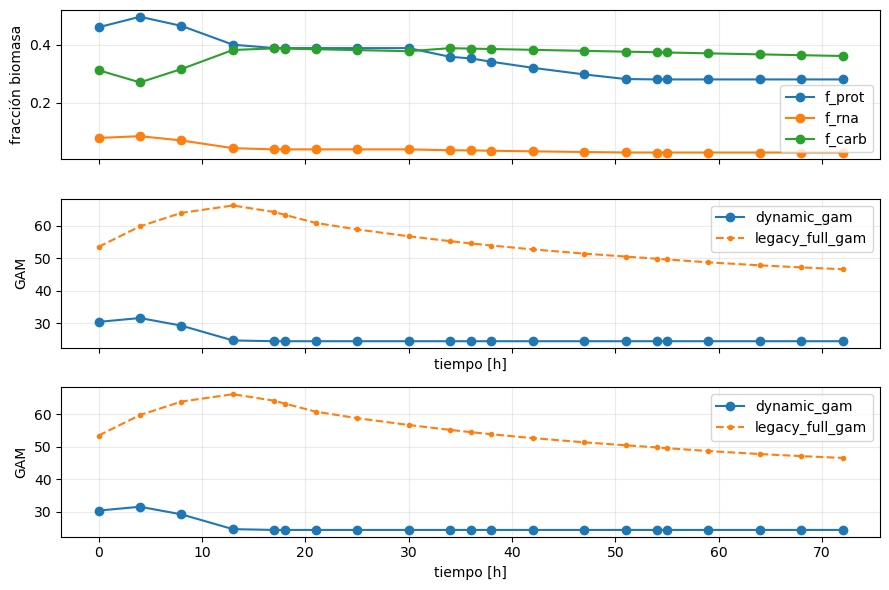

- t=0.0: clamps/correcciones aplicadas en composición; f_carb: clamp 0.3409 -> 0.3118
- t=4.0: clamps/correcciones aplicadas en composición; f_prot observado: clamp 0.736282 -> 0.52; f_carb: clamp 0.316932 -> 0.26968
- t=8.0: clamps/correcciones aplicadas en composición; f_prot observado: clamp 0.861709 -> 0.52; f_carb: clamp 0.337867 -> 0.315673
- t=13.0: clamps/correcciones aplicadas en composición; f_prot observado: clamp 0.923339 -> 0.52
- t=17.0: clamps/correcciones aplicadas en composición; f_prot observado: clamp 0.868892 -> 0.52; gam_multiplier clamp 0.781312 -> 0.8
- t=18.0: clamps/correcciones aplicadas en composición; f_prot observado: clamp 0.845429 -> 0.52; gam_multiplier clamp 0.781044 -> 0.8
- t=21.0: clamps/correcciones aplicadas en composición; f_prot observado: clamp 0.777909 -> 0.52; gam_multiplier clamp 0.780243 -> 0.8
- t=25.0: clamps/correcciones aplicadas en composición; f_prot observado: clamp 0.695005 -> 0.52; gam_multiplier clamp 0.779185 -> 0.8
- t=30.0: clam

C:\Users\ctorrealba\AppData\Local\Temp\ipykernel_26856\3808596909.py:232: RuntimeWarning: Auditoría Fase 3 con observaciones; revisar notas y clamps.
  warnings.warn("Auditoría Fase 3 con observaciones; revisar notas y clamps.", RuntimeWarning)


In [16]:
phase3_abs_tol = 1e-6
phase3_closure_tol = float(BIOMASS_COMPOSITION_DEFAULTS["closure_tolerance"])
phase3_allowed_phases = set(PHASE_CLASSIFIER_DEFAULTS["canonical_phases"])

phase3_trajectory_available = (
    "states_df_phase" in globals()
    and states_df_phase is not None
    and len(states_df_phase) > 0
    and "t_h" in states_df_phase.columns
)

if phase3_trajectory_available:
    phase3_t_values = np.asarray(states_df_phase["t_h"].to_numpy(dtype=float), dtype=float)
    phase3_t_values = np.unique(phase3_t_values[np.isfinite(phase3_t_values)])
    if len(phase3_t_values) == 0:
        phase3_trajectory_available = False
        phase3_audit_times = [0.0]
    else:
        phase3_representative_idx = {
            0,
            int(round(0.05 * (len(phase3_t_values) - 1))),
            int(round(0.25 * (len(phase3_t_values) - 1))),
            int(round(0.50 * (len(phase3_t_values) - 1))),
            int(round(0.75 * (len(phase3_t_values) - 1))),
            len(phase3_t_values) - 1,
        }
        phase3_mesh_idx = set(np.linspace(0, len(phase3_t_values) - 1, min(18, len(phase3_t_values))).round().astype(int))
        phase3_idx = sorted(phase3_representative_idx | phase3_mesh_idx)
        phase3_audit_times = [float(phase3_t_values[i]) for i in phase3_idx]
else:
    phase3_audit_times = [0.0]

phase3_rows = []
phase3_failures = []
phase3_warnings = []
phase3_prev_state = None
phase3_prev_phase = None

if not phase3_trajectory_available:
    phase3_warnings.append({"time": 0.0, "notes": ["states_df_phase no disponible; auditoría limitada al snapshot inicial."]})

for t_probe in phase3_audit_times:
    if phase3_trajectory_available:
        snap = build_mechanistic_snapshot_model(
            t_probe,
            solve=True,
            exact_time=False,
            prev_state=phase3_prev_state,
            prev_phase=phase3_prev_phase,
        )
    else:
        snap = build_mechanistic_initial_snapshot_model(
            solve=True,
            prev_state=phase3_prev_state,
            prev_phase=phase3_prev_phase,
        )

    sol = snap.get("solution")
    solver_status = getattr(sol, "status", None)
    try:
        objective_value = float(sol.objective_value)
    except (AttributeError, TypeError, ValueError):
        objective_value = np.nan

    comp = snap.get("biomass_composition", {}) or {}
    gam_details = snap.get("dynamic_gam_details", {}) or {}
    gam_components = gam_details.get("gam_components", {}) or {}
    indicators = snap.get("phase_indicators", {}) or {}

    fractions = {
        "f_prot": _phase3_safe_float(comp.get("f_prot"), default=np.nan),
        "f_rna": _phase3_safe_float(comp.get("f_rna"), default=np.nan),
        "f_carb": _phase3_safe_float(comp.get("f_carb"), default=np.nan),
        "f_const": _phase3_safe_float(comp.get("f_const"), default=np.nan),
        "f_other": _phase3_safe_float(comp.get("f_other"), default=np.nan),
    }
    closure_error = _phase3_safe_float(comp.get("closure_error"), default=np.nan)
    dynamic_gam = _phase3_safe_float(snap.get("dynamic_gam"), default=np.nan)
    legacy_full_gam = _phase3_safe_float(snap.get("legacy_full_gam"), default=np.nan)
    dynamic_gam_multiplier = _phase3_safe_float(snap.get("dynamic_gam_multiplier"), default=np.nan)

    row_issues = []
    row_notes = []
    if snap.get("phase_label") not in phase3_allowed_phases:
        row_issues.append(f"fase no canónica: {snap.get('phase_label')}")
    if any((not np.isfinite(v)) for v in fractions.values()):
        row_issues.append("hay fracciones no finitas")
    if any(v < -phase3_abs_tol for v in fractions.values() if np.isfinite(v)):
        row_issues.append("hay fracciones negativas")
    if not np.isfinite(closure_error) or closure_error > max(phase3_closure_tol, phase3_abs_tol):
        row_issues.append(f"cierre de composición inválido: {closure_error}")
    if not bool(snap.get("biomass_composition_valid")):
        row_issues.append("biomass_composition_valid=False")
    if not np.isfinite(dynamic_gam) or dynamic_gam <= 0:
        row_issues.append(f"dynamic_gam inválido: {dynamic_gam}")
    if not bool(snap.get("dynamic_gam_valid")):
        row_issues.append("dynamic_gam_valid=False")
    if solver_status != "optimal":
        row_issues.append(f"solver_status={solver_status}")
    if snap.get("gam_application_status") != "applied_dynamic_gam":
        row_issues.append(f"gam_application_status={snap.get('gam_application_status')}")

    if comp.get("clamps_applied"):
        row_notes.append("clamps/correcciones aplicadas en composición")
    if comp.get("composition_notes"):
        row_notes.extend(str(note) for note in comp.get("composition_notes", []))
    if gam_details.get("gam_notes"):
        row_notes.extend(str(note) for note in gam_details.get("gam_notes", []))

    p_min = float(BIOMASS_COMPOSITION_DEFAULTS["protein_min"]) - phase3_abs_tol
    p_max = float(BIOMASS_COMPOSITION_DEFAULTS["protein_max"]) + phase3_abs_tol
    c_min = 0.0 - phase3_abs_tol
    c_max = float(BIOMASS_COMPOSITION_DEFAULTS["carb_max"]) + phase3_abs_tol
    if not (p_min <= fractions["f_prot"] <= p_max):
        row_issues.append(f"f_prot fuera de rango: {fractions['f_prot']}")
    if not (c_min <= fractions["f_carb"] <= c_max):
        row_issues.append(f"f_carb fuera de rango: {fractions['f_carb']}")

    if row_issues:
        diagnostic = "FAIL"
        phase3_failures.append({"time": snap.get("actual_t_h", t_probe), "issues": row_issues})
    elif row_notes:
        diagnostic = "WARNING"
        phase3_warnings.append({"time": snap.get("actual_t_h", t_probe), "notes": row_notes})
    else:
        diagnostic = "PASS"

    phase3_rows.append({
        "time": float(snap.get("actual_t_h", t_probe)),
        "phase_label": snap.get("phase_label"),
        "n_free": indicators.get("n_free"),
        "n_total": indicators.get("n_total"),
        "n_signal": comp.get("n_signal"),
        "f_prot": fractions["f_prot"],
        "f_rna": fractions["f_rna"],
        "f_carb": fractions["f_carb"],
        "f_const": fractions["f_const"],
        "f_other": fractions["f_other"],
        "closure_error": closure_error,
        "composition_valid": snap.get("biomass_composition_valid"),
        "composition_clamps_applied": comp.get("clamps_applied"),
        "dynamic_gam": dynamic_gam,
        "legacy_full_gam": legacy_full_gam,
        "dynamic_gam_delta_vs_legacy": dynamic_gam - legacy_full_gam if np.isfinite(dynamic_gam) and np.isfinite(legacy_full_gam) else np.nan,
        "dynamic_gam_multiplier": dynamic_gam_multiplier,
        "protein_factor": gam_components.get("protein_factor"),
        "rna_factor": gam_components.get("rna_factor"),
        "carb_factor": gam_components.get("carb_factor"),
        "dynamic_gam_valid": snap.get("dynamic_gam_valid"),
        "gam_application_status": snap.get("gam_application_status"),
        "solver_status": solver_status,
        "objective_value": objective_value,
        "diagnostic": diagnostic,
        "diagnostic_notes": "; ".join(row_notes + row_issues),
    })

    phase3_prev_state = snap.get("state")
    phase3_prev_phase = snap.get("phase_label")

mechanistic_phase3_audit_df = pd.DataFrame(phase3_rows)
display(mechanistic_phase3_audit_df)

finite_response = mechanistic_phase3_audit_df[["n_total", "f_prot", "f_rna", "dynamic_gam"]].apply(pd.to_numeric, errors="coerce")
response_notes = []
if finite_response["n_total"].notna().sum() >= 4 and finite_response["n_total"].max() > finite_response["n_total"].min():
    n_values = finite_response["n_total"].to_numpy(dtype=float)
    p_values = finite_response["f_prot"].to_numpy(dtype=float)
    mask = np.isfinite(n_values) & np.isfinite(p_values)
    if mask.sum() >= 4 and np.nanstd(n_values[mask]) > 0 and np.nanstd(p_values[mask]) > 0:
        n_p_corr = float(np.corrcoef(n_values[mask], p_values[mask])[0, 1])
        response_notes.append(f"correlación n_total vs f_prot = {n_p_corr:.3f}")
        q_low = np.nanquantile(n_values[mask], 0.25)
        q_high = np.nanquantile(n_values[mask], 0.75)
        low_p = float(np.nanmean(p_values[mask & (n_values <= q_low)]))
        high_p = float(np.nanmean(p_values[mask & (n_values >= q_high)]))
        response_notes.append(f"f_prot bajo N={low_p:.4f}; alto N={high_p:.4f}")
        if low_p > high_p + 0.03:
            phase3_warnings.append({
                "time": np.nan,
                "notes": ["f_prot promedio bajo N supera al de alto N; revisar peso de observaciones o umbrales"],
            })
    else:
        response_notes.append("no hay variación suficiente para correlación n_total vs f_prot")
else:
    response_notes.append("n_total insuficiente para evaluar respuesta cualitativa de composición")

print("Diagnóstico de respuesta composición/GAM:")
for note in response_notes:
    print(f"- {note}")

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(mechanistic_phase3_audit_df["time"], mechanistic_phase3_audit_df["f_prot"], marker="o", label="f_prot")
    axes[0].plot(mechanistic_phase3_audit_df["time"], mechanistic_phase3_audit_df["f_rna"], marker="o", label="f_rna")
    axes[0].plot(mechanistic_phase3_audit_df["time"], mechanistic_phase3_audit_df["f_carb"], marker="o", label="f_carb")
    axes[0].set_ylabel("fracción biomasa")
    axes[0].legend(loc="best")
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(mechanistic_phase3_audit_df["time"], mechanistic_phase3_audit_df["dynamic_gam"], marker="o", label="dynamic_gam")
    axes[1].plot(mechanistic_phase3_audit_df["time"], mechanistic_phase3_audit_df["legacy_full_gam"], marker=".", linestyle="--", label="legacy_full_gam")
    axes[1].set_xlabel("tiempo [h]")
    axes[1].set_ylabel("GAM")
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.25)

    axes[2].plot(mechanistic_phase3_audit_df["time"], mechanistic_phase3_audit_df["dynamic_gam"], marker="o", label="dynamic_gam")
    axes[2].plot(mechanistic_phase3_audit_df["time"], mechanistic_phase3_audit_df["legacy_full_gam"], marker=".", linestyle="--", label="legacy_full_gam")
    axes[2].set_xlabel("tiempo [h]")
    axes[2].set_ylabel("GAM")
    axes[2].legend(loc="best")
    axes[2].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[WARN] No se pudo generar gráfico matplotlib: {exc}")

if phase3_failures:
    print("FAIL: biomasa variable/GAM dinámico presentan inconsistencias graves.")
    for failure in phase3_failures:
        print(f"- t={failure['time']}: " + "; ".join(failure["issues"]))
    warnings.warn("Auditoría Fase 3 falló; revisar `mechanistic_phase3_audit_df`.", RuntimeWarning)
elif phase3_warnings:
    print("WARNING: módulo Fase 3 estable pero con observaciones auditables.")
    for warning in phase3_warnings[:12]:
        print(f"- t={warning['time']}: " + "; ".join(warning["notes"][:4]))
    if len(phase3_warnings) > 12:
        print(f"- ... {len(phase3_warnings) - 12} observaciones adicionales en diagnostic_notes")
    warnings.warn("Auditoría Fase 3 con observaciones; revisar notas y clamps.", RuntimeWarning)
else:
    print("PASS: composición dinámica y GAM dinámico son coherentes, finitos y compatibles con la resolución de snapshots.")


### Interpretación esperada de la Fase 3

La Fase 3 convirtió la biomasa variable y el GAM dinámico en un módulo propio. La arquitectura ahora separa tres pasos: cálculo de composición de biomasa, cálculo de GAM dependiente de composición y aplicación del GAM al snapshot mecanístico.

Respecto de Fase 2, el clasificador de fase se conserva y pasa a alimentar el módulo de biomasa/GAM. El wrapper mecanístico sigue usando el snapshot base y el objetivo legacy, pero ahora registra `biomass_composition`, `dynamic_gam`, multiplicador, notas, validez y estado de aplicación del GAM.

La evidencia de funcionamiento queda en `mechanistic_phase3_audit_df`: la composición debe cerrar cerca de 1, las fracciones deben mantenerse en rangos configurados, el GAM debe ser finito y positivo, y el solver debe seguir entregando soluciones óptimas. Las notas diagnósticas permiten distinguir clamps esperados de fallos reales.

Las limitaciones restantes son deliberadas: la biomasa dinámica todavía no cambia directamente la reacción de biomasa como una formulación estequiométrica completa, no hay turnover proteico refinado, no hay NCR refinada, y no se activan objetivos lexicográficos ni módulos redox/aromas/ésteres.

En Fase 4 se espera introducir turnover proteico explícito y acoplarlo a esta composición dinámica, de modo que proteína, mantenimiento y disponibilidad de nitrógeno empiecen a interactuar con restricciones y objetivos por fase de forma más mecanística.


### Fase 4 - Turnover proteico explícito y pool reciclable

La Fase 4 convierte el turnover proteico en un módulo explícito, separado del switching legacy `TURNOVER_ATPM`. El objetivo es que la degradación/renovación proteica deje de ser solo un modo terminal y pase a ser una fuente interna auditable de nitrógeno y aminoácidos reciclables.

El turnover se relaciona con stationary, decay e inanición de nitrógeno porque, cuando cae la disponibilidad externa de N y la célula mantiene biomasa activa, el reciclaje proteico puede sostener mantenimiento, remodelación y pools de aminoácidos. Por eso su activación debe depender de fase fisiológica, señal de starvation, biomasa activa y fracción proteica calculada en Fase 3.

El pool reciclable generado representa una oferta interna efectiva. En esta fase se conecta al snapshot de forma conservadora usando los precursores de aminoácidos ya detectados en `_found_precursors` y la distribución `AA_ALPHA` si existe. No se crean nuevos objetivos LP ni se implementa NCR refinada; se expande explícitamente la capacidad de uso de precursores reciclados en los bounds del snapshot.

Al auditar esperamos ver turnover bajo en fases tempranas, aumento gradual en limitación de N/stationary/decay, pool reciclable no negativo y consistente con el flujo de turnover, y snapshots que sigan resolviendo. Se mantiene conservado el kernel Zenteno, la clasificación de Fase 2, biomasa/GAM de Fase 3 y la estrategia de resolución legacy.


In [17]:
PHASE4_TURNOVER_VERSION = "phase4_explicit_protein_turnover_v2_internal_macro_audited"

if "_call_with_supported_kwargs" not in globals():
    import inspect

    def _call_with_supported_kwargs(func, *args, **kwargs):
        try:
            signature = inspect.signature(func)
            params = signature.parameters
            if not any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values()):
                kwargs = {key: value for key, value in kwargs.items() if key in params}
        except (TypeError, ValueError):
            pass
        return func(*args, **kwargs)

if "_PHASE3_BUILD_MECHANISTIC_SNAPSHOT_MODEL" not in globals():
    _PHASE3_BUILD_MECHANISTIC_SNAPSHOT_MODEL = build_mechanistic_snapshot_model
if "_PHASE3_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL" not in globals():
    _PHASE3_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL = build_mechanistic_initial_snapshot_model

PROTEIN_TURNOVER_DEFAULTS = {
    "parameterization_note": "v1: priors operacionales para activar turnover proteico explícito sin reemplazar el kernel Zenteno",
    "basal_turnover_rate_h_inv": 0.001,
    "max_turnover_rate_h_inv": float(globals().get("TURNOVER_LAMBDA", 0.03)),
    "activation_floor_for_flux": 0.01,
    "n_activation_gN_L": float(BIOMASS_COMPOSITION_DEFAULTS.get("n_depleted_gN_L", 0.02)) if "BIOMASS_COMPOSITION_DEFAULTS" in globals() else 0.02,
    "n_saturation_gN_L": float(BIOMASS_COMPOSITION_DEFAULTS.get("n_saturation_gN_L", 0.10)) if "BIOMASS_COMPOSITION_DEFAULTS" in globals() else 0.10,
    "nitrogen_starvation_power": 1.3,
    "phase_component": {
        "F0_LAG_OSMO": 0.00,
        "F1_EXP_GROWTH": 0.08,
        "F2_N_LIMITED_CARB_ACC": 0.55,
        "F3_STATIONARY": 0.85,
        "F4_DECAY": 1.00,
    },
    "active_biomass_half_saturation_gDW_L": 0.20,
    "min_active_biomass_gDW_L": 1e-6,
    "protein_fraction_ref": float(BIOMASS_COMPOSITION_DEFAULTS.get("protein_ref", 0.46)) if "BIOMASS_COMPOSITION_DEFAULTS" in globals() else 0.46,
    "protein_component_min": 0.0,
    "protein_component_max": 1.2,
    "activation_weights": {
        "nitrogen_starvation": 0.65,
        "phase": 0.35,
    },
    "protein_n_fraction_gN_gProt": 0.16,
    "recycle_efficiency": 0.80,
    "bound_application_scale": 1.0,
    "max_bound_expansion_mmol_gDW_h": 5.0,
    "use_found_precursors": True,
    "fallback_to_aggregate_n_pool": True,
    "mode": "internal_or_macro_audited",
    "debit_cProt": True,
    "allow_external_aa_exchange_from_turnover": False,
    "regularized_allow_external_aa_exchange_from_turnover": False,
    "min_protein_depletion_time_h": 24.0,
    "cProt_eps": 1e-12,
    "epsilon": 1e-12,
}


def _phase4_safe_float(value, default=np.nan):
    """Convierte un escalar a float finito y devuelve `default` si falla."""
    try:
        if value is None:
            return default
        out = float(value)
        return out if np.isfinite(out) else default
    except (TypeError, ValueError):
        return default


def _phase4_get_value(obj, keys, default=np.nan):
    """Extrae el primer valor disponible desde dict/Series/objetos con `.get`."""
    if obj is None:
        return default
    if isinstance(keys, str):
        keys = [keys]
    for key in keys:
        try:
            if isinstance(obj, dict) and key in obj:
                return obj[key]
            if hasattr(obj, "get"):
                value = obj.get(key, None)
                if value is not None:
                    return value
        except Exception:
            continue
    return default


def _phase4_merge_turnover_params(params=None):
    """Combina defaults de turnover con overrides auditables."""
    cfg = dict(PROTEIN_TURNOVER_DEFAULTS)
    cfg["phase_component"] = dict(PROTEIN_TURNOVER_DEFAULTS["phase_component"])
    cfg["activation_weights"] = dict(PROTEIN_TURNOVER_DEFAULTS["activation_weights"])
    if params:
        for key, value in dict(params).items():
            if key in {"phase_component", "activation_weights"}:
                merged = dict(cfg[key])
                merged.update(dict(value))
                cfg[key] = merged
            else:
                cfg[key] = value
    cfg["max_turnover_rate_h_inv"] = max(float(cfg["max_turnover_rate_h_inv"]), float(cfg["basal_turnover_rate_h_inv"]))
    return cfg


def _phase4_turnover_policy_context(config=None, params=None):
    """Resuelve política efectiva de turnover sin abrir fuentes externas en strict/diagnostic."""
    raw_mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    mode = _normalize_modeling_config_mode(raw_mode) if "_normalize_modeling_config_mode" in globals() else raw_mode
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=mode,
    )
    mode = modeling_config.get("mode", "strict")
    turnover_policy = dict(modeling_config.get("turnover_policy", {}) or {})
    nitrogen_policy = dict(modeling_config.get("nitrogen_policy", {}) or {})
    cfg = _phase4_merge_turnover_params(params)
    cfg.update({k: v for k, v in turnover_policy.items() if k in cfg})
    turnover_mode = str(turnover_policy.get("mode", cfg.get("mode", "internal_or_macro_audited")))
    debit_cProt = bool(turnover_policy.get("debit_cProt", cfg.get("debit_cProt", True)))
    allow_external = bool(turnover_policy.get(
        "allow_external_aa_exchange_from_turnover",
        cfg.get("allow_external_aa_exchange_from_turnover", False),
    ))
    turnover_may_open_external = bool(nitrogen_policy.get("turnover_may_open_external_exchanges", False))
    if mode in ("strict", "diagnostic"):
        allow_external = False
        turnover_may_open_external = False
    elif mode == "regularized":
        allow_external = bool(
            allow_external
            and turnover_may_open_external
            and turnover_policy.get(
                "regularized_allow_external_aa_exchange_from_turnover",
                cfg.get("regularized_allow_external_aa_exchange_from_turnover", False),
            )
        )
    return {
        "modeling_config": modeling_config,
        "mode": mode,
        "turnover_policy": turnover_policy,
        "nitrogen_policy": nitrogen_policy,
        "turnover_mode": turnover_mode,
        "debit_cProt": debit_cProt,
        "allow_external_aa_exchange_from_turnover": allow_external,
        "turnover_may_open_external": turnover_may_open_external,
        "min_protein_depletion_time_h": max(
            _phase4_safe_float(turnover_policy.get("min_protein_depletion_time_h", cfg.get("min_protein_depletion_time_h", 24.0)), default=24.0),
            _phase4_safe_float(cfg.get("epsilon"), default=1e-12),
        ),
        "cProt_eps": max(
            _phase4_safe_float(turnover_policy.get("cProt_eps", cfg.get("cProt_eps", 1e-12)), default=1e-12),
            0.0,
        ),
        "cfg": cfg,
    }


def _phase4_clip(value, low, high, notes, label):
    """Clampea y registra ajustes numéricos relevantes."""
    value = _phase4_safe_float(value)
    if not np.isfinite(value):
        notes.append(f"{label}: valor no finito; se usa {low}")
        return float(low), True
    clipped = min(max(value, float(low)), float(high))
    was_clipped = abs(clipped - value) > 1e-12
    if was_clipped:
        notes.append(f"{label}: clamp {value:.6g} -> {clipped:.6g}")
    return float(clipped), was_clipped


def compute_turnover_activation(state, phase_label=None, indicators=None, biomass_composition=None, params=None):
    """Calcula la señal explícita de activación del turnover proteico.

    Parameters
    ----------
    state : dict-like or pandas.Series
        Estado macroscópico del snapshot.
    phase_label : str, optional
        Fase fisiológica explícita (`F0` a `F4`).
    indicators : dict, optional
        Indicadores calculados en Fase 2.
    biomass_composition : dict, optional
        Composición dinámica calculada en Fase 3.
    params : dict, optional
        Overrides de `PROTEIN_TURNOVER_DEFAULTS`.

    Returns
    -------
    dict
        Componentes de activación, `turnover_activation`, validez y notas.

    Notes
    -----
    La activación combina starvation de N, fase fisiológica, biomasa activa y
    contenido proteico. Los parámetros son priors operacionales: deben calibrarse
    con datos de proteólisis, viabilidad o pools de aminoácidos si están
    disponibles.
    """
    cfg = _phase4_merge_turnover_params(params)
    indicators = {} if indicators is None else dict(indicators)
    comp = {} if biomass_composition is None else dict(biomass_composition)
    notes = []

    n_total = _phase4_safe_float(indicators.get("n_total", _phase4_get_value(state, ["cN_total", "N_gN_L"])), default=np.nan)
    if not np.isfinite(n_total):
        n_free = _phase4_safe_float(indicators.get("n_free", _phase4_get_value(state, ["cN_free", "N_free_gN_L"])), default=np.nan)
        n_total = n_free
        notes.append("n_total no disponible; se usa n_free como proxy")

    n_low = float(cfg["n_activation_gN_L"])
    n_high = max(float(cfg["n_saturation_gN_L"]), n_low + float(cfg["epsilon"]))
    if np.isfinite(n_total):
        n_starvation = 1.0 - (n_total - n_low) / max(n_high - n_low, float(cfg["epsilon"]))
        n_starvation = min(max(n_starvation, 0.0), 1.0)
        n_starvation = n_starvation ** float(cfg["nitrogen_starvation_power"])
    else:
        n_starvation = 0.0
        notes.append("n_total/n_free no finitos; componente de starvation se fija en 0")

    phase_component = float(dict(cfg["phase_component"]).get(phase_label, 0.0))
    if phase_label not in dict(cfg["phase_component"]):
        notes.append(f"fase sin componente explícito de turnover: {phase_label}")

    x_active = _phase4_safe_float(
        indicators.get("x_active", _phase4_get_value(state, ["x_active", "X_active_gDW_L", "cX", "X_gDW_L"])),
        default=np.nan,
    )
    if not np.isfinite(x_active):
        x_active = _phase4_safe_float(_phase4_get_value(state, ["cX", "X_gDW_L"]), default=0.0)
        notes.append("x_active no disponible; se usa biomasa total como proxy")
    if x_active <= float(cfg["min_active_biomass_gDW_L"]):
        active_component = 0.0
        notes.append("biomasa activa insuficiente para turnover")
    else:
        active_component = x_active / (x_active + float(cfg["active_biomass_half_saturation_gDW_L"]) + float(cfg["epsilon"]))
        active_component = min(max(active_component, 0.0), 1.0)

    f_prot = _phase4_safe_float(comp.get("f_prot", np.nan), default=np.nan)
    if not np.isfinite(f_prot):
        f_prot = _phase4_safe_float(_phase4_get_value(state, ["f_prot", "P_frac_gProt_gDW"]), default=np.nan)
    if not np.isfinite(f_prot):
        f_prot = float(cfg["protein_fraction_ref"])
        notes.append("f_prot no disponible; se usa protein_fraction_ref")
    protein_component, protein_clipped = _phase4_clip(
        f_prot / max(float(cfg["protein_fraction_ref"]), float(cfg["epsilon"])),
        cfg["protein_component_min"],
        cfg["protein_component_max"],
        notes,
        "protein_content_component",
    )

    weights = dict(cfg["activation_weights"])
    driver = (
        float(weights.get("nitrogen_starvation", 0.65)) * n_starvation
        + float(weights.get("phase", 0.35)) * phase_component
    )
    activation_raw = driver * active_component * protein_component
    activation, activation_clipped = _phase4_clip(activation_raw, 0.0, 1.0, notes, "turnover_activation")
    activation_valid = bool(np.isfinite(activation) and activation >= 0.0)

    return {
        "turnover_activation": float(activation),
        "nitrogen_starvation_component": float(n_starvation),
        "phase_component": float(phase_component),
        "active_biomass_component": float(active_component),
        "protein_content_component": float(protein_component),
        "activation_driver": float(driver),
        "x_active_used": float(x_active) if np.isfinite(x_active) else np.nan,
        "f_prot_used": float(f_prot) if np.isfinite(f_prot) else np.nan,
        "n_total_used": float(n_total) if np.isfinite(n_total) else np.nan,
        "activation_valid": activation_valid,
        "activation_notes": notes,
        "activation_clamps_applied": bool(protein_clipped or activation_clipped),
        "parameters_used": {
            "n_activation_gN_L": cfg["n_activation_gN_L"],
            "n_saturation_gN_L": cfg["n_saturation_gN_L"],
            "nitrogen_starvation_power": cfg["nitrogen_starvation_power"],
            "phase_component": phase_component,
            "active_biomass_half_saturation_gDW_L": cfg["active_biomass_half_saturation_gDW_L"],
            "protein_fraction_ref": cfg["protein_fraction_ref"],
        },
    }



def compute_turnover_flux(state, activation, biomass_composition=None, params=None, config=None):
    """Traduce activación de turnover a flujo proteico interno limitado por cProt."""
    ctx = _phase4_turnover_policy_context(config=config, params=params)
    cfg = ctx["cfg"]
    activation = {} if activation is None else dict(activation)
    comp = {} if biomass_composition is None else dict(biomass_composition)
    state = {} if state is None else dict(state)
    notes = []

    act = _phase4_safe_float(activation.get("turnover_activation"), default=0.0)
    act, act_clipped = _phase4_clip(act, 0.0, 1.0, notes, "turnover_activation_for_flux")

    basal = float(cfg["basal_turnover_rate_h_inv"])
    max_rate = float(cfg["max_turnover_rate_h_inv"])
    if act < float(cfg["activation_floor_for_flux"]):
        turnover_rate = 0.0
        notes.append("activación bajo floor; turnover_flux se fija en 0")
    else:
        turnover_rate = basal + act * (max_rate - basal)

    f_prot = _phase4_safe_float(comp.get("f_prot"), default=activation.get("f_prot_used", np.nan))
    if not np.isfinite(f_prot):
        f_prot = _phase4_safe_float(_phase4_get_value(state, ["f_prot", "P_frac_gProt_gDW"]), default=np.nan)
    if not np.isfinite(f_prot):
        f_prot = float(cfg["protein_fraction_ref"])
        notes.append("f_prot no disponible para flujo; se usa protein_fraction_ref")
    x_active = _phase4_safe_float(activation.get("x_active_used"), default=np.nan)
    if not np.isfinite(x_active):
        x_active = _phase4_safe_float(_phase4_get_value(state, ["cX", "X_gDW_L"]), default=0.0)
        notes.append("x_active no disponible para flujo; se usa biomasa total como proxy")

    cProt = max(0.0, _phase4_safe_float(_phase4_get_value(state, ["cProt", "Prot_g_L"]), default=0.0))
    cProt_eps = float(ctx["cProt_eps"])
    tau_min = float(ctx["min_protein_depletion_time_h"])
    protein_pool_specific = max(0.0, f_prot)
    protein_pool_volumetric = max(0.0, x_active) * protein_pool_specific
    turnover_flux_candidate = turnover_rate * protein_pool_specific
    turnover_flux_volumetric_candidate = turnover_rate * protein_pool_volumetric

    max_flux_specific = max_rate * max(float(cfg["protein_component_max"]) * float(cfg["protein_fraction_ref"]), f_prot)
    turnover_flux_candidate, flux_clipped = _phase4_clip(
        turnover_flux_candidate,
        0.0,
        max_flux_specific,
        notes,
        "turnover_flux_candidate_specific",
    )

    if cProt <= cProt_eps:
        cProt_limited_flux_specific = 0.0
        turnover_flux_effective = 0.0
        cProt_limiting = bool(turnover_flux_candidate > 0.0)
        notes.append("No protein pool available for turnover")
    else:
        cProt_specific_available = cProt / max(float(x_active), float(cfg["epsilon"]))
        cProt_limited_flux_specific = cProt_specific_available / tau_min
        turnover_flux_effective = min(turnover_flux_candidate, cProt_limited_flux_specific)
        cProt_limiting = bool(turnover_flux_effective < turnover_flux_candidate - 1e-12)
        if cProt_limiting:
            notes.append(f"turnover limitado por cProt/tau_min: {turnover_flux_candidate:.6g} -> {turnover_flux_effective:.6g}")

    turnover_flux_volumetric_effective = turnover_flux_effective * max(0.0, x_active)
    dcProt_dt_from_turnover = -turnover_flux_volumetric_effective if bool(ctx["debit_cProt"]) else 0.0
    turnover_valid = bool(
        np.isfinite(turnover_flux_effective)
        and turnover_flux_effective >= 0.0
        and np.isfinite(turnover_rate)
        and turnover_rate >= 0.0
        and turnover_flux_volumetric_effective <= cProt / max(tau_min, float(cfg["epsilon"])) + 1e-12
    )

    return {
        "turnover_flux": float(turnover_flux_effective),
        "turnover_flux_specific_gProt_gDW_h": float(turnover_flux_effective),
        "turnover_flux_volumetric_gProt_L_h": float(turnover_flux_volumetric_effective),
        "turnover_flux_candidate": float(turnover_flux_candidate),
        "turnover_flux_candidate_gProt_gDW_h": float(turnover_flux_candidate),
        "turnover_flux_volumetric_candidate_gProt_L_h": float(turnover_flux_volumetric_candidate),
        "turnover_flux_effective": float(turnover_flux_effective),
        "turnover_flux_effective_gProt_gDW_h": float(turnover_flux_effective),
        "turnover_rate": float(turnover_rate),
        "cProt_available": float(cProt),
        "cProt_eps": float(cProt_eps),
        "cProt_limiting": bool(cProt_limiting),
        "cProt_limited_flux_specific_gProt_gDW_h": float(cProt_limited_flux_specific),
        "min_protein_depletion_time_h": float(tau_min),
        "dcProt_dt_from_turnover": float(dcProt_dt_from_turnover),
        "turnover_debits_cProt": bool(ctx["debit_cProt"]),
        "turnover_mode": ctx["turnover_mode"],
        "turnover_basis": {
            "basis": "min(turnover_rate_h_inv * f_prot_gProt_gDW, cProt_g_L / X_gDW_L / tau_min_h)",
            "activation": float(act),
            "x_active_gDW_L": float(x_active),
            "f_prot_gProt_gDW": float(f_prot),
            "protein_pool_specific_gProt_gDW": float(protein_pool_specific),
            "protein_pool_volumetric_gProt_L": float(protein_pool_volumetric),
            "cProt_g_L": float(cProt),
            "basal_turnover_rate_h_inv": basal,
            "max_turnover_rate_h_inv": max_rate,
        },
        "turnover_valid": turnover_valid,
        "turnover_notes": notes,
        "turnover_clamps_applied": bool(act_clipped or flux_clipped or cProt_limiting),
    }

def distribute_turnover_recycled_pool(turnover_flux, params=None):
    """Distribuye el turnover proteico hacia N y aminoácidos reciclables.

    Si `_found_precursors` y `AA_ALPHA` están disponibles, el pool se reparte en
    los precursores detectados. Si no, se conserva como pool agregado de N
    reciclable para fases posteriores.
    """
    cfg = _phase4_merge_turnover_params(params)
    notes = []
    turnover_flux = {} if turnover_flux is None else dict(turnover_flux)
    flux_specific = _phase4_safe_float(turnover_flux.get("turnover_flux"), default=0.0)
    if flux_specific < 0:
        notes.append("turnover_flux negativo; se clampa a 0 para distribución")
        flux_specific = 0.0

    recycled_n_total = flux_specific * float(cfg["protein_n_fraction_gN_gProt"]) * float(cfg["recycle_efficiency"])
    recycled_n_mmol = recycled_n_total / max(float(globals().get("MW_N", 0.014007)), float(cfg["epsilon"]))

    found = dict(globals().get("_found_precursors", {})) if bool(cfg.get("use_found_precursors", True)) else {}
    aa_alpha_raw = dict(globals().get("AA_ALPHA", {}))
    aa_distribution = {}
    recycled_aa_pool = {}
    structures_used = []

    if found:
        structures_used.append("_found_precursors")
        weights = {}
        for aa_key in found:
            weights[aa_key] = _phase4_safe_float(aa_alpha_raw.get(aa_key, np.nan), default=np.nan)
        if not all(np.isfinite(v) and v > 0 for v in weights.values()):
            weights = {aa_key: 1.0 for aa_key in found}
            notes.append("AA_ALPHA incompleto/no positivo; se usa distribución uniforme")
        else:
            structures_used.append("AA_ALPHA")
        total_w = sum(weights.values())
        for aa_key, rid in found.items():
            frac = weights[aa_key] / max(total_w, float(cfg["epsilon"]))
            aa_distribution[aa_key] = {
                "reaction_id": rid,
                "fraction": float(frac),
            }
            recycled_aa_pool[aa_key] = {
                "reaction_id": rid,
                "recycled_flux_model_units": float(recycled_n_mmol * frac),
                "recycled_n_gN_gDW_h": float(recycled_n_total * frac),
            }
    else:
        notes.append("no hay _found_precursors disponibles; se conserva pool agregado de N reciclable")
        structures_used.append("aggregate_recycled_n_pool")

    distribution_valid = bool(
        np.isfinite(recycled_n_total)
        and recycled_n_total >= 0.0
        and (bool(recycled_aa_pool) or bool(cfg.get("fallback_to_aggregate_n_pool", True)))
    )
    return {
        "recycled_n_total": float(recycled_n_total),
        "recycled_n_total_gN_gDW_h": float(recycled_n_total),
        "recycled_n_total_mmol_gDW_h": float(recycled_n_mmol),
        "recycled_aa_pool": recycled_aa_pool,
        "aa_distribution": aa_distribution,
        "distribution_valid": distribution_valid,
        "distribution_notes": notes,
        "structures_used": structures_used,
        "protein_n_fraction_gN_gProt": float(cfg["protein_n_fraction_gN_gProt"]),
        "recycle_efficiency": float(cfg["recycle_efficiency"]),
    }



def compute_protein_turnover_module(
    state,
    phase_label=None,
    indicators=None,
    biomass_composition=None,
    params=None,
    config=None,
):
    """Ejecuta turnover proteico como reciclaje interno o pool macro-auditado."""
    ctx = _phase4_turnover_policy_context(config=config, params=params)
    activation = compute_turnover_activation(
        state,
        phase_label=phase_label,
        indicators=indicators,
        biomass_composition=biomass_composition,
        params=params,
    )
    flux = compute_turnover_flux(
        state,
        activation,
        biomass_composition=biomass_composition,
        params=params,
        config=ctx["modeling_config"],
    )
    recycled_pool = distribute_turnover_recycled_pool(
        flux,
        params=params,
    )
    internal_recycled_n = _phase4_safe_float(recycled_pool.get("recycled_n_total_gN_gDW_h"), default=0.0)
    notes = (
        list(activation.get("activation_notes", []))
        + list(flux.get("turnover_notes", []))
        + list(recycled_pool.get("distribution_notes", []))
    )
    if ctx["turnover_mode"] in {"macro_internal_audited", "internal_or_macro_audited"}:
        notes.append("turnover representado como pool interno macro-auditado; no se abren exchanges externos")
    valid = bool(
        activation.get("activation_valid", False)
        and flux.get("turnover_valid", False)
        and recycled_pool.get("distribution_valid", False)
    )
    turnover_info = {
        "mode": ctx["mode"],
        "turnover_mode": "macro_internal_audited" if ctx["turnover_mode"] == "internal_or_macro_audited" else ctx["turnover_mode"],
        "turnover_flux_candidate": flux.get("turnover_flux_candidate", 0.0),
        "turnover_flux_effective": flux.get("turnover_flux_effective", flux.get("turnover_flux", 0.0)),
        "cProt_available": flux.get("cProt_available", np.nan),
        "cProt_limiting": flux.get("cProt_limiting", False),
        "turnover_debits_cProt": bool(ctx["debit_cProt"]),
        "dcProt_dt_from_turnover": flux.get("dcProt_dt_from_turnover", 0.0),
        "internal_recycled_n_candidate": internal_recycled_n,
        "internal_recycled_n_effective": internal_recycled_n,
        "macro_internal_n_supply": internal_recycled_n,
        "internal_supply_flux": flux.get("turnover_flux_effective", flux.get("turnover_flux", 0.0)),
        "external_exchange_used": False,
        "external_exchange_used_by_turnover": False,
        "aa_exchange_relaxed_by_turnover": False,
        "aa_exchange_relaxation_blocked": False,
        "pseudo_internal_reaction_used": False,
        "macro_internal_audited": True,
        "allow_external_aa_exchange_from_turnover": bool(ctx["allow_external_aa_exchange_from_turnover"]),
        "turnover_may_open_external": bool(ctx["turnover_may_open_external"]),
        "min_protein_depletion_time_h": ctx["min_protein_depletion_time_h"],
        "cProt_eps": ctx["cProt_eps"],
    }
    return {
        "activation": activation,
        "turnover_flux": flux,
        "recycled_pool": recycled_pool,
        "turnover_info": turnover_info,
        "valid": valid,
        "notes": notes,
        "module_version": PHASE4_TURNOVER_VERSION,
    }


def _phase4_apply_turnover_to_model(mdl, turnover_module, params=None, config=None):
    """Aplica turnover sin convertir reciclaje interno en uptake externo en strict."""
    ctx = _phase4_turnover_policy_context(config=config, params=params)
    cfg = ctx["cfg"]
    module = {} if turnover_module is None else dict(turnover_module)
    turnover_info = dict(module.get("turnover_info", {}) or {})
    turnover_info.setdefault("mode", ctx["mode"])
    turnover_info.setdefault("turnover_mode", "macro_internal_audited" if ctx["turnover_mode"] == "internal_or_macro_audited" else ctx["turnover_mode"])
    turnover_info.setdefault("turnover_debits_cProt", bool(ctx["debit_cProt"]))
    turnover_info.setdefault("external_exchange_used", False)
    turnover_info.setdefault("external_exchange_used_by_turnover", False)
    turnover_info.setdefault("aa_exchange_relaxed_by_turnover", False)
    turnover_info.setdefault("aa_exchange_relaxation_blocked", False)
    turnover_info.setdefault("macro_internal_audited", True)
    notes = []

    if not module.get("valid", False):
        app = {
            "status": "not_applied_invalid_turnover_module",
            "application_status": "not_applied_invalid_turnover_module",
            "applied": False,
            "application_valid": False,
            "bound_updates": [],
            "applied_bounds": [],
            "notes": ["módulo de turnover inválido; no se aplican bounds"],
            "application_notes": ["módulo de turnover inválido; no se aplican bounds"],
            "turnover_info": turnover_info,
            "external_exchange_used": False,
            "aa_exchange_relaxed_by_turnover": False,
        }
        setattr(mdl, "_turnover_info", turnover_info)
        setattr(mdl, "_protein_turnover_application", app)
        return app

    pool = module.get("recycled_pool", {}) or {}
    recycled_aa_pool = pool.get("recycled_aa_pool", {}) or {}
    if ctx["mode"] in ("strict", "diagnostic") or not bool(ctx["allow_external_aa_exchange_from_turnover"]):
        if recycled_aa_pool:
            notes.append("pool AA reciclado calculado como interno; no se relajan exchanges externos")
            turnover_info["aa_exchange_relaxation_blocked"] = True
        else:
            notes.append("pool reciclable agregado macro-auditado; no hay bounds externos que aplicar")
        app = {
            "status": "computed_internal_macro_audited_no_external_bounds",
            "application_status": "computed_internal_macro_audited_no_external_bounds",
            "applied": False,
            "application_valid": True,
            "bound_updates": [],
            "applied_bounds": [],
            "notes": notes,
            "application_notes": notes,
            "turnover_info": turnover_info,
            "turnover_mode": turnover_info.get("turnover_mode"),
            "external_exchange_used": False,
            "external_exchange_used_by_turnover": False,
            "aa_exchange_relaxed_by_turnover": False,
            "aa_exchange_relaxation_blocked": bool(turnover_info.get("aa_exchange_relaxation_blocked", False)),
        }
        setattr(mdl, "_turnover_info", turnover_info)
        setattr(mdl, "_protein_turnover_application", app)
        return app

    if not recycled_aa_pool:
        app = {
            "status": "computed_only_aggregate_pool_no_precursor_bounds",
            "application_status": "computed_only_aggregate_pool_no_precursor_bounds",
            "applied": False,
            "application_valid": True,
            "bound_updates": [],
            "applied_bounds": [],
            "notes": ["pool reciclable agregado calculado, pero no hay precursores AA para aplicar bounds"],
            "application_notes": ["pool reciclable agregado calculado, pero no hay precursores AA para aplicar bounds"],
            "turnover_info": turnover_info,
            "external_exchange_used": False,
            "aa_exchange_relaxed_by_turnover": False,
        }
        setattr(mdl, "_turnover_info", turnover_info)
        setattr(mdl, "_protein_turnover_application", app)
        return app

    rxns = reaction_map(mdl)
    bound_updates = []
    for aa_key, aa_info in recycled_aa_pool.items():
        rid = aa_info.get("reaction_id")
        if rid not in rxns:
            notes.append(f"precursor {aa_key}/{rid} no encontrado en modelo copiado")
            continue
        raw_flux = _phase4_safe_float(aa_info.get("recycled_flux_model_units"), default=0.0)
        scaled_flux = max(0.0, raw_flux * float(cfg["bound_application_scale"]))
        applied_flux = min(scaled_flux, float(cfg["max_bound_expansion_mmol_gDW_h"]))
        if applied_flux < scaled_flux:
            notes.append(f"{rid}: expansión reciclada clamp {scaled_flux:.6g} -> {applied_flux:.6g}")
        if applied_flux <= 0:
            continue
        old_lb = float(rxns[rid].lower_bound)
        old_ub = float(rxns[rid].upper_bound)
        new_lb = old_lb - applied_flux
        audit_rec = set_reaction_bounds_with_audit(
            mdl, rid, lower_bound=new_lb, upper_bound=min(old_ub, 0.0),
            module="protein_turnover", reason="regularized_legacy_recycled_amino_acid_precursor_bound_expansion",
            mode=ctx["mode"], product_role=None,
        )
        bound_updates.append({
            "aa_key": aa_key,
            "reaction_id": rid,
            "old_lb": old_lb,
            "new_lb": float(rxns[rid].lower_bound),
            "old_ub": old_ub,
            "new_ub": float(rxns[rid].upper_bound),
            "applied_flux_model_units": float(applied_flux),
            "bound_audit_status": audit_rec.get("status"),
        })

    applied = bool(bound_updates)
    turnover_info["external_exchange_used"] = applied
    turnover_info["external_exchange_used_by_turnover"] = applied
    turnover_info["aa_exchange_relaxed_by_turnover"] = applied
    turnover_info["macro_internal_audited"] = not applied
    status = "regularized_legacy_applied_to_found_precursor_bounds" if applied else "computed_but_no_bounds_changed"
    app = {
        "status": status,
        "application_status": status,
        "applied": applied,
        "application_valid": True,
        "bound_updates": bound_updates,
        "applied_bounds": bound_updates,
        "notes": notes,
        "application_notes": notes,
        "turnover_info": turnover_info,
        "external_exchange_used": applied,
        "external_exchange_used_by_turnover": applied,
        "aa_exchange_relaxed_by_turnover": applied,
    }
    setattr(mdl, "_turnover_info", turnover_info)
    setattr(mdl, "_protein_turnover_application", app)
    return app


def audit_turnover_internality(
    snapshot_model,
    state=None,
    config=None,
) -> pd.DataFrame:
    """Audita que el turnover proteico sea interno/macro-auditado y limitado por cProt."""
    ctx = _phase4_turnover_policy_context(config=config)
    state = {} if state is None else dict(state)
    cProt = max(0.0, _phase4_safe_float(_phase4_get_value(state, ["cProt", "Prot_g_L"]), default=np.nan))
    info = getattr(snapshot_model, "_turnover_info", {}) if snapshot_model is not None else {}
    app = getattr(snapshot_model, "_protein_turnover_application", {}) if snapshot_model is not None else {}
    info = dict(info or {})
    app = dict(app or {})
    pseudo_used = False
    if snapshot_model is not None:
        try:
            pseudo_used = any(str(r.id).startswith("TURNOVER_INTERNAL_") for r in snapshot_model.reactions)
        except Exception:
            pseudo_used = False
    turnover_mode = info.get("turnover_mode", "macro_internal_audited" if ctx["turnover_mode"] == "internal_or_macro_audited" else ctx["turnover_mode"])
    candidate = _phase4_safe_float(info.get("turnover_flux_candidate"), default=0.0)
    effective = _phase4_safe_float(info.get("turnover_flux_effective"), default=0.0)
    dcprot = _phase4_safe_float(info.get("dcProt_dt_from_turnover"), default=0.0)
    external_used = bool(info.get("external_exchange_used_by_turnover", info.get("external_exchange_used", app.get("external_exchange_used", False))))
    aa_relaxed = bool(info.get("aa_exchange_relaxed_by_turnover", app.get("aa_exchange_relaxed_by_turnover", False)))
    macro_audited = bool(info.get("macro_internal_audited", turnover_mode in {"macro_internal_audited", "internal_or_macro_audited"}))
    debit = bool(info.get("turnover_debits_cProt", ctx["debit_cProt"]))
    failures = []
    warnings_local = []
    tol = 1e-12
    if ctx["mode"] in ("strict", "diagnostic") and external_used:
        failures.append("turnover abrió exchange externo en strict/diagnostic")
    if ctx["mode"] in ("strict", "diagnostic") and aa_relaxed:
        failures.append("turnover relajó bounds externos de AA")
    if np.isfinite(cProt) and cProt <= float(ctx["cProt_eps"]) and effective > tol:
        failures.append("cProt <= eps y turnover efectivo positivo")
    if effective > tol and debit and dcprot >= -tol:
        failures.append("turnover efectivo no debita cProt")
    if macro_audited and not pseudo_used:
        warnings_local.append("turnover representado como macro-auditoría interna, sin pseudo-reacción detallada")
    if effective > tol and debit and not np.isfinite(_phase4_safe_float(info.get("dcProt_dt_from_growth"), default=np.nan)):
        warnings_local.append("síntesis proteica explícita no identificada; RHS debita al menos turnover efectivo")
    status = "FAIL" if failures else ("WARN" if warnings_local else "PASS")
    return pd.DataFrame([{
        "mode": ctx["mode"],
        "turnover_mode": turnover_mode,
        "cProt": cProt,
        "turnover_flux_candidate": candidate,
        "turnover_flux_effective": effective,
        "dcProt_dt_from_turnover": dcprot,
        "internal_supply_flux": _phase4_safe_float(info.get("internal_supply_flux"), default=effective),
        "pseudo_internal_reaction_used": bool(pseudo_used),
        "macro_internal_audited": bool(macro_audited),
        "external_exchange_used": bool(external_used),
        "aa_exchange_relaxed_by_turnover": bool(aa_relaxed),
        "status": status,
        "message": "; ".join(failures or warnings_local or ["turnover interno limitado por cProt y sin exchanges externos"]),
    }])

def _phase4_enrich_snapshot_with_turnover(snapshot, solve=True, turnover_params=None, solver_config=None, config=None):
    """Agrega turnover proteico explícito a un snapshot mecanístico Fase 3."""
    mdl = snapshot["model"].copy()
    state = snapshot.get("state")
    if state is None:
        state = _extract_state_values(snapshot["state_row"])
    phase_label = snapshot.get("phase_label")
    indicators = snapshot.get("phase_indicators", {}) or {}
    biomass_composition = snapshot.get("biomass_composition", {}) or {}

    turnover_module = compute_protein_turnover_module(
        state,
        phase_label=phase_label,
        indicators=indicators,
        biomass_composition=biomass_composition,
        params=turnover_params,
        config=config,
    )
    application = _phase4_apply_turnover_to_model(mdl, turnover_module, params=turnover_params, config=config)
    turnover_info = dict(application.get("turnover_info", turnover_module.get("turnover_info", {})) or {})
    turnover_audit_df = audit_turnover_internality(mdl, state=state, config=config)
    try:
        setattr(mdl, "_turnover_info", turnover_info)
        setattr(mdl, "_turnover_audit_df", turnover_audit_df)
    except Exception:
        pass

    meta = dict(snapshot.get("meta", {}))
    meta.update({
        "mechanistic_layer_version": PHASE4_TURNOVER_VERSION,
        "mechanistic_changes_applied": list(snapshot.get("mechanistic_changes_applied", [])) + [
            "explicit_protein_turnover",
            "internal_macro_turnover_pool",
        ],
        "protein_turnover_module": turnover_module,
        "protein_turnover_activation": turnover_module["activation"].get("turnover_activation"),
        "protein_turnover_activation_valid": turnover_module["activation"].get("activation_valid"),
        "protein_turnover_activation_notes": list(turnover_module["activation"].get("activation_notes", [])),
        "protein_turnover_flux": turnover_module["turnover_flux"].get("turnover_flux"),
        "protein_turnover_flux_valid": turnover_module["turnover_flux"].get("turnover_valid"),
        "protein_turnover_flux_notes": list(turnover_module["turnover_flux"].get("turnover_notes", [])),
        "protein_turnover_recycled_pool": turnover_module["recycled_pool"],
        "protein_turnover_distribution_valid": turnover_module["recycled_pool"].get("distribution_valid"),
        "protein_turnover_distribution_notes": list(turnover_module["recycled_pool"].get("distribution_notes", [])),
        "protein_turnover_application": application,
        "protein_turnover_application_status": application.get("status"),
        "protein_turnover_applied": application.get("applied"),
        "protein_turnover_application_notes": list(application.get("notes", [])),
        "protein_turnover_bound_updates": list(application.get("bound_updates", [])),
        "turnover_info": turnover_info,
        "turnover_audit": turnover_audit_df,
        "turnover_mode": turnover_info.get("turnover_mode"),
        "turnover_flux_candidate": turnover_info.get("turnover_flux_candidate"),
        "turnover_flux_effective": turnover_info.get("turnover_flux_effective"),
        "turnover_debits_cProt": bool(turnover_info.get("turnover_debits_cProt", False)),
        "external_exchange_used_by_turnover": bool(turnover_info.get("external_exchange_used_by_turnover", False)),
        "aa_exchange_relaxed_by_turnover": bool(turnover_info.get("aa_exchange_relaxed_by_turnover", False)),
        "turnover_audit_fail_count": int((turnover_audit_df["status"] == "FAIL").sum()) if not turnover_audit_df.empty else 0,
        "turnover_audit_warn_count": int((turnover_audit_df["status"] == "WARN").sum()) if not turnover_audit_df.empty else 0,
    })

    sol = solve_snapshot_lexicographic(mdl, meta, config=solver_config) if solve else None
    meta["solver_strategy"] = "phase4_explicit_turnover_base_objective_direct_optimize"

    result = dict(snapshot)
    result["model"] = mdl
    result["solution"] = sol
    result["turnover_info"] = turnover_info
    result["turnover_audit"] = turnover_audit_df
    for key, value in meta.items():
        result[key] = value
    result["meta"] = dict(meta)
    return result


def build_mechanistic_snapshot_model(
    t_phase,
    solve=True,
    exact_time=False,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    config=None,
):
    """Construye snapshot mecanístico Fase 4 con turnover proteico explícito."""
    phase3_snapshot = _call_with_supported_kwargs(
        _PHASE3_BUILD_MECHANISTIC_SNAPSHOT_MODEL,
        t_phase,
        solve=False,
        exact_time=exact_time,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        config=config,
    )
    return _phase4_enrich_snapshot_with_turnover(
        phase3_snapshot,
        solve=solve,
        turnover_params=turnover_params,
        solver_config=solver_config,
        config=config,
    )


def build_mechanistic_initial_snapshot_model(
    solve=True,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    config=None,
):
    """Construye snapshot inicial Fase 4 con turnover proteico explícito."""
    phase3_snapshot = _call_with_supported_kwargs(
        _PHASE3_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL,
        solve=False,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        config=config,
    )
    return _phase4_enrich_snapshot_with_turnover(
        phase3_snapshot,
        solve=solve,
        turnover_params=turnover_params,
        solver_config=solver_config,
        config=config,
    )


MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    "classify_phase": "Clasificador fisiológico explícito conservado",
    "compute_phase_indicators": "Indicadores macroscópicos auditables",
    "compute_biomass_composition": "Módulo explícito de composición dinámica de biomasa",
    "compute_dynamic_gam": "Módulo explícito de GAM dependiente de composición",
    "compute_biomass_and_gam_module": "Wrapper composición + GAM",
    "compute_turnover_activation": "Activación fisiológica explícita de turnover proteico",
    "compute_turnover_flux": "Magnitud explícita de turnover proteico",
    "distribute_turnover_recycled_pool": "Distribución del pool reciclable hacia AA/N",
    "compute_protein_turnover_module": "Wrapper activación + flujo + pool reciclable",
    "phase_to_legacy_mode": "Mapeo conservador fase -> modo legacy",
    "future_phase_objective_hint": "Hint documentado de objetivo futuro por fase",
    "solve_snapshot_lexicographic": "Resolvedor wrapper que conserva objetivo legacy",
    "build_mechanistic_snapshot_model": "Wrapper Fase 4 con turnover proteico explícito",
    "build_mechanistic_initial_snapshot_model": "Wrapper inicial Fase 4 con turnover proteico explícito",
    "PROTEIN_TURNOVER_DEFAULTS": "Configuración auditable del módulo de turnover",
}

print("Capa mecanística Fase 4 lista. Objetos principales:")
for name, desc in MECHANISTIC_DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:42s}: {desc} | {'OK' if name in globals() else 'MISSING'}")


Capa mecanística Fase 4 lista. Objetos principales:
- classify_phase                            : Clasificador fisiológico explícito conservado | OK
- compute_phase_indicators                  : Indicadores macroscópicos auditables | OK
- compute_biomass_composition               : Módulo explícito de composición dinámica de biomasa | OK
- compute_dynamic_gam                       : Módulo explícito de GAM dependiente de composición | OK
- compute_biomass_and_gam_module            : Wrapper composición + GAM | OK
- compute_turnover_activation               : Activación fisiológica explícita de turnover proteico | OK
- compute_turnover_flux                     : Magnitud explícita de turnover proteico | OK
- distribute_turnover_recycled_pool         : Distribución del pool reciclable hacia AA/N | OK
- compute_protein_turnover_module           : Wrapper activación + flujo + pool reciclable | OK
- phase_to_legacy_mode                      : Mapeo conservador fase -> modo legacy | OK
- fut

,time,phase_label,n_free,n_total,x_active,f_prot,turnover_activation,nitrogen_starvation_component,phase_component,active_biomass_component,...,recycled_n_total,recycled_n_total_mmol,n_recycled_aa,turnover_applied,turnover_application_status,n_bound_updates,solver_status,objective_value,diagnostic,diagnostic_notes
0,0.0,F0_LAG_OSMO,7.000000e-02,0.140000,0.500000,0.460000,0.000000,0.000000,0.00,0.714286,...,0.000000,0.000000,5,False,computed_but_no_bounds_changed,0,optimal,0.197042,WARNING,activación bajo floor; turnover_flux se fija en 0
1,4.0,F1_EXP_GROWTH,6.061152e-02,0.113384,0.761290,0.496000,0.023910,0.000000,0.08,0.791946,...,0.000108,0.007675,5,True,applied_to_found_precursor_bounds,5,optimal,0.095321,PASS,
2,8.0,F1_EXP_GROWTH,4.351304e-02,0.083701,1.083092,0.464738,0.093951,0.126408,0.08,0.844127,...,0.000222,0.015818,5,True,applied_to_found_precursor_bounds,5,optimal,0.090581,PASS,
3,13.0,F1_EXP_GROWTH,1.143796e-02,0.038268,1.583376,0.399785,0.379674,0.713909,0.08,0.887853,...,0.000615,0.043879,5,True,applied_to_found_precursor_bounds,5,optimal,0.059858,PASS,
4,17.0,F1_EXP_GROWTH,2.458758e-05,0.019246,1.802022,0.388000,0.514748,1.000000,0.08,0.900101,...,0.000791,0.056474,5,True,applied_to_found_precursor_bounds,5,optimal,0.018841,PASS,
5,18.0,F1_EXP_GROWTH,4.557275e-07,0.017684,1.822397,0.388000,0.515324,1.000000,0.08,0.901107,...,0.000792,0.056533,5,True,applied_to_found_precursor_bounds,5,optimal,0.017913,PASS,
6,21.0,F1_EXP_GROWTH,0.000000e+00,0.013770,1.875040,0.388000,0.516759,1.000000,0.08,0.903616,...,0.000794,0.056681,5,True,applied_to_found_precursor_bounds,5,optimal,0.016001,PASS,
7,25.0,F1_EXP_GROWTH,0.000000e+00,0.009865,1.930835,0.388000,0.518202,1.000000,0.08,0.906140,...,0.000796,0.056829,5,True,applied_to_found_precursor_bounds,5,optimal,0.014194,PASS,
8,30.0,F1_EXP_GROWTH,0.000000e+00,0.006502,1.983967,0.388000,0.519508,1.000000,0.08,0.908424,...,0.000798,0.056964,5,True,applied_to_found_precursor_bounds,5,optimal,0.012714,PASS,
9,34.0,F2_N_LIMITED_CARB_ACC,0.000000e+00,0.004658,2.017240,0.358000,0.596541,1.000000,0.55,0.909798,...,0.000839,0.059868,5,True,applied_to_found_precursor_bounds,5,optimal,0.012353,PASS,


Diagnóstico de respuesta turnover:
- activación media temprana=0.3425; limitante/tardía=0.5348
- correlación n_total vs activación turnover = -0.971 (esperable negativa)


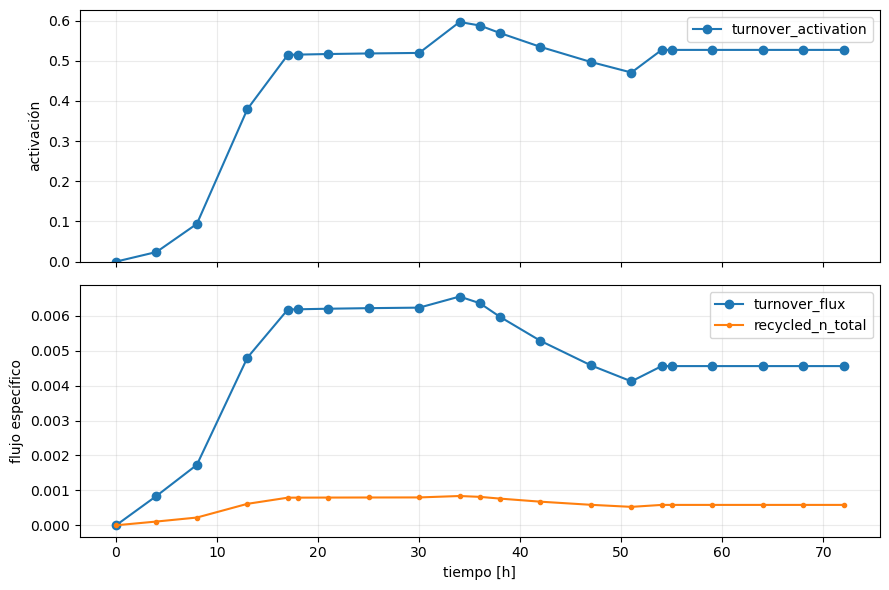

- t=0.0: activación bajo floor; turnover_flux se fija en 0


C:\Users\ctorrealba\AppData\Local\Temp\ipykernel_26856\3100296153.py:231: RuntimeWarning: Auditoría Fase 4 con observaciones; revisar notas y aplicación.
  warnings.warn("Auditoría Fase 4 con observaciones; revisar notas y aplicación.", RuntimeWarning)


In [18]:
phase4_abs_tol = 1e-9
phase4_trajectory_available = (
    "states_df_phase" in globals()
    and states_df_phase is not None
    and len(states_df_phase) > 0
    and "t_h" in states_df_phase.columns
)

if phase4_trajectory_available:
    phase4_t_values = np.asarray(states_df_phase["t_h"].to_numpy(dtype=float), dtype=float)
    phase4_t_values = np.unique(phase4_t_values[np.isfinite(phase4_t_values)])
    if len(phase4_t_values) == 0:
        phase4_trajectory_available = False
        phase4_audit_times = [0.0]
    else:
        phase4_representative_idx = {
            0,
            int(round(0.05 * (len(phase4_t_values) - 1))),
            int(round(0.25 * (len(phase4_t_values) - 1))),
            int(round(0.50 * (len(phase4_t_values) - 1))),
            int(round(0.75 * (len(phase4_t_values) - 1))),
            len(phase4_t_values) - 1,
        }
        phase4_mesh_idx = set(np.linspace(0, len(phase4_t_values) - 1, min(18, len(phase4_t_values))).round().astype(int))
        phase4_idx = sorted(phase4_representative_idx | phase4_mesh_idx)
        phase4_audit_times = [float(phase4_t_values[i]) for i in phase4_idx]
else:
    phase4_audit_times = [0.0]

phase4_rows = []
phase4_failures = []
phase4_warnings = []
phase4_prev_state = None
phase4_prev_phase = None

if not phase4_trajectory_available:
    phase4_warnings.append({"time": 0.0, "notes": ["states_df_phase no disponible; auditoría limitada al snapshot inicial."]})

for t_probe in phase4_audit_times:
    if phase4_trajectory_available:
        snap = build_mechanistic_snapshot_model(
            t_probe,
            solve=True,
            exact_time=False,
            prev_state=phase4_prev_state,
            prev_phase=phase4_prev_phase,
        )
    else:
        snap = build_mechanistic_initial_snapshot_model(
            solve=True,
            prev_state=phase4_prev_state,
            prev_phase=phase4_prev_phase,
        )

    sol = snap.get("solution")
    solver_status = getattr(sol, "status", None)
    try:
        objective_value = float(sol.objective_value)
    except (AttributeError, TypeError, ValueError):
        objective_value = np.nan

    indicators = snap.get("phase_indicators", {}) or {}
    comp = snap.get("biomass_composition", {}) or {}
    turnover_module = snap.get("protein_turnover_module", {}) or {}
    activation = turnover_module.get("activation", {}) or {}
    flux = turnover_module.get("turnover_flux", {}) or {}
    pool = turnover_module.get("recycled_pool", {}) or {}
    application = snap.get("protein_turnover_application", {}) or {}

    phase_label = snap.get("phase_label")
    turnover_activation = _phase4_safe_float(snap.get("protein_turnover_activation"), default=np.nan)
    turnover_flux = _phase4_safe_float(snap.get("protein_turnover_flux"), default=np.nan)
    recycled_n_total = _phase4_safe_float(pool.get("recycled_n_total"), default=np.nan)
    recycled_n_mmol = _phase4_safe_float(pool.get("recycled_n_total_mmol_gDW_h"), default=np.nan)
    f_prot = _phase4_safe_float(comp.get("f_prot"), default=np.nan)
    x_active = _phase4_safe_float(activation.get("x_active_used", indicators.get("x_active")), default=np.nan)
    n_total = _phase4_safe_float(indicators.get("n_total"), default=np.nan)
    n_free = _phase4_safe_float(indicators.get("n_free"), default=np.nan)

    row_issues = []
    row_notes = []
    if not np.isfinite(turnover_activation) or turnover_activation < -phase4_abs_tol:
        row_issues.append(f"turnover_activation inválida: {turnover_activation}")
    if not np.isfinite(turnover_flux) or turnover_flux < -phase4_abs_tol:
        row_issues.append(f"turnover_flux inválido: {turnover_flux}")
    if not np.isfinite(recycled_n_total) or recycled_n_total < -phase4_abs_tol:
        row_issues.append(f"recycled_n_total inválido: {recycled_n_total}")
    if turnover_flux > phase4_abs_tol:
        expected_n = turnover_flux * float(PROTEIN_TURNOVER_DEFAULTS["protein_n_fraction_gN_gProt"]) * float(PROTEIN_TURNOVER_DEFAULTS["recycle_efficiency"])
        if abs(recycled_n_total - expected_n) > max(1e-8, 1e-4 * max(abs(expected_n), 1e-8)):
            row_issues.append(f"pool reciclable inconsistente: esperado={expected_n:.6g}, observado={recycled_n_total:.6g}")
    starvation_component = _phase4_safe_float(activation.get("nitrogen_starvation_component"), default=0.0)
    if (
        phase_label in {"F0_LAG_OSMO", "F1_EXP_GROWTH"}
        and turnover_activation > 0.25
        and starvation_component < 0.5
    ):
        row_notes.append(
            f"turnover alto en fase temprana sin starvation fuerte: "
            f"activation={turnover_activation:.3f}, starvation={starvation_component:.3f}"
        )
    if phase_label in {"F2_N_LIMITED_CARB_ACC", "F3_STATIONARY", "F4_DECAY"} and turnover_activation < 0.02:
        row_notes.append(f"turnover bajo pese a fase limitante/tardía: {turnover_activation:.3f}")
    if not bool(snap.get("protein_turnover_activation_valid")):
        row_issues.append("protein_turnover_activation_valid=False")
    if not bool(snap.get("protein_turnover_flux_valid")):
        row_issues.append("protein_turnover_flux_valid=False")
    if not bool(snap.get("protein_turnover_distribution_valid")):
        row_issues.append("protein_turnover_distribution_valid=False")
    if solver_status != "optimal":
        row_issues.append(f"solver_status={solver_status}")

    status = snap.get("protein_turnover_application_status")
    applied = bool(snap.get("protein_turnover_applied"))
    if turnover_flux > phase4_abs_tol and not applied:
        if dict(globals().get("_found_precursors", {})):
            row_issues.append(f"turnover calculado pero no aplicado a bounds: {status}")
        else:
            row_notes.append(f"turnover calculado como pool agregado sin precursores: {status}")
    if status not in {"applied_to_found_precursor_bounds", "computed_but_no_bounds_changed", "computed_only_aggregate_pool_no_precursor_bounds"}:
        row_notes.append(f"estado de aplicación: {status}")

    for notes_key in [
        "protein_turnover_activation_notes",
        "protein_turnover_flux_notes",
        "protein_turnover_distribution_notes",
        "protein_turnover_application_notes",
    ]:
        if snap.get(notes_key):
            row_notes.extend(str(note) for note in snap.get(notes_key, []))

    if row_issues:
        diagnostic = "FAIL"
        phase4_failures.append({"time": snap.get("actual_t_h", t_probe), "issues": row_issues})
    elif row_notes:
        diagnostic = "WARNING"
        phase4_warnings.append({"time": snap.get("actual_t_h", t_probe), "notes": row_notes})
    else:
        diagnostic = "PASS"

    phase4_rows.append({
        "time": float(snap.get("actual_t_h", t_probe)),
        "phase_label": phase_label,
        "n_free": n_free,
        "n_total": n_total,
        "x_active": x_active,
        "f_prot": f_prot,
        "turnover_activation": turnover_activation,
        "nitrogen_starvation_component": activation.get("nitrogen_starvation_component"),
        "phase_component": activation.get("phase_component"),
        "active_biomass_component": activation.get("active_biomass_component"),
        "protein_content_component": activation.get("protein_content_component"),
        "turnover_rate": flux.get("turnover_rate"),
        "turnover_flux": turnover_flux,
        "recycled_n_total": recycled_n_total,
        "recycled_n_total_mmol": recycled_n_mmol,
        "n_recycled_aa": len(pool.get("recycled_aa_pool", {}) or {}),
        "turnover_applied": applied,
        "turnover_application_status": status,
        "n_bound_updates": len(snap.get("protein_turnover_bound_updates", []) or []),
        "solver_status": solver_status,
        "objective_value": objective_value,
        "diagnostic": diagnostic,
        "diagnostic_notes": "; ".join(row_notes + row_issues),
    })

    phase4_prev_state = snap.get("state")
    phase4_prev_phase = phase_label

mechanistic_phase4_audit_df = pd.DataFrame(phase4_rows)
display(mechanistic_phase4_audit_df)

response_notes = []
early = mechanistic_phase4_audit_df[mechanistic_phase4_audit_df["phase_label"].isin(["F0_LAG_OSMO", "F1_EXP_GROWTH"])]
late = mechanistic_phase4_audit_df[mechanistic_phase4_audit_df["phase_label"].isin(["F2_N_LIMITED_CARB_ACC", "F3_STATIONARY", "F4_DECAY"])]
if len(early) and len(late):
    early_mean = float(pd.to_numeric(early["turnover_activation"], errors="coerce").mean())
    late_mean = float(pd.to_numeric(late["turnover_activation"], errors="coerce").mean())
    response_notes.append(f"activación media temprana={early_mean:.4f}; limitante/tardía={late_mean:.4f}")
    if late_mean + 1e-9 < early_mean:
        phase4_warnings.append({"time": np.nan, "notes": ["la activación media tardía es menor que la temprana; revisar parámetros"]})
else:
    response_notes.append("no hay suficientes fases tempranas y tardías para comparar activación media")

if mechanistic_phase4_audit_df["n_total"].notna().sum() >= 4:
    n_vals = pd.to_numeric(mechanistic_phase4_audit_df["n_total"], errors="coerce").to_numpy(dtype=float)
    a_vals = pd.to_numeric(mechanistic_phase4_audit_df["turnover_activation"], errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(n_vals) & np.isfinite(a_vals)
    if mask.sum() >= 4 and np.nanstd(n_vals[mask]) > 0 and np.nanstd(a_vals[mask]) > 0:
        corr = float(np.corrcoef(n_vals[mask], a_vals[mask])[0, 1])
        response_notes.append(f"correlación n_total vs activación turnover = {corr:.3f} (esperable negativa)")
        if corr > 0.3:
            phase4_warnings.append({"time": np.nan, "notes": ["turnover aumenta con n_total; revisar componente de starvation"]})

print("Diagnóstico de respuesta turnover:")
for note in response_notes:
    print(f"- {note}")

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(mechanistic_phase4_audit_df["time"], mechanistic_phase4_audit_df["turnover_activation"], marker="o", label="turnover_activation")
    axes[0].set_ylabel("activación")
    axes[0].set_ylim(bottom=0)
    axes[0].legend(loc="best")
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(mechanistic_phase4_audit_df["time"], mechanistic_phase4_audit_df["turnover_flux"], marker="o", label="turnover_flux")
    axes[1].plot(mechanistic_phase4_audit_df["time"], mechanistic_phase4_audit_df["recycled_n_total"], marker=".", label="recycled_n_total")
    axes[1].set_xlabel("tiempo [h]")
    axes[1].set_ylabel("flujo específico")
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[WARN] No se pudo generar gráfico matplotlib: {exc}")

if phase4_failures:
    print("FAIL: turnover proteico explícito presenta inconsistencias graves.")
    for failure in phase4_failures:
        print(f"- t={failure['time']}: " + "; ".join(failure["issues"]))
    warnings.warn("Auditoría Fase 4 falló; revisar `mechanistic_phase4_audit_df`.", RuntimeWarning)
elif phase4_warnings:
    print("WARNING: módulo Fase 4 estable pero con observaciones auditables.")
    for warning in phase4_warnings[:12]:
        print(f"- t={warning['time']}: " + "; ".join(warning["notes"][:4]))
    if len(phase4_warnings) > 12:
        print(f"- ... {len(phase4_warnings) - 12} observaciones adicionales en diagnostic_notes")
    warnings.warn("Auditoría Fase 4 con observaciones; revisar notas y aplicación.", RuntimeWarning)
else:
    print("PASS: turnover proteico explícito es coherente, auditable, aplicado al snapshot y compatible con el solver.")


### Interpretación esperada de la Fase 4

La Fase 4 agregó un módulo explícito de turnover proteico con cuatro pasos separados: activación fisiológica, cálculo de flujo, distribución del pool reciclable y aplicación al snapshot mediante bounds de precursores de aminoácidos.

Respecto de Fase 3, la biomasa variable y el GAM dinámico siguen funcionando como antes, pero ahora la fracción proteica y la fase fisiológica alimentan un reciclaje interno explícito. El turnover deja de depender solo del modo legacy `TURNOVER_ATPM` y puede aparecer gradualmente en F2/F3/F4 según starvation de nitrógeno, biomasa activa y proteína disponible.

La evidencia de funcionamiento queda en `mechanistic_phase4_audit_df`: el turnover debe ser no negativo, bajo en fases tempranas, mayor en limitación/stationary/decay, generar un pool reciclable consistente y mantener el solver en estado óptimo. El campo `protein_turnover_application_status` indica si el pool reciclado fue aplicado a bounds de precursores o si quedó como pool agregado.

Las limitaciones restantes son deliberadas: el pool reciclable todavía se aplica mediante bounds de precursores existentes, no mediante una red interna nueva; no hay NCR refinada, no hay objetivos lexicográficos por turnover, y todavía no se conectan módulos de Ehrlich/aromas/redox a los aminoácidos reciclados.

En Fase 5 se espera usar este pool reciclable para introducir regulación de nitrógeno más refinada y preparar el acoplamiento con rutas de Ehrlich/benzenoides/ésteres, separando la disponibilidad externa de N del reciclaje interno dependiente de fase.


### Fase 5 - Cap global de nitrógeno y reparto fino NCR

La Fase 5 separa explícitamente dos niveles de control nitrogenado. Zenteno sigue definiendo el techo global de captación externa de nitrógeno, mientras una nueva capa tipo NCR reparte ese techo entre NH4+ y aminoácidos/fuentes nitrogenadas específicas.

Un límite agregado de N no basta cuando se quiere estudiar fisiología de fase, Ehrlich/aromas o reciclaje proteico: distintas fuentes nitrogenadas no son equivalentes y la célula no las prioriza igual en crecimiento, limitación o stationary. Por eso esta fase conserva la cantidad total externa impuesta por Zenteno, pero agrega una asignación fina y auditable por fuente.

En esta implementación, NCR es una capa regulatoria simplificada y operacional: no pretende ser una red TOR/GATA completa, sino una regla explícita que aumenta el peso de fuentes preferentes cuando hay N disponible y desreprime fuentes secundarias/tardías bajo inanición. El nitrógeno reciclado desde turnover se trata como fuente interna adicional, separada del cap externo, para evitar doble conteo.

Al auditar esperamos ver que la suma de N externo asignado no excede el cap global de Zenteno, que los pesos cambian con fase/starvation, que el reciclaje queda trazado aparte, y que los bounds de uptake se aplican solo a fuentes nitrogenadas identificadas. Se conserva el kernel Zenteno, el clasificador, biomasa/GAM, turnover explícito y la estrategia de resolución legacy.


In [19]:
PHASE5_NITROGEN_NCR_VERSION = "phase5_global_n_cap_ncr_allocation_v1"

if "_call_with_supported_kwargs" not in globals():
    import inspect

    def _call_with_supported_kwargs(func, *args, **kwargs):
        try:
            signature = inspect.signature(func)
            params = signature.parameters
            if not any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values()):
                kwargs = {key: value for key, value in kwargs.items() if key in params}
        except (TypeError, ValueError):
            pass
        return func(*args, **kwargs)

if "_PHASE4_BUILD_MECHANISTIC_SNAPSHOT_MODEL" not in globals():
    _PHASE4_BUILD_MECHANISTIC_SNAPSHOT_MODEL = build_mechanistic_snapshot_model
if "_PHASE4_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL" not in globals():
    _PHASE4_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL = build_mechanistic_initial_snapshot_model

NCR_CLASS_DEFAULTS = {
    "preferred": {
        "base_weight": 1.00,
        "rich_preference_gain": 1.00,
        "starvation_derepression_gain": 0.00,
        "phase_derepression_gain": 0.00,
        "recycled_relief": 0.10,
    },
    "preferred_amino": {
        "base_weight": 0.75,
        "rich_preference_gain": 0.65,
        "starvation_derepression_gain": 0.25,
        "phase_derepression_gain": 0.20,
        "recycled_relief": 0.15,
    },
    "secondary_amino": {
        "base_weight": 0.35,
        "rich_preference_gain": 0.15,
        "starvation_derepression_gain": 0.90,
        "phase_derepression_gain": 0.70,
        "recycled_relief": 0.25,
    },
    "late_amino": {
        "base_weight": 0.18,
        "rich_preference_gain": 0.00,
        "starvation_derepression_gain": 1.45,
        "phase_derepression_gain": 1.10,
        "recycled_relief": 0.35,
    },
    "aromatic_late": {
        "base_weight": 0.12,
        "rich_preference_gain": 0.00,
        "starvation_derepression_gain": 1.65,
        "phase_derepression_gain": 1.25,
        "recycled_relief": 0.40,
    },
}

NITROGEN_SOURCE_MAP_DEFAULTS = {
    "r_1654": {"label": "NH4", "ncr_class": "preferred", "source_prior": 0.40},
    "r_1891": {"label": "Gln", "ncr_class": "preferred_amino", "source_prior": 0.10},
    "r_1889": {"label": "Glu", "ncr_class": "preferred_amino", "source_prior": 0.05},
    "r_1906": {"label": "Ser", "ncr_class": "secondary_amino", "source_prior": 0.05},
    "r_1911": {"label": "Thr", "ncr_class": "secondary_amino", "source_prior": 0.05},
    "r_1873": {"label": "Ala", "ncr_class": "secondary_amino", "source_prior": 0.05},
    "r_1879": {"label": "Arg", "ncr_class": "late_amino", "source_prior": 0.20},
    "r_1899": {"label": "Leu", "ncr_class": "late_amino", "source_prior": 0.05},
    "r_1912": {"label": "Trp", "ncr_class": "aromatic_late", "source_prior": 0.05},
    # Precursores reciclables de Fase 4. Se incluyen aquí como fuentes/pools
    # nitrogenados mapeables, no necesariamente como N externo del medio.
    "r_1903": {"label": "Phe", "ncr_class": "aromatic_late", "source_prior": 0.03},
    "r_1914": {"label": "Val", "ncr_class": "late_amino", "source_prior": 0.03},
    "r_1902": {"label": "Met", "ncr_class": "late_amino", "source_prior": 0.03},
    "r_1913": {"label": "Tyr", "ncr_class": "aromatic_late", "source_prior": 0.03},
}

NITROGEN_ALLOCATION_DEFAULTS = {
    "parameterization_note": "v1 operacional: Zenteno cap global externo + reparto NCR simplificado por clase de fuente",
    "n_reference_gN_L": float(BIOMASS_COMPOSITION_DEFAULTS.get("n_reference_gN_L", 0.14)) if "BIOMASS_COMPOSITION_DEFAULTS" in globals() else 0.14,
    "n_depleted_gN_L": float(BIOMASS_COMPOSITION_DEFAULTS.get("n_depleted_gN_L", 0.02)) if "BIOMASS_COMPOSITION_DEFAULTS" in globals() else 0.02,
    "n_saturation_gN_L": float(BIOMASS_COMPOSITION_DEFAULTS.get("n_saturation_gN_L", 0.10)) if "BIOMASS_COMPOSITION_DEFAULTS" in globals() else 0.10,
    "starvation_power": 1.2,
    "phase_derepression": {
        "F0_LAG_OSMO": 0.00,
        "F1_EXP_GROWTH": 0.10,
        "F2_N_LIMITED_CARB_ACC": 0.65,
        "F3_STATIONARY": 0.85,
        "F4_DECAY": 1.00,
    },
    "preferred_signal_floor": 0.0,
    "minimum_source_weight": 1e-9,
    "max_source_flux_cap": 1000.0,
    "recycled_signal_half_cap_fraction": 0.25,
    "use_recycled_n_for_combined_supply": True,
    "allow_unmapped_recycled_pool": True,
    "epsilon": 1e-12,
}


def _phase5_safe_float(value, default=np.nan):
    """Convierte un escalar a float finito y devuelve `default` si falla."""
    try:
        if value is None:
            return default
        out = float(value)
        return out if np.isfinite(out) else default
    except (TypeError, ValueError):
        return default


def _phase5_merge_allocation_params(params=None):
    """Combina defaults de N/NCR con overrides auditables."""
    cfg = dict(NITROGEN_ALLOCATION_DEFAULTS)
    cfg["phase_derepression"] = dict(NITROGEN_ALLOCATION_DEFAULTS["phase_derepression"])
    if params:
        for key, value in dict(params).items():
            if key == "phase_derepression":
                merged = dict(cfg[key])
                merged.update(dict(value))
                cfg[key] = merged
            else:
                cfg[key] = value
    return cfg


def _phase5_effective_modeling_config(config=None):
    """Resuelve configuración integrada tolerando modos legacy de snapshot."""
    raw_mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    if "_normalize_modeling_config_mode" in globals():
        mode = _normalize_modeling_config_mode(raw_mode)
    else:
        mode = raw_mode if raw_mode in MODEL_CONFIG_MODE_OVERRIDES else "strict"
    return build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=mode)


def _phase5_nitrogen_policy_context(config=None):
    modeling_config = _phase5_effective_modeling_config(config)
    mode = modeling_config.get("mode", "strict")
    nitrogen_policy = modeling_config.get("nitrogen_policy", {})
    turnover_policy = modeling_config.get("turnover_policy", {})
    external_n_eps = float(nitrogen_policy.get("external_n_eps", 1e-9))
    prevent_reopening = bool(nitrogen_policy.get("prevent_reopening_depleted_sources", True))
    turnover_may_open_external = bool(nitrogen_policy.get("turnover_may_open_external_exchanges", False))
    if mode in ("strict", "diagnostic"):
        turnover_may_open_external = False
    return {
        "modeling_config": modeling_config,
        "mode": mode,
        "nitrogen_policy": nitrogen_policy,
        "turnover_policy": turnover_policy,
        "external_n_eps": external_n_eps,
        "prevent_reopening": prevent_reopening,
        "turnover_may_open_external": turnover_may_open_external,
    }


def _phase5_state_get(state, keys, default=np.nan):
    if state is None:
        return default
    if isinstance(keys, str):
        keys = [keys]
    for key in keys:
        try:
            if isinstance(state, dict) and key in state:
                return state[key]
            if hasattr(state, "get"):
                value = state.get(key, None)
                if value is not None:
                    return value
        except Exception:
            continue
    return default


def _phase5_state_cN_free(state):
    return _phase5_safe_float(_phase5_state_get(state, ["cN_free", "N_free_gN_L", "N_gN_L", "cN_total"], default=np.nan), default=np.nan)


def _phase5_source_external_concentration(rid, src=None, state=None, external_n_eps=1e-9):
    """Devuelve concentración externa conocida; usa cN_free como fallback agregado."""
    src = {} if src is None else dict(src)
    state = {} if state is None else state
    label = str(src.get("label", rid))
    cN_free = _phase5_state_cN_free(state)
    notes = []

    explicit_map = _phase5_state_get(state, ["external_n_concentrations", "n_source_concentrations"], default=None)
    if isinstance(explicit_map, dict):
        for key in (rid, label, label.lower(), label.upper()):
            if key in explicit_map:
                val = max(0.0, _phase5_safe_float(explicit_map.get(key), default=0.0))
                return {
                    "external_concentration": float(val),
                    "concentration_basis": f"explicit_source_concentration:{key}",
                    "used_cN_free_as_aggregate": False,
                    "cN_free": cN_free,
                    "availability_notes": notes,
                }

    aa_state = _phase5_state_get(state, "aa_state", default=None)
    if isinstance(aa_state, dict):
        for key in (label, label.lower(), label.upper()):
            if key in aa_state:
                val = max(0.0, _phase5_safe_float(aa_state.get(key), default=0.0))
                return {
                    "external_concentration": float(val),
                    "concentration_basis": f"aa_state:{key}",
                    "used_cN_free_as_aggregate": False,
                    "cN_free": cN_free,
                    "availability_notes": notes,
                }

    for key in (f"c{label}", f"c_{label}", label, rid, f"AA_{label}_mmol_L"):
        val = _phase5_safe_float(_phase5_state_get(state, key, default=np.nan), default=np.nan)
        if np.isfinite(val):
            return {
                "external_concentration": float(max(0.0, val)),
                "concentration_basis": f"state:{key}",
                "used_cN_free_as_aggregate": False,
                "cN_free": cN_free,
                "availability_notes": notes,
            }

    notes.append("N source has no explicit concentration; using cN_free as aggregate availability")
    agg = 0.0 if not np.isfinite(cN_free) else max(0.0, cN_free)
    return {
        "external_concentration": float(agg),
        "concentration_basis": "cN_free_aggregate",
        "used_cN_free_as_aggregate": True,
        "cN_free": cN_free,
        "availability_notes": notes,
    }


def _phase5_enrich_source_availability(source_map, state=None, config=None):
    ctx = _phase5_nitrogen_policy_context(config)
    external_n_eps = ctx["external_n_eps"]
    source_map_data = source_map.get("nitrogen_source_map", source_map) if isinstance(source_map, dict) else {}
    cN_free = _phase5_state_cN_free(state)
    out = {}
    for rid, src in source_map_data.items():
        info = _phase5_source_external_concentration(rid, src=src, state=state, external_n_eps=external_n_eps)
        global_depleted = bool(np.isfinite(cN_free) and cN_free <= external_n_eps)
        individual_depleted = bool(info["external_concentration"] <= external_n_eps)
        available = bool((not global_depleted) and (not individual_depleted))
        out[rid] = {
            **info,
            "external_n_eps": external_n_eps,
            "global_n_depleted": global_depleted,
            "source_depleted": individual_depleted or global_depleted,
            "external_available": available,
        }
    return out



def compute_global_nitrogen_cap(snapshot=None, state=None, params=None, config=None):
    """Extrae o reconstruye el cap global externo de nitrógeno definido por Zenteno."""
    cfg = _phase5_merge_allocation_params(params)
    ctx = _phase5_nitrogen_policy_context(config)
    external_n_eps = ctx["external_n_eps"]
    notes = []
    snapshot = {} if snapshot is None else dict(snapshot)
    meta = snapshot.get("meta", {}) if isinstance(snapshot.get("meta", {}), dict) else {}
    state = state if state is not None else snapshot.get("state")
    limits = snapshot.get("limits", meta.get("limits"))
    basis = None
    lim_n_map = None
    cN_free = _phase5_state_cN_free(state)

    if isinstance(limits, dict) and isinstance(limits.get("lim_n_map"), dict):
        lim_n_map = dict(limits["lim_n_map"])
        basis = "snapshot_limits_lim_n_map_from_zenteno"

    if lim_n_map is None and state is not None:
        try:
            st = state if isinstance(state, dict) else _extract_state_values(state)
            rebuilt_limits = zenteno_limits(
                st.get("cX", INITIAL_STATE["cX"]),
                st.get("cN_free", INITIAL_STATE["cN"]),
                st.get("cG", INITIAL_STATE["cG"]),
                st.get("cF", INITIAL_STATE["cF"]),
                st.get("cE", INITIAL_STATE["cE"]),
                st.get("cO2", INITIAL_STATE["cO2"]),
                t=float(snapshot.get("actual_t_h", meta.get("actual_t_h", 0.0))),
            )
            lim_n_map = dict(rebuilt_limits.get("lim_n_map", {}))
            basis = "recomputed_zenteno_limits_from_state"
            notes.append("cap global reconstruido desde estado porque no estaba disponible en meta")
        except Exception as exc:
            notes.append(f"no se pudo reconstruir zenteno_limits: {exc}")

    if lim_n_map is None:
        lim_n_map = {}
        basis = "missing_lim_n_map_zero_cap"
        notes.append("lim_n_map no disponible; cap global se fija en 0")

    if np.isfinite(cN_free) and cN_free <= external_n_eps:
        lim_n_map = {rid: 0.0 for rid in set(lim_n_map) | set(globals().get("KINETIC_N_SOURCE_IDS", []))}
        notes.append("cN_free <= external_n_eps; cap global externo de N fijado en 0")

    global_n_cap = 0.0
    per_source_n_from_zenteno = {}
    for rid, flux_cap in lim_n_map.items():
        n_atoms = _phase5_safe_float(globals().get("N_atoms_map", {}).get(rid, 1.0), default=1.0)
        flux_cap = max(0.0, _phase5_safe_float(flux_cap, default=0.0))
        n_cap = flux_cap * n_atoms * float(globals().get("MW_N", 0.014007))
        per_source_n_from_zenteno[rid] = float(n_cap)
        global_n_cap += n_cap

    global_n_cap = max(0.0, float(global_n_cap))
    valid = bool(np.isfinite(global_n_cap) and global_n_cap >= 0.0)
    if not valid:
        notes.append("global_n_cap no finito o negativo")

    return {
        "global_n_cap": global_n_cap,
        "global_n_cap_basis": basis,
        "global_n_cap_valid": valid,
        "global_n_cap_notes": notes,
        "per_source_n_from_zenteno": per_source_n_from_zenteno,
        "lim_n_map_used": lim_n_map,
        "cN_free": cN_free,
        "external_n_eps": external_n_eps,
        "external_n_depleted": bool(np.isfinite(cN_free) and cN_free <= external_n_eps),
    }


def build_nitrogen_source_map(mdl=None, params=None, source_defaults=None, config=None):
    """Construye mapa auditable entre fuentes externas de N, reacciones, N por fuente y clase NCR."""
    cfg = _phase5_merge_allocation_params(params)
    defaults = dict(NITROGEN_SOURCE_MAP_DEFAULTS if source_defaults is None else source_defaults)
    model_for_map = mdl if mdl is not None else globals().get("model_operativo", globals().get("operational_model", None))
    rxns = reaction_map(model_for_map) if model_for_map is not None else {}
    notes = []
    identified = {}
    missing = []
    candidate_ids = list(dict.fromkeys(
        list(globals().get("KINETIC_N_SOURCE_IDS", []))
        + list(defaults.keys())
        + list(globals().get("ALL_N_SOURCE_IDS", []))
    ))

    for rid in candidate_ids:
        if rid not in rxns:
            missing.append(rid)
            continue
        spec = dict(defaults.get(rid, {}))
        n_atoms = _phase5_safe_float(globals().get("N_atoms_map", {}).get(rid, spec.get("n_atoms", 1.0)), default=1.0)
        source_prior = _phase5_safe_float(
            spec.get("source_prior", globals().get("N_profile_map", {}).get(rid, 1.0)),
            default=1.0,
        )
        source_prior = max(float(cfg["minimum_source_weight"]), source_prior)
        identified[rid] = {
            "reaction_id": rid,
            "reaction_name": rxns[rid].name,
            "label": spec.get("label", rid),
            "source_name": spec.get("label", rid),
            "ncr_class": spec.get("ncr_class", "secondary_amino"),
            "n_atoms": float(n_atoms),
            "n_g_per_flux_unit": float(n_atoms) * float(globals().get("MW_N", 0.014007)),
            "source_prior": float(source_prior),
            "is_external_n_source": True,
            "ncr_allocation_candidate": bool(rid in globals().get("KINETIC_N_SOURCE_IDS", []) or rid in defaults),
        }

    if not identified:
        notes.append("no se identificaron fuentes nitrogenadas aplicables")
    if missing:
        notes.append(f"fuentes nitrogenadas ausentes en modelo: {missing}")

    return {
        "nitrogen_source_map": identified,
        "identified_sources": list(identified.keys()),
        "missing_sources": missing,
        "source_map_valid": bool(identified),
        "source_map_notes": notes,
    }


def compute_ncr_signals(state=None, phase_label=None, indicators=None, recycled_pool=None, global_cap=None, params=None, config=None):
    """Calcula señales regulatorias simplificadas para reparto NCR."""
    cfg = _phase5_merge_allocation_params(params)
    ctx = _phase5_nitrogen_policy_context(config)
    indicators = {} if indicators is None else dict(indicators)
    recycled_pool = {} if recycled_pool is None else dict(recycled_pool)
    notes = []

    n_total = _phase5_safe_float(indicators.get("n_total"), default=np.nan)
    if not np.isfinite(n_total) and state is not None:
        n_total = _phase5_state_cN_free(state)
        if np.isfinite(n_total):
            notes.append("n_total no disponible; se usa cN_free extraído como proxy")

    n_low = max(float(cfg["n_depleted_gN_L"]), ctx["external_n_eps"])
    n_high = max(float(cfg["n_saturation_gN_L"]), n_low + float(cfg["epsilon"]))
    if np.isfinite(n_total):
        preferred_n_signal = (n_total - n_low) / max(n_high - n_low, float(cfg["epsilon"]))
        preferred_n_signal = min(max(preferred_n_signal, float(cfg["preferred_signal_floor"])), 1.0)
        starvation = 1.0 - preferred_n_signal
        starvation = starvation ** float(cfg["starvation_power"])
    else:
        preferred_n_signal = 0.5
        starvation = 0.5
        notes.append("n_total no finito; señales NCR se fijan en 0.5")

    phase_n_signal = float(dict(cfg["phase_derepression"]).get(phase_label, 0.0))
    if phase_label not in dict(cfg["phase_derepression"]):
        notes.append(f"fase sin señal NCR explícita: {phase_label}")

    recycled_n_available = _phase5_safe_float(recycled_pool.get("recycled_n_total"), default=0.0)
    cap_val = _phase5_safe_float(global_cap.get("global_n_cap") if isinstance(global_cap, dict) else global_cap, default=0.0)
    denom = max(cap_val * float(cfg["recycled_signal_half_cap_fraction"]), float(cfg["epsilon"]))
    recycled_n_signal = recycled_n_available / (recycled_n_available + denom)
    recycled_n_signal = min(max(recycled_n_signal, 0.0), 1.0)

    valid = bool(all(np.isfinite(v) for v in [preferred_n_signal, starvation, phase_n_signal, recycled_n_signal]))
    return {
        "preferred_n_signal": float(preferred_n_signal),
        "nitrogen_starvation_signal": float(starvation),
        "phase_n_signal": float(phase_n_signal),
        "recycled_n_signal": float(recycled_n_signal),
        "recycled_n_available": float(recycled_n_available),
        "n_total_used": float(n_total) if np.isfinite(n_total) else np.nan,
        "ncr_valid": valid,
        "ncr_notes": notes,
    }

def compute_ncr_allocation_weights(source_map, ncr_signals, params=None, class_defaults=None):
    """Traduce señales NCR en pesos efectivos por fuente nitrogenada."""
    cfg = _phase5_merge_allocation_params(params)
    class_cfg = dict(NCR_CLASS_DEFAULTS if class_defaults is None else class_defaults)
    source_map = source_map.get("nitrogen_source_map", source_map) if isinstance(source_map, dict) else {}
    signals = {} if ncr_signals is None else dict(ncr_signals)
    notes = []

    preferred = _phase5_safe_float(signals.get("preferred_n_signal"), default=0.5)
    starvation = _phase5_safe_float(signals.get("nitrogen_starvation_signal"), default=0.5)
    phase_signal = _phase5_safe_float(signals.get("phase_n_signal"), default=0.0)
    recycled = _phase5_safe_float(signals.get("recycled_n_signal"), default=0.0)

    class_weights = {}
    for cls, spec in class_cfg.items():
        raw = float(spec.get("base_weight", 1.0)) * (
            1.0
            + float(spec.get("rich_preference_gain", 0.0)) * preferred
            + float(spec.get("starvation_derepression_gain", 0.0)) * starvation
            + float(spec.get("phase_derepression_gain", 0.0)) * phase_signal
        )
        raw *= max(0.0, 1.0 - float(spec.get("recycled_relief", 0.0)) * recycled)
        class_weights[cls] = max(float(cfg["minimum_source_weight"]), raw)

    source_weights = {}
    for rid, src in source_map.items():
        cls = src.get("ncr_class", "secondary_amino")
        if cls not in class_weights:
            notes.append(f"clase NCR desconocida para {rid}: {cls}; se usa secondary_amino")
            cls = "secondary_amino"
        prior = max(float(cfg["minimum_source_weight"]), _phase5_safe_float(src.get("source_prior"), default=1.0))
        source_weights[rid] = float(class_weights[cls] * prior)

    total = sum(source_weights.values())
    if total <= 0 or not np.isfinite(total):
        n = max(1, len(source_weights))
        source_weights = {rid: 1.0 / n for rid in source_weights}
        total = 1.0
        notes.append("pesos no positivos/no finitos; se usa distribución uniforme")

    normalized = {rid: float(w / total) for rid, w in source_weights.items()}
    valid = bool(normalized and all(np.isfinite(v) and v >= 0 for v in normalized.values()))
    return {
        "source_weights": normalized,
        "class_weights": class_weights,
        "raw_source_weights": source_weights,
        "weight_normalization": float(total),
        "weights_valid": valid,
        "weights_notes": notes,
    }


def allocate_nitrogen_cap_across_sources(global_cap, source_map, weights, params=None):
    """Reparte el cap global externo de N entre fuentes específicas."""
    cfg = _phase5_merge_allocation_params(params)
    source_map_data = source_map.get("nitrogen_source_map", source_map) if isinstance(source_map, dict) else {}
    source_weights = weights.get("source_weights", weights) if isinstance(weights, dict) else {}
    cap = _phase5_safe_float(global_cap.get("global_n_cap") if isinstance(global_cap, dict) else global_cap, default=0.0)
    cap = max(0.0, cap)
    notes = []

    valid_sources = {
        rid: src
        for rid, src in source_map_data.items()
        if rid in source_weights and bool(src.get("ncr_allocation_candidate", True))
    }
    if not valid_sources:
        return {
            "source_n_caps": {},
            "source_flux_caps": {},
            "allocation_sum_n": 0.0,
            "allocation_residual_n": cap,
            "allocation_valid": False,
            "allocation_notes": ["sin fuentes válidas para asignar cap global"],
        }

    w_sum = sum(max(0.0, _phase5_safe_float(source_weights.get(rid), default=0.0)) for rid in valid_sources)
    if w_sum <= 0:
        w_sum = float(len(valid_sources))
        source_weights = {rid: 1.0 for rid in valid_sources}
        notes.append("pesos válidos suman 0; se usa reparto uniforme")

    source_n_caps = {}
    source_flux_caps = {}
    for rid, src in valid_sources.items():
        frac = max(0.0, _phase5_safe_float(source_weights.get(rid), default=0.0)) / max(w_sum, float(cfg["epsilon"]))
        n_cap = cap * frac
        n_per_flux = max(_phase5_safe_float(src.get("n_g_per_flux_unit"), default=float(globals().get("MW_N", 0.014007))), float(cfg["epsilon"]))
        flux_cap = min(n_cap / n_per_flux, float(cfg["max_source_flux_cap"]))
        if flux_cap >= float(cfg["max_source_flux_cap"]):
            notes.append(f"{rid}: source_flux_cap limitado por max_source_flux_cap")
        source_n_caps[rid] = float(flux_cap * n_per_flux)
        source_flux_caps[rid] = float(flux_cap)

    allocation_sum_n = float(sum(source_n_caps.values()))
    residual = max(0.0, cap - allocation_sum_n)
    if allocation_sum_n > cap + 1e-10:
        scale = cap / max(allocation_sum_n, float(cfg["epsilon"]))
        for rid in source_n_caps:
            source_n_caps[rid] *= scale
            source_flux_caps[rid] *= scale
        notes.append(f"asignación escalada para respetar cap global: scale={scale:.6g}")
        allocation_sum_n = float(sum(source_n_caps.values()))
        residual = max(0.0, cap - allocation_sum_n)

    valid = bool(np.isfinite(allocation_sum_n) and allocation_sum_n <= cap + 1e-9 and all(v >= 0 for v in source_n_caps.values()))
    return {
        "source_n_caps": source_n_caps,
        "source_flux_caps": source_flux_caps,
        "allocation_sum_n": allocation_sum_n,
        "allocation_residual_n": residual,
        "allocation_valid": valid,
        "allocation_notes": notes,
    }



def merge_external_and_recycled_nitrogen_supply(allocation, recycled_pool=None, source_map=None, params=None, config=None):
    """Reporta N externo asignado y N reciclado interno sin mezclar ambos en strict."""
    cfg = _phase5_merge_allocation_params(params)
    ctx = _phase5_nitrogen_policy_context(config)
    allocation = {} if allocation is None else dict(allocation)
    recycled_pool = {} if recycled_pool is None else dict(recycled_pool)
    source_map_data = source_map.get("nitrogen_source_map", source_map) if isinstance(source_map, dict) else {}
    notes = []

    external_n_caps = dict(allocation.get("source_n_caps", {}))
    external_flux_caps = dict(allocation.get("source_flux_caps", {}))
    recycled_available = _phase5_safe_float(recycled_pool.get("recycled_n_total"), default=0.0)
    recycled_aa_pool = recycled_pool.get("recycled_aa_pool", {}) or {}

    recycled_by_source_n = {rid: 0.0 for rid in source_map_data}
    recycled_by_source_flux = {rid: 0.0 for rid in source_map_data}
    unmapped_recycled_n = 0.0
    for _aa_key, info in recycled_aa_pool.items():
        rid = info.get("reaction_id")
        n_val = _phase5_safe_float(info.get("recycled_n_gN_gDW_h"), default=0.0)
        flux_val = _phase5_safe_float(info.get("recycled_flux_model_units"), default=0.0)
        if rid in source_map_data:
            recycled_by_source_n[rid] += max(0.0, n_val)
            recycled_by_source_flux[rid] += max(0.0, flux_val)
        else:
            unmapped_recycled_n += max(0.0, n_val)

    recycled_used = float(sum(recycled_by_source_n.values()))
    if recycled_available > recycled_used + 1e-12:
        notes.append(f"N reciclado no mapeado a fuentes externas: {recycled_available - recycled_used:.6g} gN/gDW/h")
    if unmapped_recycled_n > 0:
        notes.append(f"N reciclado en precursores fuera del mapa NCR: {unmapped_recycled_n:.6g} gN/gDW/h")

    use_recycled_legacy = bool(cfg.get("use_recycled_n_for_combined_supply", True))
    turnover_used_as_external = bool(use_recycled_legacy and ctx["turnover_may_open_external"] and recycled_used > 0.0)
    if ctx["mode"] in ("strict", "diagnostic") and recycled_used > 0.0:
        notes.append("modo strict/diagnostic: N reciclado se reporta como interno y no abre exchanges externos")
    elif turnover_used_as_external:
        notes.append("modo regularized: N reciclado se suma a combined_flux_caps legacy")

    combined_n_supply = {}
    combined_flux_caps = {}
    for rid in source_map_data:
        ext_n = max(0.0, _phase5_safe_float(external_n_caps.get(rid), default=0.0))
        ext_flux = max(0.0, _phase5_safe_float(external_flux_caps.get(rid), default=0.0))
        rec_n = recycled_by_source_n.get(rid, 0.0) if turnover_used_as_external else 0.0
        rec_flux = recycled_by_source_flux.get(rid, 0.0) if turnover_used_as_external else 0.0
        combined_n_supply[rid] = {
            "external_n_cap": float(ext_n),
            "recycled_n_cap": float(rec_n),
            "combined_n_cap": float(ext_n + rec_n),
        }
        combined_flux_caps[rid] = float(ext_flux + rec_flux)

    valid = bool(all(v["combined_n_cap"] >= 0 for v in combined_n_supply.values()))
    return {
        "external_n_caps": external_n_caps,
        "external_flux_caps": external_flux_caps,
        "recycled_n_available": float(recycled_available),
        "recycled_n_used": float(recycled_used),
        "internal_recycled_n_available": float(recycled_available),
        "turnover_internal_n_signal": float(recycled_available),
        "macro_internal_n_supply_candidate": float(recycled_available),
        "unmapped_recycled_n": float(unmapped_recycled_n),
        "combined_n_supply": combined_n_supply,
        "combined_flux_caps": combined_flux_caps,
        "turnover_used_as_external": bool(turnover_used_as_external),
        "turnover_may_open_external": bool(ctx["turnover_may_open_external"]),
        "merge_valid": valid,
        "merge_notes": notes,
    }


def apply_nitrogen_allocation_to_snapshot(mdl, nitrogen_module, params=None, config=None, state=None, phase=None):
    """Aplica bounds efectivos de N por fuente sin reabrir fuentes agotadas o más restrictivas."""
    module = {} if nitrogen_module is None else dict(nitrogen_module)
    ctx = _phase5_nitrogen_policy_context(config)
    mode = ctx["mode"]
    external_n_eps = ctx["external_n_eps"]
    prevent_reopening = ctx["prevent_reopening"]
    source_map = module.get("source_map", {}).get("nitrogen_source_map", {})
    allocation = module.get("allocation", {})
    combined = module.get("combined_supply", {})
    flux_caps = allocation.get("source_flux_caps", {})
    if mode == "regularized" and ctx["turnover_may_open_external"]:
        flux_caps = combined.get("combined_flux_caps", flux_caps)
    source_availability = module.get("source_availability", {}) or _phase5_enrich_source_availability(source_map, state=state, config=config)
    notes = []
    applied = []
    failed = []
    rxns = reaction_map(mdl)
    cN_free = _phase5_state_cN_free(state)

    for rid, src in source_map.items():
        avail = source_availability.get(rid, {})
        if rid not in rxns:
            failed.append({"reaction_id": rid, "reason": "missing_reaction"})
            continue
        cap = max(0.0, _phase5_safe_float(flux_caps.get(rid), default=0.0))
        old_lb = float(rxns[rid].lower_bound)
        old_ub = float(rxns[rid].upper_bound)
        external_concentration = _phase5_safe_float(avail.get("external_concentration"), default=np.nan)
        closed_due_to_depletion = bool(avail.get("source_depleted", False))
        aggregate_warning = bool(avail.get("used_cN_free_as_aggregate", False))
        if np.isfinite(cN_free) and cN_free <= external_n_eps:
            closed_due_to_depletion = True

        if closed_due_to_depletion:
            new_lb = max(old_lb, 0.0)
        else:
            proposed_lb = -cap
            if mode in ("strict", "diagnostic") and prevent_reopening and old_lb >= 0.0 and proposed_lb < 0.0:
                new_lb = old_lb
                notes.append(f"{rid}: no se reabre fuente cerrada en modo {mode}")
            else:
                new_lb = max(old_lb, proposed_lb)

        was_reopened = bool(old_lb >= 0.0 and new_lb < 0.0)
        would_relax = bool(new_lb < old_lb)
        status_hint = "PASS"
        message = "safe external N allocation applied"
        if aggregate_warning:
            message = "safe external N allocation applied using cN_free aggregate availability"
        if aggregate_warning and not np.isfinite(cN_free):
            status_hint = "WARN"
            message = "N source has no explicit concentration and cN_free is not finite"
        if closed_due_to_depletion and new_lb < -external_n_eps:
            status_hint = "FAIL"
            message = "fuente N agotada con uptake permitido"
        if would_relax and mode in ("strict", "diagnostic"):
            status_hint = "WARN"
            message = "bound más restrictivo habría sido relajado; se conserva old_lb" if new_lb == old_lb else "bound más restrictivo relajado"

        audit_rec = set_reaction_bounds_with_audit(
            mdl,
            reaction_id=rid,
            lower_bound=new_lb,
            upper_bound=old_ub,
            module="nitrogen_allocation/NCR",
            reason="safe_external_nitrogen_allocation_no_reopening",
            mode=mode,
            phase=phase,
            state=state,
        )
        applied.append({
            "reaction_id": rid,
            "label": src.get("label", rid),
            "source_name": src.get("source_name", src.get("label", rid)),
            "ncr_class": src.get("ncr_class"),
            "old_lb": old_lb,
            "new_lb": float(rxns[rid].lower_bound),
            "old_ub": old_ub,
            "new_ub": float(rxns[rid].upper_bound),
            "allocated_cap": float(cap),
            "external_concentration": external_concentration,
            "cN_free": cN_free,
            "uptake_allowed": bool(float(rxns[rid].lower_bound) < -external_n_eps),
            "was_reopened": was_reopened,
            "closed_due_to_depletion": closed_due_to_depletion,
            "used_cN_free_as_aggregate": aggregate_warning,
            "turnover_used_as_external": bool(combined.get("turnover_used_as_external", False)),
            "status_hint": status_hint,
            "message": message,
            "bound_audit_status": audit_rec.get("status"),
            "bound_audit_message": audit_rec.get("message"),
        })

    if not applied:
        notes.append("no se aplicaron bounds de asignación de N")
    valid = bool(applied and not failed and not any(row.get("status_hint") == "FAIL" for row in applied))
    status = "applied_ncr_bounds" if applied else "not_applied_no_sources"
    if failed:
        status = "partial_application_with_missing_sources" if applied else "failed_application_missing_sources"
    policy_info = {
        "mode": mode,
        "external_n_eps": external_n_eps,
        "prevent_reopening_depleted_sources": prevent_reopening,
        "turnover_may_open_external_exchanges": ctx["turnover_may_open_external"],
        "turnover_used_as_external_n": bool(combined.get("turnover_used_as_external", False)),
        "cN_free": cN_free,
    }
    try:
        setattr(mdl, "_nitrogen_allocation_application", {"applied_bounds": applied, "failed_sources": failed})
        setattr(mdl, "_nitrogen_policy_info", policy_info)
    except Exception:
        pass
    return {
        "applied_bounds": applied,
        "applied_sources": [row["reaction_id"] for row in applied],
        "failed_sources": failed,
        "nitrogen_policy_info": policy_info,
        "application_valid": valid,
        "application_status": status,
        "application_notes": notes,
    }


def compute_nitrogen_allocation_module(snapshot, mdl=None, state=None, params=None, config=None):
    """Ejecuta cap externo Zenteno + reparto NCR, manteniendo reciclaje como señal interna."""
    snapshot = {} if snapshot is None else dict(snapshot)
    state = state if state is not None else snapshot.get("state")
    indicators = snapshot.get("phase_indicators", {}) or {}
    phase_label = snapshot.get("phase_label")
    turnover_pool = snapshot.get("protein_turnover_recycled_pool", {}) or {}

    global_cap = compute_global_nitrogen_cap(snapshot=snapshot, state=state, params=params, config=config)
    source_map = build_nitrogen_source_map(mdl=mdl or snapshot.get("model"), params=params, config=config)
    source_availability = _phase5_enrich_source_availability(source_map, state=state, config=config)
    ncr_signals = compute_ncr_signals(
        state=state,
        phase_label=phase_label,
        indicators=indicators,
        recycled_pool=turnover_pool,
        global_cap=global_cap,
        params=params,
        config=config,
    )
    weights = compute_ncr_allocation_weights(source_map, ncr_signals, params=params)
    allocation = allocate_nitrogen_cap_across_sources(global_cap, source_map, weights, params=params)
    combined_supply = merge_external_and_recycled_nitrogen_supply(
        allocation,
        recycled_pool=turnover_pool,
        source_map=source_map,
        params=params,
        config=config,
    )

    notes = (
        list(global_cap.get("global_n_cap_notes", []))
        + list(source_map.get("source_map_notes", []))
        + [note for info in source_availability.values() for note in info.get("availability_notes", [])]
        + list(ncr_signals.get("ncr_notes", []))
        + list(weights.get("weights_notes", []))
        + list(allocation.get("allocation_notes", []))
        + list(combined_supply.get("merge_notes", []))
    )
    valid = bool(
        global_cap.get("global_n_cap_valid", False)
        and source_map.get("source_map_valid", False)
        and ncr_signals.get("ncr_valid", False)
        and weights.get("weights_valid", False)
        and allocation.get("allocation_valid", False)
        and combined_supply.get("merge_valid", False)
    )
    return {
        "global_cap": global_cap,
        "source_map": source_map,
        "source_availability": source_availability,
        "ncr_signals": ncr_signals,
        "weights": weights,
        "allocation": allocation,
        "combined_supply": combined_supply,
        "valid": valid,
        "notes": notes,
        "module_version": PHASE5_NITROGEN_NCR_VERSION,
    }

def audit_nitrogen_bounds(
    snapshot_model,
    state=None,
    config=None,
) -> pd.DataFrame:
    """Audita bounds de fuentes externas de N y posibles reaperturas."""
    ctx = _phase5_nitrogen_policy_context(config)
    mode = ctx["mode"]
    eps = ctx["external_n_eps"]
    model = snapshot_model.get("model") if isinstance(snapshot_model, dict) else snapshot_model
    if model is None:
        return pd.DataFrame([{
            "reaction_id": None,
            "source_name": None,
            "mode": mode,
            "external_concentration": np.nan,
            "cN_free": _phase5_state_cN_free(state),
            "old_lb": np.nan,
            "current_lb": np.nan,
            "current_ub": np.nan,
            "allocated_cap": np.nan,
            "uptake_allowed": False,
            "was_reopened": False,
            "closed_due_to_depletion": False,
            "turnover_used_as_external": False,
            "status": "WARN",
            "message": "modelo ausente; auditoría omitida",
        }])

    source_map = build_nitrogen_source_map(mdl=model, config=config).get("nitrogen_source_map", {})
    availability = _phase5_enrich_source_availability(source_map, state=state, config=config)
    app = getattr(model, "_nitrogen_allocation_application", {}) or {}
    applied_rows = {
        row.get("reaction_id"): row
        for row in app.get("applied_bounds", [])
        if isinstance(row, dict)
    }
    module = getattr(model, "_nitrogen_allocation_module", {}) or {}
    allocation = module.get("allocation", {}) if isinstance(module, dict) else {}
    allocated_caps = dict(allocation.get("source_flux_caps", {}))
    combined = module.get("combined_supply", {}) if isinstance(module, dict) else {}
    turnover_used = bool(combined.get("turnover_used_as_external", False) or getattr(model, "_nitrogen_policy_info", {}).get("turnover_used_as_external_n", False))
    rxns = reaction_map(model)
    cN_free = _phase5_state_cN_free(state)
    rows = []
    for rid, src in source_map.items():
        avail = availability.get(rid, {})
        applied = applied_rows.get(rid, {})
        if rid not in rxns:
            rows.append({
                "reaction_id": rid,
                "source_name": src.get("source_name", src.get("label", rid)),
                "mode": mode,
                "external_concentration": avail.get("external_concentration", np.nan),
                "cN_free": cN_free,
                "old_lb": applied.get("old_lb", np.nan),
                "current_lb": np.nan,
                "current_ub": np.nan,
                "allocated_cap": allocated_caps.get(rid, np.nan),
                "uptake_allowed": False,
                "was_reopened": False,
                "closed_due_to_depletion": bool(avail.get("source_depleted", False)),
                "turnover_used_as_external": turnover_used,
                "status": "WARN",
                "message": "fuente no encontrada en el modelo",
            })
            continue
        rxn = rxns[rid]
        current_lb = float(rxn.lower_bound)
        current_ub = float(rxn.upper_bound)
        old_lb = _phase5_safe_float(applied.get("old_lb"), default=current_lb)
        external_conc = _phase5_safe_float(avail.get("external_concentration"), default=np.nan)
        closed_due_to_depletion = bool(avail.get("source_depleted", False) or (np.isfinite(cN_free) and cN_free <= eps))
        uptake_allowed = bool(current_lb < -eps)
        was_reopened = bool(applied.get("was_reopened", old_lb >= 0.0 and current_lb < -eps))
        messages = []
        failures = []
        warnings = []
        used_aggregate = bool(avail.get("used_cN_free_as_aggregate", False))
        if used_aggregate and not np.isfinite(cN_free):
            warnings.append("N source has no explicit concentration and cN_free is not finite")
        if np.isfinite(cN_free) and cN_free <= eps and uptake_allowed:
            failures.append("cN_free <= eps y existe uptake externo permitido")
        if closed_due_to_depletion and uptake_allowed:
            failures.append("fuente externa agotada con uptake permitido")
        if turnover_used and mode in ("strict", "diagnostic"):
            failures.append("reciclaje interno usado para abrir exchange externo")
        if was_reopened and mode in ("strict", "diagnostic"):
            failures.append("fuente externa reabierta en modo strict/diagnostic")
        if current_lb < old_lb - eps and mode in ("strict", "diagnostic"):
            failures.append("bound más restrictivo fue relajado sin justificación")
        if not failures and not warnings:
            base_message = "bounds nitrogenados consistentes"
            if used_aggregate:
                base_message += "; disponibilidad evaluada con cN_free agregado"
            messages.append(base_message)
        else:
            messages.extend(failures or warnings)
        rows.append({
            "reaction_id": rid,
            "source_name": src.get("source_name", src.get("label", rid)),
            "mode": mode,
            "external_concentration": external_conc,
            "cN_free": cN_free,
            "old_lb": old_lb,
            "current_lb": current_lb,
            "current_ub": current_ub,
            "allocated_cap": allocated_caps.get(rid, applied.get("allocated_cap", np.nan)),
            "uptake_allowed": uptake_allowed,
            "was_reopened": was_reopened,
            "closed_due_to_depletion": closed_due_to_depletion,
            "turnover_used_as_external": turnover_used,
            "status": "FAIL" if failures else ("WARN" if warnings else "PASS"),
            "message": "; ".join(messages),
        })
    return pd.DataFrame(rows)



def _phase5_enrich_snapshot_with_nitrogen_allocation(snapshot, solve=True, nitrogen_params=None, solver_config=None, config=None):
    """Agrega cap global Zenteno + NCR fino a un snapshot mecanístico Fase 4."""
    mdl = snapshot["model"].copy()
    state = snapshot.get("state")
    if state is None:
        state = _extract_state_values(snapshot["state_row"])
    nitrogen_module = compute_nitrogen_allocation_module(snapshot, mdl=mdl, state=state, params=nitrogen_params, config=config)
    application = apply_nitrogen_allocation_to_snapshot(
        mdl,
        nitrogen_module,
        params=nitrogen_params,
        config=config,
        state=state,
        phase=snapshot.get("phase_label"),
    )
    try:
        setattr(mdl, "_nitrogen_allocation_module", nitrogen_module)
        setattr(mdl, "_nitrogen_policy_info", application.get("nitrogen_policy_info", {}))
    except Exception:
        pass
    nitrogen_audit_df = audit_nitrogen_bounds(mdl, state=state, config=config)

    meta = dict(snapshot.get("meta", {}))
    meta.update({
        "mechanistic_layer_version": PHASE5_NITROGEN_NCR_VERSION,
        "mechanistic_changes_applied": list(snapshot.get("mechanistic_changes_applied", [])) + [
            "global_nitrogen_cap_from_zenteno",
            "ncr_fine_nitrogen_allocation",
        ],
        "nitrogen_allocation_module": nitrogen_module,
        "global_nitrogen_cap": nitrogen_module["global_cap"].get("global_n_cap"),
        "global_nitrogen_cap_basis": nitrogen_module["global_cap"].get("global_n_cap_basis"),
        "global_nitrogen_cap_valid": nitrogen_module["global_cap"].get("global_n_cap_valid"),
        "nitrogen_source_map": nitrogen_module["source_map"].get("nitrogen_source_map"),
        "nitrogen_source_map_valid": nitrogen_module["source_map"].get("source_map_valid"),
        "nitrogen_source_availability": nitrogen_module.get("source_availability", {}),
        "ncr_signals": nitrogen_module["ncr_signals"],
        "ncr_signals_valid": nitrogen_module["ncr_signals"].get("ncr_valid"),
        "ncr_allocation_weights": nitrogen_module["weights"],
        "ncr_allocation_weights_valid": nitrogen_module["weights"].get("weights_valid"),
        "nitrogen_allocation": nitrogen_module["allocation"],
        "nitrogen_allocation_valid": nitrogen_module["allocation"].get("allocation_valid"),
        "recycled_nitrogen_available": nitrogen_module["combined_supply"].get("recycled_n_available"),
        "recycled_nitrogen_used": nitrogen_module["combined_supply"].get("recycled_n_used"),
        "internal_recycled_n_available": nitrogen_module["combined_supply"].get("internal_recycled_n_available"),
        "combined_nitrogen_supply": nitrogen_module["combined_supply"],
        "nitrogen_allocation_application": application,
        "nitrogen_policy_info": application.get("nitrogen_policy_info", {}),
        "nitrogen_allocation_application_status": application.get("application_status"),
        "nitrogen_allocation_application_valid": application.get("application_valid"),
        "nitrogen_audit": nitrogen_audit_df,
        "n_external_uptake_violation": bool((nitrogen_audit_df["status"] == "FAIL").any()) if not nitrogen_audit_df.empty else False,
        "turnover_used_as_external_n": bool(application.get("nitrogen_policy_info", {}).get("turnover_used_as_external_n", False)),
        "nitrogen_allocation_notes": list(nitrogen_module.get("notes", [])) + list(application.get("application_notes", [])),
    })

    sol = solve_snapshot_lexicographic(mdl, meta, config=solver_config) if solve else None
    meta["solver_strategy"] = "phase5_ncr_allocation_base_objective_direct_optimize"

    result = dict(snapshot)
    result["model"] = mdl
    result["solution"] = sol
    result["nitrogen_audit"] = nitrogen_audit_df
    result["nitrogen_policy_info"] = application.get("nitrogen_policy_info", {})
    result["nitrogen_source_allocation_df"] = pd.DataFrame(application.get("applied_bounds", []))
    for key, value in meta.items():
        result[key] = value
    result["meta"] = dict(meta)
    return result

def build_mechanistic_snapshot_model(
    t_phase,
    solve=True,
    exact_time=False,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    nitrogen_params=None,
    config=None,
):
    """Construye snapshot mecanístico Fase 5 con cap global de N y reparto NCR."""
    phase4_snapshot = _call_with_supported_kwargs(
        _PHASE4_BUILD_MECHANISTIC_SNAPSHOT_MODEL,
        t_phase,
        solve=False,
        exact_time=exact_time,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        turnover_params=turnover_params,
        config=config,
    )
    return _phase5_enrich_snapshot_with_nitrogen_allocation(
        phase4_snapshot,
        solve=solve,
        nitrogen_params=nitrogen_params,
        solver_config=solver_config,
        config=config,
    )


def build_mechanistic_initial_snapshot_model(
    solve=True,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    nitrogen_params=None,
    config=None,
):
    """Construye snapshot inicial Fase 5 con cap global de N y reparto NCR."""
    phase4_snapshot = _call_with_supported_kwargs(
        _PHASE4_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL,
        solve=False,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        turnover_params=turnover_params,
        config=config,
    )
    return _phase5_enrich_snapshot_with_nitrogen_allocation(
        phase4_snapshot,
        solve=solve,
        nitrogen_params=nitrogen_params,
        solver_config=solver_config,
        config=config,
    )


MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    "classify_phase": "Clasificador fisiológico explícito conservado",
    "compute_phase_indicators": "Indicadores macroscópicos auditables",
    "compute_biomass_composition": "Módulo explícito de composición dinámica de biomasa",
    "compute_dynamic_gam": "Módulo explícito de GAM dependiente de composición",
    "compute_biomass_and_gam_module": "Wrapper composición + GAM",
    "compute_turnover_activation": "Activación fisiológica explícita de turnover proteico",
    "compute_turnover_flux": "Magnitud explícita de turnover proteico",
    "distribute_turnover_recycled_pool": "Distribución del pool reciclable hacia AA/N",
    "compute_protein_turnover_module": "Wrapper activación + flujo + pool reciclable",
    "compute_global_nitrogen_cap": "Cap global externo de N desde Zenteno",
    "build_nitrogen_source_map": "Mapa fuente de N -> reacción/clase NCR",
    "compute_ncr_signals": "Señales simplificadas tipo NCR",
    "compute_ncr_allocation_weights": "Pesos efectivos de asignación por fuente",
    "allocate_nitrogen_cap_across_sources": "Reparto del cap global entre fuentes",
    "merge_external_and_recycled_nitrogen_supply": "Mezcla N externo asignado + N reciclado interno",
    "apply_nitrogen_allocation_to_snapshot": "Aplicación de bounds NCR al snapshot",
    "compute_nitrogen_allocation_module": "Wrapper cap + fuente + NCR + reparto + reciclaje",
    "solve_snapshot_lexicographic": "Resolvedor wrapper que conserva objetivo legacy",
    "build_mechanistic_snapshot_model": "Wrapper Fase 5 con reparto fino de N",
    "build_mechanistic_initial_snapshot_model": "Wrapper inicial Fase 5 con reparto fino de N",
    "NITROGEN_ALLOCATION_DEFAULTS": "Configuración auditable de N/NCR",
    "NCR_CLASS_DEFAULTS": "Configuración auditable de clases NCR",
    "NITROGEN_SOURCE_MAP_DEFAULTS": "Mapa default de fuentes nitrogenadas",
}

print("Capa mecanística Fase 5 lista. Objetos principales:")
for name, desc in MECHANISTIC_DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:42s}: {desc} | {'OK' if name in globals() else 'MISSING'}")


Capa mecanística Fase 5 lista. Objetos principales:
- classify_phase                            : Clasificador fisiológico explícito conservado | OK
- compute_phase_indicators                  : Indicadores macroscópicos auditables | OK
- compute_biomass_composition               : Módulo explícito de composición dinámica de biomasa | OK
- compute_dynamic_gam                       : Módulo explícito de GAM dependiente de composición | OK
- compute_biomass_and_gam_module            : Wrapper composición + GAM | OK
- compute_turnover_activation               : Activación fisiológica explícita de turnover proteico | OK
- compute_turnover_flux                     : Magnitud explícita de turnover proteico | OK
- distribute_turnover_recycled_pool         : Distribución del pool reciclable hacia AA/N | OK
- compute_protein_turnover_module           : Wrapper activación + flujo + pool reciclable | OK
- compute_global_nitrogen_cap               : Cap global externo de N desde Zenteno | OK
- bui

,time,phase_label,global_n_cap,global_n_cap_basis,n_free,n_total,preferred_n_signal,nitrogen_starvation_signal,phase_n_signal,recycled_n_signal,...,allocation_residual_n,allocation_valid,application_valid,application_status,n_sources,n_applied_bounds,solver_status,objective_value,diagnostic,diagnostic_notes
0,0.0,F0_LAG_OSMO,6.592004e-03,snapshot_limits_lim_n_map_from_zenteno,7.000000e-02,0.140000,1.000000,0.000000,0.00,0.000000,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.075680,PASS,
1,4.0,F1_EXP_GROWTH,6.428730e-03,snapshot_limits_lim_n_map_from_zenteno,6.061152e-02,0.113384,1.000000,0.000000,0.10,0.062699,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.075053,PASS,
2,8.0,F1_EXP_GROWTH,5.993780e-03,snapshot_limits_lim_n_map_from_zenteno,4.351304e-02,0.083701,0.796269,0.148207,0.10,0.128815,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.071446,PASS,
3,13.0,F1_EXP_GROWTH,3.583600e-03,snapshot_limits_lim_n_map_from_zenteno,1.143796e-02,0.038268,0.228355,0.732657,0.10,0.406889,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.048526,PASS,
4,17.0,F1_EXP_GROWTH,1.409645e-05,snapshot_limits_lim_n_map_from_zenteno,2.458758e-05,0.019246,0.000000,1.000000,0.10,0.995565,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.010119,PASS,
5,18.0,F1_EXP_GROWTH,2.617363e-07,snapshot_limits_lim_n_map_from_zenteno,4.557275e-07,0.017684,0.000000,1.000000,0.10,0.999917,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.009972,PASS,
6,21.0,F1_EXP_GROWTH,0.000000e+00,snapshot_limits_lim_n_map_from_zenteno,0.000000e+00,0.013770,0.000000,1.000000,0.10,1.000000,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.009991,PASS,
7,25.0,F1_EXP_GROWTH,0.000000e+00,snapshot_limits_lim_n_map_from_zenteno,0.000000e+00,0.009865,0.000000,1.000000,0.10,1.000000,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.010013,PASS,
8,30.0,F1_EXP_GROWTH,0.000000e+00,snapshot_limits_lim_n_map_from_zenteno,0.000000e+00,0.006502,0.000000,1.000000,0.10,1.000000,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.010032,PASS,
9,34.0,F2_N_LIMITED_CARB_ACC,0.000000e+00,snapshot_limits_lim_n_map_from_zenteno,0.000000e+00,0.004658,0.000000,1.000000,0.65,1.000000,...,0.0,True,True,applied_ncr_bounds,13,13,optimal,0.010463,PASS,


,time,phase_label,reaction_id,label,ncr_class,source_weight,external_n_cap,external_flux_cap,recycled_n_cap,combined_n_cap
0,0.0,F0_LAG_OSMO,r_1654,NH4,preferred,0.717489,0.004730,0.337666,0.000000,0.004730
1,0.0,F0_LAG_OSMO,r_1879,Arg,late_amino,0.032287,0.000213,0.003799,0.000000,0.000213
2,0.0,F0_LAG_OSMO,r_1891,Gln,preferred_amino,0.110987,0.000732,0.026116,0.000000,0.000732
3,0.0,F0_LAG_OSMO,r_1889,Glu,preferred_amino,0.055493,0.000366,0.026116,0.000000,0.000366
4,0.0,F0_LAG_OSMO,r_1906,Ser,secondary_amino,0.018049,0.000119,0.008494,0.000000,0.000119
...,...,...,...,...,...,...,...,...,...,...
268,72.0,F3_STATIONARY,r_1899,Leu,late_amino,0.026537,0.000000,0.000000,0.000117,0.000117
269,72.0,F3_STATIONARY,r_1903,Phe,aromatic_late,0.010746,0.000000,0.000000,0.000117,0.000117
270,72.0,F3_STATIONARY,r_1914,Val,late_amino,0.015922,0.000000,0.000000,0.000117,0.000117
271,72.0,F3_STATIONARY,r_1902,Met,late_amino,0.015922,0.000000,0.000000,0.000117,0.000117


Diagnóstico de respuesta N/NCR:
- peso preferente rico=0.2687; starvation=0.2231
- peso tardío rico=0.01939; starvation=0.03306


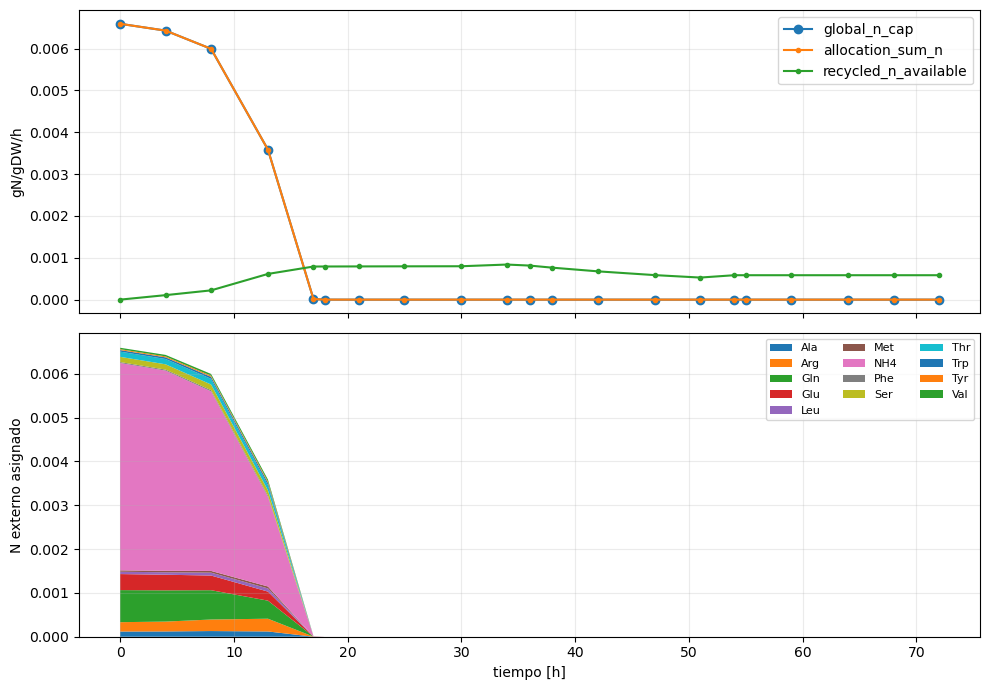

PASS: cap global de Zenteno respetado, reparto NCR coherente y bounds aplicados de forma estable.


In [20]:
phase5_abs_tol = 1e-9
phase5_trajectory_available = (
    "states_df_phase" in globals()
    and states_df_phase is not None
    and len(states_df_phase) > 0
    and "t_h" in states_df_phase.columns
)

if phase5_trajectory_available:
    phase5_t_values = np.asarray(states_df_phase["t_h"].to_numpy(dtype=float), dtype=float)
    phase5_t_values = np.unique(phase5_t_values[np.isfinite(phase5_t_values)])
    if len(phase5_t_values) == 0:
        phase5_trajectory_available = False
        phase5_audit_times = [0.0]
    else:
        phase5_representative_idx = {
            0,
            int(round(0.05 * (len(phase5_t_values) - 1))),
            int(round(0.25 * (len(phase5_t_values) - 1))),
            int(round(0.50 * (len(phase5_t_values) - 1))),
            int(round(0.75 * (len(phase5_t_values) - 1))),
            len(phase5_t_values) - 1,
        }
        phase5_mesh_idx = set(np.linspace(0, len(phase5_t_values) - 1, min(18, len(phase5_t_values))).round().astype(int))
        phase5_idx = sorted(phase5_representative_idx | phase5_mesh_idx)
        phase5_audit_times = [float(phase5_t_values[i]) for i in phase5_idx]
else:
    phase5_audit_times = [0.0]

phase5_rows = []
phase5_source_rows = []
phase5_failures = []
phase5_warnings = []
phase5_prev_state = None
phase5_prev_phase = None

if not phase5_trajectory_available:
    phase5_warnings.append({"time": 0.0, "notes": ["states_df_phase no disponible; auditoría limitada al snapshot inicial."]})

for t_probe in phase5_audit_times:
    if phase5_trajectory_available:
        snap = build_mechanistic_snapshot_model(
            t_probe,
            solve=True,
            exact_time=False,
            prev_state=phase5_prev_state,
            prev_phase=phase5_prev_phase,
        )
    else:
        snap = build_mechanistic_initial_snapshot_model(
            solve=True,
            prev_state=phase5_prev_state,
            prev_phase=phase5_prev_phase,
        )

    sol = snap.get("solution")
    solver_status = getattr(sol, "status", None)
    try:
        objective_value = float(sol.objective_value)
    except (AttributeError, TypeError, ValueError):
        objective_value = np.nan

    indicators = snap.get("phase_indicators", {}) or {}
    module = snap.get("nitrogen_allocation_module", {}) or {}
    global_cap = module.get("global_cap", {}) or {}
    source_map = module.get("source_map", {}).get("nitrogen_source_map", {}) or {}
    ncr_signals = module.get("ncr_signals", {}) or {}
    weights = module.get("weights", {}) or {}
    allocation = module.get("allocation", {}) or {}
    combined = module.get("combined_supply", {}) or {}
    application = snap.get("nitrogen_allocation_application", {}) or {}

    global_n_cap = _phase5_safe_float(snap.get("global_nitrogen_cap"), default=np.nan)
    allocation_sum_n = _phase5_safe_float(allocation.get("allocation_sum_n"), default=np.nan)
    allocation_residual_n = _phase5_safe_float(allocation.get("allocation_residual_n"), default=np.nan)
    recycled_n_available = _phase5_safe_float(snap.get("recycled_nitrogen_available"), default=np.nan)
    recycled_n_used = _phase5_safe_float(snap.get("recycled_nitrogen_used"), default=np.nan)

    row_issues = []
    row_notes = []
    if not bool(snap.get("global_nitrogen_cap_valid")):
        row_issues.append("global_nitrogen_cap_valid=False")
    if not bool(snap.get("nitrogen_source_map_valid")):
        row_issues.append("nitrogen_source_map_valid=False")
    if not bool(snap.get("ncr_signals_valid")):
        row_issues.append("ncr_signals_valid=False")
    if not bool(snap.get("ncr_allocation_weights_valid")):
        row_issues.append("ncr_allocation_weights_valid=False")
    if not bool(snap.get("nitrogen_allocation_valid")):
        row_issues.append("nitrogen_allocation_valid=False")
    if not bool(snap.get("nitrogen_allocation_application_valid")):
        row_issues.append(f"application_valid=False ({snap.get('nitrogen_allocation_application_status')})")
    if not np.isfinite(global_n_cap) or global_n_cap < -phase5_abs_tol:
        row_issues.append(f"global_n_cap inválido: {global_n_cap}")
    if np.isfinite(global_n_cap) and np.isfinite(allocation_sum_n):
        if allocation_sum_n > global_n_cap + 1e-8:
            row_issues.append(f"cap global violado: allocated={allocation_sum_n:.6g}, cap={global_n_cap:.6g}")
    else:
        row_issues.append("allocation_sum_n/global_n_cap no comparables")
    if any(v < -phase5_abs_tol for v in allocation.get("source_n_caps", {}).values()):
        row_issues.append("hay source_n_caps negativos")
    if recycled_n_used > recycled_n_available + 1e-8:
        row_issues.append(f"N reciclado usado excede disponible: used={recycled_n_used}, available={recycled_n_available}")
    if solver_status != "optimal":
        row_issues.append(f"solver_status={solver_status}")
    if allocation_residual_n > max(1e-8, 0.05 * max(global_n_cap, 1e-12)):
        row_notes.append(f"residual de asignación externo alto: {allocation_residual_n:.6g}")
    if module.get("notes"):
        row_notes.extend(str(note) for note in module.get("notes", []))
    if application.get("application_notes"):
        row_notes.extend(str(note) for note in application.get("application_notes", []))

    source_weights = weights.get("source_weights", {}) or {}
    source_n_caps = allocation.get("source_n_caps", {}) or {}
    source_flux_caps = allocation.get("source_flux_caps", {}) or {}
    combined_supply = combined.get("combined_n_supply", {}) or {}
    for rid, src in source_map.items():
        phase5_source_rows.append({
            "time": float(snap.get("actual_t_h", t_probe)),
            "phase_label": snap.get("phase_label"),
            "reaction_id": rid,
            "label": src.get("label", rid),
            "ncr_class": src.get("ncr_class"),
            "source_weight": source_weights.get(rid, np.nan),
            "external_n_cap": source_n_caps.get(rid, np.nan),
            "external_flux_cap": source_flux_caps.get(rid, np.nan),
            "recycled_n_cap": (combined_supply.get(rid, {}) or {}).get("recycled_n_cap", np.nan),
            "combined_n_cap": (combined_supply.get(rid, {}) or {}).get("combined_n_cap", np.nan),
        })

    if row_issues:
        diagnostic = "FAIL"
        phase5_failures.append({"time": snap.get("actual_t_h", t_probe), "issues": row_issues})
    elif row_notes:
        diagnostic = "WARNING"
        phase5_warnings.append({"time": snap.get("actual_t_h", t_probe), "notes": row_notes})
    else:
        diagnostic = "PASS"

    phase5_rows.append({
        "time": float(snap.get("actual_t_h", t_probe)),
        "phase_label": snap.get("phase_label"),
        "global_n_cap": global_n_cap,
        "global_n_cap_basis": snap.get("global_nitrogen_cap_basis"),
        "n_free": indicators.get("n_free"),
        "n_total": indicators.get("n_total"),
        "preferred_n_signal": ncr_signals.get("preferred_n_signal"),
        "nitrogen_starvation_signal": ncr_signals.get("nitrogen_starvation_signal"),
        "phase_n_signal": ncr_signals.get("phase_n_signal"),
        "recycled_n_signal": ncr_signals.get("recycled_n_signal"),
        "recycled_n_available": recycled_n_available,
        "recycled_n_used": recycled_n_used,
        "allocation_sum_n": allocation_sum_n,
        "allocation_residual_n": allocation_residual_n,
        "allocation_valid": snap.get("nitrogen_allocation_valid"),
        "application_valid": snap.get("nitrogen_allocation_application_valid"),
        "application_status": snap.get("nitrogen_allocation_application_status"),
        "n_sources": len(source_map),
        "n_applied_bounds": len(application.get("applied_bounds", []) or []),
        "solver_status": solver_status,
        "objective_value": objective_value,
        "diagnostic": diagnostic,
        "diagnostic_notes": "; ".join(row_notes + row_issues),
    })

    phase5_prev_state = snap.get("state")
    phase5_prev_phase = snap.get("phase_label")

mechanistic_phase5_audit_df = pd.DataFrame(phase5_rows)
mechanistic_phase5_source_allocation_df = pd.DataFrame(phase5_source_rows)
display(mechanistic_phase5_audit_df)
display(mechanistic_phase5_source_allocation_df)

response_notes = []
if not mechanistic_phase5_source_allocation_df.empty:
    rich = mechanistic_phase5_audit_df.sort_values("preferred_n_signal", ascending=False).head(max(1, len(mechanistic_phase5_audit_df)//4))["time"]
    starved = mechanistic_phase5_audit_df.sort_values("nitrogen_starvation_signal", ascending=False).head(max(1, len(mechanistic_phase5_audit_df)//4))["time"]
    rich_sources = mechanistic_phase5_source_allocation_df[mechanistic_phase5_source_allocation_df["time"].isin(rich)]
    starved_sources = mechanistic_phase5_source_allocation_df[mechanistic_phase5_source_allocation_df["time"].isin(starved)]
    preferred_classes = {"preferred", "preferred_amino"}
    late_classes = {"secondary_amino", "late_amino", "aromatic_late"}
    rich_pref = rich_sources[rich_sources["ncr_class"].isin(preferred_classes)]["source_weight"].mean()
    starved_pref = starved_sources[starved_sources["ncr_class"].isin(preferred_classes)]["source_weight"].mean()
    rich_late = rich_sources[rich_sources["ncr_class"].isin(late_classes)]["source_weight"].mean()
    starved_late = starved_sources[starved_sources["ncr_class"].isin(late_classes)]["source_weight"].mean()
    response_notes.append(f"peso preferente rico={rich_pref:.4g}; starvation={starved_pref:.4g}")
    response_notes.append(f"peso tardío rico={rich_late:.4g}; starvation={starved_late:.4g}")
    if np.isfinite(starved_late) and np.isfinite(rich_late) and starved_late + 1e-12 < rich_late:
        phase5_warnings.append({"time": np.nan, "notes": ["fuentes tardías no aumentan bajo starvation; revisar NCR_CLASS_DEFAULTS"]})

print("Diagnóstico de respuesta N/NCR:")
for note in response_notes:
    print(f"- {note}")

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    axes[0].plot(mechanistic_phase5_audit_df["time"], mechanistic_phase5_audit_df["global_n_cap"], marker="o", label="global_n_cap")
    axes[0].plot(mechanistic_phase5_audit_df["time"], mechanistic_phase5_audit_df["allocation_sum_n"], marker=".", label="allocation_sum_n")
    axes[0].plot(mechanistic_phase5_audit_df["time"], mechanistic_phase5_audit_df["recycled_n_available"], marker=".", label="recycled_n_available")
    axes[0].set_ylabel("gN/gDW/h")
    axes[0].legend(loc="best")
    axes[0].grid(True, alpha=0.25)

    if not mechanistic_phase5_source_allocation_df.empty:
        pivot = mechanistic_phase5_source_allocation_df.pivot_table(
            index="time",
            columns="label",
            values="external_n_cap",
            aggfunc="sum",
            fill_value=0.0,
        ).sort_index()
        axes[1].stackplot(pivot.index.to_numpy(dtype=float), [pivot[col].to_numpy(dtype=float) for col in pivot.columns], labels=list(pivot.columns))
        axes[1].legend(loc="upper right", ncol=3, fontsize=8)
    axes[1].set_xlabel("tiempo [h]")
    axes[1].set_ylabel("N externo asignado")
    axes[1].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[WARN] No se pudo generar gráfico matplotlib: {exc}")

if phase5_failures:
    print("FAIL: módulo N global + NCR presenta inconsistencias graves.")
    for failure in phase5_failures:
        print(f"- t={failure['time']}: " + "; ".join(failure["issues"]))
    warnings.warn("Auditoría Fase 5 falló; revisar `mechanistic_phase5_audit_df`.", RuntimeWarning)
elif phase5_warnings:
    print("WARNING: módulo Fase 5 estable pero con observaciones auditables.")
    for warning in phase5_warnings[:12]:
        print(f"- t={warning['time']}: " + "; ".join(warning["notes"][:4]))
    if len(phase5_warnings) > 12:
        print(f"- ... {len(phase5_warnings) - 12} observaciones adicionales en diagnostic_notes")
    warnings.warn("Auditoría Fase 5 con observaciones; revisar notas y asignaciones.", RuntimeWarning)
else:
    print("PASS: cap global de Zenteno respetado, reparto NCR coherente y bounds aplicados de forma estable.")


### Interpretación esperada de la Fase 5

La Fase 5 agregó una capa jerárquica de nitrógeno: Zenteno conserva el cap global externo y NCR reparte ese cap entre fuentes específicas. El nitrógeno reciclado desde turnover se mantiene separado como suministro interno y se registra junto al suministro externo.

Respecto de Fase 4, el turnover ya no vive aislado como pool reciclable: ahora el módulo de N/NCR lo integra en una estructura de suministro combinado, sin inflar el cap externo de Zenteno. Los bounds aplicados al snapshot reflejan la suma de fuente externa asignada y, cuando corresponde, aporte reciclado mapeado a la misma reacción.

La evidencia de funcionamiento queda en `mechanistic_phase5_audit_df` y `mechanistic_phase5_source_allocation_df`: la suma externa asignada debe ser menor o igual al cap global, los caps por fuente deben ser no negativos, las fuentes tardías deberían ganar peso bajo starvation, y el solver debe seguir óptimo.

Las limitaciones restantes son deliberadas: NCR es una regla operacional simplificada, no una red TOR/GATA completa; el reciclaje interno se mapea a bounds cuando hay reacciones disponibles; y todavía no hay objetivos lexicográficos que usen explícitamente la calidad de fuente nitrogenada.

En Fase 6 se espera usar esta asignación fina para acoplar rutas dependientes de aminoácidos, especialmente Ehrlich/benzenoides/ésteres, y para introducir prioridades de objetivos o penalizaciones dependientes del estado nitrogenado.


### Fase 6 - Resolución lexicográfica explícita por fase

La Fase 6 reemplaza el uso operativo de un objetivo único por una resolución lexicográfica explícita, dependiente de la fase fisiológica del snapshot. Cada fase define una secuencia ordenada de objetivos y cada etapa preserva el óptimo de las anteriores antes de resolver la siguiente.

Un objetivo único es insuficiente para la arquitectura mecanística ya construida: crecimiento, mantenimiento, transición por limitación de N, stationary y decay no deberían resolverse con la misma prioridad fisiológica. La clasificación de Fase 2, la biomasa/GAM de Fase 3, el turnover de Fase 4 y el reparto NCR de Fase 5 ahora alimentan una política de optimización por fase.

En este contexto, “lexicográfico” significa resolver primero el objetivo de mayor prioridad, fijar o preservar su óptimo dentro de tolerancias configurables, y luego resolver objetivos secundarios o una etapa final tipo pFBA/minimización de flujo. Esto conserva jerarquía: un objetivo secundario no puede mejorar a costa de degradar de forma relevante el objetivo primario.

Al auditar esperamos observar una política asignada para cada fase, etapas resueltas con status explícito, restricciones de preservación entre etapas, uso claro de fallback si falta un objetivo, y snapshots que sigan resolviendo. Se conserva el kernel Zenteno y los módulos mecanísticos previos; esta fase cambia la estrategia de optimización del snapshot, no el integrador dinámico global.


In [21]:
PHASE6_LEXICOGRAPHIC_SOLVER_VERSION = "phase6_explicit_phase_lexicographic_solver_v1"

if "_call_with_supported_kwargs" not in globals():
    import inspect

    def _call_with_supported_kwargs(func, *args, **kwargs):
        try:
            signature = inspect.signature(func)
            params = signature.parameters
            if not any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values()):
                kwargs = {key: value for key, value in kwargs.items() if key in params}
        except (TypeError, ValueError):
            pass
        return func(*args, **kwargs)

if "_PHASE5_BUILD_MECHANISTIC_SNAPSHOT_MODEL" not in globals():
    _PHASE5_BUILD_MECHANISTIC_SNAPSHOT_MODEL = build_mechanistic_snapshot_model
if "_PHASE5_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL" not in globals():
    _PHASE5_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL = build_mechanistic_initial_snapshot_model

LEXICOGRAPHIC_SOLVER_DEFAULTS = {
    "parameterization_note": "v1 operacional: resolución lexicográfica por fase con preservación relajada de óptimos",
    "preserve_fraction": 0.999999,
    "preserve_abs_tol": 1e-8,
    "preserve_rel_tol": 1e-7,
    "acceptable_statuses": ("optimal",),
    "skip_invalid_objectives": True,
    "fallback_to_legacy_optimize": True,
    "fallback_objective_alias": "legacy_primary",
    "enable_pfba_final": True,
    "pfba_stage_id": "pfba_min_flux",
    "constraint_prefix": "phase6_lex",
    "objective_aliases": {
        "legacy_primary": "meta.objective_id",
        "biomass": globals().get("OBJ_ID", "r_2111"),
        "maintenance_atp": globals().get("ATPM_ID", "r_4046"),
        "protein_proxy": globals().get("PROT_RXN_ID", "r_4047"),
    },
}

PHASE_OBJECTIVE_POLICY_DEFAULTS = {
    "F0_LAG_OSMO": [
        {"id": "maintenance_atp", "sense": "max", "role": "primary_maintenance_adaptation", "optional": True},
        {"id": "legacy_primary", "sense": "max", "role": "secondary_legacy_continuity", "optional": True},
        {"id": "pfba_min_flux", "sense": "min", "role": "final_efficiency", "type": "pfba", "optional": True},
    ],
    "F1_EXP_GROWTH": [
        {"id": "legacy_primary", "sense": "max", "role": "primary_growth", "optional": False},
        {"id": "protein_proxy", "sense": "max", "role": "secondary_protein_capacity", "optional": True},
        {"id": "maintenance_atp", "sense": "max", "role": "tertiary_energy_capacity", "optional": True},
        {"id": "pfba_min_flux", "sense": "min", "role": "final_efficiency", "type": "pfba", "optional": True},
    ],
    "F2_N_LIMITED_CARB_ACC": [
        {"id": "legacy_primary", "sense": "max", "role": "primary_legacy_growth_under_n_limit", "optional": False},
        {"id": "protein_proxy", "sense": "max", "role": "secondary_functional_protein_proxy", "optional": True},
        {"id": "maintenance_atp", "sense": "max", "role": "tertiary_energy_conservation", "optional": True},
        {"id": "pfba_min_flux", "sense": "min", "role": "final_efficiency", "type": "pfba", "optional": True},
    ],
    "F3_STATIONARY": [
        {"id": "legacy_primary", "sense": "max", "role": "primary_stationary_maintenance", "optional": False},
        {"id": "maintenance_atp", "sense": "max", "role": "secondary_survival_energy", "optional": True},
        {"id": "protein_proxy", "sense": "max", "role": "tertiary_repair_proxy", "optional": True},
        {"id": "pfba_min_flux", "sense": "min", "role": "final_efficiency", "type": "pfba", "optional": True},
    ],
    "F4_DECAY": [
        {"id": "legacy_primary", "sense": "max", "role": "primary_residual_maintenance", "optional": False},
        {"id": "maintenance_atp", "sense": "max", "role": "secondary_viability_residual", "optional": True},
        {"id": "pfba_min_flux", "sense": "min", "role": "final_efficiency", "type": "pfba", "optional": True},
    ],
}


def _phase6_merge_solver_config(config=None):
    """Combina configuración default del resolvedor lexicográfico con overrides."""
    cfg = dict(LEXICOGRAPHIC_SOLVER_DEFAULTS)
    cfg["objective_aliases"] = dict(LEXICOGRAPHIC_SOLVER_DEFAULTS["objective_aliases"])
    if config:
        for key, value in dict(config).items():
            if key == "objective_aliases":
                merged = dict(cfg[key])
                merged.update(dict(value))
                cfg[key] = merged
            else:
                cfg[key] = value
    return cfg


def _phase6_public_stage_result(stage_result):
    """Devuelve una copia serializable de una etapa sin guardar el objeto Solution."""
    public = dict(stage_result)
    public.pop("stage_solution", None)
    public.pop("objective_expr", None)
    return public


def build_phase_objective_policy(phase_label, meta=None, mdl=None, config=None):
    """Construye la política lexicográfica explícita para una fase fisiológica.

    Parameters
    ----------
    phase_label : str
        Fase canónica del snapshot.
    meta : dict, optional
        Metadata del snapshot. Se usa para resolver `legacy_primary`.
    mdl : cobra.Model, optional
        Modelo del snapshot. Si se entrega, la función anota disponibilidad
        preliminar de reacciones objetivo.
    config : dict, optional
        Overrides de `LEXICOGRAPHIC_SOLVER_DEFAULTS`.

    Returns
    -------
    dict
        Diccionario con `phase_objective_policy`, `objective_sequence`,
        `policy_valid` y `policy_notes`.
    """
    cfg = _phase6_merge_solver_config(config)
    meta = {} if meta is None else dict(meta)
    notes = []
    if phase_label not in PHASE_OBJECTIVE_POLICY_DEFAULTS:
        sequence = list(PHASE_OBJECTIVE_POLICY_DEFAULTS["F1_EXP_GROWTH"])
        notes.append(f"fase sin política explícita: {phase_label}; se usa F1_EXP_GROWTH como fallback")
    else:
        sequence = list(PHASE_OBJECTIVE_POLICY_DEFAULTS[phase_label])

    if not bool(cfg.get("enable_pfba_final", True)):
        sequence = [stage for stage in sequence if stage.get("type") != "pfba"]
        notes.append("etapa pFBA final deshabilitada por configuración")

    modeling_config_source = meta.get("modeling_config") if isinstance(meta.get("modeling_config"), dict) else None
    if modeling_config_source is None and isinstance(config, dict) and ("mode" in config or "phase_policy" in config):
        modeling_config_source = config
    _policy_mode = (
        dict(modeling_config_source or {}).get("mode")
        or meta.get("modeling_config_mode")
        or meta.get("mode")
        or "strict"
    )
    raw_policy_mode = _policy_mode
    _policy_mode = _normalize_modeling_config_mode(_policy_mode) if "_normalize_modeling_config_mode" in globals() else (
        _policy_mode if _policy_mode in MODEL_CONFIG_MODE_OVERRIDES else "strict"
    )
    if raw_policy_mode != _policy_mode:
        notes.append(f"modo legacy de snapshot {raw_policy_mode!r} interpretado como configuraci?n {_policy_mode!r}")
    modeling_config = build_modeling_config(
        base_config=modeling_config_source if isinstance(modeling_config_source, dict) else None,
        mode=_policy_mode,
    )
    phase_policy = modeling_config.get("phase_policy", {})
    mode = modeling_config.get("mode", "strict")
    lag_objective_policy_applied = False
    lag_biomass_objective_removed = False
    no_biomass_primary_objective_in_lag = bool(phase_policy.get("no_biomass_primary_objective_in_lag", True))
    biomass_rxn_id_for_policy = None

    if phase_label == "F0_LAG_OSMO" and mode in ("strict", "diagnostic"):
        lag_objective_policy_applied = True
        biomass_rxn_id_for_policy, biomass_msg = get_biomass_reaction_id(mdl, config=modeling_config) if "get_biomass_reaction_id" in globals() else (globals().get("OBJ_ID", "r_2111"), "fallback OBJ_ID")
        biomass_aliases = {"biomass", "legacy_primary", globals().get("OBJ_ID", "r_2111"), "r_2111", biomass_rxn_id_for_policy}
        if no_biomass_primary_objective_in_lag:
            filtered = []
            removed = []
            for stage in sequence:
                item = dict(stage)
                alias = item.get("id")
                obj_type = item.get("type", "reaction")
                resolved_id = cfg["objective_aliases"].get(alias, alias)
                if resolved_id == "meta.objective_id":
                    resolved_id = meta.get("objective_id", meta.get("base_objective_id", globals().get("OBJ_ID", "r_2111")))
                is_biomass_stage = bool(obj_type == "reaction" and (alias in biomass_aliases or resolved_id in biomass_aliases))
                if is_biomass_stage:
                    removed.append({"id": alias, "resolved_reaction_id": resolved_id, "role": item.get("role")})
                    continue
                filtered.append(item)
            if removed:
                sequence = filtered
                lag_biomass_objective_removed = True
                notes.append(f"F0_LAG_OSMO: objetivos de biomasa removidos/degradados por política lag: {removed}")
            else:
                notes.append("F0_LAG_OSMO: no se detectaron etapas de biomasa explícitas en la política objetivo")
        notes.append("F0_LAG_OSMO: biomasa no se usa como objetivo primario en strict/diagnostic; crecimiento queda capado por phase_growth_policy")

    rxns = reaction_map(mdl) if mdl is not None else {}
    enriched = []
    seen = set()
    for i, stage in enumerate(sequence):
        item = dict(stage)
        item.setdefault("stage_index", i)
        item.setdefault("type", "reaction")
        item.setdefault("optional", True)
        alias = item.get("id")
        if item.get("type") == "reaction":
            resolved_id = cfg["objective_aliases"].get(alias, alias)
            if resolved_id == "meta.objective_id":
                resolved_id = meta.get("objective_id", meta.get("base_objective_id", globals().get("OBJ_ID", "r_2111")))
            item["resolved_reaction_id_hint"] = resolved_id
            item["available_hint"] = (not rxns) or (resolved_id in rxns)
            dedup_key = (item.get("type"), resolved_id, item.get("sense", "max"))
            if dedup_key in seen:
                notes.append(f"etapa duplicada omitida en política: {alias}->{resolved_id}")
                continue
            seen.add(dedup_key)
        else:
            item["available_hint"] = True
            dedup_key = (item.get("type"), item.get("id"))
            if dedup_key in seen:
                continue
            seen.add(dedup_key)
        enriched.append(item)

    valid = bool(enriched)
    if not valid:
        notes.append("política sin etapas después de filtrado")
    return {
        "phase_objective_policy": {
            "phase_label": phase_label,
            "solver_version": PHASE6_LEXICOGRAPHIC_SOLVER_VERSION,
            "preserve_fraction": cfg["preserve_fraction"],
            "preserve_abs_tol": cfg["preserve_abs_tol"],
            "preserve_rel_tol": cfg["preserve_rel_tol"],
            "mode": mode,
            "no_biomass_primary_objective_in_lag": bool(no_biomass_primary_objective_in_lag),
            "lag_objective_policy_applied": bool(lag_objective_policy_applied),
            "lag_biomass_objective_removed": bool(lag_biomass_objective_removed),
            "biomass_rxn_id": biomass_rxn_id_for_policy,
        },
        "objective_sequence": enriched,
        "policy_valid": valid,
        "policy_notes": notes,
    }


def resolve_objective_expression(mdl, objective_spec, meta=None, config=None):
    """Traduce un alias o especificación de objetivo en una expresión optlang usable."""
    cfg = _phase6_merge_solver_config(config)
    meta = {} if meta is None else dict(meta)
    spec = dict(objective_spec)
    notes = []
    obj_type = spec.get("type", "reaction")
    sense = spec.get("sense", "max")
    alias = spec.get("id")

    if obj_type == "pfba":
        return {
            "objective_expr": None,
            "objective_sense": "min",
            "objective_id": alias,
            "objective_type": "pfba",
            "objective_valid": True,
            "objective_notes": notes,
        }

    resolved_id = cfg["objective_aliases"].get(alias, alias)
    if resolved_id == "meta.objective_id":
        resolved_id = meta.get("objective_id", meta.get("base_objective_id", globals().get("OBJ_ID", "r_2111")))
        notes.append(f"legacy_primary resuelto como {resolved_id}")

    rxns = reaction_map(mdl)
    if resolved_id not in rxns:
        return {
            "objective_expr": None,
            "objective_sense": sense,
            "objective_id": resolved_id,
            "objective_type": "reaction",
            "objective_valid": False,
            "objective_notes": notes + [f"reacción objetivo no disponible: {resolved_id}"],
        }

    rxn = rxns[resolved_id]
    return {
        "objective_expr": rxn.flux_expression,
        "objective_sense": sense,
        "objective_id": resolved_id,
        "objective_type": "reaction",
        "objective_valid": True,
        "objective_notes": notes,
    }


def solve_single_objective_stage(mdl, objective_info, inherited_constraints=None, config=None, stage_meta=None):
    """Resuelve una etapa individual de la secuencia lexicográfica.

    La función no oculta fallos: si el objetivo no es válido o el solver no
    retorna un estado aceptable, la etapa queda marcada con `stage_valid=False`.
    """
    cfg = _phase6_merge_solver_config(config)
    inherited_constraints = [] if inherited_constraints is None else list(inherited_constraints)
    stage_meta = {} if stage_meta is None else dict(stage_meta)
    notes = list(objective_info.get("objective_notes", []))
    stage_id = stage_meta.get("stage_id", objective_info.get("objective_id"))
    sol = None
    obj_value = np.nan
    status = None

    if not objective_info.get("objective_valid", False):
        return {
            "stage_id": stage_id,
            "objective_id": objective_info.get("objective_id"),
            "objective_sense": objective_info.get("objective_sense"),
            "objective_type": objective_info.get("objective_type"),
            "stage_solution": None,
            "stage_status": "skipped_invalid_objective",
            "stage_objective_value": np.nan,
            "stage_constraints_added": list(inherited_constraints),
            "stage_valid": False,
            "stage_notes": notes,
        }

    try:
        if objective_info.get("objective_type") == "pfba":
            try:
                from cobra.flux_analysis import pfba
                sol = pfba(mdl)
                notes.append("pFBA ejecutado como etapa final de minimización de flujo")
            except Exception as exc:
                notes.append(f"pFBA falló; fallback a mdl.optimize(): {exc}")
                sol = mdl.optimize()
        else:
            mdl.objective = objective_info["objective_expr"]
            mdl.objective_direction = objective_info.get("objective_sense", "max")
            sol = mdl.optimize()
        status = getattr(sol, "status", None)
        obj_value = float(sol.objective_value) if getattr(sol, "objective_value", None) is not None else np.nan
    except Exception as exc:
        notes.append(f"excepción al resolver etapa: {exc}")
        status = "exception"
        sol = None
        obj_value = np.nan

    valid = bool(status in tuple(cfg["acceptable_statuses"]) and np.isfinite(obj_value))
    if not valid:
        notes.append(f"etapa no válida: status={status}, objective_value={obj_value}")

    return {
        "stage_id": stage_id,
        "objective_id": objective_info.get("objective_id"),
        "objective_sense": objective_info.get("objective_sense"),
        "objective_type": objective_info.get("objective_type"),
        "objective_expr": objective_info.get("objective_expr"),
        "stage_solution": sol,
        "stage_status": status,
        "stage_objective_value": obj_value,
        "stage_constraints_added": list(inherited_constraints),
        "stage_valid": valid,
        "stage_notes": notes,
    }


def build_optimum_preservation_constraints(mdl, objective_info, optimum_value, stage_index=0, config=None):
    """Agrega una restricción para preservar el óptimo de una etapa previa.

    Para maximización agrega `objective >= optimum - tol`; para minimización
    agrega `objective <= optimum + tol`. La tolerancia combina componente
    absoluta, relativa y fracción mínima de preservación.
    """
    cfg = _phase6_merge_solver_config(config)
    notes = []
    if objective_info.get("objective_type") != "reaction" or objective_info.get("objective_expr") is None:
        return {
            "preservation_constraints": [],
            "preserved_objective_id": objective_info.get("objective_id"),
            "preservation_valid": False,
            "preservation_notes": ["no se agrega preservación para objetivo no lineal/pFBA"],
        }
    if not np.isfinite(optimum_value):
        return {
            "preservation_constraints": [],
            "preserved_objective_id": objective_info.get("objective_id"),
            "preservation_valid": False,
            "preservation_notes": ["optimum_value no finito; no se preserva"],
        }

    sense = objective_info.get("objective_sense", "max")
    tol = float(cfg["preserve_abs_tol"]) + float(cfg["preserve_rel_tol"]) * abs(float(optimum_value))
    preserve_fraction = float(cfg["preserve_fraction"])
    expr = objective_info["objective_expr"]
    name = f"{cfg['constraint_prefix']}_{stage_index}_{objective_info.get('objective_id')}_{sense}"
    name = re.sub(r"[^A-Za-z0-9_]+", "_", name)

    if sense == "max":
        lb = float(optimum_value) - tol
        if optimum_value > 0 and preserve_fraction < 1.0:
            lb = min(lb, float(optimum_value) * preserve_fraction)
        constraint = mdl.solver.interface.Constraint(expr, lb=lb, name=name)
        bound_info = {"lb": lb, "ub": None}
    elif sense == "min":
        ub = float(optimum_value) + tol
        constraint = mdl.solver.interface.Constraint(expr, ub=ub, name=name)
        bound_info = {"lb": None, "ub": ub}
    else:
        return {
            "preservation_constraints": [],
            "preserved_objective_id": objective_info.get("objective_id"),
            "preservation_valid": False,
            "preservation_notes": [f"sentido no soportado para preservación: {sense}"],
        }

    try:
        mdl.add_cons_vars([constraint])
        mdl.solver.update()
        valid = True
    except Exception as exc:
        notes.append(f"no se pudo agregar constraint de preservación: {exc}")
        valid = False

    return {
        "preservation_constraints": [{
            "name": name,
            "objective_id": objective_info.get("objective_id"),
            "objective_sense": sense,
            "optimum_value": float(optimum_value),
            "tolerance": float(tol),
            "preserve_fraction": preserve_fraction,
            **bound_info,
        }] if valid else [],
        "preserved_objective_id": objective_info.get("objective_id"),
        "preservation_valid": valid,
        "preservation_notes": notes,
    }


def run_phase_lexicographic_optimization(mdl, phase_label=None, meta=None, config=None):
    """Ejecuta la secuencia lexicográfica completa para una fase."""
    cfg = _phase6_merge_solver_config(config)
    meta = {} if meta is None else meta
    notes = []
    phase_label = phase_label or meta.get("phase_label", "F1_EXP_GROWTH")
    policy = build_phase_objective_policy(phase_label, meta=meta, mdl=mdl, config=cfg)
    stage_results = []
    public_stage_results = []
    solver_trace = []
    preservation_trace = []
    final_solution = None
    fallback_used = False
    inherited_constraints = []

    if not policy["policy_valid"]:
        notes.extend(policy["policy_notes"])
        notes.append("política inválida; se intentará fallback legacy")

    sequence = policy.get("objective_sequence", [])
    for i, spec in enumerate(sequence):
        obj_info = resolve_objective_expression(mdl, spec, meta=meta, config=cfg)
        if not obj_info.get("objective_valid", False) and bool(cfg.get("skip_invalid_objectives", True)) and spec.get("optional", True):
            skipped = {
                "stage_id": spec.get("id"),
                "objective_id": obj_info.get("objective_id"),
                "objective_sense": obj_info.get("objective_sense"),
                "objective_type": obj_info.get("objective_type"),
                "stage_status": "skipped_missing_optional_objective",
                "stage_objective_value": np.nan,
                "stage_constraints_added": [],
                "stage_valid": False,
                "stage_notes": obj_info.get("objective_notes", []),
            }
            public_stage_results.append(skipped)
            solver_trace.append(skipped)
            continue

        stage = solve_single_objective_stage(
            mdl,
            obj_info,
            inherited_constraints=inherited_constraints,
            config=cfg,
            stage_meta={"stage_id": spec.get("id"), "stage_index": i, "role": spec.get("role")},
        )
        stage["stage_role"] = spec.get("role")
        stage["stage_index"] = i
        stage_results.append(stage)
        public_stage = _phase6_public_stage_result(stage)
        public_stage_results.append(public_stage)
        solver_trace.append(public_stage)
        if stage.get("stage_valid"):
            final_solution = stage.get("stage_solution")
            if i < len(sequence) - 1 and obj_info.get("objective_type") == "reaction":
                preservation = build_optimum_preservation_constraints(
                    mdl,
                    obj_info,
                    stage.get("stage_objective_value"),
                    stage_index=i,
                    config=cfg,
                )
                preservation_trace.append(preservation)
                new_constraints = preservation.get("preservation_constraints", [])
                inherited_constraints.extend(new_constraints)
        else:
            notes.extend(stage.get("stage_notes", []))
            if not spec.get("optional", True):
                notes.append(f"etapa obligatoria falló: {spec.get('id')}")
                break

    valid_stage_results = [s for s in stage_results if s.get("stage_valid")]
    if not valid_stage_results and bool(cfg.get("fallback_to_legacy_optimize", True)):
        fallback_used = True
        notes.append("sin etapas válidas; se usa fallback legacy optimize")
        fallback_spec = {"id": cfg.get("fallback_objective_alias", "legacy_primary"), "sense": "max", "type": "reaction"}
        fallback_info = resolve_objective_expression(mdl, fallback_spec, meta=meta, config=cfg)
        fallback_stage = solve_single_objective_stage(
            mdl,
            fallback_info,
            inherited_constraints=[],
            config=cfg,
            stage_meta={"stage_id": "fallback_legacy_primary", "stage_index": 999, "role": "fallback"},
        )
        fallback_stage["stage_role"] = "fallback"
        stage_results.append(fallback_stage)
        public_stage_results.append(_phase6_public_stage_result(fallback_stage))
        solver_trace.append(_phase6_public_stage_result(fallback_stage))
        if fallback_stage.get("stage_valid"):
            final_solution = fallback_stage.get("stage_solution")
            valid_stage_results.append(fallback_stage)

    final_status = getattr(final_solution, "status", None)
    final_objective_value = (
        float(final_solution.objective_value)
        if final_solution is not None and getattr(final_solution, "objective_value", None) is not None
        else np.nan
    )
    lex_valid = bool(valid_stage_results and final_status in tuple(cfg["acceptable_statuses"]))
    if not lex_valid:
        notes.append(f"resolución lexicográfica no válida: final_status={final_status}, etapas_válidas={len(valid_stage_results)}")

    return {
        "final_solution": final_solution,
        "stage_results": public_stage_results,
        "policy_used": policy,
        "solver_trace": solver_trace,
        "preservation_trace": preservation_trace,
        "lexicographic_valid": lex_valid,
        "lexicographic_notes": notes,
        "final_status": final_status,
        "final_objective_value": final_objective_value,
        "fallback_strategy_used": fallback_used,
        "n_valid_stages": len(valid_stage_results),
    }


def solve_snapshot_lexicographic(mdl, meta, config=None):
    """Resuelve un snapshot con la estrategia lexicográfica explícita de Fase 6.

    Mantiene compatibilidad con los wrappers anteriores devolviendo el objeto
    `cobra.Solution` final, pero actualiza `meta` in-place con toda la traza
    lexicográfica auditable.
    """
    if meta is None or not isinstance(meta, dict):
        raise TypeError("meta debe ser un diccionario mutable para registrar la traza lexicográfica.")

    phase_label = meta.get("phase_label", "F1_EXP_GROWTH")
    legacy_objective = meta.get("objective_id")
    lex = run_phase_lexicographic_optimization(mdl, phase_label=phase_label, meta=meta, config=config)
    policy = lex.get("policy_used", {})
    sequence = policy.get("objective_sequence", [])
    first_reaction_stage = next((s for s in sequence if s.get("type", "reaction") == "reaction"), None)
    first_hint = None if first_reaction_stage is None else first_reaction_stage.get("resolved_reaction_id_hint")

    meta.update({
        "phase_objective_policy": policy,
        "phase_objective_policy_valid": policy.get("policy_valid"),
        "phase_objective_policy_notes": list(policy.get("policy_notes", [])),
        "lexicographic_stage_results": lex.get("stage_results", []),
        "lexicographic_solver_trace": lex.get("solver_trace", []),
        "lexicographic_preservation_trace": lex.get("preservation_trace", []),
        "lexicographic_final_status": lex.get("final_status"),
        "lexicographic_final_objective_value": lex.get("final_objective_value"),
        "lexicographic_valid": lex.get("lexicographic_valid"),
        "lexicographic_notes": list(lex.get("lexicographic_notes", [])),
        "legacy_objective_replaced": bool(first_hint is not None and legacy_objective is not None and first_hint != legacy_objective),
        "fallback_strategy_used": bool(lex.get("fallback_strategy_used", False)),
        "solver_strategy": "phase6_explicit_lexicographic_by_phase",
    })
    return lex.get("final_solution")


def _phase6_enrich_snapshot_with_lexicographic_solution(snapshot, solve=True, solver_config=None, config=None):
    """Resuelve un snapshot mecanístico Fase 5 con el resolvedor lexicográfico Fase 6."""
    mdl = snapshot["model"].copy()
    meta = dict(snapshot.get("meta", {}))
    meta.update({
        "mechanistic_layer_version": PHASE6_LEXICOGRAPHIC_SOLVER_VERSION,
        "mechanistic_changes_applied": list(snapshot.get("mechanistic_changes_applied", [])) + [
            "phase_lexicographic_optimization",
        ],
    })
    sol = solve_snapshot_lexicographic(mdl, meta, config=solver_config) if solve else None

    result = dict(snapshot)
    result["model"] = mdl
    result["solution"] = sol
    for key, value in meta.items():
        result[key] = value
    result["meta"] = dict(meta)
    return result


def build_mechanistic_snapshot_model(
    t_phase,
    solve=True,
    exact_time=False,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    nitrogen_params=None,
    config=None,
):
    """Construye snapshot mecanístico Fase 6 con resolución lexicográfica por fase."""
    phase5_snapshot = _call_with_supported_kwargs(
        _PHASE5_BUILD_MECHANISTIC_SNAPSHOT_MODEL,
        t_phase,
        solve=False,
        exact_time=exact_time,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        turnover_params=turnover_params,
        nitrogen_params=nitrogen_params,
        config=config,
    )
    return _phase6_enrich_snapshot_with_lexicographic_solution(
        phase5_snapshot,
        solve=solve,
        solver_config=solver_config,
        config=config,
    )


def build_mechanistic_initial_snapshot_model(
    solve=True,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    nitrogen_params=None,
    config=None,
):
    """Construye snapshot inicial Fase 6 con resolución lexicográfica por fase."""
    phase5_snapshot = _call_with_supported_kwargs(
        _PHASE5_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL,
        solve=False,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        turnover_params=turnover_params,
        nitrogen_params=nitrogen_params,
        config=config,
    )
    return _phase6_enrich_snapshot_with_lexicographic_solution(
        phase5_snapshot,
        solve=solve,
        solver_config=solver_config,
        config=config,
    )


MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    "classify_phase": "Clasificador fisiológico explícito conservado",
    "compute_phase_indicators": "Indicadores macroscópicos auditables",
    "compute_biomass_composition": "Módulo explícito de composición dinámica de biomasa",
    "compute_dynamic_gam": "Módulo explícito de GAM dependiente de composición",
    "compute_biomass_and_gam_module": "Wrapper composición + GAM",
    "compute_turnover_activation": "Activación fisiológica explícita de turnover proteico",
    "compute_turnover_flux": "Magnitud explícita de turnover proteico",
    "distribute_turnover_recycled_pool": "Distribución del pool reciclable hacia AA/N",
    "compute_protein_turnover_module": "Wrapper activación + flujo + pool reciclable",
    "compute_global_nitrogen_cap": "Cap global externo de N desde Zenteno",
    "build_nitrogen_source_map": "Mapa fuente de N -> reacción/clase NCR",
    "compute_ncr_signals": "Señales simplificadas tipo NCR",
    "compute_ncr_allocation_weights": "Pesos efectivos de asignación por fuente",
    "allocate_nitrogen_cap_across_sources": "Reparto del cap global entre fuentes",
    "merge_external_and_recycled_nitrogen_supply": "Mezcla N externo asignado + N reciclado interno",
    "apply_nitrogen_allocation_to_snapshot": "Aplicación de bounds NCR al snapshot",
    "compute_nitrogen_allocation_module": "Wrapper cap + fuente + NCR + reparto + reciclaje",
    "build_phase_objective_policy": "Construcción de política lexicográfica por fase",
    "resolve_objective_expression": "Resolución de alias de objetivo a expresión LP",
    "solve_single_objective_stage": "Resolución de una etapa lexicográfica",
    "build_optimum_preservation_constraints": "Construcción de constraints de preservación de óptimo",
    "run_phase_lexicographic_optimization": "Ejecución completa de resolución lexicográfica",
    "solve_snapshot_lexicographic": "Resolvedor lexicográfico explícito Fase 6",
    "build_mechanistic_snapshot_model": "Wrapper Fase 6 con objetivos lexicográficos",
    "build_mechanistic_initial_snapshot_model": "Wrapper inicial Fase 6 con objetivos lexicográficos",
    "LEXICOGRAPHIC_SOLVER_DEFAULTS": "Configuración auditable del resolvedor lexicográfico",
    "PHASE_OBJECTIVE_POLICY_DEFAULTS": "Políticas objetivo por fase",
}

print("Capa mecanística Fase 6 lista. Objetos principales:")
for name, desc in MECHANISTIC_DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:42s}: {desc} | {'OK' if name in globals() else 'MISSING'}")


Capa mecanística Fase 6 lista. Objetos principales:
- classify_phase                            : Clasificador fisiológico explícito conservado | OK
- compute_phase_indicators                  : Indicadores macroscópicos auditables | OK
- compute_biomass_composition               : Módulo explícito de composición dinámica de biomasa | OK
- compute_dynamic_gam                       : Módulo explícito de GAM dependiente de composición | OK
- compute_biomass_and_gam_module            : Wrapper composición + GAM | OK
- compute_turnover_activation               : Activación fisiológica explícita de turnover proteico | OK
- compute_turnover_flux                     : Magnitud explícita de turnover proteico | OK
- distribute_turnover_recycled_pool         : Distribución del pool reciclable hacia AA/N | OK
- compute_protein_turnover_module           : Wrapper activación + flujo + pool reciclable | OK
- compute_global_nitrogen_cap               : Cap global externo de N desde Zenteno | OK
- bui

,time,phase_label,policy_valid,n_policy_stages,n_stages,n_valid_stages,n_preservation_constraints,stage_ids,stage_statuses,stage_objective_values,final_status,final_objective_value,lexicographic_valid,fallback_strategy_used,legacy_objective_replaced,diagnostic,diagnostic_notes
0,0.0,F0_LAG_OSMO,True,3,3,3,2,maintenance_atp -> legacy_primary -> pfba_min_...,optimal -> optimal -> optimal,"[0.7, 0.07568034537613523, 79.60265666937332]",optimal,79.602657,True,False,True,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...
1,4.0,F1_EXP_GROWTH,True,4,4,4,3,legacy_primary -> protein_proxy -> maintenance...,optimal -> optimal -> optimal -> optimal,"[0.07505346274812898, 0.07505346274812882, 0.7...",optimal,114.248249,True,False,False,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...
2,5.0,F1_EXP_GROWTH,True,4,4,4,3,legacy_primary -> protein_proxy -> maintenance...,optimal -> optimal -> optimal -> optimal,"[0.07434608350472276, 0.07434608350471585, 0.7...",optimal,113.255889,True,False,False,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...
3,10.0,F1_EXP_GROWTH,True,4,4,4,3,legacy_primary -> protein_proxy -> maintenance...,optimal -> optimal -> optimal -> optimal,"[0.0672790586835688, 0.0672790586835671, 0.7, ...",optimal,100.571861,True,False,False,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...
4,14.0,F1_EXP_GROWTH,True,4,4,4,3,legacy_primary -> protein_proxy -> maintenance...,optimal -> optimal -> optimal -> optimal,"[0.03600969694703309, 0.03600969694703223, 0.7...",optimal,57.329106,True,False,False,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...
5,18.0,F1_EXP_GROWTH,True,4,4,4,3,legacy_primary -> protein_proxy -> maintenance...,optimal -> optimal -> optimal -> optimal,"[0.00997159703431728, 0.00997159703431708, 0.7...",optimal,24.525837,True,False,False,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...
6,19.0,F1_EXP_GROWTH,True,4,4,4,3,legacy_primary -> protein_proxy -> maintenance...,optimal -> optimal -> optimal -> optimal,"[0.009976581720189068, 0.009976581720189859, 0...",optimal,24.533707,True,False,False,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...
7,24.0,F1_EXP_GROWTH,True,4,4,4,3,legacy_primary -> protein_proxy -> maintenance...,optimal -> optimal -> optimal -> optimal,"[0.010007624365838524, 0.01000762436583862, 0....",optimal,24.578716,True,False,False,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...
8,29.0,F1_EXP_GROWTH,True,4,4,4,3,legacy_primary -> protein_proxy -> maintenance...,optimal -> optimal -> optimal -> optimal,"[0.010028944207260202, 0.010028944207260165, 0...",optimal,24.609625,True,False,False,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...
9,34.0,F2_N_LIMITED_CARB_ACC,True,4,4,4,3,legacy_primary -> protein_proxy -> maintenance...,optimal -> optimal -> optimal -> optimal,"[0.010462898084022067, 0.010462898084022275, 0...",optimal,25.238764,True,False,False,WARNING,legacy_primary resuelto como r_2111; pFBA ejec...


,time,phase_label,stage_index,stage_id,stage_role,objective_id,objective_sense,objective_type,stage_status,stage_objective_value,stage_valid,n_constraints_inherited,stage_notes
0,0.0,F0_LAG_OSMO,0,maintenance_atp,primary_maintenance_adaptation,r_4046,max,reaction,optimal,7.000000e-01,True,0,
1,0.0,F0_LAG_OSMO,1,legacy_primary,secondary_legacy_continuity,r_2111,max,reaction,optimal,7.568035e-02,True,1,legacy_primary resuelto como r_2111
2,0.0,F0_LAG_OSMO,2,pfba_min_flux,final_efficiency,pfba_min_flux,min,pfba,optimal,7.960266e+01,True,2,pFBA ejecutado como etapa final de minimizació...
3,4.0,F1_EXP_GROWTH,0,legacy_primary,primary_growth,r_2111,max,reaction,optimal,7.505346e-02,True,0,legacy_primary resuelto como r_2111
4,4.0,F1_EXP_GROWTH,1,protein_proxy,secondary_protein_capacity,r_4047,max,reaction,optimal,7.505346e-02,True,1,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,67.0,F3_STATIONARY,1,protein_proxy,tertiary_repair_proxy,r_4047,max,reaction,optimal,4.003668e-31,True,1,
69,67.0,F3_STATIONARY,2,pfba_min_flux,final_efficiency,pfba_min_flux,min,pfba,optimal,9.757909e+01,True,2,pFBA ejecutado como etapa final de minimizació...
70,72.0,F3_STATIONARY,0,legacy_primary,primary_stationary_maintenance,r_4046,max,reaction,optimal,6.196867e+00,True,0,legacy_primary resuelto como r_4046
71,72.0,F3_STATIONARY,1,protein_proxy,tertiary_repair_proxy,r_4047,max,reaction,optimal,4.003668e-31,True,1,


,phase_label,count,mean
0,F0_LAG_OSMO,1,3.000000
1,F1_EXP_GROWTH,8,4.000000
2,F2_N_LIMITED_CARB_ACC,6,3.833333
3,F3_STATIONARY,5,3.000000


Diagnóstico de resolución lexicográfica:
- fases auditadas: F0_LAG_OSMO(n=1, etapas_medias=3.00), F1_EXP_GROWTH(n=8, etapas_medias=4.00), F2_N_LIMITED_CARB_ACC(n=6, etapas_medias=3.83), F3_STATIONARY(n=5, etapas_medias=3.00)
- fracción con fallback=0.000


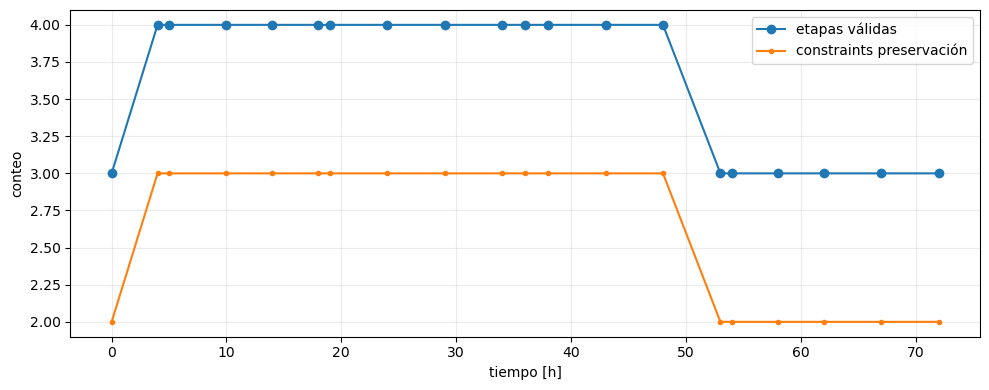

- t=0.0: legacy_primary resuelto como r_2111; pFBA ejecutado como etapa final de minimización de flujo
- t=4.0: legacy_primary resuelto como r_2111; pFBA ejecutado como etapa final de minimización de flujo
- t=5.0: legacy_primary resuelto como r_2111; pFBA ejecutado como etapa final de minimización de flujo
- t=10.0: legacy_primary resuelto como r_2111; pFBA ejecutado como etapa final de minimización de flujo
- t=14.0: legacy_primary resuelto como r_2111; pFBA ejecutado como etapa final de minimización de flujo
- t=18.0: legacy_primary resuelto como r_2111; pFBA ejecutado como etapa final de minimización de flujo
- t=19.0: legacy_primary resuelto como r_2111; pFBA ejecutado como etapa final de minimización de flujo
- t=24.0: legacy_primary resuelto como r_2111; pFBA ejecutado como etapa final de minimización de flujo
- t=29.0: legacy_primary resuelto como r_2111; pFBA ejecutado como etapa final de minimización de flujo
- t=34.0: legacy_primary resuelto como r_2111; pFBA ejecutado como 

C:\Users\ctorrealba\AppData\Local\Temp\ipykernel_26856\4201863238.py:195: RuntimeWarning: Auditoría Fase 6 con observaciones; revisar etapas y fallback.
  warnings.warn("Auditoría Fase 6 con observaciones; revisar etapas y fallback.", RuntimeWarning)


In [22]:
phase6_trajectory_available = (
    "states_df_phase" in globals()
    and states_df_phase is not None
    and len(states_df_phase) > 0
    and "t_h" in states_df_phase.columns
)

if phase6_trajectory_available:
    phase6_t_values = np.asarray(states_df_phase["t_h"].to_numpy(dtype=float), dtype=float)
    phase6_t_values = np.unique(phase6_t_values[np.isfinite(phase6_t_values)])
    if len(phase6_t_values) == 0:
        phase6_trajectory_available = False
        phase6_audit_times = [0.0]
    else:
        phase6_representative_idx = {
            0,
            int(round(0.05 * (len(phase6_t_values) - 1))),
            int(round(0.25 * (len(phase6_t_values) - 1))),
            int(round(0.50 * (len(phase6_t_values) - 1))),
            int(round(0.75 * (len(phase6_t_values) - 1))),
            len(phase6_t_values) - 1,
        }
        phase6_mesh_idx = set(np.linspace(0, len(phase6_t_values) - 1, min(16, len(phase6_t_values))).round().astype(int))
        phase6_idx = sorted(phase6_representative_idx | phase6_mesh_idx)
        phase6_audit_times = [float(phase6_t_values[i]) for i in phase6_idx]
else:
    phase6_audit_times = [0.0]

phase6_rows = []
phase6_stage_rows = []
phase6_failures = []
phase6_warnings = []
phase6_prev_state = None
phase6_prev_phase = None

if not phase6_trajectory_available:
    phase6_warnings.append({"time": 0.0, "notes": ["states_df_phase no disponible; auditoría limitada al snapshot inicial."]})

for t_probe in phase6_audit_times:
    if phase6_trajectory_available:
        snap = build_mechanistic_snapshot_model(
            t_probe,
            solve=True,
            exact_time=False,
            prev_state=phase6_prev_state,
            prev_phase=phase6_prev_phase,
        )
    else:
        snap = build_mechanistic_initial_snapshot_model(
            solve=True,
            prev_state=phase6_prev_state,
            prev_phase=phase6_prev_phase,
        )

    policy = snap.get("phase_objective_policy", {}) or {}
    sequence = policy.get("objective_sequence", []) or []
    stages = snap.get("lexicographic_stage_results", []) or []
    preservation = snap.get("lexicographic_preservation_trace", []) or []
    sol = snap.get("solution")
    final_status = snap.get("lexicographic_final_status", getattr(sol, "status", None))
    final_objective_value = _phase5_safe_float(snap.get("lexicographic_final_objective_value"), default=np.nan)
    phase_label = snap.get("phase_label")

    stage_ids = [str(stage.get("stage_id")) for stage in stages]
    stage_statuses = [str(stage.get("stage_status")) for stage in stages]
    stage_values = [stage.get("stage_objective_value") for stage in stages]
    valid_stage_count = sum(bool(stage.get("stage_valid")) for stage in stages)
    preservation_count = sum(len(p.get("preservation_constraints", []) or []) for p in preservation)

    row_issues = []
    row_notes = []
    if phase_label not in PHASE_OBJECTIVE_POLICY_DEFAULTS:
        row_issues.append(f"fase sin política default: {phase_label}")
    if not bool(snap.get("phase_objective_policy_valid")):
        row_issues.append("phase_objective_policy_valid=False")
    if not sequence:
        row_issues.append("secuencia objetivo vacía")
    if not stages:
        row_issues.append("sin stage_results")
    if valid_stage_count == 0:
        row_issues.append("ninguna etapa válida")
    if not bool(snap.get("lexicographic_valid")):
        row_issues.append("lexicographic_valid=False")
    if final_status not in tuple(LEXICOGRAPHIC_SOLVER_DEFAULTS["acceptable_statuses"]):
        row_issues.append(f"final_status={final_status}")
    if not np.isfinite(final_objective_value):
        row_issues.append("final_objective_value no finito")
    if valid_stage_count > 1 and preservation_count == 0:
        row_notes.append("múltiples etapas válidas sin constraints de preservación registradas")
    if bool(snap.get("fallback_strategy_used")):
        row_notes.append("fallback_strategy_used=True")
    for stage in stages:
        if str(stage.get("stage_status", "")).startswith("skipped"):
            row_notes.append(f"etapa omitida: {stage.get('stage_id')} ({stage.get('stage_status')})")
        if stage.get("stage_notes"):
            row_notes.extend(str(note) for note in stage.get("stage_notes", [])[:2])
    if snap.get("lexicographic_notes"):
        row_notes.extend(str(note) for note in snap.get("lexicographic_notes", []))

    if row_issues:
        diagnostic = "FAIL"
        phase6_failures.append({"time": snap.get("actual_t_h", t_probe), "issues": row_issues})
    elif row_notes:
        diagnostic = "WARNING"
        phase6_warnings.append({"time": snap.get("actual_t_h", t_probe), "notes": row_notes})
    else:
        diagnostic = "PASS"

    phase6_rows.append({
        "time": float(snap.get("actual_t_h", t_probe)),
        "phase_label": phase_label,
        "policy_valid": snap.get("phase_objective_policy_valid"),
        "n_policy_stages": len(sequence),
        "n_stages": len(stages),
        "n_valid_stages": valid_stage_count,
        "n_preservation_constraints": preservation_count,
        "stage_ids": " -> ".join(stage_ids),
        "stage_statuses": " -> ".join(stage_statuses),
        "stage_objective_values": stage_values,
        "final_status": final_status,
        "final_objective_value": final_objective_value,
        "lexicographic_valid": snap.get("lexicographic_valid"),
        "fallback_strategy_used": snap.get("fallback_strategy_used"),
        "legacy_objective_replaced": snap.get("legacy_objective_replaced"),
        "diagnostic": diagnostic,
        "diagnostic_notes": "; ".join(dict.fromkeys(row_notes + row_issues)),
    })

    for stage in stages:
        phase6_stage_rows.append({
            "time": float(snap.get("actual_t_h", t_probe)),
            "phase_label": phase_label,
            "stage_index": stage.get("stage_index"),
            "stage_id": stage.get("stage_id"),
            "stage_role": stage.get("stage_role"),
            "objective_id": stage.get("objective_id"),
            "objective_sense": stage.get("objective_sense"),
            "objective_type": stage.get("objective_type"),
            "stage_status": stage.get("stage_status"),
            "stage_objective_value": stage.get("stage_objective_value"),
            "stage_valid": stage.get("stage_valid"),
            "n_constraints_inherited": len(stage.get("stage_constraints_added", []) or []),
            "stage_notes": "; ".join(stage.get("stage_notes", []) or []),
        })

    phase6_prev_state = snap.get("state")
    phase6_prev_phase = phase_label

mechanistic_phase6_audit_df = pd.DataFrame(phase6_rows)
mechanistic_phase6_stage_audit_df = pd.DataFrame(phase6_stage_rows)
display(mechanistic_phase6_audit_df)
display(mechanistic_phase6_stage_audit_df)

response_notes = []
if not mechanistic_phase6_audit_df.empty:
    by_phase = mechanistic_phase6_audit_df.groupby("phase_label")["n_valid_stages"].agg(["count", "mean"]).reset_index()
    display(by_phase)
    response_notes.append(
        "fases auditadas: "
        + ", ".join(f"{row.phase_label}(n={int(row['count'])}, etapas_medias={row['mean']:.2f})" for _, row in by_phase.iterrows())
    )
    fallback_rate = float(pd.to_numeric(mechanistic_phase6_audit_df["fallback_strategy_used"], errors="coerce").fillna(False).mean())
    response_notes.append(f"fracción con fallback={fallback_rate:.3f}")

print("Diagnóstico de resolución lexicográfica:")
for note in response_notes:
    print(f"- {note}")

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(mechanistic_phase6_audit_df["time"], mechanistic_phase6_audit_df["n_valid_stages"], marker="o", label="etapas válidas")
    ax.plot(mechanistic_phase6_audit_df["time"], mechanistic_phase6_audit_df["n_preservation_constraints"], marker=".", label="constraints preservación")
    ax.set_xlabel("tiempo [h]")
    ax.set_ylabel("conteo")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[WARN] No se pudo generar gráfico matplotlib: {exc}")

if phase6_failures:
    print("FAIL: resolución lexicográfica por fase presenta inconsistencias graves.")
    for failure in phase6_failures:
        print(f"- t={failure['time']}: " + "; ".join(failure["issues"]))
    warnings.warn("Auditoría Fase 6 falló; revisar `mechanistic_phase6_audit_df`.", RuntimeWarning)
elif phase6_warnings:
    print("WARNING: resolvedor Fase 6 estable pero con observaciones auditables.")
    for warning in phase6_warnings[:12]:
        print(f"- t={warning['time']}: " + "; ".join(warning["notes"][:4]))
    if len(phase6_warnings) > 12:
        print(f"- ... {len(phase6_warnings) - 12} observaciones adicionales en diagnostic_notes")
    warnings.warn("Auditoría Fase 6 con observaciones; revisar etapas y fallback.", RuntimeWarning)
else:
    print("PASS: resolución lexicográfica por fase trazable, estable y compatible con los snapshots.")


### Interpretación esperada de la Fase 6

La Fase 6 convirtió la resolución del snapshot en una secuencia lexicográfica explícita por fase. La arquitectura ahora separa política de objetivos, resolución de etapa individual, preservación del óptimo y consolidación final de la solución.

Respecto de Fase 5, los módulos mecanísticos siguen construyendo bounds y metadatos, pero la solución ya no depende de un único objetivo implícito. Cada fase tiene una política auditable: F0 prioriza mantenimiento/adaptación, F1 crecimiento, F2 transición bajo limitación de N, y F3/F4 mantenimiento/supervivencia.

La evidencia de funcionamiento queda en `mechanistic_phase6_audit_df` y `mechanistic_phase6_stage_audit_df`: cada snapshot debe tener política válida, al menos una etapa válida, status final aceptable, valores por etapa y constraints de preservación cuando hay objetivos sucesivos.

Las limitaciones restantes son deliberadas: algunos objetivos fisiológicos todavía son proxies (`ATPM`, biomasa, reacción de proteína si existe) y la etapa pFBA depende de disponibilidad de COBRApy. La estructura queda preparada para incorporar objetivos redox, osmóticos, Ehrlich/aromas y ésteres sin rediseñar el resolvedor.

En Fase 7 se espera poblar esta política lexicográfica con objetivos fisiológicos más ricos, especialmente rutas redox/osmóticas y producción de aromas dependiente de fase y disponibilidad de precursores.


### Fase 7 - Pipeline mecanístico ordenado por dependencias

La Fase 7 convierte la capa mecanística en un pipeline explícito. Hasta Fase 6 ya existían módulos funcionales para clasificación de fase, biomasa/GAM, turnover proteico, nitrógeno/NCR y resolución lexicográfica; sin embargo, esas piezas aún podían verse como funciones acopladas de forma parcial. En esta fase se declara un orden de dependencia auditable y se agregan los módulos mecanísticos que faltaban para redox/osmoprotección, Ehrlich/benzenoides, acetato-ésteres y FAEE de MCFA.

El orden de dependencia significa que cada módulo se evalúa después de sus entradas fisiológicas mínimas: redox/osmótica se calcula primero porque condiciona salidas como glicerol y detoxificación; nitrógeno/NCR define disponibilidad externa efectiva; biomasa/GAM usa el estado nutricional; turnover usa biomasa activa y composición; Ehrlich/benzenoides usa aminoácidos y N reciclado; y los módulos de ésteres/FAEE usan fase, etanol, señales redox y disponibilidad de precursores.

Se reutilizan explícitamente los módulos previos de N/NCR, biomasa/GAM, turnover y resolución lexicográfica. Los módulos nuevos se implementan como capas conservadoras: calculan señales mecanísticas, identifican targets del modelo si existen, habilitan o registran bounds compatibles y dejan trazabilidad completa. No se reescribe el kernel Zenteno ni el integrador dinámico global.

Al auditar se espera observar un orden de ejecución estable, dependencias satisfechas, trazas por módulo, fallbacks explícitos cuando falten reacciones/metabolitos, y snapshots que sigan resolviendo con la política lexicográfica de Fase 6. La compatibilidad operativa se conserva usando aplicación parcial controlada y evitando restricciones duras por defecto.


In [23]:
PHASE7_MECHANISTIC_PIPELINE_VERSION = "phase7_ordered_mechanistic_module_pipeline_v1"

import inspect

if "_PHASE6_BUILD_MECHANISTIC_SNAPSHOT_MODEL" not in globals():
    _PHASE6_BUILD_MECHANISTIC_SNAPSHOT_MODEL = build_mechanistic_snapshot_model
if "_PHASE6_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL" not in globals():
    _PHASE6_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL = build_mechanistic_initial_snapshot_model
if "_PHASE6_SOLVE_SNAPSHOT_LEXICOGRAPHIC" not in globals():
    _PHASE6_SOLVE_SNAPSHOT_LEXICOGRAPHIC = solve_snapshot_lexicographic


def _phase7_call_with_supported_kwargs(func, *args, **kwargs):
    """Llama funciones legacy descartando kwargs que su firma no soporta."""
    try:
        signature = inspect.signature(func)
        params = signature.parameters
        if not any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values()):
            kwargs = {key: value for key, value in kwargs.items() if key in params}
    except (TypeError, ValueError):
        pass
    return func(*args, **kwargs)

MECHANISTIC_MODULE_ORDER_DEFAULTS = [
    {
        "name": "redox_osmotic",
        "level": 1,
        "kind": "new",
        "depends_on": [],
        "description": "Senales redox/osmoticas y proxy de salida por glicerol.",
    },
    {
        "name": "nitrogen_ncr",
        "level": 2,
        "kind": "reused_phase5",
        "depends_on": ["redox_osmotic"],
        "description": "Cap global de N Zenteno y reparto fino NCR externo.",
    },
    {
        "name": "biomass_gam",
        "level": 3,
        "kind": "reused_phase3",
        "depends_on": ["nitrogen_ncr"],
        "description": "Composicion dinamica de biomasa y GAM dinamico.",
    },
    {
        "name": "protein_turnover",
        "level": 4,
        "kind": "reused_phase4",
        "depends_on": ["nitrogen_ncr", "biomass_gam"],
        "description": "Turnover proteico y pool interno reciclable.",
    },
    {
        "name": "ehrlich_benzenoid",
        "level": 5,
        "kind": "new",
        "depends_on": ["nitrogen_ncr", "protein_turnover", "redox_osmotic"],
        "description": "Senales Ehrlich/benzenoides dependientes de AA y detox.",
    },
    {
        "name": "acetate_ester",
        "level": 6,
        "kind": "new",
        "depends_on": ["redox_osmotic", "ehrlich_benzenoid", "biomass_gam"],
        "description": "Senales de acetato-esteres dependientes de alcoholes/redox/fase.",
    },
    {
        "name": "mcfa_faee",
        "level": 7,
        "kind": "new",
        "depends_on": ["redox_osmotic", "acetate_ester"],
        "description": "Senales FAEE de MCFA dependientes de etanol y fase.",
    },
]

MECHANISTIC_MODULE_ACTIVATION_DEFAULTS = {
    "redox_osmotic": {
        "F0_LAG_OSMO": 0.85,
        "F1_EXP_GROWTH": 0.65,
        "F2_N_LIMITED_CARB_ACC": 0.75,
        "F3_STATIONARY": 0.55,
        "F4_DECAY": 0.35,
    },
    "ehrlich_benzenoid": {
        "F0_LAG_OSMO": 0.05,
        "F1_EXP_GROWTH": 0.25,
        "F2_N_LIMITED_CARB_ACC": 0.75,
        "F3_STATIONARY": 0.85,
        "F4_DECAY": 0.65,
    },
    "acetate_ester": {
        "F0_LAG_OSMO": 0.05,
        "F1_EXP_GROWTH": 0.45,
        "F2_N_LIMITED_CARB_ACC": 0.80,
        "F3_STATIONARY": 0.70,
        "F4_DECAY": 0.35,
    },
    "mcfa_faee": {
        "F0_LAG_OSMO": 0.00,
        "F1_EXP_GROWTH": 0.20,
        "F2_N_LIMITED_CARB_ACC": 0.65,
        "F3_STATIONARY": 0.80,
        "F4_DECAY": 0.55,
    },
}

MECHANISTIC_PIPELINE_DEFAULTS = {
    "parameterization_note": (
        "v1 operacional: pipeline por dependencias con senales fisiologicas "
        "conservadoras y aplicacion parcial trazable"
    ),
    "allow_partial_application": True,
    "apply_hard_min_flux_constraints": False,
    "soft_export_upper_bound": 1000.0,
    "minimum_soft_export_bound": 1e-6,
    "signal_threshold": 1e-9,
    "hex_half_saturation_g_L": 80.0,
    "ethanol_half_saturation_g_L": 35.0,
    "o2_half_saturation_g_L": 1e-3,
    "aa_half_availability": 1e-3,
    "max_glycerol_proxy_flux": 0.50,
    "max_secondary_proxy_flux": 0.05,
    "target_reactions": {
        "redox_osmotic": {
            "glycerol": ["r_1808"],
            "ethanol": [globals().get("ETH_ID", "r_1761")],
        },
        "ehrlich_benzenoid": {
            "phenethyl_acetate_proxy": ["r_2000"],
            "benzyl_acetate_proxy": ["r_4739"],
        },
        "acetate_ester": {
            "ethyl_acetate": ["r_1765"],
            "isobutyl_acetate": ["r_1867"],
            "isoamyl_acetate": ["r_1862"],
            "phenethyl_acetate": ["r_2000"],
            "hexyl_acetate": ["r_4647"],
            "benzyl_acetate": ["r_4739"],
        },
        "mcfa_faee": {
            "ethyl_hexanoate": ["r_4644"],
            "octanoate_proxy": ["r_1984"],
            "decanoate_proxy": ["r_1727"],
        },
    },
}


def _phase7_safe_float(value, default=np.nan):
    """Convierte `value` a float finito y devuelve `default` si no es posible."""
    try:
        if value is None:
            return default
        out = float(value)
        return out if np.isfinite(out) else default
    except (TypeError, ValueError):
        return default


def _phase7_clip01(value, default=0.0):
    """Clampa una senal numerica al intervalo [0, 1]."""
    value = _phase7_safe_float(value, default=default)
    if not np.isfinite(value):
        value = default
    return float(min(max(value, 0.0), 1.0))


def _phase7_deep_update(base, updates):
    """Actualiza recursivamente diccionarios simples sin mutar `base`."""
    out = dict(base)
    for key, value in dict(updates or {}).items():
        if isinstance(value, dict) and isinstance(out.get(key), dict):
            out[key] = _phase7_deep_update(out[key], value)
        else:
            out[key] = value
    return out


def _phase7_merge_pipeline_config(config=None):
    """Combina defaults del pipeline con overrides de usuario."""
    cfg = _phase7_deep_update(MECHANISTIC_PIPELINE_DEFAULTS, {})
    cfg["target_reactions"] = _phase7_deep_update(MECHANISTIC_PIPELINE_DEFAULTS["target_reactions"], {})
    if config:
        cfg = _phase7_deep_update(cfg, config)
    return cfg


def _phase7_get_value(obj, keys, default=np.nan):
    """Extrae el primer valor disponible desde dict/Series/objeto."""
    if obj is None:
        return default
    for key in keys:
        try:
            if isinstance(obj, dict) and key in obj:
                return obj[key]
            if hasattr(obj, "get"):
                value = obj.get(key, None)
                if value is not None:
                    return value
            if hasattr(obj, key):
                return getattr(obj, key)
        except Exception:
            continue
    return default


def _phase7_phase_activation(module_name, phase_label, default=0.0):
    """Devuelve la activacion configurable de un modulo para una fase."""
    return _phase7_clip01(
        MECHANISTIC_MODULE_ACTIVATION_DEFAULTS.get(module_name, {}).get(phase_label, default),
        default=default,
    )


def _phase7_saturation_signal(value, half_saturation, default=0.0):
    """Convierte una concentracion/flujo no negativo en senal saturante [0, 1]."""
    value = max(0.0, _phase7_safe_float(value, default=default))
    half_saturation = max(_phase7_safe_float(half_saturation, default=1.0), 1e-12)
    return float(value / (value + half_saturation))


def _phase7_model_reactions(mdl):
    """Devuelve mapa id->reaction usando helper local si existe."""
    try:
        return reaction_map(mdl)
    except Exception:
        return {rxn.id: rxn for rxn in getattr(mdl, "reactions", [])}


def _phase7_find_first_present_reaction(mdl, candidate_ids):
    """Devuelve la primera reaccion presente entre candidatos."""
    rxns = _phase7_model_reactions(mdl)
    for rid in list(candidate_ids or []):
        if rid in rxns:
            return rid, rxns[rid]
    return None, None


def _phase7_enable_export_targets(mdl, module_name, target_map, signal, params=None, config=None):
    """Habilita de forma conservadora capacidad de exportacion para targets.

    Por defecto no impone flujos minimos: solo asegura que las reacciones target
    tengan una cota superior positiva suficiente para representar una ruta de
    salida disponible. Si `apply_hard_min_flux_constraints=True`, agrega una
    restriccion minima para el primer target disponible de cada grupo.
    """
    cfg = _phase7_merge_pipeline_config(params)
    rxns = _phase7_model_reactions(mdl)
    signal = _phase7_clip01(signal, default=0.0)
    threshold = float(cfg["signal_threshold"])
    applied = []
    failed = []
    notes = []
    constraints = []
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    strict_no_product_forcing = bool(mode == "strict" and not product_policy.get("allow_product_forcing", False))
    try:
        setattr(mdl, "_product_policy", dict(product_policy))
        setattr(mdl, "_product_forcing_mode", mode)
        _set_product_forcing_flags(mdl, _get_product_forcing_flags(mdl))
    except Exception:
        pass

    for target_label, candidate_ids in dict(target_map or {}).items():
        rid, rxn = _phase7_find_first_present_reaction(mdl, candidate_ids)
        if rxn is None:
            failed.append({
                "target": target_label,
                "candidate_reactions": list(candidate_ids or []),
                "reason": "no_reaction_present",
            })
            continue

        old_lb = float(rxn.lower_bound)
        old_ub = float(rxn.upper_bound)
        product_role = _reaction_product_role(rid, fallback_role=target_label)

        if mode == "diagnostic" and product_role is not None:
            notes.append(f"{module_name}/{target_label}: capacidad no modificada en diagnostic")
            _append_product_constraint_policy_record(mdl, {
                "reaction_id": rid,
                "constraint_name": "",
                "module": module_name,
                "product_role": product_role,
                "reason": "diagnostic_no_product_bound_or_constraint",
                "mode": mode,
                "lb": None,
                "ub": None,
                "status": "SKIPPED_DIAGNOSTIC",
                "message": "diagnostic no modifica bounds de productos",
            })
            continue
        if product_role is not None and not bool(product_policy.get("allow_product_secretion", True)):
            notes.append(f"{module_name}/{target_label}: secrecion no habilitada por product_policy")
            continue

        desired_ub = max(
            float(cfg["minimum_soft_export_bound"]) if signal > threshold else 0.0,
            signal * float(cfg["soft_export_upper_bound"]),
        )
        new_ub = max(old_ub, desired_ub)
        audit_rec = set_reaction_bounds_with_audit(
            mdl, rid, upper_bound=new_ub,
            module=module_name,
            reason="allow_product_secretion_without_forcing" if product_role is not None else f"soft export capacity for {target_label}",
            mode=mode,
            strict_no_product_forcing=strict_no_product_forcing,
            product_role=product_role,
        )

        row = {
            "module": module_name,
            "target": target_label,
            "reaction_id": rid,
            "mode": "soft_export_capacity",
            "signal": float(signal),
            "old_lb": old_lb,
            "new_lb": float(rxn.lower_bound),
            "old_ub": old_ub,
            "new_ub": float(rxn.upper_bound),
            "bound_audit_status": audit_rec.get("status"),
            "product_role": product_role,
            "strict_no_product_forcing": strict_no_product_forcing,
        }
        applied.append(row)

        if bool(cfg.get("apply_hard_min_flux_constraints", False)) and signal > threshold:
            min_flux = signal * float(cfg["max_secondary_proxy_flux"])
            cname = f"phase7_{module_name}_{target_label}_min_flux"
            cname = re.sub(r"[^A-Za-z0-9_]+", "_", cname)
            rec = add_product_constraint_with_policy(
                mdl,
                rid,
                rxn.flux_expression,
                lb=min_flux,
                module=module_name,
                product_role=product_role,
                reason="hard_min_flux_constraint",
                config=modeling_config,
                name=cname,
            )
            if str(rec.get("status", "")).startswith("ADDED"):
                constraints.append({
                    "name": cname,
                    "reaction_id": rid,
                    "lb": float(min_flux),
                    "target": target_label,
                    "product_role": product_role,
                    "constraint_policy_status": rec.get("status"),
                })
                row["mode"] = "hard_min_flux_constraint"
            else:
                notes.append(f"{target_label}/{rid}: constraint duro omitido por politica ({rec.get('status')})")

    if not applied:
        notes.append(f"{module_name}: no hay targets aplicables en el modelo")
    valid = bool(applied or bool(cfg.get("allow_partial_application", True)))
    status = "applied_soft_export_targets" if applied else "partial_no_targets_found"
    if failed and applied:
        status = "partial_targets_applied_with_missing_targets"
    return {
        "applied_constraints": constraints if constraints else applied,
        "applied_targets": [row["reaction_id"] for row in applied],
        "failed_targets": failed,
        "application_valid": valid,
        "application_status": status,
        "application_notes": notes,
    }


def build_mechanistic_dependency_graph(config=None):
    """Construye el grafo explicito de dependencias del pipeline mecanistico.

    Returns
    -------
    dict
        Incluye `dependency_graph`, `module_order`, `dependency_valid` y
        `dependency_notes`. La validacion revisa que cada dependencia aparezca
        antes del modulo que la consume.
    """
    module_order = [dict(item) for item in MECHANISTIC_MODULE_ORDER_DEFAULTS]
    names = [item["name"] for item in module_order]
    positions = {name: i for i, name in enumerate(names)}
    graph = {}
    notes = []
    valid = True

    for item in module_order:
        name = item["name"]
        deps = list(item.get("depends_on", []))
        graph[name] = {
            "level": item.get("level"),
            "kind": item.get("kind"),
            "depends_on": deps,
            "description": item.get("description"),
        }
        for dep in deps:
            if dep not in positions:
                valid = False
                notes.append(f"{name}: dependencia faltante en grafo: {dep}")
            elif positions[dep] >= positions[name]:
                valid = False
                notes.append(f"{name}: dependencia {dep} aparece despues o al mismo nivel")

    return {
        "dependency_graph": graph,
        "module_order": names,
        "dependency_valid": bool(valid),
        "dependency_notes": notes,
    }


def compute_redox_osmotic_module(state, phase_label=None, indicators=None, params=None):
    """Calcula senales redox/osmoticas tempranas del snapshot.

    El modulo usa hexosas, etanol, O2, fase e indicadores ya calculados para
    producir una senal redox/osmotica y un proxy de necesidad de salida por
    glicerol. Es una capa operacional conservadora: no intenta resolver el
    balance redox completo, sino dejar inputs trazables para restricciones y
    objetivos futuros.
    """
    cfg = _phase7_merge_pipeline_config(params)
    indicators = {} if indicators is None else dict(indicators)
    notes = []

    hex_total = _phase7_safe_float(indicators.get("hex_total"), default=np.nan)
    if not np.isfinite(hex_total):
        g = _phase7_safe_float(_phase7_get_value(state, ["cG", "G_g_L", "glucose"]), default=0.0)
        f = _phase7_safe_float(_phase7_get_value(state, ["cF", "F_g_L", "fructose"]), default=0.0)
        hex_total = max(0.0, g) + max(0.0, f)
        notes.append("hex_total ausente en indicadores; reconstruido desde glucosa+fructosa")

    ethanol = _phase7_safe_float(indicators.get("ethanol"), default=np.nan)
    if not np.isfinite(ethanol):
        ethanol = _phase7_safe_float(_phase7_get_value(state, ["cE", "E_g_L", "ethanol"]), default=0.0)
        notes.append("ethanol ausente en indicadores; reconstruido desde estado")

    o2 = _phase7_safe_float(_phase7_get_value(state, ["cO2", "O2_g_L", "oxygen"]), default=0.0)
    osmotic_signal = _phase7_clip01(indicators.get("osmotic_signal", np.nan), default=np.nan)
    if not np.isfinite(osmotic_signal):
        osmotic_signal = _phase7_saturation_signal(hex_total, cfg["hex_half_saturation_g_L"])
        notes.append("osmotic_signal ausente; calculado como saturacion de hexosas")

    hex_signal = _phase7_saturation_signal(hex_total, cfg["hex_half_saturation_g_L"])
    ethanol_signal = _phase7_saturation_signal(ethanol, cfg["ethanol_half_saturation_g_L"])
    anaerobic_signal = 1.0 - _phase7_saturation_signal(o2, cfg["o2_half_saturation_g_L"])
    phase_activation = _phase7_phase_activation("redox_osmotic", phase_label, default=0.5)

    redox_signal = _phase7_clip01(
        phase_activation * (
            0.35 * osmotic_signal
            + 0.25 * hex_signal
            + 0.25 * ethanol_signal
            + 0.15 * anaerobic_signal
        )
    )
    glycerol_min_flux = redox_signal * float(cfg["max_glycerol_proxy_flux"])
    acetaldehyde_ethanol_balance_signal = _phase7_clip01(0.60 * ethanol_signal + 0.40 * anaerobic_signal)

    valid = bool(all(np.isfinite(v) for v in [redox_signal, osmotic_signal, glycerol_min_flux]))
    if not valid:
        notes.append("senales redox/osmoticas no finitas")

    return {
        "redox_signal": float(redox_signal),
        "osmotic_signal": float(osmotic_signal),
        "glycerol_min_flux": float(glycerol_min_flux),
        "glycerol_min_flux_proxy": float(glycerol_min_flux),
        "acetaldehyde_ethanol_balance_signal": float(acetaldehyde_ethanol_balance_signal),
        "phase_activation": float(phase_activation),
        "hex_signal": float(hex_signal),
        "ethanol_signal": float(ethanol_signal),
        "anaerobic_signal": float(anaerobic_signal),
        "module_valid": valid,
        "module_notes": notes,
        "module_version": PHASE7_MECHANISTIC_PIPELINE_VERSION,
    }


def apply_redox_osmotic_constraints_to_snapshot(mdl, redox_module, params=None, config=None):
    """Aplica de forma conservadora las salidas redox/osmoticas al snapshot."""
    cfg = _phase7_merge_pipeline_config(params)
    signal = _phase7_safe_float((redox_module or {}).get("redox_signal"), default=0.0)
    return _phase7_enable_export_targets(
        mdl,
        "redox_osmotic",
        cfg["target_reactions"].get("redox_osmotic", {}),
        signal=signal,
        params=cfg,
        config=config,
    )


def _phase7_aa_availability_from_modules(nitrogen_module=None, turnover_module=None):
    """Resume disponibilidad efectiva de AA desde NCR externo y turnover interno."""
    availability = {}
    nitrogen_module = {} if nitrogen_module is None else dict(nitrogen_module)
    turnover_module = {} if turnover_module is None else dict(turnover_module)

    source_map = nitrogen_module.get("source_map", {}).get("nitrogen_source_map", {})
    combined_caps = nitrogen_module.get("combined_supply", {}).get("combined_flux_caps", {})
    recycled = turnover_module.get("recycled_pool", {}).get("recycled_aa_pool", {})
    found = dict(globals().get("_found_precursors", {}))

    for aa_key, rid in found.items():
        external = _phase7_safe_float(combined_caps.get(rid), default=0.0)
        internal = _phase7_safe_float(recycled.get(aa_key, {}).get("recycled_flux_model_units"), default=0.0)
        label = source_map.get(rid, {}).get("label", aa_key)
        availability[aa_key] = {
            "reaction_id": rid,
            "label": label,
            "external_flux_cap": float(max(0.0, external)),
            "recycled_flux_model_units": float(max(0.0, internal)),
            "total_proxy": float(max(0.0, external) + max(0.0, internal)),
        }
    return availability


def compute_ehrlich_benzenoid_module(
    state,
    phase_label=None,
    indicators=None,
    nitrogen_module=None,
    turnover_module=None,
    redox_module=None,
    params=None,
):
    """Calcula senales simplificadas para Ehrlich/benzenoides.

    El modulo depende de aminoacidos disponibles, N efectivo, turnover reciclado
    y senal de detoxificacion redox. Si faltan especies explicitas, conserva una
    salida proxy con notas diagnosticas.
    """
    cfg = _phase7_merge_pipeline_config(params)
    indicators = {} if indicators is None else dict(indicators)
    nitrogen_module = {} if nitrogen_module is None else dict(nitrogen_module)
    turnover_module = {} if turnover_module is None else dict(turnover_module)
    redox_module = {} if redox_module is None else dict(redox_module)
    notes = []

    aa_availability = _phase7_aa_availability_from_modules(nitrogen_module, turnover_module)
    total_aa = sum(row["total_proxy"] for row in aa_availability.values())
    aromatic_aa = sum(
        aa_availability.get(key, {}).get("total_proxy", 0.0)
        for key in ("phe", "tyr", "trp")
    )
    aa_signal = _phase7_saturation_signal(total_aa, cfg["aa_half_availability"])
    aromatic_signal = _phase7_saturation_signal(aromatic_aa, cfg["aa_half_availability"])

    ncr_signals = nitrogen_module.get("ncr_signals", {})
    starvation_signal = _phase7_clip01(
        ncr_signals.get("nitrogen_starvation_signal", indicators.get("nitrogen_starvation_signal", 0.0)),
        default=0.0,
    )
    redox_detox = _phase7_clip01(
        redox_module.get("acetaldehyde_ethanol_balance_signal", redox_module.get("redox_signal", 0.0)),
        default=0.0,
    )
    phase_activation = _phase7_phase_activation("ehrlich_benzenoid", phase_label, default=0.0)

    ehrlich_signal = _phase7_clip01(
        phase_activation * (0.35 * aa_signal + 0.35 * starvation_signal + 0.30 * redox_detox)
    )
    aldehyde_detox_signal = _phase7_clip01(0.50 * redox_detox + 0.50 * starvation_signal)
    benzyl_alcohol_signal = _phase7_clip01(ehrlich_signal * aromatic_signal)
    benzaldehyde_signal = _phase7_clip01(aldehyde_detox_signal * aromatic_signal)

    if not aa_availability:
        notes.append("sin _found_precursors; Ehrlich queda como proxy agregado")

    valid = bool(all(np.isfinite(v) for v in [ehrlich_signal, aldehyde_detox_signal, benzyl_alcohol_signal]))
    if not valid:
        notes.append("senales Ehrlich/benzenoides no finitas")

    return {
        "ehrlich_signal": float(ehrlich_signal),
        "aa_precursor_availability": aa_availability,
        "aa_availability_signal": float(aa_signal),
        "aromatic_aa_signal": float(aromatic_signal),
        "aldehyde_detox_signal": float(aldehyde_detox_signal),
        "benzyl_alcohol_signal": float(benzyl_alcohol_signal),
        "benzaldehyde_signal": float(benzaldehyde_signal),
        "phase_activation": float(phase_activation),
        "module_valid": valid,
        "module_notes": notes,
        "module_version": PHASE7_MECHANISTIC_PIPELINE_VERSION,
    }


def apply_ehrlich_benzenoid_constraints_to_snapshot(mdl, ehrlich_module, params=None, config=None):
    """Aplica targets proxy para Ehrlich/benzenoides si existen en el modelo."""
    cfg = _phase7_merge_pipeline_config(params)
    signal = _phase7_safe_float((ehrlich_module or {}).get("ehrlich_signal"), default=0.0)
    return _phase7_enable_export_targets(
        mdl,
        "ehrlich_benzenoid",
        cfg["target_reactions"].get("ehrlich_benzenoid", {}),
        signal=signal,
        params=cfg,
        config=config,
    )


def compute_acetate_ester_module(
    state,
    phase_label=None,
    indicators=None,
    redox_module=None,
    ehrlich_module=None,
    biomass_gam_module=None,
    params=None,
):
    """Calcula senales de acetato-esteres dependientes de redox/fase/alcoholes."""
    cfg = _phase7_merge_pipeline_config(params)
    indicators = {} if indicators is None else dict(indicators)
    redox_module = {} if redox_module is None else dict(redox_module)
    ehrlich_module = {} if ehrlich_module is None else dict(ehrlich_module)
    notes = []

    ethanol = _phase7_safe_float(indicators.get("ethanol"), default=np.nan)
    if not np.isfinite(ethanol):
        ethanol = _phase7_safe_float(_phase7_get_value(state, ["cE", "E_g_L", "ethanol"]), default=0.0)
        notes.append("ethanol ausente en indicadores; reconstruido desde estado")

    ethanol_signal = _phase7_saturation_signal(ethanol, cfg["ethanol_half_saturation_g_L"])
    redox_signal = _phase7_clip01(redox_module.get("redox_signal", 0.0), default=0.0)
    ehrlich_signal = _phase7_clip01(ehrlich_module.get("ehrlich_signal", 0.0), default=0.0)
    alcohol_acceptor_availability = _phase7_clip01(0.60 * ethanol_signal + 0.40 * ehrlich_signal)
    phase_activation = _phase7_phase_activation("acetate_ester", phase_label, default=0.0)
    acetylcoa_coa_balance_signal = _phase7_clip01(0.55 * redox_signal + 0.45 * alcohol_acceptor_availability)
    acetate_ester_signal = _phase7_clip01(
        phase_activation * (0.45 * alcohol_acceptor_availability + 0.35 * redox_signal + 0.20 * ethanol_signal)
    )

    valid = bool(all(np.isfinite(v) for v in [acetate_ester_signal, acetylcoa_coa_balance_signal]))
    if not valid:
        notes.append("senales acetato-ester no finitas")

    return {
        "acetate_ester_signal": float(acetate_ester_signal),
        "acetylcoa_coa_balance_signal": float(acetylcoa_coa_balance_signal),
        "alcohol_acceptor_availability": float(alcohol_acceptor_availability),
        "phase_activation": float(phase_activation),
        "ethanol_signal": float(ethanol_signal),
        "module_valid": valid,
        "module_notes": notes,
        "module_version": PHASE7_MECHANISTIC_PIPELINE_VERSION,
    }


def apply_acetate_ester_constraints_to_snapshot(mdl, acetate_ester_module, params=None, config=None):
    """Aplica targets proxy para acetato-esteres si existen en el modelo."""
    cfg = _phase7_merge_pipeline_config(params)
    signal = _phase7_safe_float((acetate_ester_module or {}).get("acetate_ester_signal"), default=0.0)
    return _phase7_enable_export_targets(
        mdl,
        "acetate_ester",
        cfg["target_reactions"].get("acetate_ester", {}),
        signal=signal,
        params=cfg,
        config=config,
    )


def compute_mcfa_faee_module(
    state,
    phase_label=None,
    indicators=None,
    redox_module=None,
    acetate_ester_module=None,
    params=None,
):
    """Calcula senales simplificadas para detoxificacion MCFA via FAEE."""
    cfg = _phase7_merge_pipeline_config(params)
    indicators = {} if indicators is None else dict(indicators)
    redox_module = {} if redox_module is None else dict(redox_module)
    acetate_ester_module = {} if acetate_ester_module is None else dict(acetate_ester_module)
    notes = []

    ethanol = _phase7_safe_float(indicators.get("ethanol"), default=np.nan)
    if not np.isfinite(ethanol):
        ethanol = _phase7_safe_float(_phase7_get_value(state, ["cE", "E_g_L", "ethanol"]), default=0.0)
        notes.append("ethanol ausente en indicadores; reconstruido desde estado")

    ethanol_signal = _phase7_saturation_signal(ethanol, cfg["ethanol_half_saturation_g_L"])
    redox_signal = _phase7_clip01(redox_module.get("redox_signal", 0.0), default=0.0)
    ester_signal = _phase7_clip01(acetate_ester_module.get("acetate_ester_signal", 0.0), default=0.0)
    phase_activation = _phase7_phase_activation("mcfa_faee", phase_label, default=0.0)
    mcfa_signal = _phase7_clip01(phase_activation * (0.45 * ethanol_signal + 0.35 * ester_signal + 0.20 * redox_signal))
    faee_signal = _phase7_clip01(mcfa_signal * max(ethanol_signal, 0.10))
    ethanol_coupling_signal = _phase7_clip01(0.70 * ethanol_signal + 0.30 * ester_signal)

    valid = bool(all(np.isfinite(v) for v in [mcfa_signal, faee_signal, ethanol_coupling_signal]))
    if not valid:
        notes.append("senales MCFA/FAEE no finitas")

    return {
        "mcfa_signal": float(mcfa_signal),
        "faee_signal": float(faee_signal),
        "ethanol_coupling_signal": float(ethanol_coupling_signal),
        "phase_activation": float(phase_activation),
        "module_valid": valid,
        "module_notes": notes,
        "module_version": PHASE7_MECHANISTIC_PIPELINE_VERSION,
    }


def apply_mcfa_faee_constraints_to_snapshot(mdl, mcfa_faee_module, params=None, config=None):
    """Aplica targets proxy para FAEE de MCFA si existen en el modelo."""
    cfg = _phase7_merge_pipeline_config(params)
    signal = _phase7_safe_float((mcfa_faee_module or {}).get("faee_signal"), default=0.0)
    return _phase7_enable_export_targets(
        mdl,
        "mcfa_faee",
        cfg["target_reactions"].get("mcfa_faee", {}),
        signal=signal,
        params=cfg,
        config=config,
    )


def _phase7_apply_biomass_gam(mdl, biomass_gam_module, config=None):
    """Aplica el GAM dinámico calculado por el módulo reutilizado de Fase 3."""
    notes = []
    module = {} if biomass_gam_module is None else dict(biomass_gam_module)
    gam_value = _phase7_safe_float(module.get("gam", {}).get("gam_value"), default=np.nan)
    if not np.isfinite(gam_value):
        return {
            "applied_constraints": [],
            "applied_targets": [],
            "application_valid": False,
            "application_status": "not_applied_invalid_gam",
            "application_notes": ["gam_value no finito"],
        }
    try:
        if "_phase3_apply_dynamic_gam_to_model" in globals():
            gam_info = _phase3_apply_dynamic_gam_to_model(mdl, gam_value, config=config)
        else:
            gam_info = {"status": "WARN", "message": "apply_variable_gam_exact no disponible", "dynamic_gam_applied": False}
        status = gam_info.get("status", "WARN") if isinstance(gam_info, dict) else str(gam_info)
        return {
            "applied_constraints": [{"target": "GAM", "gam_value": float(gam_value), "status": status, "gam_info": gam_info}],
            "applied_targets": ["GAM"] if bool(isinstance(gam_info, dict) and gam_info.get("dynamic_gam_applied", False)) else [],
            "application_valid": status in {"PASS", "WARN"},
            "application_status": status,
            "application_notes": notes + ([gam_info.get("message")] if isinstance(gam_info, dict) and gam_info.get("message") else []),
            "dynamic_gam_info": gam_info,
        }
    except Exception as exc:
        return {
            "applied_constraints": [],
            "applied_targets": [],
            "application_valid": False,
            "application_status": "failed_dynamic_gam_application",
            "application_notes": [str(exc)],
        }



def _phase7_apply_turnover(mdl, turnover_module, params=None, config=None):
    """Aplica turnover mediante Fase 4; en strict queda como pool interno macro-auditado."""
    try:
        if "_phase4_apply_turnover_to_model" in globals():
            app = _phase4_apply_turnover_to_model(mdl, turnover_module, params=params, config=config)
            updates = app.get("applied_bounds", app.get("bound_updates", [])) or []
            status = app.get("application_status", app.get("status", "unknown_turnover_application_status"))
            notes = app.get("application_notes", app.get("notes", [])) or []
            application_valid = bool(app.get("application_valid", status in {
                "applied_to_found_precursor_bounds",
                "regularized_legacy_applied_to_found_precursor_bounds",
                "computed_but_no_bounds_changed",
                "computed_only_aggregate_pool_no_precursor_bounds",
                "computed_internal_macro_audited_no_external_bounds",
            }))
            applied_targets = [
                row.get("reaction_id")
                for row in updates
                if isinstance(row, dict) and row.get("reaction_id") is not None
            ]
            return {
                "applied_constraints": updates,
                "applied_targets": applied_targets,
                "failed_targets": app.get("failed_precursors", []),
                "application_valid": application_valid,
                "application_status": status,
                "application_notes": notes,
                "turnover_info": app.get("turnover_info", {}),
                "external_exchange_used": bool(app.get("external_exchange_used_by_turnover", app.get("external_exchange_used", False))),
                "aa_exchange_relaxed_by_turnover": bool(app.get("aa_exchange_relaxed_by_turnover", False)),
                "raw_application": app,
            }
        return {
            "applied_constraints": [],
            "applied_targets": [],
            "failed_targets": [],
            "application_valid": False,
            "application_status": "turnover_apply_helper_missing",
            "application_notes": ["_phase4_apply_turnover_to_model no disponible"],
        }
    except Exception as exc:
        return {
            "applied_constraints": [],
            "applied_targets": [],
            "failed_targets": [],
            "application_valid": False,
            "application_status": "turnover_application_exception",
            "application_notes": [str(exc)],
        }

def _phase7_trace_row(module_spec, deps_satisfied, module_output, application_output, notes=None):
    """Construye una fila compacta de traza de modulo."""
    module_output = {} if module_output is None else dict(module_output)
    application_output = {} if application_output is None else dict(application_output)
    notes = [] if notes is None else list(notes)
    module_notes = list(module_output.get("module_notes", module_output.get("notes", [])) or [])
    app_notes = list(application_output.get("application_notes", []) or [])
    applied_constraints = (
        application_output.get("applied_constraints")
        or application_output.get("applied_bounds")
        or []
    )
    applied_targets = (
        application_output.get("applied_targets")
        or application_output.get("applied_sources")
        or application_output.get("applied_precursors")
        or []
    )
    status = application_output.get("application_status")
    return {
        "module_name": module_spec.get("name"),
        "module_level": module_spec.get("level"),
        "module_kind": module_spec.get("kind"),
        "dependencies": list(module_spec.get("depends_on", [])),
        "dependencies_satisfied": bool(deps_satisfied),
        "executed": bool(module_output),
        "module_valid": bool(module_output.get("module_valid", module_output.get("valid", False))),
        "application_valid": bool(application_output.get("application_valid", False)),
        "application_status": status,
        "n_applied_constraints": len(applied_constraints),
        "applied_targets": list(applied_targets),
        "notes": notes + module_notes + app_notes,
    }


def run_mechanistic_module_pipeline(
    snapshot,
    mdl=None,
    pipeline_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    nitrogen_params=None,
    config=None,
):
    """Ejecuta el pipeline mecanistico completo en orden de dependencia.

    Parameters
    ----------
    snapshot : dict
        Snapshot mecanistico construido por fases previas.
    mdl : cobra.Model, optional
        Modelo a modificar. Si no se entrega, usa `snapshot["model"]`.
    pipeline_config : dict, optional
        Overrides de `MECHANISTIC_PIPELINE_DEFAULTS`.

    Returns
    -------
    dict
        Resultado con salidas por modulo, trazas, aplicaciones, validez global
        y notas. Cada modulo se ejecuta una sola vez en el orden declarado por
        `MECHANISTIC_MODULE_ORDER_DEFAULTS`.
    """
    cfg = _phase7_merge_pipeline_config(pipeline_config)
    snapshot = {} if snapshot is None else dict(snapshot)
    mdl = mdl if mdl is not None else snapshot.get("model")
    state = snapshot.get("state")
    if state is None and snapshot.get("state_row") is not None:
        try:
            state = _extract_state_values(snapshot["state_row"])
        except Exception:
            state = {}
    indicators = snapshot.get("phase_indicators", {}) or {}
    phase_label = snapshot.get("phase_label", "F1_EXP_GROWTH")
    base_gam = snapshot.get("full_gam", snapshot.get("dynamic_gam", np.nan))

    graph = build_mechanistic_dependency_graph(config=cfg)
    pipeline_results = {}
    module_trace = []
    application_trace = []
    pipeline_notes = list(graph.get("dependency_notes", []))
    completed = set()
    fallback_modules = []
    working_snapshot = dict(snapshot)
    working_snapshot["model"] = mdl

    for module_spec in MECHANISTIC_MODULE_ORDER_DEFAULTS:
        name = module_spec["name"]
        deps = list(module_spec.get("depends_on", []))
        deps_satisfied = all(dep in completed for dep in deps)
        module_notes = []
        module_output = {}
        application_output = {}

        if not deps_satisfied:
            missing = [dep for dep in deps if dep not in completed]
            module_notes.append(f"dependencias no satisfechas: {missing}")
            if not bool(cfg.get("allow_partial_application", True)):
                trace = _phase7_trace_row(module_spec, False, module_output, application_output, notes=module_notes)
                module_trace.append(trace)
                application_trace.append({"module_name": name, **application_output})
                continue

        try:
            if name == "redox_osmotic":
                module_output = _phase7_call_with_supported_kwargs(
                    compute_redox_osmotic_module,
                    state,
                    phase_label=phase_label,
                    indicators=indicators,
                    params=cfg,
                    config=config,
                )
                application_output = apply_redox_osmotic_constraints_to_snapshot(mdl, module_output, params=cfg, config=config)

            elif name == "nitrogen_ncr":
                nitrogen_snapshot = dict(working_snapshot)
                nitrogen_snapshot["protein_turnover_recycled_pool"] = {}
                module_output = compute_nitrogen_allocation_module(
                    nitrogen_snapshot,
                    mdl=mdl,
                    state=state,
                    params=nitrogen_params,
                    config=config,
                )
                application_output = apply_nitrogen_allocation_to_snapshot(mdl, module_output, params=nitrogen_params, config=config, state=state, phase=phase_label)
                try:
                    setattr(mdl, "_nitrogen_allocation_module", module_output)
                    setattr(mdl, "_nitrogen_policy_info", application_output.get("nitrogen_policy_info", {}))
                except Exception:
                    pass

            elif name == "biomass_gam":
                module_output = compute_biomass_and_gam_module(
                    state,
                    indicators=indicators,
                    phase_label=phase_label,
                    biomass_params=biomass_params,
                    gam_params=gam_params,
                    base_gam=base_gam,
                )
                application_output = _phase7_apply_biomass_gam(mdl, module_output, config=config)

            elif name == "protein_turnover":
                biomass_comp = pipeline_results.get("biomass_gam", {}).get("composition", snapshot.get("biomass_composition", {}))
                module_output = compute_protein_turnover_module(
                    state,
                    phase_label=phase_label,
                    indicators=indicators,
                    biomass_composition=biomass_comp,
                    params=turnover_params,
                    config=config,
                )
                application_output = _phase7_apply_turnover(mdl, module_output, params=turnover_params, config=config)

                if "nitrogen_ncr" in pipeline_results:
                    try:
                        combined_after_turnover = merge_external_and_recycled_nitrogen_supply(
                            pipeline_results["nitrogen_ncr"].get("allocation", {}),
                            recycled_pool=module_output.get("recycled_pool", {}),
                            source_map=pipeline_results["nitrogen_ncr"].get("source_map", {}),
                            params=nitrogen_params,
                            config=config,
                        )
                        pipeline_results["nitrogen_ncr"]["combined_supply_after_turnover"] = combined_after_turnover
                        module_output["feeds_nitrogen_recycled_pool"] = True
                    except Exception as exc:
                        module_notes.append(f"no se pudo mezclar N reciclado post-turnover con NCR: {exc}")

            elif name == "ehrlich_benzenoid":
                module_output = compute_ehrlich_benzenoid_module(
                    state,
                    phase_label=phase_label,
                    indicators=indicators,
                    nitrogen_module=pipeline_results.get("nitrogen_ncr"),
                    turnover_module=pipeline_results.get("protein_turnover"),
                    redox_module=pipeline_results.get("redox_osmotic"),
                    params=cfg,
                )
                application_output = apply_ehrlich_benzenoid_constraints_to_snapshot(mdl, module_output, params=cfg, config=config)

            elif name == "acetate_ester":
                module_output = compute_acetate_ester_module(
                    state,
                    phase_label=phase_label,
                    indicators=indicators,
                    redox_module=pipeline_results.get("redox_osmotic"),
                    ehrlich_module=pipeline_results.get("ehrlich_benzenoid"),
                    biomass_gam_module=pipeline_results.get("biomass_gam"),
                    params=cfg,
                )
                application_output = apply_acetate_ester_constraints_to_snapshot(mdl, module_output, params=cfg, config=config)

            elif name == "mcfa_faee":
                module_output = compute_mcfa_faee_module(
                    state,
                    phase_label=phase_label,
                    indicators=indicators,
                    redox_module=pipeline_results.get("redox_osmotic"),
                    acetate_ester_module=pipeline_results.get("acetate_ester"),
                    params=cfg,
                )
                application_output = apply_mcfa_faee_constraints_to_snapshot(mdl, module_output, params=cfg, config=config)

            else:
                module_notes.append(f"modulo no reconocido: {name}")
                module_output = {"module_valid": False, "module_notes": module_notes}
                application_output = {
                    "applied_constraints": [],
                    "applied_targets": [],
                    "application_valid": False,
                    "application_status": "unknown_module",
                    "application_notes": module_notes,
                }

        except Exception as exc:
            module_notes.append(f"excepcion en modulo {name}: {exc}")
            module_output = {"module_valid": False, "module_notes": module_notes}
            application_output = {
                "applied_constraints": [],
                "applied_targets": [],
                "application_valid": False,
                "application_status": "module_exception",
                "application_notes": [str(exc)],
            }

        pipeline_results[name] = module_output
        working_snapshot[name] = module_output
        completed.add(name)

        trace = _phase7_trace_row(module_spec, deps_satisfied, module_output, application_output, notes=module_notes)
        module_trace.append(trace)
        application_trace.append({"module_name": name, **application_output})

        if (
            not bool(application_output.get("application_valid", False))
            or str(application_output.get("application_status", "")).startswith("partial")
            or str(application_output.get("application_status", "")).endswith("missing")
        ):
            fallback_modules.append(name)

    dependency_ok = bool(graph.get("dependency_valid", False))
    trace_ok = bool(module_trace) and all(row.get("dependencies_satisfied", False) for row in module_trace)
    module_ok = all(row.get("module_valid", False) for row in module_trace)
    app_ok = all(row.get("application_valid", False) for row in module_trace)
    pipeline_valid = bool(dependency_ok and trace_ok and module_ok and (app_ok or bool(cfg.get("allow_partial_application", True))))

    if not module_ok:
        bad = [row["module_name"] for row in module_trace if not row.get("module_valid", False)]
        pipeline_notes.append(f"modulos con salida invalida: {bad}")
    if not app_ok:
        bad_app = [row["module_name"] for row in module_trace if not row.get("application_valid", False)]
        pipeline_notes.append(f"aplicacion parcial/no valida en modulos: {bad_app}")

    return {
        "pipeline_results": pipeline_results,
        "module_trace": module_trace,
        "module_application_trace": application_trace,
        "dependency_graph": graph.get("dependency_graph", {}),
        "module_order": graph.get("module_order", []),
        "pipeline_valid": pipeline_valid,
        "pipeline_notes": pipeline_notes,
        "pipeline_fallbacks_used": fallback_modules,
        "n_modules": len(module_trace),
        "n_modules_applied": sum(1 for row in module_trace if row.get("n_applied_constraints", 0) > 0),
        "n_fallbacks": len(fallback_modules),
        "module_version": PHASE7_MECHANISTIC_PIPELINE_VERSION,
    }


def _phase7_enrich_snapshot_with_pipeline(
    snapshot,
    solve=True,
    solver_config=None,
    pipeline_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    nitrogen_params=None,
    config=None,
):
    """Ejecuta pipeline Fase 7 y resuelve con el resolvedor lexicografico Fase 6."""
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    mdl = snapshot["model"].copy()
    try:
        setattr(mdl, "_bound_change_log", list(getattr(snapshot["model"], "_bound_change_log", []) or []))
        setattr(mdl, "_product_policy", dict(product_policy))
        setattr(mdl, "_product_forcing_mode", mode)
        _set_product_forcing_flags(mdl, _get_product_forcing_flags(snapshot))
    except Exception:
        pass
    result = dict(snapshot)
    meta = dict(snapshot.get("meta", {}))
    for key, value in snapshot.items():
        if key not in {"model", "solution"} and key not in meta:
            meta[key] = value

    result["model"] = mdl
    result["solution"] = None
    result["meta"] = dict(meta)

    pipeline = run_mechanistic_module_pipeline(
        result,
        mdl=mdl,
        pipeline_config=pipeline_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        turnover_params=turnover_params,
        nitrogen_params=nitrogen_params,
        config=modeling_config,
    )
    modules = pipeline.get("pipeline_results", {})
    product_forcing_flags = _get_product_forcing_flags(mdl)
    nitrogen_audit_df = audit_nitrogen_bounds(mdl, state=meta.get("state", snapshot.get("state")), config=modeling_config) if "audit_nitrogen_bounds" in globals() else pd.DataFrame()
    dynamic_gam_info = getattr(mdl, "_dynamic_gam_info", {}) or {}
    gam_audit_df = getattr(mdl, "_gam_audit_df", pd.DataFrame())
    if gam_audit_df is None or not isinstance(gam_audit_df, pd.DataFrame):
        gam_audit_df = pd.DataFrame()
    turnover_info = getattr(mdl, "_turnover_info", {}) or modules.get("protein_turnover", {}).get("turnover_info", {}) or {}
    turnover_audit_df = getattr(mdl, "_turnover_audit_df", pd.DataFrame())
    if (turnover_audit_df is None or not isinstance(turnover_audit_df, pd.DataFrame)) and "audit_turnover_internality" in globals():
        turnover_audit_df = audit_turnover_internality(mdl, state=meta.get("state", snapshot.get("state")), config=modeling_config)
    if turnover_audit_df is None or not isinstance(turnover_audit_df, pd.DataFrame):
        turnover_audit_df = pd.DataFrame()
    try:
        setattr(mdl, "_turnover_info", dict(turnover_info))
        setattr(mdl, "_turnover_audit_df", turnover_audit_df)
    except Exception:
        pass
    nitrogen_policy_info = getattr(mdl, "_nitrogen_policy_info", {}) or {}
    nitrogen_source_allocation_df = pd.DataFrame(
        (getattr(mdl, "_nitrogen_allocation_application", {}) or {}).get("applied_bounds", [])
    )

    meta.update({
        "modeling_config_mode": mode,
        "physiological_strict": modeling_config.get("physiological_strict"),
        "product_forcing_mode": mode,
        "product_policy": copy.deepcopy(product_policy),
        "product_forcing_flags": dict(product_forcing_flags),
        "mechanistic_layer_version": PHASE7_MECHANISTIC_PIPELINE_VERSION,
        "mechanistic_changes_applied": list(meta.get("mechanistic_changes_applied", [])) + [
            "ordered_mechanistic_module_pipeline",
            "redox_osmotic_module",
            "ehrlich_benzenoid_module",
            "acetate_ester_module",
            "mcfa_faee_module",
        ],
        "mechanistic_dependency_graph": pipeline.get("dependency_graph", {}),
        "mechanistic_module_order": pipeline.get("module_order", []),
        "mechanistic_pipeline_results": modules,
        "mechanistic_module_trace": pipeline.get("module_trace", []),
        "mechanistic_module_application_trace": pipeline.get("module_application_trace", []),
        "redox_osmotic_module": modules.get("redox_osmotic", {}),
        "nitrogen_ncr_pipeline_module": modules.get("nitrogen_ncr", {}),
        "nitrogen_audit": nitrogen_audit_df,
        "nitrogen_policy_info": nitrogen_policy_info,
        "nitrogen_source_allocation_df": nitrogen_source_allocation_df,
        "n_external_uptake_violation": bool((nitrogen_audit_df["status"] == "FAIL").any()) if not nitrogen_audit_df.empty else False,
        "turnover_used_as_external_n": bool(nitrogen_policy_info.get("turnover_used_as_external_n", False)),
        "biomass_gam_pipeline_module": modules.get("biomass_gam", {}),
        "dynamic_gam_info": dynamic_gam_info,
        "gam_audit": gam_audit_df,
        "dynamic_gam_applied": bool(dynamic_gam_info.get("dynamic_gam_applied", False)),
        "dynamic_gam_status": dynamic_gam_info.get("status"),
        "gam_value": dynamic_gam_info.get("gam_value"),
        "atpm_inference_status": dynamic_gam_info.get("atpm_inference_status"),
        "gam_changed_metabolites_n": len(dynamic_gam_info.get("changed_metabolites", []) or []),
        "gam_audit_fail_count": int((gam_audit_df["status"] == "FAIL").sum()) if not gam_audit_df.empty else 0,
        "gam_audit_warn_count": int((gam_audit_df["status"] == "WARN").sum()) if not gam_audit_df.empty else 0,
        "possible_energy_double_counting_warn": bool(dynamic_gam_info.get("possible_energy_double_counting_warn", False)),
        "protein_turnover_pipeline_module": modules.get("protein_turnover", {}),
        "turnover_info": turnover_info,
        "turnover_audit": turnover_audit_df,
        "turnover_mode": turnover_info.get("turnover_mode"),
        "turnover_flux_candidate": turnover_info.get("turnover_flux_candidate"),
        "turnover_flux_effective": turnover_info.get("turnover_flux_effective"),
        "turnover_debits_cProt": bool(turnover_info.get("turnover_debits_cProt", False)),
        "dcProt_dt_from_turnover": turnover_info.get("dcProt_dt_from_turnover"),
        "internal_recycled_n_candidate": turnover_info.get("internal_recycled_n_candidate"),
        "internal_recycled_n_effective": turnover_info.get("internal_recycled_n_effective"),
        "external_exchange_used_by_turnover": bool(turnover_info.get("external_exchange_used_by_turnover", False)),
        "aa_exchange_relaxed_by_turnover": bool(turnover_info.get("aa_exchange_relaxed_by_turnover", False)),
        "turnover_audit_fail_count": int((turnover_audit_df["status"] == "FAIL").sum()) if not turnover_audit_df.empty else 0,
        "turnover_audit_warn_count": int((turnover_audit_df["status"] == "WARN").sum()) if not turnover_audit_df.empty else 0,
        "ehrlich_benzenoid_module": modules.get("ehrlich_benzenoid", {}),
        "acetate_ester_module": modules.get("acetate_ester", {}),
        "mcfa_faee_module": modules.get("mcfa_faee", {}),
        "mechanistic_pipeline_valid": pipeline.get("pipeline_valid"),
        "mechanistic_pipeline_notes": list(pipeline.get("pipeline_notes", [])),
        "mechanistic_pipeline_fallbacks_used": list(pipeline.get("pipeline_fallbacks_used", [])),
        "phase_objective_context_signals": {
            "redox_signal": modules.get("redox_osmotic", {}).get("redox_signal"),
            "ehrlich_signal": modules.get("ehrlich_benzenoid", {}).get("ehrlich_signal"),
            "acetate_ester_signal": modules.get("acetate_ester", {}).get("acetate_ester_signal"),
            "faee_signal": modules.get("mcfa_faee", {}).get("faee_signal"),
        },
    })

    phase_growth_policy_info = apply_phase_growth_policy(
        mdl,
        meta.get("phase_label"),
        config=modeling_config,
        state=meta.get("state", snapshot.get("state")),
        t=meta.get("actual_t_h", meta.get("requested_t_h")),
    ) if "apply_phase_growth_policy" in globals() else {
        "phase": meta.get("phase_label"),
        "mode": mode,
        "applied": False,
        "status": "WARN",
        "message": "apply_phase_growth_policy no disponible",
    }
    meta.update({
        "phase_growth_policy": phase_growth_policy_info,
        "phase_growth_policy_applied": bool(phase_growth_policy_info.get("applied", False)),
        "biomass_rxn_id": phase_growth_policy_info.get("biomass_rxn_id"),
        "biomass_lb_after_phase_policy": phase_growth_policy_info.get("new_lb"),
        "biomass_ub_after_phase_policy": phase_growth_policy_info.get("new_ub"),
        "mu_lag_max": phase_growth_policy_info.get("mu_lag_max"),
    })
    setattr(mdl, "_phase_growth_policy", phase_growth_policy_info)

    sol = _phase7_call_with_supported_kwargs(
        _PHASE6_SOLVE_SNAPSHOT_LEXICOGRAPHIC,
        mdl,
        meta,
        config=solver_config,
    ) if solve else None
    result["model"] = mdl
    result["solution"] = sol
    result["nitrogen_audit"] = nitrogen_audit_df
    result["dynamic_gam_info"] = dynamic_gam_info
    result["gam_audit"] = gam_audit_df
    result["turnover_info"] = turnover_info
    result["turnover_audit"] = turnover_audit_df
    result["nitrogen_policy_info"] = nitrogen_policy_info
    result["nitrogen_source_allocation_df"] = nitrogen_source_allocation_df
    result["product_forcing_mode"] = mode
    result["product_policy"] = copy.deepcopy(product_policy)
    result["product_forcing_flags"] = dict(product_forcing_flags)
    for key, value in meta.items():
        result[key] = value
    result["meta"] = dict(meta)
    return result


def build_mechanistic_snapshot_model(
    t_phase,
    solve=True,
    exact_time=False,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    nitrogen_params=None,
    pipeline_config=None,
    config=None,
):
    """Construye snapshot Fase 7 con pipeline mecanistico ordenado.

    La base estructural se toma del wrapper Fase 6 con `solve=False`; luego se
    ejecuta el pipeline mecanistico ordenado y finalmente se resuelve con la
    politica lexicografica por fase.
    """
    phase6_snapshot = _phase7_call_with_supported_kwargs(
        _PHASE6_BUILD_MECHANISTIC_SNAPSHOT_MODEL,
        t_phase,
        solve=False,
        exact_time=exact_time,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        turnover_params=turnover_params,
        nitrogen_params=nitrogen_params,
        config=config,
    )
    return _phase7_enrich_snapshot_with_pipeline(
        phase6_snapshot,
        solve=solve,
        solver_config=solver_config,
        pipeline_config=pipeline_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        turnover_params=turnover_params,
        nitrogen_params=nitrogen_params,
        config=config,
    )


def build_mechanistic_initial_snapshot_model(
    solve=True,
    prev_state=None,
    prev_phase=None,
    params=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    nitrogen_params=None,
    pipeline_config=None,
    config=None,
):
    """Construye snapshot inicial Fase 7 con pipeline mecanistico ordenado."""
    phase6_snapshot = _phase7_call_with_supported_kwargs(
        _PHASE6_BUILD_MECHANISTIC_INITIAL_SNAPSHOT_MODEL,
        solve=False,
        prev_state=prev_state,
        prev_phase=prev_phase,
        params=params,
        solver_config=solver_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        turnover_params=turnover_params,
        nitrogen_params=nitrogen_params,
        config=config,
    )
    return _phase7_enrich_snapshot_with_pipeline(
        phase6_snapshot,
        solve=solve,
        solver_config=solver_config,
        pipeline_config=pipeline_config,
        biomass_params=biomass_params,
        gam_params=gam_params,
        turnover_params=turnover_params,
        nitrogen_params=nitrogen_params,
        config=config,
    )


_previous_entrypoint = dict(globals().get("MECHANISTIC_DEVELOPMENT_ENTRYPOINT", {}))
MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    **_previous_entrypoint,
    "build_mechanistic_dependency_graph": "Grafo explicito de dependencias mecanisticas",
    "compute_redox_osmotic_module": "Modulo redox/osmoproteccion",
    "apply_redox_osmotic_constraints_to_snapshot": "Aplicacion conservadora redox/osmotica",
    "compute_ehrlich_benzenoid_module": "Modulo Ehrlich/benzenoides",
    "apply_ehrlich_benzenoid_constraints_to_snapshot": "Aplicacion conservadora Ehrlich/benzenoides",
    "compute_acetate_ester_module": "Modulo acetato-esteres",
    "apply_acetate_ester_constraints_to_snapshot": "Aplicacion conservadora acetato-esteres",
    "compute_mcfa_faee_module": "Modulo FAEE de MCFA",
    "apply_mcfa_faee_constraints_to_snapshot": "Aplicacion conservadora FAEE/MCFA",
    "run_mechanistic_module_pipeline": "Orquestador de pipeline mecanistico por dependencias",
    "build_mechanistic_snapshot_model": "Wrapper Fase 7 con pipeline mecanistico ordenado",
    "build_mechanistic_initial_snapshot_model": "Wrapper inicial Fase 7 con pipeline mecanistico ordenado",
    "MECHANISTIC_PIPELINE_DEFAULTS": "Configuracion auditable del pipeline Fase 7",
    "MECHANISTIC_MODULE_ORDER_DEFAULTS": "Orden explicito de modulos mecanisticos",
    "MECHANISTIC_MODULE_ACTIVATION_DEFAULTS": "Activacion por fase de modulos nuevos",
}

print("Capa mecanistica Fase 7 lista. Objetos principales:")
for name, desc in MECHANISTIC_DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:48s}: {desc} | {'OK' if name in globals() else 'MISSING'}")


Capa mecanistica Fase 7 lista. Objetos principales:
- classify_phase                                  : Clasificador fisiológico explícito conservado | OK
- compute_phase_indicators                        : Indicadores macroscópicos auditables | OK
- compute_biomass_composition                     : Módulo explícito de composición dinámica de biomasa | OK
- compute_dynamic_gam                             : Módulo explícito de GAM dependiente de composición | OK
- compute_biomass_and_gam_module                  : Wrapper composición + GAM | OK
- compute_turnover_activation                     : Activación fisiológica explícita de turnover proteico | OK
- compute_turnover_flux                           : Magnitud explícita de turnover proteico | OK
- distribute_turnover_recycled_pool               : Distribución del pool reciclable hacia AA/N | OK
- compute_protein_turnover_module                 : Wrapper activación + flujo + pool reciclable | OK
- compute_global_nitrogen_cap           

,time,phase_label,module_order,pipeline_valid,redox_valid,ehrlich_valid,acetate_ester_valid,mcfa_faee_valid,redox_signal,ehrlich_signal,acetate_ester_signal,faee_signal,n_modules,n_modules_applied,n_fallbacks,solver_status,objective_value,diagnostic,diagnostic_notes
0,0.0,F0_LAG_OSMO,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.467500,0.016755,0.008332,0.000000,7,6,0,optimal,79.602657,PASS,
1,4.0,F1_EXP_GROWTH,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.447719,0.114374,0.084758,0.002596,7,7,0,optimal,114.200413,PASS,
2,5.0,F1_EXP_GROWTH,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.448824,0.114691,0.086509,0.002679,7,7,0,optimal,113.207743,PASS,
3,10.0,F1_EXP_GROWTH,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.455513,0.150922,0.099932,0.003201,7,7,0,optimal,100.393349,PASS,
4,14.0,F1_EXP_GROWTH,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.460851,0.194731,0.111946,0.004049,7,7,0,optimal,57.173369,PASS,
5,18.0,F1_EXP_GROWTH,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.463381,0.209271,0.117153,0.004932,7,7,0,optimal,24.525807,PASS,
6,19.0,F1_EXP_GROWTH,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.463787,0.209396,0.117812,0.005078,7,7,0,optimal,24.533706,PASS,
7,24.0,F1_EXP_GROWTH,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.465611,0.209960,0.120768,0.005758,7,7,0,optimal,24.578724,PASS,
8,29.0,F1_EXP_GROWTH,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.467179,0.210445,0.123315,0.006372,7,7,0,optimal,24.609633,PASS,
9,34.0,F2_N_LIMITED_CARB_ACC,redox_osmotic -> nitrogen_ncr -> biomass_gam -...,True,True,True,True,True,0.540669,0.632843,0.304225,0.030772,7,7,0,optimal,25.238764,PASS,


,time,phase_label,module_name,module_level,module_kind,dependencies,dependencies_satisfied,module_valid,application_valid,application_status,n_applied_constraints,applied_targets,notes
0,0.0,F0_LAG_OSMO,redox_osmotic,1,new,,True,True,True,applied_soft_export_targets,2,"r_1808, r_1761",
1,0.0,F0_LAG_OSMO,nitrogen_ncr,2,reused_phase5,redox_osmotic,True,True,True,applied_ncr_bounds,13,"r_1654, r_1879, r_1891, r_1889, r_1906, r_1911...",
2,0.0,F0_LAG_OSMO,biomass_gam,3,reused_phase3,nitrogen_ncr,True,True,True,applied_dynamic_gam,1,GAM,f_carb: clamp 0.3409 -> 0.3118
3,0.0,F0_LAG_OSMO,protein_turnover,4,reused_phase4,"nitrogen_ncr, biomass_gam",True,True,True,computed_but_no_bounds_changed,0,,activación bajo floor; turnover_flux se fija en 0
4,0.0,F0_LAG_OSMO,ehrlich_benzenoid,5,new,"nitrogen_ncr, protein_turnover, redox_osmotic",True,True,True,applied_soft_export_targets,2,"r_2000, r_4739",
...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,72.0,F3_STATIONARY,biomass_gam,3,reused_phase3,nitrogen_ncr,True,True,True,applied_dynamic_gam,1,GAM,f_prot observado: clamp 0.157715 -> 0.28; f_pr...
136,72.0,F3_STATIONARY,protein_turnover,4,reused_phase4,"nitrogen_ncr, biomass_gam",True,True,True,applied_to_found_precursor_bounds,5,"r_1903, r_1899, r_1914, r_1902, r_1913",
137,72.0,F3_STATIONARY,ehrlich_benzenoid,5,new,"nitrogen_ncr, protein_turnover, redox_osmotic",True,True,True,applied_soft_export_targets,2,"r_2000, r_4739",
138,72.0,F3_STATIONARY,acetate_ester,6,new,"redox_osmotic, ehrlich_benzenoid, biomass_gam",True,True,True,applied_soft_export_targets,6,"r_1765, r_1867, r_1862, r_2000, r_4647, r_4739",


Diagnostico de pipeline mecanistico ordenado:
- snapshots auditados: 20
- modulos esperados por snapshot: 7
- orden esperado: redox_osmotic -> nitrogen_ncr -> biomass_gam -> protein_turnover -> ehrlich_benzenoid -> acetate_ester -> mcfa_faee
- fallbacks/aplicaciones parciales promedio: 0.00


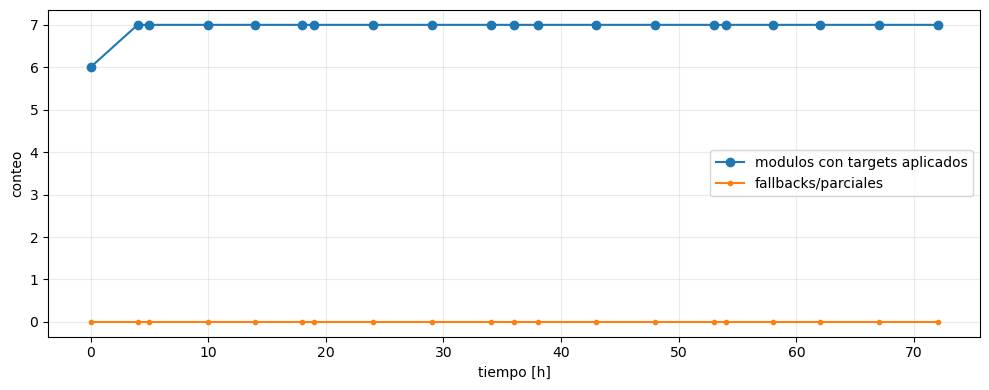

PASS: pipeline mecanistico ejecutado en orden, trazable y compatible con los snapshots.


In [24]:
phase7_trajectory_available = (
    "states_df_phase" in globals()
    and states_df_phase is not None
    and len(states_df_phase) > 0
    and "t_h" in states_df_phase.columns
)

if phase7_trajectory_available:
    phase7_t_values = np.asarray(states_df_phase["t_h"].to_numpy(dtype=float), dtype=float)
    phase7_t_values = np.unique(phase7_t_values[np.isfinite(phase7_t_values)])
    if len(phase7_t_values) == 0:
        phase7_trajectory_available = False
        phase7_audit_times = [0.0]
    else:
        phase7_representative_idx = {
            0,
            int(round(0.05 * (len(phase7_t_values) - 1))),
            int(round(0.25 * (len(phase7_t_values) - 1))),
            int(round(0.50 * (len(phase7_t_values) - 1))),
            int(round(0.75 * (len(phase7_t_values) - 1))),
            len(phase7_t_values) - 1,
        }
        phase7_mesh_idx = set(np.linspace(0, len(phase7_t_values) - 1, min(16, len(phase7_t_values))).round().astype(int))
        phase7_idx = sorted(phase7_representative_idx | phase7_mesh_idx)
        phase7_audit_times = [float(phase7_t_values[i]) for i in phase7_idx]
else:
    phase7_audit_times = [0.0]

phase7_rows = []
phase7_module_rows = []
phase7_failures = []
phase7_warnings = []
phase7_prev_state = None
phase7_prev_phase = None
expected_order = [item["name"] for item in MECHANISTIC_MODULE_ORDER_DEFAULTS]
expected_positions = {name: i for i, name in enumerate(expected_order)}


def _phase7_audit_is_informational_note(note):
    """Filtra notas esperadas que no indican fallo del pipeline.

    Los clamps de composicion/GAM son correcciones fisiologicas auditables ya
    discutidas; se mantienen en las trazas de modulo, pero no escalan el
    diagnostico global a WARNING. Lo mismo aplica para turnover cero por floor
    de activacion.
    """
    text = str(note)
    benign_substrings = (
        "clamp",
        "activación bajo floor",
        "turnover_flux se fija en 0",
        "hex_total ausente",
        "ethanol ausente",
    )
    return any(fragment in text for fragment in benign_substrings)

if not phase7_trajectory_available:
    phase7_warnings.append({"time": 0.0, "notes": ["states_df_phase no disponible; auditoria limitada al snapshot inicial."]})

for t_probe in phase7_audit_times:
    if phase7_trajectory_available:
        snap = build_mechanistic_snapshot_model(
            t_probe,
            solve=True,
            exact_time=False,
            prev_state=phase7_prev_state,
            prev_phase=phase7_prev_phase,
        )
    else:
        snap = build_mechanistic_initial_snapshot_model(
            solve=True,
            prev_state=phase7_prev_state,
            prev_phase=phase7_prev_phase,
        )

    module_order = list(snap.get("mechanistic_module_order", []) or [])
    module_trace = list(snap.get("mechanistic_module_trace", []) or [])
    application_trace = list(snap.get("mechanistic_module_application_trace", []) or [])
    sol = snap.get("solution")
    solver_status = snap.get("lexicographic_final_status", getattr(sol, "status", None))
    objective_value = _phase7_safe_float(
        snap.get("lexicographic_final_objective_value", getattr(sol, "objective_value", np.nan)),
        default=np.nan,
    )

    row_issues = []
    row_notes = []

    if module_order != expected_order:
        row_issues.append(f"orden de modulos inesperado: {module_order}")
    if not module_trace:
        row_issues.append("mechanistic_module_trace vacio")
    if not bool(snap.get("mechanistic_pipeline_valid")):
        row_issues.append("mechanistic_pipeline_valid=False")
    if solver_status not in tuple(LEXICOGRAPHIC_SOLVER_DEFAULTS["acceptable_statuses"]):
        row_issues.append(f"solver_status={solver_status}")
    if not np.isfinite(objective_value):
        row_issues.append("objective_value final no finito")

    seen = set()
    for row in module_trace:
        name = row.get("module_name")
        deps = list(row.get("dependencies", []) or [])
        if name not in expected_positions:
            row_issues.append(f"modulo desconocido en trace: {name}")
        for dep in deps:
            if dep not in seen:
                row_issues.append(f"{name} ejecutado antes de dependencia {dep}")
        seen.add(name)
        if not row.get("dependencies_satisfied", False):
            row_issues.append(f"{name}: dependencies_satisfied=False")
        if not row.get("module_valid", False):
            row_issues.append(f"{name}: module_valid=False")
        if not row.get("application_valid", False):
            row_notes.append(f"{name}: aplicacion parcial/no valida ({row.get('application_status')})")
        if row.get("notes"):
            notable = [
                str(note) for note in row.get("notes", [])
                if not _phase7_audit_is_informational_note(note)
            ]
            row_notes.extend(notable[:2])

    pipeline_fallbacks = list(snap.get("mechanistic_pipeline_fallbacks_used", []) or [])
    if pipeline_fallbacks:
        row_notes.append(f"fallbacks/aplicaciones parciales: {pipeline_fallbacks}")

    if row_issues:
        diagnostic = "FAIL"
        phase7_failures.append({"time": snap.get("actual_t_h", t_probe), "issues": row_issues})
    elif row_notes:
        diagnostic = "WARNING"
        phase7_warnings.append({"time": snap.get("actual_t_h", t_probe), "notes": row_notes})
    else:
        diagnostic = "PASS"

    redox = snap.get("redox_osmotic_module", {}) or {}
    ehrlich = snap.get("ehrlich_benzenoid_module", {}) or {}
    acetate = snap.get("acetate_ester_module", {}) or {}
    faee = snap.get("mcfa_faee_module", {}) or {}

    phase7_rows.append({
        "time": float(snap.get("actual_t_h", t_probe)),
        "phase_label": snap.get("phase_label"),
        "module_order": " -> ".join(module_order),
        "pipeline_valid": snap.get("mechanistic_pipeline_valid"),
        "redox_valid": redox.get("module_valid"),
        "ehrlich_valid": ehrlich.get("module_valid"),
        "acetate_ester_valid": acetate.get("module_valid"),
        "mcfa_faee_valid": faee.get("module_valid"),
        "redox_signal": redox.get("redox_signal"),
        "ehrlich_signal": ehrlich.get("ehrlich_signal"),
        "acetate_ester_signal": acetate.get("acetate_ester_signal"),
        "faee_signal": faee.get("faee_signal"),
        "n_modules": len(module_trace),
        "n_modules_applied": sum(int(row.get("n_applied_constraints", 0) > 0) for row in module_trace),
        "n_fallbacks": len(pipeline_fallbacks),
        "solver_status": solver_status,
        "objective_value": objective_value,
        "diagnostic": diagnostic,
        "diagnostic_notes": "; ".join(dict.fromkeys(row_notes + row_issues)),
    })

    for row in module_trace:
        phase7_module_rows.append({
            "time": float(snap.get("actual_t_h", t_probe)),
            "phase_label": snap.get("phase_label"),
            "module_name": row.get("module_name"),
            "module_level": row.get("module_level"),
            "module_kind": row.get("module_kind"),
            "dependencies": ", ".join(row.get("dependencies", []) or []),
            "dependencies_satisfied": row.get("dependencies_satisfied"),
            "module_valid": row.get("module_valid"),
            "application_valid": row.get("application_valid"),
            "application_status": row.get("application_status"),
            "n_applied_constraints": row.get("n_applied_constraints"),
            "applied_targets": ", ".join(row.get("applied_targets", []) or []),
            "notes": "; ".join(row.get("notes", []) or []),
        })

    phase7_prev_state = snap.get("state")
    phase7_prev_phase = snap.get("phase_label")

mechanistic_phase7_audit_df = pd.DataFrame(phase7_rows)
mechanistic_phase7_module_audit_df = pd.DataFrame(phase7_module_rows)
display(mechanistic_phase7_audit_df)
display(mechanistic_phase7_module_audit_df)

print("Diagnostico de pipeline mecanistico ordenado:")
if not mechanistic_phase7_audit_df.empty:
    print(f"- snapshots auditados: {len(mechanistic_phase7_audit_df)}")
    print(f"- modulos esperados por snapshot: {len(expected_order)}")
    print(f"- orden esperado: {' -> '.join(expected_order)}")
    print(
        "- fallbacks/aplicaciones parciales promedio: "
        f"{mechanistic_phase7_audit_df['n_fallbacks'].mean():.2f}"
    )

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(mechanistic_phase7_audit_df["time"], mechanistic_phase7_audit_df["n_modules_applied"], marker="o", label="modulos con targets aplicados")
    ax.plot(mechanistic_phase7_audit_df["time"], mechanistic_phase7_audit_df["n_fallbacks"], marker=".", label="fallbacks/parciales")
    ax.set_xlabel("tiempo [h]")
    ax.set_ylabel("conteo")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[WARN] No se pudo generar grafico matplotlib: {exc}")

if phase7_failures:
    print("FAIL: pipeline mecanistico presenta inconsistencias graves.")
    for failure in phase7_failures:
        print(f"- t={failure['time']}: " + "; ".join(failure["issues"]))
    warnings.warn("Auditoria Fase 7 fallo; revisar `mechanistic_phase7_audit_df`.", RuntimeWarning)
elif phase7_warnings:
    print("WARNING: pipeline Fase 7 estable pero con observaciones auditables.")
    for warning in phase7_warnings[:12]:
        print(f"- t={warning['time']}: " + "; ".join(warning["notes"][:4]))
    if len(phase7_warnings) > 12:
        print(f"- ... {len(phase7_warnings) - 12} observaciones adicionales en diagnostic_notes")
    warnings.warn("Auditoria Fase 7 con observaciones; revisar trazas de modulo.", RuntimeWarning)
else:
    print("PASS: pipeline mecanistico ejecutado en orden, trazable y compatible con los snapshots.")


### Interpretación esperada de la Fase 7

En Fase 7 se implementó un pipeline mecanístico ordenado por dependencias. La arquitectura ahora declara un grafo explícito, ejecuta módulos en orden y registra para cada uno sus entradas, salidas, aplicación al snapshot, dependencias satisfechas, notas y fallbacks. Esto cambia la capa respecto a Fase 6: la resolución lexicográfica sigue existiendo, pero ahora recibe un snapshot enriquecido por una secuencia mecanística formal.

La evidencia principal queda en `mechanistic_phase7_audit_df` y `mechanistic_phase7_module_audit_df`. Se espera ver el orden `redox_osmotic -> nitrogen_ncr -> biomass_gam -> protein_turnover -> ehrlich_benzenoid -> acetate_ester -> mcfa_faee`, todos los módulos con dependencias satisfechas, trazas no vacías y solver final estable. Las aplicaciones parciales son aceptables cuando faltan targets explícitos en el modelo, siempre que queden reportadas.

Las limitaciones siguen siendo deliberadas: redox/osmótica, Ehrlich/benzenoides, acetato-ésteres y FAEE se expresan como señales y restricciones/bounds proxy conservadores, no como subredes reguladoras completas ni como objetivos calibrados. No se reescribe Zenteno ni se convierte el problema a una formulación simultánea.

La Fase 8 debería usar este pipeline para profundizar la conexión entre señales mecanísticas y objetivos/restricciones reales: objetivos secundarios dependientes de redox y aromas, restricciones más específicas por reacción disponible, calibración de señales contra datos experimentales y posible acoplamiento dinámico más fuerte entre módulos.


In [25]:
# Fase 7b - Ajuste arquitectonico: capacidad ATPM agregada y piso redox/osmotico de glicerol
#
# Esta celda es parte de la arquitectura base del pipeline mecanistico. Debe
# ejecutarse despues de Fase 7 y antes de Fase 8/Fase 9. No es una auditoria:
# redefine el modulo redox/osmotico para que el simulador de Fase 9 use:
#   1. un piso calibrable de glicerol ligado a la senal redox/osmotica;
#   2. una demanda/capacidad ATPM agregada con parametros trazables.

import re

PHASE7B_ATPM_GLYCEROL_ARCH_VERSION = "phase7b_atpm_glycerol_pyr_acald_release_arch_v4_acald_early_window"


ATPM_MAINTENANCE_CAPACITY_DEFAULTS = {
    "parameterization_note": (
        "ATPM es una pseudo-reaccion agregada. Esta parametrizacion representa "
        "capacidad finita de maquinaria de mantenimiento/proteostasis, inspirada "
        "en restricciones tipo proteome/enzyme capacity, no en una enzima unica."
    ),
    "enable": False,
    "apply_phases": ("F3_STATIONARY", "F4_DECAY"),
    "apply_required_lower_bound": True,
    "relax_required_to_capacity": True,
    "atpm_reaction_id": globals().get("ATPM_ID", "r_4046"),
    "atpm_required_base": 0.70,
    "atpm_capacity_base": 3.00,
    "atpm_capacity_stationary_ref": 1.50,
    "atpm_capacity_max": 6.00,
    "ethanol_stress_sensitivity": 0.02,
    "ethanol_component_max": 2.00,
    "osmotic_hex_threshold_g_L": 150.0,
    "osmotic_stress_sensitivity": 0.003,
    "osmotic_component_max": 0.60,
    "turnover_atp_cost_weight": 1.00,
    "turnover_flux_ref_gProt_gDW_h": 0.020,
    "turnover_component_max": 0.50,
    "proteostasis_weight": 0.25,
    "proteostasis_ethanol_half_g_L": 35.0,
    "proteostasis_component_max": 0.50,
    "phase_capacity_multipliers": {
        "F0_LAG_OSMO": 1.00,
        "F1_EXP_GROWTH": 1.00,
        "F2_N_LIMITED_CARB_ACC": 0.90,
        "F3_STATIONARY": 0.70,
        "F4_DECAY": 0.50,
    },
}


REDOX_GLYCEROL_FLOOR_DEFAULTS = {
    "parameterization_note": (
        "Piso minimo calibrable para preservar salida redox/osmotica por "
        "glicerol cuando la senal fisiologica sigue activa."
    ),
    "enable": True,
    "glycerol_reaction_id": "r_1808",
    "min_redox_signal": 0.05,
    "abs_floor_max_mmol_gDW_h": 0.20,
    "floor_fraction_by_phase": {
        # Conservador por defecto: el piso se activa desde F2/F3, donde la
        # auditoria mostró plateau artificial de glicerol. F0/F1 mantienen el
        # comportamiento base para no tensionar snapshots tempranos.
        "F0_LAG_OSMO": 0.00,
        "F1_EXP_GROWTH": 0.00,
        "F2_N_LIMITED_CARB_ACC": 0.10,
        "F3_STATIONARY": 0.5,
        "F4_DECAY": 0.05,
    },
}


PYR_ACALD_RELEASE_DEFAULTS = {
    "parameterization_note": (
        "Ventanas fisiologicas conservadoras para expresar piruvato y "
        "acetaldehido como salidas macro observables. No se asumen "
        "constantes biologicas duras: son priors operacionales para "
        "desacoplar parcialmente el nodo interno de su observacion externa."
    ),
    "enable": True,
    "apply_hard_min_flux_constraints": True,
    "minimum_soft_export_bound": 1e-6,
    "signal_threshold": 1e-4,
    "n_free_half_saturation_gN_L": 0.03,
    "pyruvate": {
        "reaction_ids": ["r_2033"],
        "max_exchange_flux_mmol_gDW_h": 0.040,
        "phase_weights": {
            "F0_LAG_OSMO": 0.85,
            "F1_EXP_GROWTH": 1.00,
            "F2_N_LIMITED_CARB_ACC": 0.18,
            "F3_STATIONARY": 0.00,
            "F4_DECAY": 0.00,
        },
        "hex_weight": 0.40,
        "osmotic_weight": 0.20,
        "anaerobic_weight": 0.15,
        "n_replete_weight": 0.15,
        "low_ethanol_weight": 0.10,
        "ethanol_inhibition_weight": 0.65,
    },
    "acetaldehyde": {
        "reaction_ids": ["r_1631"],
        "max_exchange_flux_mmol_gDW_h": 0.160,
        "production_window_mid_h": 18.0,
        "production_window_steepness_h": 2.5,
        "early_phase_weights": {
            "F0_LAG_OSMO": 1.00,
            "F1_EXP_GROWTH": 1.00,
            "F2_N_LIMITED_CARB_ACC": 0.00,
            "F3_STATIONARY": 0.00,
            "F4_DECAY": 0.00,
        },
        "late_phase_weights": {
            "F0_LAG_OSMO": 0.00,
            "F1_EXP_GROWTH": 0.00,
            "F2_N_LIMITED_CARB_ACC": 0.00,
            "F3_STATIONARY": 0.00,
            "F4_DECAY": 0.00,
        },
        "early_hex_weight": 0.20,
        "early_anaerobic_weight": 0.45,
        "early_osmotic_weight": 0.20,
        "early_n_replete_weight": 0.15,
        "late_balance_weight": 0.00,
        "late_ethanol_weight": 0.00,
        "late_starvation_weight": 0.00,
    },
}


def _phase7b_deep_update(base, updates):

    """Actualiza diccionarios anidados sin mutar el objeto base."""
    out = dict(base or {})
    for key, value in dict(updates or {}).items():
        if isinstance(value, dict) and isinstance(out.get(key), dict):
            out[key] = _phase7b_deep_update(out[key], value)
        else:
            out[key] = value
    return out


def _phase7b_safe_float(value, default=np.nan):
    """Convierte `value` a float finito; si falla devuelve `default`."""
    try:
        if value is None:
            return default
        out = float(value)
        return out if np.isfinite(out) else default
    except Exception:
        return default


def _phase7b_merge_pipeline_config(config=None):
    """Combina defaults del pipeline con defaults Fase 7b y overrides externos."""
    if "_phase7_merge_pipeline_config" in globals():
        cfg = _phase7_merge_pipeline_config(config)
    else:
        cfg = dict(config or {})
    cfg["atpm_capacity"] = _phase7b_deep_update(
        ATPM_MAINTENANCE_CAPACITY_DEFAULTS,
        cfg.get("atpm_capacity", {}),
    )
    cfg["redox_glycerol_floor"] = _phase7b_deep_update(
        REDOX_GLYCEROL_FLOOR_DEFAULTS,
        cfg.get("redox_glycerol_floor", {}),
    )
    cfg["pyr_acald_release"] = _phase7b_deep_update(
        PYR_ACALD_RELEASE_DEFAULTS,
        cfg.get("pyr_acald_release", {}),
    )
    return cfg


if "MECHANISTIC_PIPELINE_DEFAULTS" in globals():
    MECHANISTIC_PIPELINE_DEFAULTS = _phase7b_deep_update(
        MECHANISTIC_PIPELINE_DEFAULTS,
        {
            "atpm_capacity": ATPM_MAINTENANCE_CAPACITY_DEFAULTS,
            "redox_glycerol_floor": REDOX_GLYCEROL_FLOOR_DEFAULTS,
            "pyr_acald_release": PYR_ACALD_RELEASE_DEFAULTS,
        },
    )


# Seleccion defensiva del modulo base.
# Si el kernel conserva una redefinicion diagnostica previa, preferimos el
# puntero al modulo original que esa celda guardaba. Esto evita wrappers
# apilados o recursion indirecta al re-ejecutar Fase 7b.
_PHASE7B_BASE_COMPUTE_REDOX_OSMOTIC_MODULE = globals().get(
    "_PHASE_PRE_ATPM_COMPUTE_REDOX_OSMOTIC_MODULE",
    globals().get("_PHASE7B_BASE_COMPUTE_REDOX_OSMOTIC_MODULE", compute_redox_osmotic_module),
)
_PHASE7B_BASE_APPLY_REDOX_OSMOTIC_CONSTRAINTS = globals().get(
    "_PHASE_PRE_ATPM_APPLY_REDOX_OSMOTIC_CONSTRAINTS",
    globals().get("_PHASE7B_BASE_APPLY_REDOX_OSMOTIC_CONSTRAINTS", apply_redox_osmotic_constraints_to_snapshot),
)


def compute_atpm_maintenance_capacity(
    state,
    phase_label=None,
    indicators=None,
    redox_module=None,
    turnover_module=None,
    params=None,
):
    """Calcula demanda y capacidad ATPM agregada para el snapshot.

    El resultado se usa como bounds de la pseudo-reaccion ATPM. La demanda
    aumenta con estres por etanol, osmotico, turnover y proteostasis. La
    capacidad se acota por fase para evitar que ATPM actue como sumidero
    energetico infinito en estacionaria/decay.
    """
    cfg = _phase7b_merge_pipeline_config(params).get("atpm_capacity", {})
    state = {} if state is None else dict(state)
    indicators = {} if indicators is None else dict(indicators)
    turnover_module = {} if turnover_module is None else dict(turnover_module)
    notes = []

    phase_label = phase_label or "F1_EXP_GROWTH"
    hex_total = _phase7b_safe_float(indicators.get("hex_total"), default=np.nan)
    if not np.isfinite(hex_total):
        hex_total = max(0.0, _phase7b_safe_float(state.get("cG"), 0.0)) + max(0.0, _phase7b_safe_float(state.get("cF"), 0.0))
        notes.append("hex_total reconstruido desde cG+cF")

    ethanol = _phase7b_safe_float(indicators.get("ethanol"), default=np.nan)
    if not np.isfinite(ethanol):
        ethanol = max(0.0, _phase7b_safe_float(state.get("cE"), 0.0))
        notes.append("ethanol reconstruido desde cE")

    ethanol_component = min(
        float(cfg["ethanol_component_max"]),
        max(0.0, ethanol) * float(cfg["ethanol_stress_sensitivity"]),
    )
    osmotic_component = min(
        float(cfg["osmotic_component_max"]),
        max(0.0, hex_total - float(cfg["osmotic_hex_threshold_g_L"])) * float(cfg["osmotic_stress_sensitivity"]),
    )

    turnover_flux = 0.0
    if isinstance(turnover_module.get("turnover_flux"), dict):
        turnover_flux = _phase7b_safe_float(
            turnover_module["turnover_flux"].get("turnover_flux_specific_gProt_gDW_h"),
            default=0.0,
        )
    turnover_component = min(
        float(cfg["turnover_component_max"]),
        float(cfg["turnover_atp_cost_weight"]) * max(0.0, turnover_flux) / max(float(cfg["turnover_flux_ref_gProt_gDW_h"]), 1e-12),
    )

    ethanol_half = max(float(cfg["proteostasis_ethanol_half_g_L"]), 1e-12)
    proteostasis_signal = max(0.0, ethanol) / (max(0.0, ethanol) + ethanol_half)
    proteostasis_component = min(
        float(cfg["proteostasis_component_max"]),
        float(cfg["proteostasis_weight"]) * proteostasis_signal,
    )

    required_base = float(cfg["atpm_required_base"])
    required = required_base * (1.0 + ethanol_component + osmotic_component + turnover_component + proteostasis_component)

    phase_multiplier = float(cfg["phase_capacity_multipliers"].get(phase_label, 1.0))
    capacity_raw = float(cfg["atpm_capacity_base"]) * phase_multiplier
    if phase_label == "F3_STATIONARY":
        capacity_raw = min(capacity_raw, float(cfg["atpm_capacity_stationary_ref"]))
    capacity = min(float(cfg["atpm_capacity_max"]), max(0.0, capacity_raw))

    energy_limited = bool(required > capacity)
    required_effective = min(required, capacity) if bool(cfg.get("relax_required_to_capacity", True)) else required
    if energy_limited:
        notes.append(f"ATPM_required {required:.6g} supera capacidad {capacity:.6g}; lb efectiva {required_effective:.6g}")

    valid = bool(np.isfinite(required) and np.isfinite(required_effective) and np.isfinite(capacity))
    return {
        "atpm_required": float(required),
        "atpm_required_effective": float(required_effective),
        "atpm_capacity": float(capacity),
        "ethanol_component": float(ethanol_component),
        "osmotic_component": float(osmotic_component),
        "turnover_component": float(turnover_component),
        "proteostasis_component": float(proteostasis_component),
        "phase_capacity_multiplier": float(phase_multiplier),
        "energy_limited": energy_limited,
        "phase_label": phase_label,
        "module_valid": valid,
        "module_notes": notes,
        "module_version": PHASE7B_ATPM_GLYCEROL_ARCH_VERSION,
    }


def compute_glycerol_redox_floor(redox_module, phase_label=None, params=None, config=None):
    """Calcula senales de necesidad redox/osmotica de glicerol sin forzar strict."""
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    cfg = _phase7b_merge_pipeline_config(params).get("redox_glycerol_floor", {})
    redox_module = {} if redox_module is None else dict(redox_module)
    phase_label = phase_label or redox_module.get("phase_label") or "F1_EXP_GROWTH"
    redox_signal = _phase7b_safe_float(redox_module.get("redox_signal"), default=0.0)
    osmotic_signal = _phase7b_safe_float(redox_module.get("osmotic_signal"), default=0.0)
    ethanol_signal = _phase7b_safe_float(redox_module.get("ethanol_signal"), default=0.0)
    nitrogen_starvation_signal = _phase7b_safe_float(redox_module.get("nitrogen_starvation_signal"), default=0.0)
    proxy = _phase7b_safe_float(
        redox_module.get("glycerol_min_flux_proxy", redox_module.get("glycerol_min_flux")),
        default=0.0,
    )
    fraction = float(cfg["floor_fraction_by_phase"].get(phase_label, 0.0))
    legacy_enabled = bool(cfg.get("enable", True)) and redox_signal >= float(cfg["min_redox_signal"]) and fraction > 0.0
    candidate = min(float(cfg["abs_floor_max_mmol_gDW_h"]), max(0.0, fraction * proxy)) if legacy_enabled else 0.0
    regularized_enabled = bool(
        mode == "regularized"
        and product_policy.get("allow_product_forcing", False)
        and product_policy.get("glycerol_floor_enabled", False)
        and legacy_enabled
    )
    floor = float(candidate if regularized_enabled else 0.0)
    notes = [] if legacy_enabled else ["piso de glicerol no activo por fase/senal/config"]
    if mode in {"strict", "diagnostic"} and candidate > 0.0:
        notes.append("candidato de piso retenido como diagnostico; no se convierte en lower bound obligatorio")
    return {
        "glycerol_floor_flux": float(floor),
        "glycerol_floor_candidate": float(candidate),
        "glycerol_redox_need_proxy": float(proxy),
        "glycerol_floor_fraction": float(fraction),
        "glycerol_floor_enabled": bool(regularized_enabled),
        "legacy_glycerol_floor_enabled": bool(legacy_enabled),
        "redox_signal": float(redox_signal),
        "osmotic_signal": float(osmotic_signal),
        "ethanol_stress_signal": float(ethanol_signal),
        "nitrogen_starvation_signal": float(nitrogen_starvation_signal),
        "glycerol_min_flux_proxy": float(proxy),
        "phase_label": phase_label,
        "product_forcing_mode": mode,
        "module_valid": bool(np.isfinite(floor) and np.isfinite(candidate)),
        "module_notes": notes,
        "module_version": PHASE7B_ATPM_GLYCEROL_ARCH_VERSION,
    }


def _phase7b_reconstruct_nitrogen_signals(state, indicators=None, params=None):
    """Reconstruye señales simples de suficiencia/limitación de N para release windows."""
    cfg = _phase7b_merge_pipeline_config(params).get("pyr_acald_release", {})
    indicators = {} if indicators is None else dict(indicators)
    notes = []
    n_free = _phase7b_safe_float(
        indicators.get("n_free_gN_L", indicators.get("n_free")),
        default=np.nan,
    )
    if not np.isfinite(n_free):
        n_free = max(
            0.0,
            _phase7b_safe_float(
                _phase7_get_value(state, ["cN_free", "N_free_gN_L", "N_gN_L", "cN"]),
                default=0.0,
            ),
        )
        notes.append("n_free reconstruido desde el estado macro")
    n_replete_signal = _phase7_clip01(
        _phase7_saturation_signal(n_free, cfg.get("n_free_half_saturation_gN_L", 0.03)),
        default=0.0,
    )
    starvation_signal = _phase7_clip01(indicators.get("nitrogen_starvation_signal", np.nan), default=np.nan)
    if not np.isfinite(starvation_signal):
        starvation_signal = 1.0 - n_replete_signal
        notes.append("nitrogen_starvation_signal reconstruida como complemento de suficiencia de N")
    return {
        "n_free_gN_L": float(max(0.0, n_free)),
        "nitrogen_replete_signal": float(n_replete_signal),
        "nitrogen_starvation_signal": float(starvation_signal),
        "notes": notes,
    }


def compute_pyr_acald_release_windows(state, phase_label=None, indicators=None, redox_module=None, params=None, config=None):
    """Calcula ventanas fisiológicas conservadoras para release macro de piruvato y acetaldehído.

    La intención es separar dos fenómenos:
    - piruvato como overflow temprano/transitorio, acoplado a glucólisis alta;
    - acetaldehído como burst rápido y pool regulado, con componente temprano
      y posible remanente/cola en stationary por balance redox/etanol.
    """
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    cfg = _phase7b_merge_pipeline_config(params).get("pyr_acald_release", {})
    state = {} if state is None else dict(state)
    indicators = {} if indicators is None else dict(indicators)
    redox_module = {} if redox_module is None else dict(redox_module)
    phase_label = phase_label or redox_module.get("phase_label") or "F1_EXP_GROWTH"
    notes = []

    n_signals = _phase7b_reconstruct_nitrogen_signals(state, indicators=indicators, params=params)
    notes.extend(n_signals.get("notes", []))
    n_replete_signal = float(n_signals["nitrogen_replete_signal"])
    starvation_signal = float(n_signals["nitrogen_starvation_signal"])

    hex_signal = _phase7_clip01(redox_module.get("hex_signal", np.nan), default=np.nan)
    if not np.isfinite(hex_signal):
        hex_total = max(0.0, _phase7b_safe_float(_phase7_get_value(state, ["cG", "G_g_L"]), default=0.0))
        hex_total += max(0.0, _phase7b_safe_float(_phase7_get_value(state, ["cF", "F_g_L"]), default=0.0))
        hex_signal = _phase7_clip01(_phase7_saturation_signal(hex_total, 80.0), default=0.0)
        notes.append("hex_signal reconstruida desde azúcares externos")

    osmotic_signal = _phase7_clip01(redox_module.get("osmotic_signal", np.nan), default=0.0)
    ethanol_signal = _phase7_clip01(redox_module.get("ethanol_signal", np.nan), default=0.0)
    anaerobic_signal = _phase7_clip01(redox_module.get("anaerobic_signal", np.nan), default=0.0)
    balance_signal = _phase7_clip01(
        redox_module.get("acetaldehyde_ethanol_balance_signal", redox_module.get("redox_signal", 0.0)),
        default=0.0,
    )

    t_h = _phase7b_safe_float(indicators.get("time_h", _phase7_get_value(state, ["t_h", "actual_t_h"])), default=np.nan)

    py_cfg = cfg.get("pyruvate", {})
    py_phase_weight = float(py_cfg.get("phase_weights", {}).get(phase_label, 0.0))
    py_core = (
        float(py_cfg.get("hex_weight", 0.40)) * float(hex_signal)
        + float(py_cfg.get("osmotic_weight", 0.20)) * float(osmotic_signal)
        + float(py_cfg.get("anaerobic_weight", 0.15)) * float(anaerobic_signal)
        + float(py_cfg.get("n_replete_weight", 0.15)) * float(n_replete_signal)
        + float(py_cfg.get("low_ethanol_weight", 0.10)) * max(0.0, 1.0 - float(ethanol_signal))
    )
    py_signal = _phase7_clip01(
        py_phase_weight * py_core * max(0.0, 1.0 - float(py_cfg.get("ethanol_inhibition_weight", 0.55)) * float(ethanol_signal)),
        default=0.0,
    )
    py_flux = float(py_signal) * float(py_cfg.get("max_exchange_flux_mmol_gDW_h", 0.0))
    py_hard_min = py_flux if bool(
        mode == "regularized"
        and product_policy.get("allow_product_forcing", False)
        and product_policy.get("pyruvate_hard_min_enabled", False)
    ) else 0.0

    ac_cfg = cfg.get("acetaldehyde", {})
    ac_window_mid = max(0.0, _phase7b_safe_float(ac_cfg.get("production_window_mid_h"), default=18.0))
    ac_window_steep = max(1e-6, _phase7b_safe_float(ac_cfg.get("production_window_steepness_h"), default=2.5))
    ac_time_gate = 1.0
    if np.isfinite(t_h):
        ac_time_gate = 1.0 / (1.0 + np.exp((t_h - ac_window_mid) / ac_window_steep))
    else:
        notes.append("tiempo no disponible para gate temporal de acetaldehído; se asume gate=1")
    ac_early_phase = float(ac_cfg.get("early_phase_weights", {}).get(phase_label, 0.0))
    ac_late_phase = float(ac_cfg.get("late_phase_weights", {}).get(phase_label, 0.0))
    ac_early_component = ac_early_phase * (
        float(ac_cfg.get("early_hex_weight", 0.25)) * float(hex_signal)
        + float(ac_cfg.get("early_anaerobic_weight", 0.35)) * float(anaerobic_signal)
        + float(ac_cfg.get("early_osmotic_weight", 0.20)) * float(osmotic_signal)
        + float(ac_cfg.get("early_n_replete_weight", 0.20)) * float(n_replete_signal)
    )
    ac_late_component = ac_late_phase * (
        float(ac_cfg.get("late_balance_weight", 0.35)) * float(balance_signal)
        + float(ac_cfg.get("late_ethanol_weight", 0.35)) * float(ethanol_signal)
        + float(ac_cfg.get("late_starvation_weight", 0.30)) * float(starvation_signal)
    )
    ac_signal = _phase7_clip01(ac_time_gate * ac_early_component + (1.0 - ac_time_gate) * ac_late_component, default=0.0)
    ac_flux = float(ac_signal) * float(ac_cfg.get("max_exchange_flux_mmol_gDW_h", 0.0))
    ac_hard_min = ac_flux if bool(
        mode == "regularized"
        and product_policy.get("allow_product_forcing", False)
        and product_policy.get("acetaldehyde_hard_min_enabled", False)
    ) else 0.0
    notes.append(f"acetaldehyde_time_gate={ac_time_gate:.3f}")
    if mode in {"strict", "diagnostic"} and (py_flux > 0.0 or ac_flux > 0.0):
        notes.append("release windows retenidas como diagnostico/capacidad; no activan hard-min en strict/diagnostic")

    valid = bool(np.isfinite(py_signal) and np.isfinite(py_flux) and np.isfinite(ac_signal) and np.isfinite(ac_flux))
    if not valid:
        notes.append("release windows no finitas para piruvato/acetaldehído")

    return {
        "phase_label": phase_label,
        "n_free_gN_L": float(n_signals["n_free_gN_L"]),
        "nitrogen_replete_signal": float(n_replete_signal),
        "nitrogen_starvation_signal": float(starvation_signal),
        "pyruvate_release_signal": float(py_signal),
        "pyruvate_min_flux_proxy": float(max(0.0, py_flux)),
        "pyruvate_hard_min_candidate": float(max(0.0, py_flux)),
        "pyruvate_hard_min_flux": float(max(0.0, py_hard_min)),
        "acetaldehyde_release_signal": float(ac_signal),
        "acetaldehyde_min_flux_proxy": float(max(0.0, ac_flux)),
        "acetaldehyde_hard_min_candidate": float(max(0.0, ac_flux)),
        "acetaldehyde_hard_min_flux": float(max(0.0, ac_hard_min)),
        "acetaldehyde_release_early_component": float(_phase7_clip01(ac_early_component, default=0.0)),
        "acetaldehyde_release_late_component": float(_phase7_clip01(ac_late_component, default=0.0)),
        "acetaldehyde_time_gate": float(_phase7_clip01(ac_time_gate, default=0.0)),
        "phase_window_signal": float(max(py_phase_weight, ac_early_phase, ac_late_phase)),
        "overflow_proxy": float(max(0.0, py_flux)),
        "acetaldehyde_redox_proxy": float(max(0.0, ac_flux)),
        "product_forcing_mode": mode,
        "pyruvate_hard_min_enabled": bool(py_hard_min > 0.0),
        "acetaldehyde_hard_min_enabled": bool(ac_hard_min > 0.0),
        "module_valid": valid,
        "module_notes": notes,
        "module_version": PHASE7B_ATPM_GLYCEROL_ARCH_VERSION,
    }


def compute_redox_osmotic_module(state, phase_label=None, indicators=None, params=None, config=None):
    """Modulo redox/osmotico extendido con ventanas macro para piruvato/acetaldehído, glicerol floor y ATPM capacity."""
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    redox = _PHASE7B_BASE_COMPUTE_REDOX_OSMOTIC_MODULE(
        state,
        phase_label=phase_label,
        indicators=indicators,
        params=params,
    )
    redox = dict(redox or {})
    redox["phase_label"] = phase_label
    redox["pyr_acald_release"] = compute_pyr_acald_release_windows(
        state,
        phase_label=phase_label,
        indicators=indicators,
        redox_module=redox,
        params=params,
        config=modeling_config,
    )
    redox["pyruvate_release_signal"] = redox["pyr_acald_release"].get("pyruvate_release_signal")
    redox["pyruvate_min_flux_proxy"] = redox["pyr_acald_release"].get("pyruvate_min_flux_proxy")
    redox["acetaldehyde_release_signal"] = redox["pyr_acald_release"].get("acetaldehyde_release_signal")
    redox["acetaldehyde_min_flux_proxy"] = redox["pyr_acald_release"].get("acetaldehyde_min_flux_proxy")
    redox["glycerol_redox_floor"] = compute_glycerol_redox_floor(redox, phase_label=phase_label, params=params, config=modeling_config)
    redox["glycerol_floor_flux"] = redox["glycerol_redox_floor"].get("glycerol_floor_flux")
    redox["glycerol_floor_candidate"] = redox["glycerol_redox_floor"].get("glycerol_floor_candidate")
    redox["product_forcing_mode"] = mode
    redox["product_policy"] = dict(product_policy)
    redox["atpm_maintenance_capacity"] = compute_atpm_maintenance_capacity(
        state,
        phase_label=phase_label,
        indicators=indicators,
        redox_module=redox,
        turnover_module=None,
        params=params,
    )
    redox["module_notes"] = list(redox.get("module_notes", [])) + list(redox["pyr_acald_release"].get("module_notes", []))
    redox["module_valid"] = bool(
        redox.get("module_valid", True)
        and redox["pyr_acald_release"].get("module_valid", True)
    )
    redox["module_version"] = PHASE7B_ATPM_GLYCEROL_ARCH_VERSION
    return redox


def apply_atpm_capacity_to_snapshot(mdl, atpm_capacity_module, params=None, config=None):
    """Aplica bounds ATPM derivados de demanda/capacidad agregada."""
    cfg = _phase7b_merge_pipeline_config(params).get("atpm_capacity", {})
    module = {} if atpm_capacity_module is None else dict(atpm_capacity_module)
    notes = list(module.get("module_notes", []))
    phase_label = module.get("phase_label")

    if not bool(cfg.get("enable", True)):
        return {"applied_bounds": [], "failed_bounds": [], "application_valid": True, "application_status": "atpm_capacity_disabled", "application_notes": ["capacidad ATPM deshabilitada"]}
    if phase_label not in tuple(cfg.get("apply_phases", ())):
        return {"applied_bounds": [], "failed_bounds": [], "application_valid": True, "application_status": "atpm_capacity_not_applied_for_phase", "application_notes": [f"fase sin cap ATPM dinamico: {phase_label}"]}

    rid = cfg.get("atpm_reaction_id", globals().get("ATPM_ID", "r_4046"))
    rxns = reaction_map(mdl)
    if rid not in rxns:
        return {"applied_bounds": [], "failed_bounds": [{"reaction_id": rid, "reason": "missing_reaction"}], "application_valid": False, "application_status": "atpm_reaction_missing", "application_notes": notes + [f"ATPM ausente: {rid}"]}

    rxn = rxns[rid]
    old_lb = float(rxn.lower_bound)
    old_ub = float(rxn.upper_bound)
    capacity = max(0.0, _phase7b_safe_float(module.get("atpm_capacity"), default=old_ub))
    required = max(0.0, _phase7b_safe_float(module.get("atpm_required_effective", module.get("atpm_required")), default=old_lb))

    new_ub = min(old_ub, capacity)
    new_lb = max(old_lb, required) if bool(cfg.get("apply_required_lower_bound", True)) else old_lb
    if new_lb > new_ub:
        if bool(cfg.get("relax_required_to_capacity", True)):
            notes.append(f"ATPM lb {new_lb:.6g} > ub {new_ub:.6g}; lb relajado a ub")
            new_lb = new_ub
        else:
            return {
                "applied_bounds": [],
                "failed_bounds": [{"reaction_id": rid, "reason": "required_exceeds_capacity", "lb": new_lb, "ub": new_ub}],
                "application_valid": False,
                "application_status": "atpm_capacity_inconsistent",
                "application_notes": notes,
            }

    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else None
    audit_rec = set_reaction_bounds_with_audit(
        mdl, rid, lower_bound=float(new_lb), upper_bound=float(max(new_ub, new_lb)),
        module="redox_osmotic_atpm_capacity", reason="ATPM maintenance capacity bounds",
        mode=_mode, phase=phase_label,
    )
    return {
        "applied_bounds": [{
            "reaction_id": rid,
            "old_lb": old_lb,
            "old_ub": old_ub,
            "new_lb": float(rxn.lower_bound),
            "new_ub": float(rxn.upper_bound),
            "atpm_required": _phase7b_safe_float(module.get("atpm_required"), default=np.nan),
            "atpm_capacity": capacity,
            "phase_label": phase_label,
            "bound_audit_status": audit_rec.get("status"),
        }],
        "failed_bounds": [],
        "application_valid": True,
        "application_status": "applied_atpm_capacity_bounds",
        "application_notes": notes,
    }


def apply_glycerol_redox_floor_to_snapshot(mdl, glycerol_floor_module, params=None, config=None):
    """Aplica la politica efectiva de glicerol sin forzar producto en strict."""
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    cfg = _phase7b_merge_pipeline_config(params).get("redox_glycerol_floor", {})
    module = {} if glycerol_floor_module is None else dict(glycerol_floor_module)
    notes = list(module.get("module_notes", []))
    rid = cfg.get("glycerol_reaction_id", "r_1808")
    rxns = reaction_map(mdl)
    flags = _get_product_forcing_flags(mdl)
    flags.update({
        "glycerol_floor_applied": False,
        "glycerol_forcing_applied": False,
        "glycerol_floor_value_applied": 0.0,
    })
    _set_product_forcing_flags(mdl, flags)

    if not bool(cfg.get("enable", True)):
        return {
            "applied_constraints": [],
            "applied_bounds": [],
            "failed_constraints": [],
            "product_forcing_flags": _get_product_forcing_flags(mdl),
            "application_valid": True,
            "application_status": "glycerol_floor_disabled",
            "application_notes": ["piso de glicerol deshabilitado"],
        }

    floor = max(0.0, _phase7b_safe_float(module.get("glycerol_floor_flux"), default=0.0))
    candidate = max(0.0, _phase7b_safe_float(module.get("glycerol_floor_candidate", floor), default=0.0))

    if rid not in rxns:
        return {
            "applied_constraints": [],
            "applied_bounds": [],
            "failed_constraints": [{"reaction_id": rid, "reason": "missing_reaction"}],
            "product_forcing_flags": _get_product_forcing_flags(mdl),
            "application_valid": False,
            "application_status": "glycerol_reaction_missing",
            "application_notes": notes + [f"reaccion de glicerol ausente: {rid}"],
        }

    applied_bounds = []
    if mode in {"strict", "regularized"} and bool(product_policy.get("allow_product_secretion", True)):
        rxn = rxns[rid]
        old_ub = float(rxn.upper_bound)
        desired_ub = max(old_ub, candidate, float(cfg.get("abs_floor_max_mmol_gDW_h", 0.0)), 1e-6)
        if desired_ub > old_ub:
            audit_rec = set_reaction_bounds_with_audit(
                mdl,
                rid,
                upper_bound=desired_ub,
                module="redox_osmotic/glycerol",
                reason="allow_product_secretion_without_forcing",
                mode=mode,
                phase=module.get("phase_label"),
                product_role="glycerol",
                strict_no_product_forcing=True,
            )
            applied_bounds.append({
                "reaction_id": rid,
                "old_ub": old_ub,
                "new_ub": float(rxns[rid].upper_bound),
                "bound_audit_status": audit_rec.get("status"),
                "product_role": "glycerol",
            })

    if mode == "diagnostic":
        return {
            "applied_constraints": [],
            "applied_bounds": [],
            "failed_constraints": [],
            "glycerol_floor_candidate": float(candidate),
            "product_forcing_flags": _get_product_forcing_flags(mdl),
            "application_valid": True,
            "application_status": "glycerol_floor_diagnostic_only",
            "application_notes": notes + ["diagnostic: no se modifican bounds ni constraints de glicerol"],
        }

    if mode == "strict":
        return {
            "applied_constraints": [],
            "applied_bounds": applied_bounds,
            "failed_constraints": [],
            "glycerol_floor_candidate": float(candidate),
            "glycerol_floor_value_applied": 0.0,
            "product_forcing_flags": _get_product_forcing_flags(mdl),
            "application_valid": True,
            "application_status": "glycerol_floor_skipped_strict_no_product_forcing",
            "application_notes": notes + ["strict: candidato de piso no aplicado como lower bound"],
        }

    if floor <= 0.0 or not bool(product_policy.get("allow_product_forcing", False)) or not bool(product_policy.get("glycerol_floor_enabled", False)):
        return {
            "applied_constraints": [],
            "applied_bounds": applied_bounds,
            "failed_constraints": [],
            "glycerol_floor_candidate": float(candidate),
            "product_forcing_flags": _get_product_forcing_flags(mdl),
            "application_valid": True,
            "application_status": "glycerol_floor_regularized_disabled_or_zero",
            "application_notes": notes + ["regularized: floor no aplicado porque no esta habilitado explicitamente o es cero"],
        }

    cname = f"phase7b_glycerol_redox_floor_{module.get('phase_label', 'phase')}_{floor:.6g}"
    cname = re.sub(r"[^A-Za-z0-9_]+", "_", cname)
    rec = add_product_constraint_with_policy(
        mdl,
        rid,
        rxns[rid].flux_expression,
        lb=floor,
        module="redox_osmotic/glycerol",
        product_role="glycerol",
        reason="regularized_glycerol_redox_floor",
        config=modeling_config,
        name=cname,
    )
    if str(rec.get("status", "")).startswith("ADDED"):
        flags = _get_product_forcing_flags(mdl)
        flags.update({
            "glycerol_floor_applied": True,
            "glycerol_forcing_applied": True,
            "glycerol_floor_value_applied": float(floor),
        })
        _set_product_forcing_flags(mdl, flags)
        return {
            "applied_constraints": [{"name": cname, "reaction_id": rid, "lb": float(floor), "phase_label": module.get("phase_label"), "redox_signal": module.get("redox_signal")}],
            "applied_bounds": applied_bounds,
            "failed_constraints": [],
            "product_forcing_mode": "regularized",
            "glycerol_floor_applied": True,
            "glycerol_forcing_applied": True,
            "glycerol_floor_value_applied": float(floor),
            "product_forcing_flags": _get_product_forcing_flags(mdl),
            "application_valid": True,
            "application_status": "applied_glycerol_redox_floor_regularized",
            "application_notes": notes + ["regularized: floor de glicerol aplicado explicitamente"],
        }
    return {
        "applied_constraints": [],
        "applied_bounds": applied_bounds,
        "failed_constraints": [{"reaction_id": rid, "reason": rec.get("status"), "floor": floor}],
        "product_forcing_flags": _get_product_forcing_flags(mdl),
        "application_valid": False,
        "application_status": "glycerol_floor_application_failed",
        "application_notes": notes + [f"no se pudo aplicar piso de glicerol: {rec.get('message')}"],
    }


def apply_pyr_acald_release_to_snapshot(mdl, release_module, params=None, config=None):
    """Aplica ventanas de exportación macro para piruvato y acetaldehído.

    Se reutiliza la infraestructura de targets del pipeline. La aplicación
    es conservadora: solo actúa cuando la señal supera un umbral y se
    limita al exchange explícito disponible.
    """
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    cfg = _phase7b_merge_pipeline_config(params).get("pyr_acald_release", {})
    module = {} if release_module is None else dict(release_module)
    notes = list(module.get("module_notes", []))
    flags = _get_product_forcing_flags(mdl)
    flags.update({
        "pyruvate_hard_min_applied": False,
        "pyruvate_forcing_applied": False,
        "pyruvate_hard_min_value_applied": 0.0,
        "acetaldehyde_hard_min_applied": False,
        "acetaldehyde_forcing_applied": False,
        "acetaldehyde_hard_min_value_applied": 0.0,
    })
    _set_product_forcing_flags(mdl, flags)

    if not bool(cfg.get("enable", True)):
        return {
            "applied_constraints": [],
            "applied_targets": [],
            "failed_targets": [],
            "product_forcing_flags": _get_product_forcing_flags(mdl),
            "application_valid": True,
            "application_status": "pyr_acald_release_disabled",
            "application_notes": ["ventanas de release macro deshabilitadas"],
        }

    if mode == "diagnostic":
        return {
            "applied_constraints": [],
            "applied_targets": [],
            "failed_targets": [],
            "pyruvate_hard_min_value_candidate": float(max(0.0, _phase7b_safe_float(module.get("pyruvate_min_flux_proxy"), default=0.0))),
            "acetaldehyde_hard_min_value_candidate": float(max(0.0, _phase7b_safe_float(module.get("acetaldehyde_min_flux_proxy"), default=0.0))),
            "product_forcing_flags": _get_product_forcing_flags(mdl),
            "application_valid": True,
            "application_status": "pyr_acald_release_diagnostic_only",
            "application_notes": notes + ["diagnostic: no se modifican bounds ni constraints de piruvato/acetaldehido"],
        }

    applied_constraints = []
    applied_targets = []
    failed_targets = []
    valid = True
    signal_threshold = float(cfg.get("signal_threshold", 1e-4))
    min_soft = float(cfg.get("minimum_soft_export_bound", 1e-6))
    use_hard_global = bool(cfg.get("apply_hard_min_flux_constraints", True))

    for species_name in ("pyruvate", "acetaldehyde"):
        spec = dict(cfg.get(species_name, {}))
        signal = max(0.0, _phase7b_safe_float(module.get(f"{species_name}_release_signal"), default=0.0))
        max_flux = max(0.0, float(spec.get("max_exchange_flux_mmol_gDW_h", 0.0)))
        if signal <= signal_threshold or max_flux <= 0.0:
            notes.append(f"{species_name}: ventana inactiva o max_flux nulo")
            continue
        hard_flag_name = f"{species_name}_hard_min_enabled"
        use_hard = bool(
            mode == "regularized"
            and use_hard_global
            and product_policy.get("allow_product_forcing", False)
            and product_policy.get(hard_flag_name, False)
        )
        local_cfg = _phase7b_deep_update(
            _phase7_merge_pipeline_config(params),
            {
                "apply_hard_min_flux_constraints": use_hard,
                "signal_threshold": signal_threshold,
                "minimum_soft_export_bound": min_soft,
                "soft_export_upper_bound": max_flux,
                "max_secondary_proxy_flux": max_flux,
            },
        )
        app = _phase7_enable_export_targets(
            mdl,
            f"redox_{species_name}_release",
            {species_name: list(spec.get("reaction_ids", []))},
            signal=signal,
            params=local_cfg,
            config=config,
        )
        applied_constraints.extend(list(app.get("applied_constraints", [])))
        applied_targets.extend(list(app.get("applied_targets", [])))
        failed_targets.extend(list(app.get("failed_targets", [])))
        notes.extend(list(app.get("application_notes", [])))
        valid = bool(valid and app.get("application_valid", True))
        if use_hard and any(str(rec.get("constraint_policy_status", "")).startswith("ADDED") for rec in app.get("applied_constraints", [])):
            flags = _get_product_forcing_flags(mdl)
            value = float(signal * max_flux)
            if species_name == "pyruvate":
                flags.update({
                    "pyruvate_hard_min_applied": True,
                    "pyruvate_forcing_applied": True,
                    "pyruvate_hard_min_value_applied": value,
                })
            elif species_name == "acetaldehyde":
                flags.update({
                    "acetaldehyde_hard_min_applied": True,
                    "acetaldehyde_forcing_applied": True,
                    "acetaldehyde_hard_min_value_applied": value,
                })
            _set_product_forcing_flags(mdl, flags)

    status = "applied_pyr_acald_release_windows" if applied_targets else "pyr_acald_release_inactive"
    if failed_targets and applied_targets:
        status = "partial_pyr_acald_release_windows"
    if mode == "strict":
        status = "pyr_acald_release_capacity_only_strict" if applied_targets else "pyr_acald_release_inactive_strict"
    return {
        "applied_constraints": applied_constraints,
        "applied_targets": applied_targets,
        "failed_targets": failed_targets,
        "pyruvate_hard_min_applied": bool(_get_product_forcing_flags(mdl).get("pyruvate_hard_min_applied", False)),
        "acetaldehyde_hard_min_applied": bool(_get_product_forcing_flags(mdl).get("acetaldehyde_hard_min_applied", False)),
        "pyruvate_forcing_applied": bool(_get_product_forcing_flags(mdl).get("pyruvate_forcing_applied", False)),
        "acetaldehyde_forcing_applied": bool(_get_product_forcing_flags(mdl).get("acetaldehyde_forcing_applied", False)),
        "pyruvate_hard_min_value_applied": float(_get_product_forcing_flags(mdl).get("pyruvate_hard_min_value_applied", 0.0)),
        "acetaldehyde_hard_min_value_applied": float(_get_product_forcing_flags(mdl).get("acetaldehyde_hard_min_value_applied", 0.0)),
        "product_forcing_mode": "regularized" if any([
            _get_product_forcing_flags(mdl).get("pyruvate_hard_min_applied", False),
            _get_product_forcing_flags(mdl).get("acetaldehyde_hard_min_applied", False),
        ]) else mode,
        "product_forcing_flags": _get_product_forcing_flags(mdl),
        "application_valid": bool(valid),
        "application_status": status,
        "application_notes": notes,
    }


def apply_redox_osmotic_constraints_to_snapshot(mdl, redox_module, params=None, config=None):
    """Aplica targets redox previos, ventanas pyr/acald, piso glicerol y capacidad ATPM."""
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    try:
        setattr(mdl, "_product_forcing_mode", mode)
        setattr(mdl, "_product_policy", dict(product_policy))
        _set_product_forcing_flags(mdl, _get_product_forcing_flags(mdl))
    except Exception:
        pass
    base = dict(_PHASE7B_BASE_APPLY_REDOX_OSMOTIC_CONSTRAINTS(mdl, redox_module, params=params, config=modeling_config) or {})
    release_app = apply_pyr_acald_release_to_snapshot(
        mdl,
        (redox_module or {}).get("pyr_acald_release", {}),
        params=params,
        config=modeling_config,
    )
    glycerol_app = apply_glycerol_redox_floor_to_snapshot(
        mdl,
        (redox_module or {}).get("glycerol_redox_floor", {}),
        params=params,
        config=modeling_config,
    )
    atpm_app = apply_atpm_capacity_to_snapshot(
        mdl,
        (redox_module or {}).get("atpm_maintenance_capacity", {}),
        params=params,
        config=config,
    )
    valid = bool(
        base.get("application_valid", True)
        and release_app.get("application_valid", True)
        and glycerol_app.get("application_valid", True)
        and atpm_app.get("application_valid", True)
    )
    return {
        **base,
        "applied_constraints": list(base.get("applied_constraints", []))
        + list(release_app.get("applied_constraints", []))
        + list(glycerol_app.get("applied_constraints", [])),
        "applied_bounds": list(glycerol_app.get("applied_bounds", [])) + list(atpm_app.get("applied_bounds", [])),
        "failed_targets": list(base.get("failed_targets", []))
        + list(release_app.get("failed_targets", []))
        + list(glycerol_app.get("failed_constraints", []))
        + list(atpm_app.get("failed_bounds", [])),
        "pyr_acald_release_application": release_app,
        "glycerol_floor_application": glycerol_app,
        "atpm_capacity_application": atpm_app,
        "product_forcing_mode": mode,
        "product_policy": dict(product_policy),
        "product_forcing_flags": _get_product_forcing_flags(mdl),
        "application_valid": valid,
        "application_status": "applied_redox_osmotic_phase7b" if valid else "partial_redox_osmotic_phase7b",
        "application_notes": list(base.get("application_notes", []))
        + list(release_app.get("application_notes", []))
        + list(glycerol_app.get("application_notes", []))
        + list(atpm_app.get("application_notes", [])),
    }


_previous_entrypoint = dict(globals().get("MECHANISTIC_DEVELOPMENT_ENTRYPOINT", {}))
MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    **_previous_entrypoint,
    "compute_atpm_maintenance_capacity": "Demanda/capacidad ATPM agregada calibrable",
    "apply_atpm_capacity_to_snapshot": "Aplicacion de bounds ATPM por capacidad agregada",
    "compute_glycerol_redox_floor": "Piso redox/osmotico calibrable de glicerol",
    "apply_glycerol_redox_floor_to_snapshot": "Aplicacion del piso redox/osmotico de glicerol",
    "compute_pyr_acald_release_windows": "Ventanas fisiologicas de release macro para piruvato/acetaldehido",
    "apply_pyr_acald_release_to_snapshot": "Aplicacion de ventanas de exportacion macro para piruvato/acetaldehido",
    "ATPM_MAINTENANCE_CAPACITY_DEFAULTS": "Parametros ATPM agregados Fase 7b",
    "REDOX_GLYCEROL_FLOOR_DEFAULTS": "Parametros piso glicerol redox/osmotico Fase 7b",
    "PYR_ACALD_RELEASE_DEFAULTS": "Parametros de ventanas de release macro para nodo piruvato/acetaldehido",
}

print("Fase 7b lista: redox/osmotica extendida con piso de glicerol, ventanas pyr/acald y capacidad ATPM.")
print("- Piruvato: overflow temprano/transitorio; acetaldehido: burst temprano y cola/redesplazamiento tardio conservador.")
print("- Piso de glicerol activo desde F2/F3; cap ATPM desactivado por defecto para baseline estable.")
print("- Para usar en simulacion Fase 9: ejecutar esta celda y luego la celda de Fase 9.")


Fase 7b lista: redox/osmotica extendida con piso de glicerol, ventanas pyr/acald y capacidad ATPM.
- Piruvato: overflow temprano/transitorio; acetaldehido: burst temprano y cola/redesplazamiento tardio conservador.
- Piso de glicerol activo desde F2/F3; cap ATPM desactivado por defecto para baseline estable.
- Para usar en simulacion Fase 9: ejecutar esta celda y luego la celda de Fase 9.


### Fase 8 - RHS externo único para integración secuencial

La Fase 8 separa formalmente el motor mecanístico local del snapshot y el sistema dinámico externo. Hasta Fase 7 el notebook podía construir snapshots enriquecidos y resolverlos con objetivos lexicográficos, pero la ruta operativa seguía centrada en tiempos reconstruidos desde tablas o evaluaciones aisladas. Para una integración dFBA real se necesita una función única que reciba `t, y`, reconstruya el estado macroscópico, construya el snapshot mecanístico, extraiga flujos y devuelva `dy/dt`.

El RHS externo implementado aquí define explícitamente el vector dinámico, las conversiones `vector <-> dict`, la construcción de snapshots desde estado actual, la extracción estandarizada de flujos y el mapeo de flujos LP a balances macroscópicos. `states_df_phase` puede seguir usándose como apoyo de auditoría o para generar estados plausibles, pero deja de ser el camino operativo principal del RHS.

El flujo nuevo queda organizado como: `t, y -> state_dict -> snapshot mecanístico -> solución LP -> flux_dict -> derivative_dict -> dy/dt`. La capa mecanística previa se conserva: clasificación de fase, biomasa/GAM, turnover, N/NCR, pipeline ordenado y resolución lexicográfica siguen funcionando como motor local del snapshot.

Al auditar se espera ver layout reversible, estados bien interpretados, snapshots construidos desde `t, y`, flujos suficientes para balances, `dy/dt` finito y una integración corta ejecutable. Las limitaciones esperadas son fallbacks explícitos si falta algún flujo opcional o si un snapshot no resuelve.


In [26]:
PHASE8_EXTERNAL_RHS_VERSION = "phase8_external_sequential_dfba_rhs_v5_acald_metabolic_only"

DFBA_STATE_LAYOUT_DEFAULTS = {
    "parameterization_note": "v1 operacional: estado macro explicito para RHS externo secuencial",
    "include_amino_acids": False,
    "include_glycerol": True,
    "state_variables": [
        {"name": "cX", "column": "X_gDW_L", "unit": "gDW/L", "default_key": "cX", "nonnegative": True, "description": "biomasa total/activa usada por el snapshot"},
        {"name": "cN_free", "column": "N_free_gN_L", "unit": "gN/L", "default_key": "cN", "nonnegative": True, "description": "nitrogeno libre externo agregado"},
        {"name": "cG", "column": "G_g_L", "unit": "g/L", "default_key": "cG", "nonnegative": True, "description": "glucosa"},
        {"name": "cF", "column": "F_g_L", "unit": "g/L", "default_key": "cF", "nonnegative": True, "description": "fructosa"},
        {"name": "cE", "column": "E_g_L", "unit": "g/L", "default_key": "cE", "nonnegative": True, "description": "etanol"},
        {"name": "cO2", "column": "O2_g_L", "unit": "g/L", "default_key": "cO2", "nonnegative": True, "description": "oxigeno disuelto/agregado"},
        {"name": "cProt", "column": "Prot_g_L", "unit": "g/L", "default_key": None, "nonnegative": True, "description": "pool macroscópico de proteina"},
        {"name": "cCarb", "column": "Carb_g_L", "unit": "g/L", "default_key": None, "nonnegative": True, "description": "pool macroscópico de carbohidratos/reserva"},
        {"name": "cGly", "column": "Gly_g_L", "unit": "g/L", "default_key": None, "nonnegative": True, "description": "glicerol acumulado, opcional para auditoria redox"},
        {"name": "cPyruvate", "column": "Pyruvate_g_L", "unit": "g/L", "default": 0.0, "nonnegative": True, "description": "piruvato externo acumulado, derivado del exchange"},
        {"name": "cAcetaldehyde", "column": "Acetaldehyde_g_L", "unit": "g/L", "default": 0.0, "nonnegative": True, "description": "acetaldehido externo acumulado, derivado del exchange"},
    ],
}

DFBA_RHS_DEFAULTS = {
    "parameterization_note": "v1 operacional: balances macro desde fluxes LP con fallback trazable",
    "clamp_negative_states": True,
    "state_floor": 0.0,
    "derivative_clip_abs": 1e6,
    "acceptable_solver_statuses": ("optimal",),
    "allow_flux_fallback_from_zenteno_limits": True,
    "fallback_on_rhs_exception": "zero",
    "include_temperature_death": False,
    "protein_growth_coupling": True,
    "carb_growth_coupling": True,
    "consume_external_n_only": True,
    "mw_o2_g_per_mmol": 0.031998,
    "mw_glycerol_g_per_mmol": 0.092094,
    "mw_pyruvate_g_per_mmol": 0.087054,
    "mw_acetaldehyde_g_per_mmol": 0.044053,
    "macro_pool_clearance": {
        "enable": True,
        "nitrogen_half_saturation_gN_L": 0.015,
        "pyruvate": {
            "base_rate_h_inv": 0.004,
            "max_rate_h_inv": 0.180,
            "ethanol_half_g_L": 7.0,
            "ethanol_weight": 0.55,
            "starvation_weight": 0.45,
            "phase_weights": {
                "F0_LAG_OSMO": 0.05,
                "F1_EXP_GROWTH": 0.15,
                "F2_N_LIMITED_CARB_ACC": 0.70,
                "F3_STATIONARY": 0.95,
                "F4_DECAY": 1.00,
            },
        },
        "acetaldehyde": {
            "parameterization_note": "acetaldehído macro ligado solo al exchange metabólico en esta etapa; sin pérdida física ni reabsorción adicional",
            "base_rate_h_inv": 0.0,
            "max_rate_h_inv": 0.0,
            "ethanol_half_g_L": 5.0,
            "ethanol_weight": 0.0,
            "starvation_weight": 0.0,
            "phase_weights": {
                "F0_LAG_OSMO": 0.00,
                "F1_EXP_GROWTH": 0.00,
                "F2_N_LIMITED_CARB_ACC": 0.00,
                "F3_STATIONARY": 0.00,
                "F4_DECAY": 0.00,
            },
        },
    },
    "macro_flux_ids": {
        "glucose": globals().get("GLU_ID", "r_1714"),
        "fructose": globals().get("FRU_ID", "r_1709"),
        "ethanol": globals().get("ETH_ID", "r_1761"),
        "oxygen": globals().get("O2_ID", "r_1992"),
        "biomass": globals().get("OBJ_ID", "r_2111"),
        "atpm": globals().get("ATPM_ID", "r_4046"),
        "glycerol": "r_1808",
        "pyruvate": "r_2033",
        "acetaldehyde": "r_1631",
    },
}

DFBA_INTEGRATION_DEFAULTS = {
    "parameterization_note": "v1 operacional: integración secuencial corta con RHS externo",
    "integrator": "euler",  # "euler" evita muchas llamadas LP en auditorias; "solve_ivp" queda disponible.
    "t_span": (0.0, 2.0),
    "n_steps": 4,
    "rtol": 1e-5,
    "atol": 1e-8,
    "max_step": 0.25,
    "store_rhs_traces": False,
    "trace_max_points": 20,
}


def _phase8_safe_float(value, default=np.nan):
    """Convierte un escalar a float finito y devuelve `default` si falla."""
    try:
        if value is None:
            return default
        out = float(value)
        return out if np.isfinite(out) else default
    except (TypeError, ValueError):
        return default


def _phase8_deep_update(base, updates):
    """Actualiza recursivamente diccionarios simples sin mutar `base`."""
    out = dict(base)
    for key, value in dict(updates or {}).items():
        if isinstance(value, dict) and isinstance(out.get(key), dict):
            out[key] = _phase8_deep_update(out[key], value)
        else:
            out[key] = value
    return out


def _phase8_merge_config(defaults, config=None):
    """Combina defaults con overrides preservando subdiccionarios."""
    return _phase8_deep_update(defaults, config or {})


def _phase8_default_for_state_name(name, spec=None, initial_state=None, fallback=np.nan):
    """Devuelve default operacional para una variable del estado dinámico.

    Fase 8 usa un layout declarativo. Por eso esta función consume `default`,
    `default_key` y `default_aliases` si vienen en el spec. Esto corrige la
    asimetría histórica `INITIAL_STATE["cN"]` -> estado dinámico `cN_free` y
    evita que variables nuevas caigan silenciosamente a cero sin declararlo.
    """
    init = globals().get("INITIAL_STATE", {}) if initial_state is None else dict(initial_state)
    spec = {} if spec is None else dict(spec)

    explicit_default = spec.get("default", None)
    if explicit_default is not None:
        value = _phase8_safe_float(explicit_default, default=np.nan)
        if np.isfinite(value):
            return float(value)

    candidate_keys = []
    if spec.get("default_key") is not None:
        candidate_keys.append(spec.get("default_key"))
    candidate_keys.extend(spec.get("default_aliases", []) or [])
    candidate_keys.append(name)

    legacy_aliases = {
        "cN_free": ["cN", "N_free_gN_L", "N_gN_L"],
        "cX": ["cX", "X_gDW_L"],
        "cG": ["cG", "G_g_L"],
        "cF": ["cF", "F_g_L"],
        "cE": ["cE", "E_g_L"],
        "cO2": ["cO2", "O2_g_L"],
    }
    candidate_keys.extend(legacy_aliases.get(name, []))

    for key in dict.fromkeys(candidate_keys):
        if key in init:
            value = _phase8_safe_float(init.get(key), default=np.nan)
            if np.isfinite(value):
                return float(value)

    if name == "cProt":
        f_ref = float(globals().get("BIOMASS_COMPOSITION_DEFAULTS", {}).get("protein_ref", 0.46))
        return f_ref * float(init.get("cX", 0.0))
    if name == "cCarb":
        f_ref = float(globals().get("BIOMASS_COMPOSITION_DEFAULTS", {}).get("carb_ref", 0.30))
        return f_ref * float(init.get("cX", 0.0))
    if name == "cGly":
        return 0.0
    if name in {"cPyruvate", "cAcetaldehyde"}:
        return 0.0
    if name.startswith("aa_"):
        return 0.0
    return fallback


def build_state_layout(config=None):
    """Define formalmente el layout del vector de estado dinámico.

    Parameters
    ----------
    config : dict, optional
        Overrides de `DFBA_STATE_LAYOUT_DEFAULTS`. `include_amino_acids=True`
        agrega variables `aa_<key>` para los precursores detectados en
        `_found_precursors`.

    Returns
    -------
    dict
        Estructura con `state_layout`, `state_names`, `state_indices`,
        `layout_valid` y `layout_notes`.
    """
    cfg = _phase8_merge_config(DFBA_STATE_LAYOUT_DEFAULTS, config)
    notes = []
    specs = []
    for spec in cfg.get("state_variables", []):
        item = dict(spec)
        if item["name"] == "cGly" and not bool(cfg.get("include_glycerol", True)):
            notes.append("cGly omitido por include_glycerol=False")
            continue
        default_value = _phase8_default_for_state_name(item["name"], spec=item)
        if not np.isfinite(default_value):
            notes.append(
                f"{item['name']}: default no declarado ni resoluble desde INITIAL_STATE; "
                "se usa 0.0 como fallback explícito"
            )
            default_value = 0.0
        item["default"] = float(default_value)
        specs.append(item)

    if bool(cfg.get("include_amino_acids", False)):
        found = dict(globals().get("_found_precursors", {}))
        if not found:
            notes.append("include_amino_acids=True pero no hay _found_precursors")
        for aa_key in sorted(found):
            name = f"aa_{aa_key}"
            specs.append({
                "name": name,
                "column": f"AA_{aa_key}_mmol_L",
                "unit": "mmol/L",
                "default": 0.0,
                "nonnegative": True,
                "description": f"pool externo de aminoacido precursor {aa_key}",
                "aa_key": aa_key,
                "reaction_id": found[aa_key],
            })

    names = [spec["name"] for spec in specs]
    duplicates = sorted({name for name in names if names.count(name) > 1})
    valid = bool(specs and not duplicates)
    if duplicates:
        notes.append(f"variables duplicadas en layout: {duplicates}")
    indices = {name: i for i, name in enumerate(names)}
    layout = {
        "state_variables": specs,
        "n_states": len(specs),
        "include_amino_acids": bool(cfg.get("include_amino_acids", False)),
        "include_glycerol": bool(cfg.get("include_glycerol", True)),
        "version": PHASE8_EXTERNAL_RHS_VERSION,
    }
    return {
        "state_layout": layout,
        "state_names": names,
        "state_indices": indices,
        "layout_valid": valid,
        "layout_notes": notes,
    }


def state_vector_to_dict(y, layout=None, config=None):
    """Convierte un vector `y` en un diccionario de estado interpretable.

    La función respeta el layout, rellena valores faltantes con defaults si el
    vector es corto, ignora excedentes con nota diagnóstica y clampa variables
    no negativas si corresponde.
    """
    layout_info = build_state_layout(config) if layout is None else layout
    state_layout = layout_info.get("state_layout", layout_info)
    specs = list(state_layout.get("state_variables", []))
    cfg = _phase8_merge_config(DFBA_RHS_DEFAULTS, config)
    notes = []
    y_arr = np.asarray(y, dtype=float).reshape(-1)
    if len(y_arr) < len(specs):
        notes.append(f"vector y corto: {len(y_arr)} < {len(specs)}; se usan defaults para faltantes")
    if len(y_arr) > len(specs):
        notes.append(f"vector y largo: {len(y_arr)} > {len(specs)}; excedentes ignorados")

    state = {"aa_state": {}}
    valid = True
    for i, spec in enumerate(specs):
        name = spec["name"]
        value = y_arr[i] if i < len(y_arr) else _phase8_safe_float(spec.get("default"), default=0.0)
        if not np.isfinite(value):
            valid = False
            notes.append(f"{name}: valor no finito; se reemplaza por default")
            value = _phase8_safe_float(spec.get("default"), default=0.0)
        if bool(spec.get("nonnegative", True)) and bool(cfg.get("clamp_negative_states", True)) and value < float(cfg["state_floor"]):
            notes.append(f"{name}: clamp {value:.6g} -> {float(cfg['state_floor']):.6g}")
            value = float(cfg["state_floor"])
        if name.startswith("aa_"):
            aa_key = spec.get("aa_key", name.replace("aa_", "", 1))
            state["aa_state"][aa_key] = float(value)
        else:
            state[name] = float(value)

    mw_n = float(globals().get("MW_N", 0.014007))
    state["cN_total"] = float(state.get("cN_free", 0.0) + mw_n * sum(state.get("aa_state", {}).values()))
    return {
        "state_dict": state,
        "state_valid": bool(valid),
        "state_notes": notes,
    }


def state_dict_to_vector(state_dict, layout=None, config=None):
    """Convierte un diccionario de estado en vector ordenado según layout."""
    layout_info = build_state_layout(config) if layout is None else layout
    state_layout = layout_info.get("state_layout", layout_info)
    specs = list(state_layout.get("state_variables", []))
    state = {} if state_dict is None else dict(state_dict)
    aa_state = state.get("aa_state", {}) or {}
    notes = []
    values = []
    valid = True
    for spec in specs:
        name = spec["name"]
        if name.startswith("aa_"):
            aa_key = spec.get("aa_key", name.replace("aa_", "", 1))
            value = aa_state.get(aa_key, state.get(name, spec.get("default", 0.0)))
        else:
            value = state.get(name, spec.get("default", _phase8_default_for_state_name(name)))
        value = _phase8_safe_float(value, default=np.nan)
        if not np.isfinite(value):
            valid = False
            notes.append(f"{name}: valor ausente/no finito; se usa default")
            value = _phase8_safe_float(spec.get("default"), default=0.0)
        values.append(float(value))
    return {
        "state_vector": np.asarray(values, dtype=float),
        "vector_valid": bool(valid),
        "vector_notes": notes,
    }


def _phase8_state_to_row(state_dict, t):
    """Construye una fila tipo `states_df_phase` desde un estado dinámico."""
    state = {} if state_dict is None else dict(state_dict)
    row = {
        "t_h": float(t),
        "X_gDW_L": _phase8_safe_float(state.get("cX"), default=_phase8_default_for_state_name("cX")),
        "N_free_gN_L": _phase8_safe_float(state.get("cN_free"), default=_phase8_default_for_state_name("cN_free")),
        "N_gN_L": _phase8_safe_float(state.get("cN_total", state.get("cN_free")), default=_phase8_default_for_state_name("cN_free")),
        "G_g_L": _phase8_safe_float(state.get("cG"), default=_phase8_default_for_state_name("cG")),
        "F_g_L": _phase8_safe_float(state.get("cF"), default=_phase8_default_for_state_name("cF")),
        "E_g_L": _phase8_safe_float(state.get("cE"), default=_phase8_default_for_state_name("cE")),
        "O2_g_L": _phase8_safe_float(state.get("cO2"), default=_phase8_default_for_state_name("cO2")),
        "Prot_g_L": _phase8_safe_float(state.get("cProt"), default=_phase8_default_for_state_name("cProt")),
        "Carb_g_L": _phase8_safe_float(state.get("cCarb"), default=_phase8_default_for_state_name("cCarb")),
        "Gly_g_L": _phase8_safe_float(state.get("cGly"), default=0.0),
        "Pyruvate_g_L": _phase8_safe_float(state.get("cPyruvate"), default=0.0),
        "Acetaldehyde_g_L": _phase8_safe_float(state.get("cAcetaldehyde"), default=0.0),
    }
    for aa_key, value in (state.get("aa_state", {}) or {}).items():
        row[f"AA_{aa_key}_mmol_L"] = _phase8_safe_float(value, default=0.0)
    return pd.Series(row)


def build_mechanistic_snapshot_model_from_state(
    t,
    state_dict,
    params=None,
    config=None,
    solve=True,
    prev_state=None,
    prev_phase=None,
    solver_config=None,
    biomass_params=None,
    gam_params=None,
    turnover_params=None,
    nitrogen_params=None,
    pipeline_config=None,
):
    """Construye un snapshot mecanístico desde estado dinámico actual.

    Esta función es el puente clave de Fase 8: no consulta `states_df_phase` para
    reconstruir el estado, sino que usa `state_dict` proveniente del vector `y`.
    Aplica la infraestructura Zenteno base, clasifica fase y delega el
    enriquecimiento a la capa Fase 7 antes de resolver.
    """
    notes = []
    _mode = _normalize_modeling_config_mode(dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict") if "_normalize_modeling_config_mode" in globals() else (dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict")
    modeling_config = build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=_mode)
    mode = modeling_config.get("mode", "strict")
    product_policy = modeling_config.get("product_policy", {})
    try:
        row = _phase8_state_to_row(state_dict, t)
        state = _extract_state_values(row)
        if "cProt" in state_dict:
            state["cProt"] = max(0.0, _phase8_safe_float(state_dict.get("cProt"), default=state.get("cProt", 0.0)))
        if "cCarb" in state_dict:
            state["cCarb"] = max(0.0, _phase8_safe_float(state_dict.get("cCarb"), default=state.get("cCarb", 0.0)))
        if "cGly" in state_dict:
            state["cGly"] = max(0.0, _phase8_safe_float(state_dict.get("cGly"), default=0.0))
        if "cPyruvate" in state_dict:
            state["cPyruvate"] = max(0.0, _phase8_safe_float(state_dict.get("cPyruvate"), default=0.0))
        if "cAcetaldehyde" in state_dict:
            state["cAcetaldehyde"] = max(0.0, _phase8_safe_float(state_dict.get("cAcetaldehyde"), default=0.0))

        if "model_operativo" in globals():
            _snapshot_base_model = model_operativo
        elif "operational_model" in globals():
            _snapshot_base_model = operational_model
        else:
            raise NameError("no existe model_operativo ni operational_model para construir el snapshot")
        mdl = _snapshot_base_model.copy()
        _restore_operational_bounds(mdl)
        base_meta = _apply_snapshot_constraints(mdl, state, float(t), config=modeling_config)
        base_meta.update({
            "requested_t_h": float(t),
            "actual_t_h": float(t),
            "state_source": "phase8_dynamic_state_vector",
            "rhs_external_version": PHASE8_EXTERNAL_RHS_VERSION,
            "modeling_config_mode": mode,
            "physiological_strict": modeling_config.get("physiological_strict"),
            "product_forcing_mode": mode,
            "product_policy": copy.deepcopy(product_policy),
            "product_forcing_flags": _get_product_forcing_flags(mdl),
            "modeling_config": copy.deepcopy(modeling_config),
        })
        indicators = compute_phase_indicators(state, meta=base_meta, prev_state=prev_state, params=params)
        classifier_params = dict(params or {})
        classifier_params.update({"meta": base_meta, "phase_indicators": indicators})
        phase_info = classify_phase(state, prev_state=prev_state, prev_phase=prev_phase, params=classifier_params)
        if isinstance(phase_info, str):
            phase_info = {
                "phase_label": phase_info,
                "phase_reason": "clasificador legacy devolvió string",
                "phase_flags": {},
                "phase_scores": {},
                "phase_transition_detected": bool(prev_phase is not None and prev_phase != phase_info),
                "phase_transition_from": prev_phase,
                "phase_transition_to": phase_info,
                "phase_indicators": indicators,
            }

        phase_label = phase_info.get("phase_label")
        legacy_mode = phase_to_legacy_mode(phase_label) if "phase_to_legacy_mode" in globals() else base_meta.get("mode")
        future_hint = future_phase_objective_hint(phase_label) if "future_phase_objective_hint" in globals() else None
        meta = {
            **base_meta,
            "base_mode": base_meta.get("mode"),
            "phase_label": phase_label,
            "phase_reason": phase_info.get("phase_reason"),
            "phase_flags": phase_info.get("phase_flags", {}),
            "phase_scores": phase_info.get("phase_scores", {}),
            "phase_indicators": indicators,
            "phase_transition_detected": phase_info.get("phase_transition_detected"),
            "phase_transition_from": phase_info.get("phase_transition_from"),
            "phase_transition_to": phase_info.get("phase_transition_to"),
            "legacy_mode_assigned": legacy_mode,
            "future_phase_objective_hint": future_hint,
            "mechanistic_layer_version": PHASE8_EXTERNAL_RHS_VERSION,
            "mechanistic_changes_applied": ["phase8_state_based_snapshot"],
        }
        snapshot_seed = {
            "model": mdl,
            "solution": None,
            "state": state,
            "state_row": row,
            "requested_t_h": float(t),
            "actual_t_h": float(t),
            "mode": base_meta.get("mode"),
            "objective_id": base_meta.get("objective_id"),
            "full_gam": base_meta.get("full_gam"),
            "cN_total": base_meta.get("cN_total"),
            "limits": base_meta.get("limits"),
            "phase_label": phase_label,
            "phase_reason": phase_info.get("phase_reason"),
            "phase_flags": phase_info.get("phase_flags", {}),
            "phase_indicators": indicators,
            "legacy_mode_assigned": legacy_mode,
            "future_phase_objective_hint": future_hint,
            "meta": meta,
            "modeling_config_mode": mode,
            "physiological_strict": modeling_config.get("physiological_strict"),
            "product_forcing_mode": mode,
            "product_policy": copy.deepcopy(product_policy),
            "product_forcing_flags": _get_product_forcing_flags(mdl),
        }

        if "_phase7_enrich_snapshot_with_pipeline" in globals():
            snapshot = _phase7_enrich_snapshot_with_pipeline(
                snapshot_seed,
                solve=solve,
                solver_config=solver_config,
                pipeline_config=pipeline_config,
                biomass_params=biomass_params,
                gam_params=gam_params,
                turnover_params=turnover_params,
                nitrogen_params=nitrogen_params,
                config=modeling_config,
            )
        else:
            phase_growth_policy_info = apply_phase_growth_policy(
                mdl,
                phase_label,
                config=modeling_config,
                state=state,
                t=float(t),
            ) if "apply_phase_growth_policy" in globals() else {
                "phase": phase_label,
                "mode": mode,
                "applied": False,
                "status": "WARN",
                "message": "apply_phase_growth_policy no disponible",
            }
            meta.update({
                "phase_growth_policy": phase_growth_policy_info,
                "phase_growth_policy_applied": bool(phase_growth_policy_info.get("applied", False)),
                "biomass_rxn_id": phase_growth_policy_info.get("biomass_rxn_id"),
                "biomass_lb_after_phase_policy": phase_growth_policy_info.get("new_lb"),
                "biomass_ub_after_phase_policy": phase_growth_policy_info.get("new_ub"),
                "mu_lag_max": phase_growth_policy_info.get("mu_lag_max"),
            })
            sol = solve_snapshot_lexicographic(mdl, meta, config=solver_config) if solve else None
            snapshot = dict(snapshot_seed)
            snapshot.update(meta)
            snapshot["solution"] = sol
            snapshot["phase_growth_policy"] = phase_growth_policy_info
            snapshot["meta"] = dict(meta)

        sol = snapshot.get("solution")
        status = snapshot.get("lexicographic_final_status", getattr(sol, "status", None))
        valid = bool((not solve) or status in tuple(DFBA_RHS_DEFAULTS["acceptable_solver_statuses"]))
        if not valid:
            notes.append(f"snapshot resuelto con status no aceptado: {status}")
        snapshot["snapshot_valid"] = valid
        snapshot["snapshot_notes"] = list(notes)
        snapshot["state_source"] = "phase8_dynamic_state_vector"
        product_forcing_flags = _get_product_forcing_flags(snapshot)
        if snapshot.get("model") is not None:
            product_forcing_flags.update(getattr(snapshot.get("model"), "_product_forcing_flags", {}) or {})
        snapshot["product_forcing_mode"] = snapshot.get("product_forcing_mode", mode)
        snapshot["product_policy"] = copy.deepcopy(snapshot.get("product_policy", product_policy))
        snapshot["product_forcing_flags"] = product_forcing_flags
        snapshot["bound_change_log"] = get_bound_change_log(snapshot.get("model"))
        snapshot["bounds_consistency_audit"] = audit_bounds_consistency(snapshot.get("model"))
        snapshot["product_forcing_audit"] = audit_product_forcing(snapshot, modeling_config)
        snapshot["nitrogen_audit"] = audit_nitrogen_bounds(snapshot.get("model"), state=state, config=modeling_config) if "audit_nitrogen_bounds" in globals() else pd.DataFrame()
        snapshot["dynamic_gam_info"] = getattr(snapshot.get("model"), "_dynamic_gam_info", {}) or snapshot.get("dynamic_gam_info", {})
        snapshot["gam_audit"] = getattr(snapshot.get("model"), "_gam_audit_df", snapshot.get("gam_audit", pd.DataFrame()))
        if snapshot["gam_audit"] is None or not isinstance(snapshot["gam_audit"], pd.DataFrame):
            snapshot["gam_audit"] = pd.DataFrame()
        snapshot["turnover_info"] = getattr(snapshot.get("model"), "_turnover_info", {}) or snapshot.get("turnover_info", {})
        snapshot["turnover_audit"] = getattr(snapshot.get("model"), "_turnover_audit_df", snapshot.get("turnover_audit", pd.DataFrame()))
        if (snapshot["turnover_audit"] is None or not isinstance(snapshot["turnover_audit"], pd.DataFrame)) and "audit_turnover_internality" in globals():
            snapshot["turnover_audit"] = audit_turnover_internality(snapshot.get("model"), state=state, config=modeling_config)
        if snapshot["turnover_audit"] is None or not isinstance(snapshot["turnover_audit"], pd.DataFrame):
            snapshot["turnover_audit"] = pd.DataFrame()
        snapshot["nitrogen_policy_info"] = getattr(snapshot.get("model"), "_nitrogen_policy_info", {}) or snapshot.get("nitrogen_policy_info", {})
        snapshot["nitrogen_source_allocation_df"] = pd.DataFrame(
            (getattr(snapshot.get("model"), "_nitrogen_allocation_application", {}) or {}).get("applied_bounds", [])
        )
        snapshot["n_external_uptake_violation"] = bool((snapshot["nitrogen_audit"]["status"] == "FAIL").any()) if not snapshot["nitrogen_audit"].empty else False
        snapshot["turnover_used_as_external_n"] = bool(snapshot["nitrogen_policy_info"].get("turnover_used_as_external_n", False)) if isinstance(snapshot["nitrogen_policy_info"], dict) else False
        snapshot["bound_change_log_n"] = int(len(snapshot["bound_change_log"]))
        if isinstance(snapshot.get("meta"), dict):
            snapshot["meta"]["bound_change_log_n"] = snapshot["bound_change_log_n"]
            snapshot["meta"]["product_forcing_mode"] = snapshot["product_forcing_mode"]
            snapshot["meta"]["product_policy"] = copy.deepcopy(snapshot["product_policy"])
            snapshot["meta"]["product_forcing_flags"] = dict(product_forcing_flags)
            snapshot["meta"]["product_forcing_audit_n"] = int(len(snapshot["product_forcing_audit"]))
            snapshot["meta"]["phase_growth_policy"] = snapshot.get("phase_growth_policy", snapshot["meta"].get("phase_growth_policy"))
            snapshot["meta"]["nitrogen_policy_info"] = snapshot.get("nitrogen_policy_info", {})
            snapshot["meta"]["dynamic_gam_info"] = snapshot.get("dynamic_gam_info", {})
            snapshot["meta"]["turnover_info"] = snapshot.get("turnover_info", {})
            snapshot["meta"]["turnover_mode"] = snapshot.get("turnover_info", {}).get("turnover_mode") if isinstance(snapshot.get("turnover_info"), dict) else None
            snapshot["meta"]["turnover_flux_candidate"] = snapshot.get("turnover_info", {}).get("turnover_flux_candidate") if isinstance(snapshot.get("turnover_info"), dict) else np.nan
            snapshot["meta"]["turnover_flux_effective"] = snapshot.get("turnover_info", {}).get("turnover_flux_effective") if isinstance(snapshot.get("turnover_info"), dict) else np.nan
            snapshot["meta"]["turnover_debits_cProt"] = bool(snapshot.get("turnover_info", {}).get("turnover_debits_cProt", False)) if isinstance(snapshot.get("turnover_info"), dict) else False
            snapshot["meta"]["external_exchange_used_by_turnover"] = bool(snapshot.get("turnover_info", {}).get("external_exchange_used_by_turnover", False)) if isinstance(snapshot.get("turnover_info"), dict) else False
            snapshot["meta"]["aa_exchange_relaxed_by_turnover"] = bool(snapshot.get("turnover_info", {}).get("aa_exchange_relaxed_by_turnover", False)) if isinstance(snapshot.get("turnover_info"), dict) else False
            snapshot["meta"]["gam_audit_fail_count"] = int((snapshot["gam_audit"]["status"] == "FAIL").sum()) if not snapshot["gam_audit"].empty else 0
            snapshot["meta"]["gam_audit_warn_count"] = int((snapshot["gam_audit"]["status"] == "WARN").sum()) if not snapshot["gam_audit"].empty else 0
            snapshot["meta"]["turnover_audit_fail_count"] = int((snapshot["turnover_audit"]["status"] == "FAIL").sum()) if not snapshot["turnover_audit"].empty else 0
            snapshot["meta"]["turnover_audit_warn_count"] = int((snapshot["turnover_audit"]["status"] == "WARN").sum()) if not snapshot["turnover_audit"].empty else 0
            snapshot["meta"]["nitrogen_audit_fail_count"] = int((snapshot["nitrogen_audit"]["status"] == "FAIL").sum()) if not snapshot["nitrogen_audit"].empty else 0
            snapshot["meta"]["nitrogen_audit_warn_count"] = int((snapshot["nitrogen_audit"]["status"] == "WARN").sum()) if not snapshot["nitrogen_audit"].empty else 0
        return {
            "snapshot": snapshot,
            "snapshot_valid": valid,
            "snapshot_notes": notes,
        }
    except Exception as exc:
        notes.append(f"excepción construyendo snapshot desde estado: {exc}")
        return {
            "snapshot": None,
            "snapshot_valid": False,
            "snapshot_notes": notes,
        }


def extract_macro_fluxes_from_snapshot(snapshot, config=None):
    """Extrae flujos LP relevantes para balances macroscópicos."""
    _mode = _normalize_modeling_config_mode(dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict") if "_normalize_modeling_config_mode" in globals() else (dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict")
    modeling_config = build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=_mode)
    cfg = _phase8_merge_config(DFBA_RHS_DEFAULTS, modeling_config)
    ids = dict(cfg["macro_flux_ids"])
    notes = []
    missing = []
    identified = {}
    snapshot = {} if snapshot is None else dict(snapshot)
    product_flags = _get_product_forcing_flags(snapshot)
    if snapshot.get("model") is not None:
        product_flags.update(getattr(snapshot.get("model"), "_product_forcing_flags", {}) or {})

    phase_growth_policy = snapshot.get("phase_growth_policy", {}) or {}
    if not phase_growth_policy and isinstance(snapshot.get("meta"), dict):
        phase_growth_policy = snapshot["meta"].get("phase_growth_policy", {}) or {}
    snapshot_model = snapshot.get("model")
    model_phase_policy = getattr(snapshot_model, "_phase_growth_policy", {}) if snapshot_model is not None else {}
    if model_phase_policy:
        phase_growth_policy = {**phase_growth_policy, **model_phase_policy}
    phase_objective_policy = snapshot.get("phase_objective_policy", {}) or {}
    if not phase_objective_policy and isinstance(snapshot.get("meta"), dict):
        phase_objective_policy = snapshot["meta"].get("phase_objective_policy", {}) or {}
    phase_objective_meta = phase_objective_policy.get("phase_objective_policy", {}) if isinstance(phase_objective_policy, dict) else {}
    biomass_rxn_id_policy = phase_growth_policy.get("biomass_rxn_id") or ids.get("biomass")
    biomass_lb_policy = phase_growth_policy.get("new_lb", np.nan)
    biomass_ub_policy = phase_growth_policy.get("new_ub", np.nan)
    if snapshot_model is not None and biomass_rxn_id_policy in reaction_map(snapshot_model):
        biomass_rxn_policy = reaction_map(snapshot_model)[biomass_rxn_id_policy]
        biomass_lb_policy = float(biomass_rxn_policy.lower_bound)
        biomass_ub_policy = float(biomass_rxn_policy.upper_bound)

    dynamic_gam_info = snapshot.get("dynamic_gam_info", {}) or {}
    if not dynamic_gam_info and isinstance(snapshot.get("meta"), dict):
        dynamic_gam_info = snapshot["meta"].get("dynamic_gam_info", {}) or {}
    gam_audit_df = snapshot.get("gam_audit", pd.DataFrame())
    if gam_audit_df is None or not isinstance(gam_audit_df, pd.DataFrame):
        gam_audit_df = pd.DataFrame()
    turnover_info = snapshot.get("turnover_info", {}) or {}
    if not turnover_info and isinstance(snapshot.get("meta"), dict):
        turnover_info = snapshot["meta"].get("turnover_info", {}) or {}
    if not turnover_info and snapshot_model is not None:
        turnover_info = getattr(snapshot_model, "_turnover_info", {}) or {}
    turnover_audit_df = snapshot.get("turnover_audit", pd.DataFrame())
    if turnover_audit_df is None or not isinstance(turnover_audit_df, pd.DataFrame):
        turnover_audit_df = pd.DataFrame()

    flux_dict = {
        "raw_fluxes": {},
        "nitrogen_source_fluxes": {},
        "dynamic_gam_applied": bool(dynamic_gam_info.get("dynamic_gam_applied", False)),
        "dynamic_gam_status": dynamic_gam_info.get("status"),
        "gam_value": dynamic_gam_info.get("gam_value", snapshot.get("dynamic_gam")),
        "gam_audit_fail_count": int((gam_audit_df["status"] == "FAIL").sum()) if not gam_audit_df.empty else 0,
        "gam_audit_warn_count": int((gam_audit_df["status"] == "WARN").sum()) if not gam_audit_df.empty else 0,
        "atpm_inference_status": dynamic_gam_info.get("atpm_inference_status"),
        "gam_changed_metabolites_n": len(dynamic_gam_info.get("changed_metabolites", []) or []),
        "turnover_mode": turnover_info.get("turnover_mode"),
        "turnover_flux_candidate": _phase8_safe_float(turnover_info.get("turnover_flux_candidate"), default=np.nan),
        "turnover_flux_effective": _phase8_safe_float(turnover_info.get("turnover_flux_effective"), default=np.nan),
        "turnover_debits_cProt": bool(turnover_info.get("turnover_debits_cProt", False)),
        "dcProt_dt_from_turnover": _phase8_safe_float(turnover_info.get("dcProt_dt_from_turnover"), default=np.nan),
        "internal_recycled_n_candidate": _phase8_safe_float(turnover_info.get("internal_recycled_n_candidate"), default=np.nan),
        "internal_recycled_n_effective": _phase8_safe_float(turnover_info.get("internal_recycled_n_effective"), default=np.nan),
        "external_exchange_used_by_turnover": bool(turnover_info.get("external_exchange_used_by_turnover", False)),
        "aa_exchange_relaxed_by_turnover": bool(turnover_info.get("aa_exchange_relaxed_by_turnover", False)),
        "turnover_audit_fail_count": int((turnover_audit_df["status"] == "FAIL").sum()) if not turnover_audit_df.empty else 0,
        "turnover_audit_warn_count": int((turnover_audit_df["status"] == "WARN").sum()) if not turnover_audit_df.empty else 0,
        "phase_label": snapshot.get("phase_label", snapshot.get("meta", {}).get("phase_label") if isinstance(snapshot.get("meta"), dict) else None),
        "phase_growth_policy_applied": bool(phase_growth_policy.get("applied", False)),
        "biomass_rxn_id": biomass_rxn_id_policy,
        "biomass_lb": biomass_lb_policy,
        "biomass_ub": biomass_ub_policy,
        "mu_lag_max": phase_growth_policy.get("mu_lag_max", np.nan),
        "lag_growth_blocked": bool(
            phase_growth_policy.get("phase") == "F0_LAG_OSMO"
            and np.isfinite(_phase8_safe_float(biomass_ub_policy, default=np.nan))
            and _phase8_safe_float(biomass_ub_policy, default=np.inf) <= _phase8_safe_float(phase_growth_policy.get("mu_lag_max"), default=1e-4) + 1e-9
        ),
        "lag_biomass_objective_removed": bool(phase_objective_meta.get("lag_biomass_objective_removed", False)),
        "modeling_config_mode": modeling_config.get("mode"),
        "product_forcing_mode": snapshot.get("product_forcing_mode", modeling_config.get("mode")),
        "glycerol_floor_applied": bool(product_flags.get("glycerol_floor_applied", False)),
        "pyruvate_hard_min_applied": bool(product_flags.get("pyruvate_hard_min_applied", False)),
        "acetaldehyde_hard_min_applied": bool(product_flags.get("acetaldehyde_hard_min_applied", False)),
        "regularized_product_constraints_added": int(product_flags.get("regularized_product_constraints_added", 0) or 0),
        "strict_product_constraints_skipped": int(product_flags.get("strict_product_constraints_skipped", 0) or 0),
    }
    sol = snapshot.get("solution")
    status = snapshot.get("lexicographic_final_status", getattr(sol, "status", None))
    fluxes = getattr(sol, "fluxes", None)
    used_fallback = False

    def read_flux(label, rid, required=False, default=np.nan):
        if fluxes is not None and rid is not None:
            try:
                value = _phase8_safe_float(fluxes.get(rid, np.nan), default=np.nan)
                if np.isfinite(value):
                    identified[label] = rid
                    flux_dict["raw_fluxes"][label] = float(value)
                    return float(value)
            except Exception:
                pass
        if required:
            missing.append({"label": label, "reaction_id": rid})
        return default

    v_glu = read_flux("glucose", ids.get("glucose"), required=True)
    v_fru = read_flux("fructose", ids.get("fructose"), required=True)
    v_eth = read_flux("ethanol", ids.get("ethanol"), required=True)
    v_o2 = read_flux("oxygen", ids.get("oxygen"), required=False, default=0.0)
    v_biomass = read_flux("biomass", biomass_rxn_id_policy, required=True)
    v_atpm = read_flux("atpm", ids.get("atpm"), required=False, default=0.0)
    v_gly = read_flux("glycerol", ids.get("glycerol"), required=False, default=0.0)
    v_pyr = read_flux("pyruvate", ids.get("pyruvate"), required=False, default=0.0)
    v_acald = read_flux("acetaldehyde", ids.get("acetaldehyde"), required=False, default=0.0)

    if (
        bool(cfg.get("allow_flux_fallback_from_zenteno_limits", True))
        and (status not in tuple(cfg["acceptable_solver_statuses"]) or not all(np.isfinite(v) for v in [v_glu, v_fru, v_eth, v_biomass]))
    ):
        limits = snapshot.get("limits", {}) or {}
        if isinstance(limits, dict):
            used_fallback = True
            notes.append("se usan límites Zenteno como fallback de flujos macro")
            v_glu = -_phase8_safe_float(limits.get("lim_glu"), default=0.0)
            v_fru = -_phase8_safe_float(limits.get("lim_fru"), default=0.0)
            v_eth = _phase8_safe_float(limits.get("lim_eth"), default=0.0)
            v_biomass = _phase8_safe_float(limits.get("lim_obj", limits.get("mu")), default=0.0)
            v_o2 = 0.0 if not np.isfinite(v_o2) else v_o2
            v_gly = 0.0 if not np.isfinite(v_gly) else v_gly

    q_glu = max(0.0, -_phase8_safe_float(v_glu, default=0.0))
    q_fru = max(0.0, -_phase8_safe_float(v_fru, default=0.0))
    q_o2 = max(0.0, -_phase8_safe_float(v_o2, default=0.0))
    p_eth = max(0.0, _phase8_safe_float(v_eth, default=0.0))
    p_gly = max(0.0, _phase8_safe_float(v_gly, default=0.0))
    p_pyr = max(0.0, _phase8_safe_float(v_pyr, default=0.0))
    p_acald = max(0.0, _phase8_safe_float(v_acald, default=0.0))
    mu = max(0.0, _phase8_safe_float(v_biomass, default=0.0))

    n_source_ids = list(dict.fromkeys(
        list(globals().get("KINETIC_N_SOURCE_IDS", []))
        + list((snapshot.get("nitrogen_source_map", {}) or {}).keys())
    ))
    n_total = 0.0
    n_external_uptake_when_depleted = 0.0
    nitrogen_audit_df = snapshot.get("nitrogen_audit", pd.DataFrame())
    if nitrogen_audit_df is None or not isinstance(nitrogen_audit_df, pd.DataFrame):
        nitrogen_audit_df = pd.DataFrame()
    depleted_n_sources = set()
    if not nitrogen_audit_df.empty and "closed_due_to_depletion" in nitrogen_audit_df:
        depleted_n_sources = set(nitrogen_audit_df.loc[nitrogen_audit_df["closed_due_to_depletion"].astype(bool), "reaction_id"].dropna())
    for rid in n_source_ids:
        value = read_flux(f"N::{rid}", rid, required=False, default=0.0)
        uptake = max(0.0, -_phase8_safe_float(value, default=0.0))
        n_atoms = _phase8_safe_float(globals().get("N_atoms_map", {}).get(rid, 1.0), default=1.0)
        n_g = uptake * n_atoms * float(globals().get("MW_N", 0.014007))
        if uptake > 0:
            flux_dict["nitrogen_source_fluxes"][rid] = {
                "flux": float(value),
                "uptake_mmol_gDW_h": float(uptake),
                "n_gN_gDW_h": float(n_g),
            }
        if rid in depleted_n_sources and uptake > 0:
            n_external_uptake_when_depleted += n_g
        n_total += n_g

    if used_fallback and isinstance(snapshot.get("limits", None), dict):
        n_total = 0.0
        for rid, cap in (snapshot.get("limits", {}).get("lim_n_map", {}) or {}).items():
            uptake = max(0.0, _phase8_safe_float(cap, default=0.0))
            n_atoms = _phase8_safe_float(globals().get("N_atoms_map", {}).get(rid, 1.0), default=1.0)
            n_g = uptake * n_atoms * float(globals().get("MW_N", 0.014007))
            n_total += n_g

    n_sources_open_count = 0
    n_sources_reopened_count = 0
    nitrogen_audit_fail_count = 0
    nitrogen_audit_warn_count = 0
    n_external_uptake_allowed = bool(n_total > 0.0)
    turnover_used_as_external_n = bool(snapshot.get("turnover_used_as_external_n", False))
    if not nitrogen_audit_df.empty:
        n_sources_open_count = int(nitrogen_audit_df.get("uptake_allowed", pd.Series(dtype=bool)).fillna(False).astype(bool).sum())
        n_sources_reopened_count = int(nitrogen_audit_df.get("was_reopened", pd.Series(dtype=bool)).fillna(False).astype(bool).sum())
        nitrogen_audit_fail_count = int((nitrogen_audit_df.get("status", pd.Series(dtype=object)) == "FAIL").sum())
        nitrogen_audit_warn_count = int((nitrogen_audit_df.get("status", pd.Series(dtype=object)) == "WARN").sum())
        n_external_uptake_allowed = bool(n_sources_open_count > 0)
        turnover_used_as_external_n = turnover_used_as_external_n or bool(nitrogen_audit_df.get("turnover_used_as_external", pd.Series(dtype=bool)).fillna(False).astype(bool).any())
    n_external_uptake_violation = bool(n_external_uptake_when_depleted > 1e-12 or nitrogen_audit_fail_count > 0)

    turnover_module = snapshot.get("protein_turnover_pipeline_module", snapshot.get("protein_turnover_recycled_pool", {})) or {}
    turnover_flux = _phase8_safe_float(turnover_info.get("turnover_flux_effective"), default=np.nan)
    if not np.isfinite(turnover_flux) and isinstance(turnover_module, dict):
        turnover_flux = _phase8_safe_float(
            turnover_module.get("turnover_flux", {}).get("turnover_flux_effective_gProt_gDW_h", turnover_module.get("turnover_flux", {}).get("turnover_flux_specific_gProt_gDW_h"))
            if isinstance(turnover_module.get("turnover_flux"), dict)
            else np.nan,
            default=0.0,
        )
    if not np.isfinite(turnover_flux):
        turnover_flux = 0.0

    flux_dict.update({
        "solver_status": status,
        "used_fallback": bool(used_fallback),
        "v_glucose": float(_phase8_safe_float(v_glu, default=0.0)),
        "v_fructose": float(_phase8_safe_float(v_fru, default=0.0)),
        "v_ethanol": float(_phase8_safe_float(v_eth, default=0.0)),
        "v_oxygen": float(_phase8_safe_float(v_o2, default=0.0)),
        "v_biomass": float(_phase8_safe_float(v_biomass, default=0.0)),
        "v_atpm": float(_phase8_safe_float(v_atpm, default=0.0)),
        "v_glycerol": float(_phase8_safe_float(v_gly, default=0.0)),
        "v_pyruvate": float(_phase8_safe_float(v_pyr, default=0.0)),
        "v_acetaldehyde": float(_phase8_safe_float(v_acald, default=0.0)),
        "q_glucose_mmol_gDW_h": float(q_glu),
        "q_fructose_mmol_gDW_h": float(q_fru),
        "q_oxygen_mmol_gDW_h": float(q_o2),
        "p_ethanol_mmol_gDW_h": float(p_eth),
        "p_glycerol_mmol_gDW_h": float(p_gly),
        "p_pyruvate_mmol_gDW_h": float(p_pyr),
        "p_acetaldehyde_mmol_gDW_h": float(p_acald),
        "mu_h_inv": float(mu),
        "q_n_total_gN_gDW_h": float(max(0.0, n_total)),
        "n_external_uptake_total": float(max(0.0, n_total)),
        "n_external_uptake_allowed": bool(n_external_uptake_allowed),
        "n_external_uptake_when_depleted": float(max(0.0, n_external_uptake_when_depleted)),
        "n_external_uptake_violation": bool(n_external_uptake_violation),
        "n_sources_open_count": int(n_sources_open_count),
        "n_sources_reopened_count": int(n_sources_reopened_count),
        "turnover_used_as_external_n": bool(turnover_used_as_external_n),
        "nitrogen_audit_fail_count": int(nitrogen_audit_fail_count),
        "nitrogen_audit_warn_count": int(nitrogen_audit_warn_count),
        "protein_turnover_gProt_gDW_h": float(max(0.0, turnover_flux)),
        "turnover_flux_effective": float(max(0.0, turnover_flux)),
        "turnover_flux_candidate": _phase8_safe_float(turnover_info.get("turnover_flux_candidate"), default=np.nan),
        "turnover_debits_cProt": bool(turnover_info.get("turnover_debits_cProt", False)),
        "dcProt_dt_from_turnover": _phase8_safe_float(turnover_info.get("dcProt_dt_from_turnover"), default=np.nan),
        "internal_recycled_n_candidate": _phase8_safe_float(turnover_info.get("internal_recycled_n_candidate"), default=np.nan),
        "internal_recycled_n_effective": _phase8_safe_float(turnover_info.get("internal_recycled_n_effective"), default=np.nan),
        "external_exchange_used_by_turnover": bool(turnover_info.get("external_exchange_used_by_turnover", False)),
        "aa_exchange_relaxed_by_turnover": bool(turnover_info.get("aa_exchange_relaxed_by_turnover", False)),
        "turnover_audit_fail_count": int((turnover_audit_df["status"] == "FAIL").sum()) if not turnover_audit_df.empty else 0,
        "turnover_audit_warn_count": int((turnover_audit_df["status"] == "WARN").sum()) if not turnover_audit_df.empty else 0,
    })

    required_ok = all(np.isfinite(flux_dict[key]) for key in ["q_glucose_mmol_gDW_h", "q_fructose_mmol_gDW_h", "p_ethanol_mmol_gDW_h", "mu_h_inv"])
    valid = bool(required_ok and (status in tuple(cfg["acceptable_solver_statuses"]) or used_fallback))
    if not valid:
        notes.append(f"extracción de flujos no válida: status={status}, missing={missing}")
    return {
        "flux_dict": flux_dict,
        "identified_fluxes": identified,
        "missing_fluxes": missing,
        "flux_extraction_valid": valid,
        "flux_extraction_notes": notes,
    }


def audit_phase_growth_policy(
    model,
    representative_states=None,
    config=None,
    biomass_rxn_id=None,
) -> pd.DataFrame:
    """Audita que F0_LAG_OSMO quede sin crecimiento significativo ni biomasa primaria."""
    _mode = _normalize_modeling_config_mode(dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict") if "_normalize_modeling_config_mode" in globals() else (dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict")
    modeling_config = build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=_mode)
    phase_policy = modeling_config.get("phase_policy", {})
    mu_lag_max = float(phase_policy.get("mu_lag_max", 1e-4))
    mu_lag_flux_tol = float(phase_policy.get("mu_lag_flux_tol", 1e-6))
    mu_lag_bound_tol = float(phase_policy.get("mu_lag_bound_tol", 1e-9))

    if representative_states is None:
        representative_states = [
            {
                "state_id": "lag_high_sugar_high_n",
                "t": 0.0,
                "state": {
                    "cX": 0.1,
                    "cN_free": 150.0,
                    "cG": 100.0,
                    "cF": 100.0,
                    "cE": 0.0,
                    "cO2": 0.0,
                    "cProt": 0.3,
                    "cCarb": 0.2,
                    "cGly": 0.0,
                    "cPyruvate": 0.0,
                    "cAcetaldehyde": 0.0,
                },
                "force_phase": "F0_LAG_OSMO",
            },
            {
                "state_id": "lag_osmotic_ethanol_low",
                "t": 2.0,
                "state": {
                    "cX": 0.1,
                    "cN_free": 120.0,
                    "cG": 90.0,
                    "cF": 95.0,
                    "cE": 5.0,
                    "cO2": 0.0,
                    "cProt": 0.3,
                    "cCarb": 0.2,
                    "cGly": 0.0,
                    "cPyruvate": 0.0,
                    "cAcetaldehyde": 0.0,
                },
                "force_phase": "F0_LAG_OSMO",
            },
        ]

    rows = []
    if model is None:
        return pd.DataFrame([{
            "state_id": "model_missing",
            "phase": None,
            "biomass_rxn_id": None,
            "biomass_lb": np.nan,
            "biomass_ub": np.nan,
            "biomass_flux": np.nan,
            "solver_status": None,
            "objective_policy_primary": None,
            "phase_growth_policy_applied": False,
            "status": "WARN",
            "message": "modelo ausente; auditoría omitida",
        }])

    had_model_operativo = "model_operativo" in globals()
    old_model_operativo = globals().get("model_operativo")
    globals()["model_operativo"] = model
    try:
        for item in representative_states:
            state_id = item.get("state_id", "representative_state")
            t_val = float(item.get("t", 0.0))
            state = dict(item.get("state", {}))
            force_phase = item.get("force_phase")
            params = {"force_phase": force_phase} if force_phase is not None else None
            row = {
                "state_id": state_id,
                "requested_force_phase": force_phase,
                "phase": None,
                "biomass_rxn_id": biomass_rxn_id,
                "biomass_lb": np.nan,
                "biomass_ub": np.nan,
                "biomass_flux": np.nan,
                "mu_lag_max": mu_lag_max,
                "solver_status": None,
                "objective_policy_primary": None,
                "phase_growth_policy_applied": False,
                "lag_biomass_objective_removed": False,
                "status": "WARN",
                "message": "auditoría no ejecutada",
            }
            try:
                snap_res = build_mechanistic_snapshot_model_from_state(
                    t_val,
                    state,
                    params=params,
                    config=modeling_config,
                    solve=True,
                )
                snapshot = snap_res.get("snapshot") if isinstance(snap_res, dict) else snap_res
                if not isinstance(snapshot, dict) or snapshot.get("model") is None:
                    row.update({
                        "status": "WARN",
                        "message": f"snapshot no disponible: {snap_res.get('snapshot_notes') if isinstance(snap_res, dict) else 'resultado no dict'}",
                    })
                    rows.append(row)
                    continue

                mdl = snapshot.get("model")
                sol = snapshot.get("solution")
                meta = snapshot.get("meta", {}) if isinstance(snapshot.get("meta"), dict) else {}
                phase = snapshot.get("phase_label", meta.get("phase_label"))
                pgp = snapshot.get("phase_growth_policy", meta.get("phase_growth_policy", getattr(mdl, "_phase_growth_policy", {}) or {})) or {}
                resolved_biomass_id = pgp.get("biomass_rxn_id") or get_biomass_reaction_id(mdl, biomass_rxn_id=biomass_rxn_id, config=modeling_config)[0]
                rxns = reaction_map(mdl)
                if resolved_biomass_id in rxns:
                    row["biomass_lb"] = float(rxns[resolved_biomass_id].lower_bound)
                    row["biomass_ub"] = float(rxns[resolved_biomass_id].upper_bound)
                fluxes = getattr(sol, "fluxes", None)
                if fluxes is not None and resolved_biomass_id is not None:
                    row["biomass_flux"] = _phase8_safe_float(fluxes.get(resolved_biomass_id, np.nan), default=np.nan)

                objective_policy = meta.get("phase_objective_policy", snapshot.get("phase_objective_policy", {})) or {}
                objective_sequence = objective_policy.get("objective_sequence", []) if isinstance(objective_policy, dict) else []
                primary_stage = next((s for s in objective_sequence if s.get("type", "reaction") == "reaction"), None)
                primary_hint = None if primary_stage is None else primary_stage.get("resolved_reaction_id_hint", primary_stage.get("id"))
                primary_alias = None if primary_stage is None else primary_stage.get("id")
                biomass_aliases = {resolved_biomass_id, globals().get("OBJ_ID", "r_2111"), "r_2111", "biomass"}
                biomass_primary = bool(primary_hint in biomass_aliases or primary_alias in {"biomass"})
                policy_meta = objective_policy.get("phase_objective_policy", {}) if isinstance(objective_policy, dict) else {}

                row.update({
                    "phase": phase,
                    "biomass_rxn_id": resolved_biomass_id,
                    "solver_status": snapshot.get("lexicographic_final_status", getattr(sol, "status", None)),
                    "objective_policy_primary": primary_hint,
                    "phase_growth_policy_applied": bool(pgp.get("applied", False)),
                    "lag_biomass_objective_removed": bool(policy_meta.get("lag_biomass_objective_removed", False)),
                })

                failures = []
                warnings = []
                if phase != "F0_LAG_OSMO":
                    warnings.append(f"estado representativo clasificó como {phase}, no F0_LAG_OSMO")
                if row["solver_status"] not in tuple(DFBA_RHS_DEFAULTS["acceptable_solver_statuses"]):
                    warnings.append(f"LP no óptimo: {row['solver_status']}")
                if phase == "F0_LAG_OSMO" and not np.isfinite(row["biomass_ub"]):
                    warnings.append("biomass_ub no disponible")
                if phase == "F0_LAG_OSMO" and np.isfinite(row["biomass_ub"]) and row["biomass_ub"] > mu_lag_max + mu_lag_bound_tol:
                    failures.append(f"biomass_ub alto en F0: {row['biomass_ub']} > {mu_lag_max}")
                if phase == "F0_LAG_OSMO" and np.isfinite(row["biomass_flux"]) and row["biomass_flux"] > mu_lag_flux_tol:
                    failures.append(f"flujo biomasa alto en F0: {row['biomass_flux']} > {mu_lag_flux_tol}")
                if phase == "F0_LAG_OSMO" and biomass_primary and not (np.isfinite(row["biomass_ub"]) and row["biomass_ub"] <= mu_lag_max + mu_lag_bound_tol):
                    failures.append("biomasa sigue como objetivo primario sin cap efectivo")
                elif phase == "F0_LAG_OSMO" and biomass_primary:
                    warnings.append("biomasa detectada como objetivo primario, pero el cap efectivo limita el flujo")
                if primary_stage is None:
                    warnings.append("no se pudo detectar objetivo primario de reacción")

                row["status"] = "FAIL" if failures else ("WARN" if warnings else "PASS")
                row["message"] = "; ".join(failures or warnings or ["política lag consistente"])
            except Exception as exc:
                row.update({"status": "WARN", "message": f"excepción auditando estado: {exc}"})
            rows.append(row)
    finally:
        if had_model_operativo:
            globals()["model_operativo"] = old_model_operativo
        else:
            globals().pop("model_operativo", None)

    return pd.DataFrame(rows)


def _phase8_macro_pool_clearance_rate(spec, phase_label=None, ethanol_g_L=0.0, starvation_signal=0.0):
    """Devuelve una tasa efectiva de pérdida macro para pools observables externos.

    Si `base_rate_h_inv == max_rate_h_inv == 0`, el estado queda acoplado solo
    al exchange metabólico del snapshot y no incorpora pérdidas adicionales.
    """
    spec = {} if spec is None else dict(spec)
    phase_weights = dict(spec.get("phase_weights", {}))
    phase_weight = max(0.0, _phase8_safe_float(phase_weights.get(phase_label, 0.0), default=0.0))
    ethanol_half = max(_phase8_safe_float(spec.get("ethanol_half_g_L"), default=1.0), 1e-12)
    ethanol_signal = max(0.0, ethanol_g_L) / (max(0.0, ethanol_g_L) + ethanol_half)
    starvation = max(0.0, min(1.0, _phase8_safe_float(starvation_signal, default=0.0)))
    shape = (
        max(0.0, _phase8_safe_float(spec.get("ethanol_weight"), default=0.5)) * ethanol_signal
        + max(0.0, _phase8_safe_float(spec.get("starvation_weight"), default=0.5)) * starvation
    )
    base_rate = max(0.0, _phase8_safe_float(spec.get("base_rate_h_inv"), default=0.0))
    max_rate = max(base_rate, _phase8_safe_float(spec.get("max_rate_h_inv"), default=base_rate))
    return float(min(max_rate, base_rate + phase_weight * shape * max(0.0, max_rate - base_rate)))


def compute_macro_balances_from_fluxes(flux_dict, state_dict, layout=None, config=None, snapshot=None):
    """Transforma flujos LP en balances macroscópicos `d(state)/dt`."""
    _mode = _normalize_modeling_config_mode(dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict") if "_normalize_modeling_config_mode" in globals() else (dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict")
    modeling_config = build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=_mode)
    turnover_policy = modeling_config.get("turnover_policy", {})
    debit_cProt = bool(turnover_policy.get("debit_cProt", True))
    if modeling_config.get("mode") in ("strict", "diagnostic"):
        debit_cProt = bool(turnover_policy.get("debit_cProt", True))
    cfg = _phase8_merge_config(DFBA_RHS_DEFAULTS, modeling_config)
    layout_info = build_state_layout(config) if layout is None else layout
    names = layout_info.get("state_names") or [spec["name"] for spec in layout_info.get("state_layout", {}).get("state_variables", [])]
    flux = {} if flux_dict is None else dict(flux_dict)
    state = {} if state_dict is None else dict(state_dict)
    snapshot = {} if snapshot is None else dict(snapshot)
    notes = []
    deriv = {name: 0.0 for name in names}

    X = max(0.0, _phase8_safe_float(state.get("cX"), default=0.0))
    mu = max(0.0, _phase8_safe_float(flux.get("mu_h_inv"), default=0.0))
    dX_growth = mu * X
    dX_death = 0.0
    if bool(cfg.get("include_temperature_death", False)) and "death_rate_T" in globals():
        try:
            t_h = _phase8_safe_float(snapshot.get("actual_t_h", snapshot.get("requested_t_h")), default=0.0)
            T_val = float(dynamic_temperature(t_h))
            dX_death = death_rate_T(_phase8_safe_float(state.get("cE"), default=0.0), T_val) * X
            notes.append("death_rate_T incluido en balance de biomasa")
        except Exception as exc:
            notes.append(f"no se pudo aplicar death_rate_T: {exc}")
    deriv["cX"] = dX_growth - dX_death

    deriv["cG"] = -max(0.0, _phase8_safe_float(flux.get("q_glucose_mmol_gDW_h"), default=0.0)) * X * float(globals().get("MW_GLU", 0.180156))
    deriv["cF"] = -max(0.0, _phase8_safe_float(flux.get("q_fructose_mmol_gDW_h"), default=0.0)) * X * float(globals().get("MW_FRU", 0.180156))
    deriv["cE"] = max(0.0, _phase8_safe_float(flux.get("p_ethanol_mmol_gDW_h"), default=0.0)) * X * float(globals().get("MW_ETH", 0.046070))
    deriv["cO2"] = -max(0.0, _phase8_safe_float(flux.get("q_oxygen_mmol_gDW_h"), default=0.0)) * X * float(cfg["mw_o2_g_per_mmol"])
    external_n_uptake = max(0.0, _phase8_safe_float(flux.get("n_external_uptake_total", flux.get("q_n_total_gN_gDW_h")), default=0.0))
    if bool(flux.get("n_external_uptake_violation", False)):
        notes.append("violación de uptake externo de N detectada; balance conserva flujo reportado para trazabilidad")
    deriv["cN_free"] = -external_n_uptake * X
    if "cGly" in deriv:
        deriv["cGly"] = max(0.0, _phase8_safe_float(flux.get("p_glycerol_mmol_gDW_h"), default=0.0)) * X * float(cfg["mw_glycerol_g_per_mmol"])

    phase_label = snapshot.get("phase_label") or (snapshot.get("meta", {}) or {}).get("phase_label") or "F1_EXP_GROWTH"
    indicators = snapshot.get("phase_indicators") or (snapshot.get("meta", {}) or {}).get("phase_indicators", {}) or {}
    ethanol_g_L = max(0.0, _phase8_safe_float(state.get("cE"), default=0.0))
    starvation_signal = _phase8_safe_float(indicators.get("nitrogen_starvation_signal"), default=np.nan)
    macro_clearance_cfg = dict(cfg.get("macro_pool_clearance", {}))
    if not np.isfinite(starvation_signal):
        n_half = max(_phase8_safe_float(macro_clearance_cfg.get("nitrogen_half_saturation_gN_L"), default=0.015), 1e-12)
        n_free = max(0.0, _phase8_safe_float(state.get("cN_free"), default=0.0))
        n_replete_signal = n_free / (n_free + n_half)
        starvation_signal = 1.0 - n_replete_signal

    if "cPyruvate" in deriv:
        pyr_export = max(0.0, _phase8_safe_float(flux.get("p_pyruvate_mmol_gDW_h", flux.get("v_pyruvate")), default=0.0)) * X * float(cfg["mw_pyruvate_g_per_mmol"])
        pyr_pool = max(0.0, _phase8_safe_float(state.get("cPyruvate"), default=0.0))
        pyr_clearance_rate = _phase8_macro_pool_clearance_rate(
            macro_clearance_cfg.get("pyruvate", {}),
            phase_label=phase_label,
            ethanol_g_L=ethanol_g_L,
            starvation_signal=starvation_signal,
        ) if bool(macro_clearance_cfg.get("enable", True)) else 0.0
        deriv["cPyruvate"] = pyr_export - pyr_clearance_rate * pyr_pool
    if "cAcetaldehyde" in deriv:
        acald_export = max(0.0, _phase8_safe_float(flux.get("p_acetaldehyde_mmol_gDW_h", flux.get("v_acetaldehyde")), default=0.0)) * X * float(cfg["mw_acetaldehyde_g_per_mmol"])
        acald_pool = max(0.0, _phase8_safe_float(state.get("cAcetaldehyde"), default=0.0))
        acald_clearance_rate = _phase8_macro_pool_clearance_rate(
            macro_clearance_cfg.get("acetaldehyde", {}),
            phase_label=phase_label,
            ethanol_g_L=ethanol_g_L,
            starvation_signal=starvation_signal,
        ) if bool(macro_clearance_cfg.get("enable", True)) else 0.0
        deriv["cAcetaldehyde"] = acald_export - acald_clearance_rate * acald_pool

    comp = snapshot.get("biomass_gam_pipeline_module", {}).get("composition", snapshot.get("biomass_composition", {})) or {}
    f_prot = _phase8_safe_float(comp.get("f_prot"), default=float(globals().get("BIOMASS_COMPOSITION_DEFAULTS", {}).get("protein_ref", 0.46)))
    f_carb = _phase8_safe_float(comp.get("f_carb"), default=float(globals().get("BIOMASS_COMPOSITION_DEFAULTS", {}).get("carb_ref", 0.30)))
    turnover_specific = max(0.0, _phase8_safe_float(flux.get("turnover_flux_effective", flux.get("protein_turnover_gProt_gDW_h")), default=0.0))
    dcProt_dt_from_growth = f_prot * max(0.0, dX_growth) if bool(cfg.get("protein_growth_coupling", True)) else 0.0
    dcProt_dt_from_turnover = -turnover_specific * X if debit_cProt else 0.0
    if "cProt" in deriv:
        deriv["cProt"] = dcProt_dt_from_growth + dcProt_dt_from_turnover
        notes.append(
            f"cProt balance: growth={dcProt_dt_from_growth:.6g}, turnover={dcProt_dt_from_turnover:.6g}, debit_cProt={debit_cProt}"
        )
    if "cCarb" in deriv:
        growth_term = f_carb * max(0.0, dX_growth) if bool(cfg.get("carb_growth_coupling", True)) else 0.0
        deriv["cCarb"] = growth_term

    aa_state = state.get("aa_state", {}) or {}
    for name in list(deriv):
        if name.startswith("aa_"):
            aa_key = name.replace("aa_", "", 1)
            rid = globals().get("_found_precursors", {}).get(aa_key)
            uptake = 0.0
            recycled = 0.0
            if rid in (flux.get("nitrogen_source_fluxes", {}) or {}):
                uptake = _phase8_safe_float(flux["nitrogen_source_fluxes"][rid].get("uptake_mmol_gDW_h"), default=0.0)
            turnover_pool = snapshot.get("protein_turnover_pipeline_module", {}).get("recycled_pool", {}).get("recycled_aa_pool", {})
            if aa_key in turnover_pool:
                recycled = _phase8_safe_float(turnover_pool[aa_key].get("recycled_flux_model_units"), default=0.0)
            deriv[name] = (-uptake + recycled) * X

    clip_abs = float(cfg.get("derivative_clip_abs", np.inf))
    valid = True
    for name, value in list(deriv.items()):
        value = _phase8_safe_float(value, default=np.nan)
        if not np.isfinite(value):
            valid = False
            notes.append(f"{name}: derivada no finita; se reemplaza por 0")
            value = 0.0
        if np.isfinite(clip_abs) and abs(value) > clip_abs:
            notes.append(f"{name}: derivada clamped {value:.6g} -> {np.sign(value) * clip_abs:.6g}")
            value = float(np.sign(value) * clip_abs)
        if bool(cfg.get("clamp_negative_states", True)) and name in state and _phase8_safe_float(state.get(name), default=0.0) <= float(cfg["state_floor"]) and value < 0:
            notes.append(f"{name}: estado en piso; derivada negativa clamped a 0")
            value = 0.0
        deriv[name] = float(value)

    return {
        "derivative_dict": deriv,
        "balance_valid": bool(valid),
        "balance_notes": notes,
        "dcProt_dt_from_growth": float(dcProt_dt_from_growth) if "dcProt_dt_from_growth" in locals() else np.nan,
        "dcProt_dt_from_turnover": float(dcProt_dt_from_turnover) if "dcProt_dt_from_turnover" in locals() else np.nan,
        "dcProt_dt_total": float(deriv.get("cProt", np.nan)) if isinstance(deriv, dict) else np.nan,
        "turnover_debits_cProt": bool(debit_cProt) if "debit_cProt" in locals() else False,
    }


def derivative_dict_to_vector(derivative_dict, layout=None, config=None):
    """Convierte diccionario de derivadas a vector `dy/dt` según layout."""
    layout_info = build_state_layout(config) if layout is None else layout
    names = layout_info.get("state_names") or [spec["name"] for spec in layout_info.get("state_layout", {}).get("state_variables", [])]
    deriv = {} if derivative_dict is None else dict(derivative_dict)
    notes = []
    values = []
    valid = True
    for name in names:
        value = _phase8_safe_float(deriv.get(name), default=np.nan)
        if not np.isfinite(value):
            valid = False
            notes.append(f"{name}: derivada ausente/no finita; se usa 0")
            value = 0.0
        values.append(float(value))
    return {
        "dydt_vector": np.asarray(values, dtype=float),
        "dydt_valid": bool(valid),
        "dydt_notes": notes,
    }


def rhs_dfba(t, y, params=None, config=None, return_trace=False):
    """RHS externo único para dFBA secuencial.

    Parameters
    ----------
    t : float
        Tiempo de evaluación en horas.
    y : array-like
        Vector de estado según `build_state_layout`.
    params : dict, optional
        Parámetros para clasificadores/módulos.
    config : dict, optional
        Overrides combinados de layout/RHS/pipeline.
    return_trace : bool, default False
        Si es False devuelve solo `dy/dt`. Si es True devuelve un diccionario
        con `dydt_vector`, estado interpretado, snapshot, flujos, balances y notas.
    """
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    effective_config = build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=_mode)
    cfg = _phase8_merge_config(DFBA_RHS_DEFAULTS, effective_config)
    notes = []
    layout = build_state_layout(effective_config)
    try:
        state_res = state_vector_to_dict(y, layout=layout, config=effective_config)
        state = state_res["state_dict"]
        notes.extend(state_res.get("state_notes", []))
        snap_res = build_mechanistic_snapshot_model_from_state(
            t,
            state,
            params=params,
            config=effective_config,
            solve=True,
            prev_state=None,
            prev_phase=None,
            solver_config=effective_config.get("solver_config"),
            biomass_params=effective_config.get("biomass_params"),
            gam_params=effective_config.get("gam_params"),
            turnover_params=effective_config.get("turnover_params"),
            nitrogen_params=effective_config.get("nitrogen_params"),
            pipeline_config=effective_config.get("pipeline_config"),
        )
        snapshot = snap_res.get("snapshot")
        notes.extend(snap_res.get("snapshot_notes", []))
        flux_res = extract_macro_fluxes_from_snapshot(snapshot, config=effective_config)
        notes.extend(flux_res.get("flux_extraction_notes", []))
        balance_res = compute_macro_balances_from_fluxes(
            flux_res.get("flux_dict", {}),
            state,
            layout=layout,
            config=effective_config,
            snapshot=snapshot,
        )
        notes.extend(balance_res.get("balance_notes", []))
        vector_res = derivative_dict_to_vector(balance_res.get("derivative_dict", {}), layout=layout, config=effective_config)
        notes.extend(vector_res.get("dydt_notes", []))
        dydt = vector_res["dydt_vector"]
        rhs_valid = bool(
            layout.get("layout_valid", False)
            and state_res.get("state_valid", False)
            and snap_res.get("snapshot_valid", False)
            and flux_res.get("flux_extraction_valid", False)
            and balance_res.get("balance_valid", False)
            and vector_res.get("dydt_valid", False)
            and len(dydt) == len(layout["state_names"])
            and np.all(np.isfinite(dydt))
        )
        if not rhs_valid:
            notes.append("rhs_valid=False; revisar trazas parciales")
    except Exception as exc:
        notes.append(f"excepción en rhs_dfba: {exc}")
        dydt = np.zeros(len(layout.get("state_names", [])), dtype=float)
        state_res = {"state_dict": {}, "state_valid": False, "state_notes": []}
        snap_res = {"snapshot": None, "snapshot_valid": False, "snapshot_notes": [str(exc)]}
        flux_res = {"flux_dict": {}, "identified_fluxes": {}, "missing_fluxes": [], "flux_extraction_valid": False, "flux_extraction_notes": [str(exc)]}
        balance_res = {"derivative_dict": {}, "balance_valid": False, "balance_notes": [str(exc)]}
        vector_res = {"dydt_vector": dydt, "dydt_valid": False, "dydt_notes": [str(exc)]}
        rhs_valid = False

    if return_trace:
        snapshot = snap_res.get("snapshot")
        meta = snapshot.get("meta", {}) if isinstance(snapshot, dict) else {}
        return {
            "dydt_vector": dydt,
            "state_layout": layout,
            "state_dict": state_res.get("state_dict", {}),
            "state_valid": state_res.get("state_valid", False),
            "snapshot": snapshot,
            "snapshot_meta": meta,
            "snapshot_valid": snap_res.get("snapshot_valid", False),
            "flux_dict": flux_res.get("flux_dict", {}),
            "identified_fluxes": flux_res.get("identified_fluxes", {}),
            "missing_fluxes": flux_res.get("missing_fluxes", []),
            "flux_extraction_valid": flux_res.get("flux_extraction_valid", False),
            "derivative_dict": balance_res.get("derivative_dict", {}),
            "dcProt_dt_from_growth": balance_res.get("dcProt_dt_from_growth"),
            "dcProt_dt_from_turnover": balance_res.get("dcProt_dt_from_turnover"),
            "dcProt_dt_total": balance_res.get("dcProt_dt_total"),
            "turnover_debits_cProt": balance_res.get("turnover_debits_cProt"),
            "balance_valid": balance_res.get("balance_valid", False),
            "dydt_valid": vector_res.get("dydt_valid", False),
            "rhs_valid": rhs_valid,
            "rhs_notes": notes,
            "rhs_version": PHASE8_EXTERNAL_RHS_VERSION,
        }
    return dydt


def integrate_dfba_sequential(
    initial_state=None,
    y0=None,
    t_span=None,
    t_eval=None,
    params=None,
    config=None,
    return_traces=False,
):
    """Integra secuencialmente el RHS externo.

    Por defecto usa Euler explícito de pocos pasos para auditorías reproducibles
    y económicas. Si `config["integrator"] == "solve_ivp"`, intenta usar SciPy.
    """
    int_cfg = _phase8_merge_config(DFBA_INTEGRATION_DEFAULTS, config)
    layout = build_state_layout(config)
    notes = []
    if y0 is None:
        if initial_state is None:
            initial_state = {
                "cX": _phase8_default_for_state_name("cX"),
                "cN_free": _phase8_default_for_state_name("cN_free"),
                "cG": _phase8_default_for_state_name("cG"),
                "cF": _phase8_default_for_state_name("cF"),
                "cE": _phase8_default_for_state_name("cE"),
                "cO2": _phase8_default_for_state_name("cO2"),
                "cProt": _phase8_default_for_state_name("cProt"),
                "cCarb": _phase8_default_for_state_name("cCarb"),
                "cGly": 0.0,
                "aa_state": {},
            }
        y0 = state_dict_to_vector(initial_state, layout=layout, config=config)["state_vector"]
    else:
        y0 = np.asarray(y0, dtype=float)

    if t_span is None:
        t_span = tuple(int_cfg.get("t_span", (0.0, 2.0)))
    if t_eval is None:
        t_eval = np.linspace(float(t_span[0]), float(t_span[1]), int(int_cfg.get("n_steps", 4)) + 1)
    else:
        t_eval = np.asarray(t_eval, dtype=float)

    traces = []
    integrator = str(int_cfg.get("integrator", "euler")).lower()
    success = False
    message = ""

    if integrator == "solve_ivp":
        try:
            from scipy.integrate import solve_ivp

            def fun(t_local, y_local):
                return rhs_dfba(t_local, y_local, params=params, config=config, return_trace=False)

            sol = solve_ivp(
                fun,
                (float(t_span[0]), float(t_span[1])),
                y0,
                t_eval=t_eval,
                rtol=float(int_cfg.get("rtol", 1e-5)),
                atol=float(int_cfg.get("atol", 1e-8)),
                max_step=float(int_cfg.get("max_step", np.inf)),
            )
            y_matrix = np.asarray(sol.y, dtype=float).T
            success = bool(sol.success)
            message = str(sol.message)
            integration_result = sol
        except Exception as exc:
            notes.append(f"solve_ivp falló; fallback a Euler explícito: {exc}")
            integrator = "euler"

    if integrator != "solve_ivp":
        y_current = np.asarray(y0, dtype=float).copy()
        y_rows = [y_current.copy()]
        success = True
        message = "Euler explícito secuencial ejecutado"
        for i in range(1, len(t_eval)):
            t_prev = float(t_eval[i - 1])
            dt = float(t_eval[i] - t_eval[i - 1])
            trace = rhs_dfba(t_prev, y_current, params=params, config=config, return_trace=True)
            dydt = np.asarray(trace["dydt_vector"], dtype=float)
            if return_traces and len(traces) < int(int_cfg.get("trace_max_points", 20)):
                traces.append(trace)
            if not trace.get("rhs_valid", False):
                notes.append(f"RHS no válido durante integración en t={t_prev}: {trace.get('rhs_notes', [])[:3]}")
            y_current = y_current + dt * dydt
            state_res = state_vector_to_dict(y_current, layout=layout, config=config)
            y_current = state_dict_to_vector(state_res["state_dict"], layout=layout, config=config)["state_vector"]
            y_rows.append(y_current.copy())
        y_matrix = np.vstack(y_rows)
        integration_result = {
            "t": np.asarray(t_eval, dtype=float),
            "y": y_matrix.T,
            "success": success,
            "message": message,
            "integrator": "euler",
        }

    names = layout["state_names"]
    state_trajectory_df = pd.DataFrame(y_matrix, columns=names)
    state_trajectory_df.insert(0, "t_h", np.asarray(t_eval, dtype=float))
    valid = bool(success and len(state_trajectory_df) == len(t_eval) and np.all(np.isfinite(y_matrix)))
    if not valid:
        notes.append("integración no válida: revisar success/dimensiones/finitud")
    return {
        "integration_result": integration_result,
        "state_trajectory_df": state_trajectory_df,
        "rhs_traces": traces,
        "integration_valid": valid,
        "integration_notes": notes,
        "state_layout": layout,
    }


_previous_entrypoint = dict(globals().get("MECHANISTIC_DEVELOPMENT_ENTRYPOINT", {}))
MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    **_previous_entrypoint,
    "build_state_layout": "Layout explícito del vector de estado dinámico",
    "state_vector_to_dict": "Conversión vector y -> estado macro",
    "state_dict_to_vector": "Conversión estado macro -> vector y",
    "build_mechanistic_snapshot_model_from_state": "Snapshot mecanístico desde estado dinámico actual",
    "extract_macro_fluxes_from_snapshot": "Extracción estandarizada de flujos macro",
    "compute_macro_balances_from_fluxes": "Balances macroscópicos desde flujos LP",
    "derivative_dict_to_vector": "Conversión derivadas dict -> vector dy/dt",
    "rhs_dfba": "RHS externo único para integración secuencial",
    "integrate_dfba_sequential": "Rutina de integración secuencial basada en RHS externo",
    "DFBA_STATE_LAYOUT_DEFAULTS": "Configuración auditable del estado dinámico",
    "DFBA_RHS_DEFAULTS": "Configuración auditable del RHS",
    "DFBA_INTEGRATION_DEFAULTS": "Configuración auditable de integración secuencial",
}

print("Capa mecanística Fase 8 lista. Objetos principales:")
for name, desc in MECHANISTIC_DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:52s}: {desc} | {'OK' if name in globals() else 'MISSING'}")


Capa mecanística Fase 8 lista. Objetos principales:
- classify_phase                                      : Clasificador fisiológico explícito conservado | OK
- compute_phase_indicators                            : Indicadores macroscópicos auditables | OK
- compute_biomass_composition                         : Módulo explícito de composición dinámica de biomasa | OK
- compute_dynamic_gam                                 : Módulo explícito de GAM dependiente de composición | OK
- compute_biomass_and_gam_module                      : Wrapper composición + GAM | OK
- compute_turnover_activation                         : Activación fisiológica explícita de turnover proteico | OK
- compute_turnover_flux                               : Magnitud explícita de turnover proteico | OK
- distribute_turnover_recycled_pool                   : Distribución del pool reciclable hacia AA/N | OK
- compute_protein_turnover_module                     : Wrapper activación + flujo + pool reciclable | OK
- co

,case,time,phase_label,snapshot_valid,solver_status,flux_extraction_valid,balance_valid,rhs_valid,n_missing_fluxes,n_fallbacks,norm_dydt,diagnostic,rhs_notes
0,initial,0.0,F0_LAG_OSMO,True,optimal,True,True,True,0,0,0.339332,PASS,
1,intermediate,36.0,F2_N_LIMITED_CARB_ACC,True,optimal,True,True,True,0,0,1.094259,PASS,
2,late,72.0,F3_STATIONARY,True,optimal,True,True,True,0,0,1.051701,PASS,


,case,time,cX,cN_free,cG,cF,cE,cO2,cProt,cCarb,cGly,cPyruvate,cAcetaldehyde,cN_total
0,initial,0.0,0.500000,0.14,110.000000,110.00000,0.000000,0.0,0.230000,0.150000,0.0,0.0,0.0,0.14
1,intermediate,36.0,2.031633,0.00,103.308039,101.48275,7.053334,0.0,1.028476,0.655577,0.0,0.0,0.0,0.00
2,late,72.0,2.120726,0.00,89.182658,92.30918,18.951422,0.0,0.334470,0.576038,0.0,0.0,0.0,0.00


,case,time,mu_h_inv,q_glucose_mmol_gDW_h,q_fructose_mmol_gDW_h,q_n_total_gN_gDW_h,p_ethanol_mmol_gDW_h,p_glycerol_mmol_gDW_h,used_fallback
0,initial,0.0,0.082298,2.867907,1.503697,0.007065,7.184921,0.453374,False
1,intermediate,36.0,0.000000,2.239957,1.050562,0.000024,6.561828,0.027064,False
2,late,72.0,0.000000,1.992918,1.093432,0.000000,6.066337,0.104683,False


,case,time,cX,cN_free,cG,cF,cE,cO2,cProt,cCarb,cGly,cPyruvate,cAcetaldehyde
0,initial,0.0,0.041149,-0.003532,-0.258335,-0.135450,0.165505,-0.0,0.018929,0.012588,0.020877,1.282886e-03,0.003241
1,intermediate,36.0,0.000000,0.000000,-0.819849,-0.384517,0.614170,-0.0,-0.012922,0.000000,0.005064,8.178768e-04,0.000000
2,late,72.0,0.000000,-0.000000,-0.761418,-0.417758,0.592692,-0.0,-0.009670,0.000000,0.020445,5.591095e-16,0.000000


,t_h,cX,cN_free,cG,cF,cE,cO2,cProt,cCarb,cGly,cPyruvate,cAcetaldehyde
0,0.000000,0.500000,0.140000,110.000000,110.000000,0.000000,0.0,0.230000,0.150000,0.000000,0.000000,0.000000
1,0.333333,0.513716,0.138823,109.913888,109.954850,0.055168,0.0,0.236310,0.154196,0.006959,0.000428,0.001080
2,0.666667,0.527799,0.137614,109.825477,109.908490,0.111812,0.0,0.242787,0.158505,0.014104,0.000866,0.002190
3,1.000000,0.542256,0.136373,109.734710,109.860889,0.169967,0.0,0.249438,0.162929,0.021440,0.001315,0.003329


Diagnostico RHS externo Fase 8:
- layout valido: True, n_states=11
- roundtrip vector<->dict: True
- evaluaciones RHS auditadas: 3
- integración corta válida: True


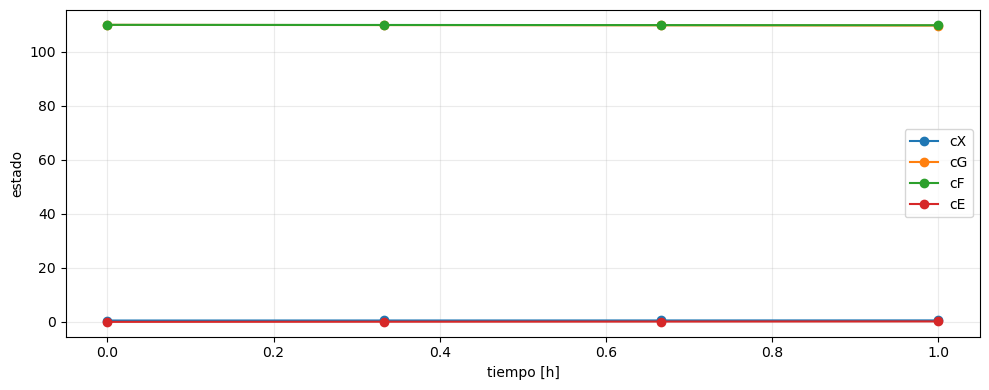

PASS: RHS externo consistente, trazable y usable para integración secuencial corta.


In [27]:
phase8_layout = build_state_layout()
phase8_initial_state = {
    "cX": _phase8_default_for_state_name("cX"),
    "cN_free": _phase8_default_for_state_name("cN_free"),
    "cG": _phase8_default_for_state_name("cG"),
    "cF": _phase8_default_for_state_name("cF"),
    "cE": _phase8_default_for_state_name("cE"),
    "cO2": _phase8_default_for_state_name("cO2"),
    "cProt": _phase8_default_for_state_name("cProt"),
    "cCarb": _phase8_default_for_state_name("cCarb"),
    "cGly": 0.0,
    "cPyruvate": _phase8_default_for_state_name("cPyruvate"),
    "cAcetaldehyde": _phase8_default_for_state_name("cAcetaldehyde"),
    "aa_state": {},
}
phase8_y0_res = state_dict_to_vector(phase8_initial_state, layout=phase8_layout)
phase8_roundtrip_state = state_vector_to_dict(phase8_y0_res["state_vector"], layout=phase8_layout)
phase8_roundtrip_vec = state_dict_to_vector(phase8_roundtrip_state["state_dict"], layout=phase8_layout)

phase8_test_cases = [("initial", 0.0, phase8_y0_res["state_vector"])]
if "states_df_phase" in globals() and states_df_phase is not None and len(states_df_phase) > 0:
    t_values = np.asarray(states_df_phase["t_h"].to_numpy(dtype=float), dtype=float)
    t_values = t_values[np.isfinite(t_values)]
    if len(t_values):
        for label, idx in [
            ("intermediate", int(round(0.50 * (len(t_values) - 1)))),
            ("late", len(t_values) - 1),
        ]:
            row = states_df_phase.iloc[idx]
            state = _extract_state_values(row)
            state["cProt"] = max(0.0, _phase8_safe_float(row.get("Prot_g_L", state.get("cProt", 0.0)), default=state.get("cProt", 0.0)))
            state["cCarb"] = max(0.0, _phase8_safe_float(row.get("Carb_g_L", state.get("cCarb", 0.0)), default=state.get("cCarb", 0.0)))
            state["cGly"] = max(0.0, _phase8_safe_float(row.get("Gly_g_L", 0.0), default=0.0))
            y = state_dict_to_vector(state, layout=phase8_layout)["state_vector"]
            phase8_test_cases.append((label, float(row.get("t_h", t_values[idx])), y))
else:
    plausible_mid = dict(phase8_initial_state)
    plausible_mid.update({"cG": phase8_initial_state["cG"] * 0.55, "cF": phase8_initial_state["cF"] * 0.65, "cE": 25.0})
    plausible_late = dict(phase8_initial_state)
    plausible_late.update({"cG": 2.0, "cF": 4.0, "cN_free": 1e-3, "cE": 70.0})
    phase8_test_cases.extend([
        ("intermediate", 24.0, state_dict_to_vector(plausible_mid, layout=phase8_layout)["state_vector"]),
        ("late", 72.0, state_dict_to_vector(plausible_late, layout=phase8_layout)["state_vector"]),
    ])

phase8_rows = []
phase8_state_rows = []
phase8_flux_rows = []
phase8_derivative_rows = []
phase8_failures = []
phase8_warnings = []

for label, t_probe, y_probe in phase8_test_cases:
    trace = rhs_dfba(t_probe, y_probe, return_trace=True)
    dydt = np.asarray(trace["dydt_vector"], dtype=float)
    snapshot = trace.get("snapshot") or {}
    meta = trace.get("snapshot_meta", {}) or {}
    flux = trace.get("flux_dict", {}) or {}
    deriv = trace.get("derivative_dict", {}) or {}
    missing_fluxes = trace.get("missing_fluxes", []) or []
    n_fallbacks = int(bool(flux.get("used_fallback"))) + len(meta.get("mechanistic_pipeline_fallbacks_used", []) or [])
    solver_status = meta.get("lexicographic_final_status", flux.get("solver_status"))
    row_issues = []
    row_notes = []

    if not trace.get("state_valid"):
        row_issues.append("state_valid=False")
    if not trace.get("snapshot_valid"):
        row_issues.append("snapshot_valid=False")
    if solver_status not in tuple(DFBA_RHS_DEFAULTS["acceptable_solver_statuses"]):
        row_issues.append(f"solver_status={solver_status}")
    if not trace.get("flux_extraction_valid"):
        row_issues.append("flux_extraction_valid=False")
    if not trace.get("balance_valid"):
        row_issues.append("balance_valid=False")
    if not trace.get("dydt_valid"):
        row_issues.append("dydt_valid=False")
    if len(dydt) != len(phase8_layout["state_names"]):
        row_issues.append(f"dimensión dy/dt inválida: {len(dydt)}")
    if not np.all(np.isfinite(dydt)):
        row_issues.append("dy/dt contiene NaN/inf")
    optional_missing = [m for m in missing_fluxes if m.get("label") not in {"glucose", "fructose", "ethanol", "biomass"}]
    if optional_missing:
        row_notes.append(f"flujos opcionales faltantes: {optional_missing[:3]}")
    if flux.get("used_fallback"):
        row_notes.append("flux fallback desde límites Zenteno")
    if trace.get("rhs_notes"):
        material_notes = [
            str(note) for note in trace.get("rhs_notes", [])
            if "clamp" not in str(note)
            and "caída de biomasa no evaluable" not in str(note)
            and "activación bajo floor" not in str(note)
        ]
        row_notes.extend(material_notes[:3])

    if row_issues:
        diagnostic = "FAIL"
        phase8_failures.append({"case": label, "time": t_probe, "issues": row_issues})
    elif row_notes:
        diagnostic = "WARNING"
        phase8_warnings.append({"case": label, "time": t_probe, "notes": row_notes})
    else:
        diagnostic = "PASS"

    phase8_rows.append({
        "case": label,
        "time": float(t_probe),
        "phase_label": meta.get("phase_label"),
        "snapshot_valid": trace.get("snapshot_valid"),
        "solver_status": solver_status,
        "flux_extraction_valid": trace.get("flux_extraction_valid"),
        "balance_valid": trace.get("balance_valid"),
        "rhs_valid": trace.get("rhs_valid"),
        "n_missing_fluxes": len(missing_fluxes),
        "n_fallbacks": n_fallbacks,
        "norm_dydt": float(np.linalg.norm(dydt)) if len(dydt) else np.nan,
        "diagnostic": diagnostic,
        "rhs_notes": "; ".join(dict.fromkeys(row_notes + row_issues)),
    })

    state_row = {"case": label, "time": float(t_probe)}
    state_row.update(trace.get("state_dict", {}))
    state_row.pop("aa_state", None)
    phase8_state_rows.append(state_row)

    flux_row = {"case": label, "time": float(t_probe)}
    for key in ["mu_h_inv", "q_glucose_mmol_gDW_h", "q_fructose_mmol_gDW_h", "q_n_total_gN_gDW_h", "p_ethanol_mmol_gDW_h", "p_glycerol_mmol_gDW_h", "used_fallback"]:
        flux_row[key] = flux.get(key)
    phase8_flux_rows.append(flux_row)

    deriv_row = {"case": label, "time": float(t_probe)}
    deriv_row.update(deriv)
    phase8_derivative_rows.append(deriv_row)

mechanistic_phase8_rhs_audit_df = pd.DataFrame(phase8_rows)
mechanistic_phase8_state_audit_df = pd.DataFrame(phase8_state_rows)
mechanistic_phase8_flux_audit_df = pd.DataFrame(phase8_flux_rows)
mechanistic_phase8_derivative_audit_df = pd.DataFrame(phase8_derivative_rows)

display(mechanistic_phase8_rhs_audit_df)
display(mechanistic_phase8_state_audit_df)
display(mechanistic_phase8_flux_audit_df)
display(mechanistic_phase8_derivative_audit_df)

phase8_integration = integrate_dfba_sequential(
    y0=phase8_y0_res["state_vector"],
    t_span=(0.0, 1.0),
    t_eval=np.linspace(0.0, 1.0, 4),
    return_traces=False,
)
mechanistic_phase8_integration_df = phase8_integration["state_trajectory_df"]
display(mechanistic_phase8_integration_df)

roundtrip_ok = bool(
    phase8_layout.get("layout_valid", False)
    and phase8_y0_res.get("vector_valid", False)
    and phase8_roundtrip_state.get("state_valid", False)
    and phase8_roundtrip_vec.get("vector_valid", False)
    and np.allclose(phase8_y0_res["state_vector"], phase8_roundtrip_vec["state_vector"], rtol=1e-10, atol=1e-10)
)
if not roundtrip_ok:
    phase8_failures.append({"case": "layout_roundtrip", "time": np.nan, "issues": ["layout/vector roundtrip inconsistente"]})
if not phase8_integration.get("integration_valid"):
    phase8_failures.append({"case": "short_integration", "time": np.nan, "issues": phase8_integration.get("integration_notes", ["integración inválida"])})
elif phase8_integration.get("integration_notes"):
    phase8_warnings.append({"case": "short_integration", "time": np.nan, "notes": phase8_integration.get("integration_notes", [])})

print("Diagnostico RHS externo Fase 8:")
print(f"- layout valido: {phase8_layout.get('layout_valid')}, n_states={len(phase8_layout['state_names'])}")
print(f"- roundtrip vector<->dict: {roundtrip_ok}")
print(f"- evaluaciones RHS auditadas: {len(mechanistic_phase8_rhs_audit_df)}")
print(f"- integración corta válida: {phase8_integration.get('integration_valid')}")

try:
    import matplotlib.pyplot as plt

    plot_cols = [col for col in ["cX", "cG", "cF", "cE"] if col in mechanistic_phase8_integration_df.columns]
    fig, ax = plt.subplots(figsize=(10, 4))
    for col in plot_cols:
        ax.plot(mechanistic_phase8_integration_df["t_h"], mechanistic_phase8_integration_df[col], marker="o", label=col)
    ax.set_xlabel("tiempo [h]")
    ax.set_ylabel("estado")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[WARN] No se pudo generar gráfico matplotlib: {exc}")

if phase8_failures:
    print("FAIL: RHS externo Fase 8 presenta inconsistencias graves.")
    for failure in phase8_failures:
        print(f"- {failure['case']} t={failure['time']}: " + "; ".join(failure["issues"]))
    warnings.warn("Auditoría Fase 8 falló; revisar `mechanistic_phase8_rhs_audit_df`.", RuntimeWarning)
elif phase8_warnings:
    print("WARNING: RHS externo Fase 8 estable pero con observaciones auditables.")
    for warning in phase8_warnings[:10]:
        print(f"- {warning['case']} t={warning['time']}: " + "; ".join(warning["notes"][:4]))
    if len(phase8_warnings) > 10:
        print(f"- ... {len(phase8_warnings) - 10} observaciones adicionales en tablas de auditoría")
    warnings.warn("Auditoría Fase 8 con observaciones; revisar trazas RHS.", RuntimeWarning)
else:
    print("PASS: RHS externo consistente, trazable y usable para integración secuencial corta.")


### Interpretación esperada de la Fase 8

En Fase 8 se agregó una capa dinámica externa sobre el motor mecanístico del snapshot. La arquitectura ahora tiene un layout explícito del estado, conversiones reversibles entre vector y diccionario, construcción de snapshots desde el estado actual `t, y`, extracción de flujos LP, balances macroscópicos y un `rhs_dfba(...)` reutilizable por integradores.

El cambio respecto a Fase 7 es que el snapshot ya no es solo una evaluación aislada enriquecida por módulos: ahora puede actuar como motor local dentro de un RHS dinámico. `states_df_phase` queda como herramienta de auditoría o fuente de estados plausibles, pero el camino operativo del RHS es `t, y -> snapshot -> fluxes -> dy/dt`.

La evidencia de funcionamiento queda en `mechanistic_phase8_rhs_audit_df`, `mechanistic_phase8_flux_audit_df`, `mechanistic_phase8_derivative_audit_df` y `mechanistic_phase8_integration_df`. Se espera ver layout reversible, snapshots válidos, flujos principales identificados, derivadas finitas y una integración corta que avanza sin romperse.

Las limitaciones siguen siendo deliberadas: los balances macroscópicos son una primera encapsulación conservadora de fluxes a estados, no una recalibración completa del kernel dinámico. Faltan caching, eventos de fase, manejo avanzado de discontinuidades, comparación sistemática con datos experimentales y una política más fina para estados auxiliares.

La Fase 9 debería enfocarse en simulación completa: eventos de fase, control de pasos, caching de snapshots, comparación contra datos experimentales y diagnóstico de desempeño numérico frente a trayectorias observadas.


### Fase 9 - Simulación completa, eventos, cache y profiling interno

La Fase 9 convierte el RHS externo de Fase 8 en una infraestructura de simulación completa. Un RHS funcional permite evaluar `dy/dt`, pero no basta para una corrida dFBA usable: una simulación completa necesita decidir pasos, detectar transiciones fisiológicas, reutilizar snapshots, registrar flujos y especies secundarias, y medir el costo numérico de cada evaluación.

En esta fase se agrega un runner de alto nivel que usa el motor `t, y -> snapshot -> fluxes -> dy/dt`, pero lo envuelve con políticas explícitas de eventos de fase, control de pasos, caching y profiling. Los eventos ya no se infieren a mano desde tablas finales: se detectan durante el avance temporal y se registran con fase previa, fase posterior, señales disparadoras y consistencia del snapshot.

El control de pasos queda separado del RHS. Esto permite refinar cerca de cambios de fase, reintentar con pasos menores si una evaluación falla, y mantener una trayectoria de salida independiente del paso interno. El cache también queda explícito: cada evaluación usa una clave basada en tiempo y estado discretizados, con métricas de hit/miss y política de tamaño máximo.

La simulación devuelve trayectorias estructuradas de estados, fases, flujos, especies secundarias/aromas, eventos y desempeño. Las especies secundarias se reportan aunque no estén disponibles: cada una queda marcada como reconstruida desde estado, flujo, señal proxy o no disponible. Se conserva el kernel Zenteno, el RHS de Fase 8 y toda la capa mecanística de Fases 1-7.


In [28]:
import time

PHASE9_FULL_SIMULATION_VERSION = "phase9_full_simulation_events_cache_profiling_v2_macro_pyruvate_acetaldehyde"

DFBA_SIMULATION_DEFAULTS = {
    "parameterization_note": "v1 operacional: runner secuencial con eventos, cache y profiling interno",
    "t_span": (0.0, 72.0),
    "output_interval_h": 1.0,
    "store_snapshot_objects": False,
    "store_rhs_traces": False,
    "max_internal_steps": 500,
    "stop_on_repeated_failures": True,
    "max_consecutive_failures": 3,
}

PHASE_EVENT_DEFAULTS = {
    "canonical_events": [
        "EVENT_EXIT_LAG",
        "EVENT_ENTER_EXP_GROWTH",
        "EVENT_N_PREFERRED_DEPLETION",
        "EVENT_ENTER_N_LIMITED_CARB_ACC",
        "EVENT_ENTER_STATIONARY",
        "EVENT_ENTER_DECAY",
    ],
    "phase_transition_events": {
        "F1_EXP_GROWTH": "EVENT_ENTER_EXP_GROWTH",
        "F2_N_LIMITED_CARB_ACC": "EVENT_ENTER_N_LIMITED_CARB_ACC",
        "F3_STATIONARY": "EVENT_ENTER_STATIONARY",
        "F4_DECAY": "EVENT_ENTER_DECAY",
    },
    "exit_lag_from": "F0_LAG_OSMO",
    "preferred_n_depletion_threshold": 0.15,
    "n_starvation_event_signal": "nitrogen_starvation_signal",
    "minimum_event_separation_h": 0.25,
    "one_shot_events": True,
    "allow_signal_events_without_phase_change": True,
}

PHASE_EVENT_LOGGING_DEFAULTS = {
    "include_state_summary": True,
    "include_trigger_signals": True,
    "include_snapshot_status": True,
    "report_absent_events": True,
}

STEP_CONTROL_DEFAULTS = {
    "parameterization_note": "v1 operacional: Euler explícito con retry/refinamiento auditable",
    "max_step_h": 1.0,
    "min_step_h": 1e-3,
    "first_step_h": 0.25,
    "event_refinement_step_h": 0.25,
    "retry_factor": 0.5,
    "max_retries_per_step": 3,
    "refine_on_phase_change": True,
    "retry_on_invalid_rhs": True,
    "large_state_change_fraction": 0.25,
    "sample_output_on_internal_steps": True,
}

SNAPSHOT_CACHE_DEFAULTS = {
    "enabled": True,
    "time_round_decimals": 6,
    "state_round_decimals": 8,
    "max_entries": 256,
    "store_snapshots": True,
    "eviction_policy": "fifo",
}

NUMERICAL_PROFILING_DEFAULTS = {
    "enabled": True,
    "timer": "perf_counter",
    "record_each_rhs_eval": True,
    "record_cache_metrics": True,
    "record_solver_status": True,
}

SECONDARY_SPECIES_DEFAULTS = {
    "ethanol": {"state_key": "cE", "flux_key": "p_ethanol_mmol_gDW_h"},
    "glycerol": {"state_key": "cGly", "flux_key": "p_glycerol_mmol_gDW_h", "module_path": ("redox_osmotic_module", "glycerol_min_flux_proxy")},
    "acetaldehyde": {
        "state_key": "cAcetaldehyde",
        "reaction_ids": ["r_1631"],
        "module_path": ("redox_osmotic_module", "acetaldehyde_ethanol_balance_signal"),
        "proxy_note": "usa estado macro explícito; exchange explícito y señal redox quedan como respaldo de trazabilidad",
    },
    "pyruvate": {"state_key": "cPyruvate", "reaction_ids": ["r_2033"]},
    "acetate": {"reaction_ids": ["r_1634"]},
    "ethyl_acetate": {"reaction_ids": ["r_1765"]},
    "isoamyl_acetate": {"reaction_ids": ["r_1862"]},
    "hexyl_acetate": {"reaction_ids": ["r_4647"]},
    "phenylethyl_acetate": {"reaction_ids": ["r_2000"], "module_path": ("acetate_ester_module", "acetate_ester_signal")},
    "ethyl_octanoate": {"reaction_ids": [], "module_path": ("mcfa_faee_module", "faee_signal"), "proxy_note": "proxy FAEE por señal MCFA; reacción explícita no garantizada"},
    "ethyl_decanoate": {"reaction_ids": [], "module_path": ("mcfa_faee_module", "faee_signal"), "proxy_note": "proxy FAEE por señal MCFA; reacción explícita no garantizada"},
    "benzaldehyde": {"module_path": ("ehrlich_benzenoid_module", "benzaldehyde_signal")},
    "benzyl_alcohol": {"module_path": ("ehrlich_benzenoid_module", "benzyl_alcohol_signal")},
    "mcfa_c8_proxy": {"reaction_ids": ["r_1984"], "module_path": ("mcfa_faee_module", "mcfa_signal")},
    "mcfa_c10_proxy": {"reaction_ids": ["r_1727"], "module_path": ("mcfa_faee_module", "mcfa_signal")},
}


def _phase9_deep_update(base, updates):
    """Actualiza recursivamente diccionarios simples sin mutar `base`."""
    out = dict(base)
    for key, value in dict(updates or {}).items():
        if isinstance(value, dict) and isinstance(out.get(key), dict):
            out[key] = _phase9_deep_update(out[key], value)
        else:
            out[key] = value
    return out


def _phase9_merge_config(defaults, config=None):
    """Combina defaults con overrides preservando subdiccionarios."""
    return _phase9_deep_update(defaults, config or {})


def _phase9_safe_float(value, default=np.nan):
    """Convierte a float finito o devuelve `default`."""
    try:
        if value is None:
            return default
        out = float(value)
        return out if np.isfinite(out) else default
    except (TypeError, ValueError):
        return default


def _phase9_get_nested(mapping, path, default=np.nan):
    """Extrae un valor desde un diccionario anidado usando `path`."""
    obj = mapping
    for key in tuple(path or ()):
        if not isinstance(obj, dict) or key not in obj:
            return default
        obj = obj[key]
    return obj


def build_phase_event_policy(config=None):
    """Define formalmente los eventos fisiológicos monitoreados.

    Returns
    -------
    dict
        Contiene `event_policy`, `event_names`, `policy_valid` y notas. Los
        eventos se basan en cambios de fase explícitos y señales auxiliares como
        depleción de nitrógeno preferente.
    """
    cfg = _phase9_merge_config(PHASE_EVENT_DEFAULTS, config)
    event_names = list(cfg["canonical_events"])
    policy = {
        "events": {
            "EVENT_EXIT_LAG": {"type": "phase_exit", "phase_from": cfg["exit_lag_from"]},
            "EVENT_ENTER_EXP_GROWTH": {"type": "phase_enter", "phase_to": "F1_EXP_GROWTH"},
            "EVENT_N_PREFERRED_DEPLETION": {
                "type": "signal_crossing",
                "signal": "preferred_n_signal",
                "direction": "below",
                "threshold": float(cfg["preferred_n_depletion_threshold"]),
            },
            "EVENT_ENTER_N_LIMITED_CARB_ACC": {"type": "phase_enter", "phase_to": "F2_N_LIMITED_CARB_ACC"},
            "EVENT_ENTER_STATIONARY": {"type": "phase_enter", "phase_to": "F3_STATIONARY"},
            "EVENT_ENTER_DECAY": {"type": "phase_enter", "phase_to": "F4_DECAY"},
        },
        "minimum_event_separation_h": float(cfg["minimum_event_separation_h"]),
        "one_shot_events": bool(cfg["one_shot_events"]),
        "allow_signal_events_without_phase_change": bool(cfg["allow_signal_events_without_phase_change"]),
        "version": PHASE9_FULL_SIMULATION_VERSION,
    }
    notes = []
    missing = [event for event in event_names if event not in policy["events"]]
    if missing:
        notes.append(f"eventos sin definición: {missing}")
    return {
        "event_policy": policy,
        "event_names": event_names,
        "policy_valid": not missing,
        "policy_notes": notes,
    }


def _phase9_phase_order_index(phase):
    """Orden canónico para detectar saltos de fase."""
    order = {
        "F0_LAG_OSMO": 0,
        "F1_EXP_GROWTH": 1,
        "F2_N_LIMITED_CARB_ACC": 2,
        "F3_STATIONARY": 3,
        "F4_DECAY": 4,
    }
    return order.get(phase, np.nan)


def _phase9_signal_from_meta(meta, signal_name, default=np.nan):
    """Busca una señal en metadatos de fase/NCR/pipeline."""
    meta = {} if meta is None else dict(meta)
    for container_key in [
        "phase_indicators",
        "ncr_signals",
        "nitrogen_ncr_pipeline_module",
        "mechanistic_pipeline_results",
    ]:
        container = meta.get(container_key, {})
        if isinstance(container, dict):
            if signal_name in container:
                return _phase9_safe_float(container.get(signal_name), default=default)
            if container_key == "nitrogen_ncr_pipeline_module":
                ncr = container.get("ncr_signals", {})
                if isinstance(ncr, dict) and signal_name in ncr:
                    return _phase9_safe_float(ncr.get(signal_name), default=default)
            if container_key == "mechanistic_pipeline_results":
                nmod = container.get("nitrogen_ncr", {})
                if isinstance(nmod, dict):
                    ncr = nmod.get("ncr_signals", {})
                    if isinstance(ncr, dict) and signal_name in ncr:
                        return _phase9_safe_float(ncr.get(signal_name), default=default)
    return default


def _phase9_event_recent(event_id, t, event_history, min_sep, one_shot=True):
    """Indica si un evento debe suprimirse por one-shot o separación mínima."""
    if not event_history:
        return False
    previous = [ev for ev in event_history if ev.get("event_id") == event_id]
    if not previous:
        return False
    if one_shot:
        return True
    last_time = max(_phase9_safe_float(ev.get("event_time"), default=-np.inf) for ev in previous)
    return bool(np.isfinite(last_time) and float(t) - last_time < float(min_sep))


def detect_phase_events(
    current_state,
    prev_state=None,
    current_phase=None,
    prev_phase=None,
    current_meta=None,
    prev_meta=None,
    t=None,
    event_policy=None,
    event_history=None,
):
    """Detecta eventos fisiológicos ocurridos durante un paso aceptado.

    Cada evento incluye `event_id`, tiempo, fase previa/posterior, razón y
    señales disparadoras. La función tolera metadatos parciales y evita chatter
    mediante separación mínima o política one-shot.
    """
    policy = (event_policy or build_phase_event_policy()["event_policy"])
    event_history = [] if event_history is None else list(event_history)
    t_event = _phase9_safe_float(t, default=np.nan)
    min_sep = float(policy.get("minimum_event_separation_h", 0.0))
    one_shot = bool(policy.get("one_shot_events", True))
    detected = []
    flags = {event_id: False for event_id in policy.get("events", {})}
    notes = []
    current_meta = {} if current_meta is None else dict(current_meta)
    prev_meta = {} if prev_meta is None else dict(prev_meta)

    def add_event(event_id, reason, signals):
        if _phase9_event_recent(event_id, t_event, event_history, min_sep, one_shot=one_shot):
            notes.append(f"{event_id}: suprimido por política anti-chatter/one-shot")
            return
        event = {
            "event_id": event_id,
            "event_time": float(t_event),
            "phase_from": prev_phase,
            "phase_to": current_phase,
            "trigger_reason": reason,
            "trigger_signals": signals,
            "event_valid": True,
        }
        detected.append(event)
        flags[event_id] = True

    if prev_phase is not None and current_phase is not None and prev_phase != current_phase:
        if prev_phase == "F0_LAG_OSMO" and current_phase != "F0_LAG_OSMO":
            add_event(
                "EVENT_EXIT_LAG",
                "salida directa de F0_LAG_OSMO por cambio de fase",
                {"prev_phase": prev_phase, "current_phase": current_phase},
            )
        transition_event = {
            "F1_EXP_GROWTH": "EVENT_ENTER_EXP_GROWTH",
            "F2_N_LIMITED_CARB_ACC": "EVENT_ENTER_N_LIMITED_CARB_ACC",
            "F3_STATIONARY": "EVENT_ENTER_STATIONARY",
            "F4_DECAY": "EVENT_ENTER_DECAY",
        }.get(current_phase)
        if transition_event:
            add_event(
                transition_event,
                f"entrada directa a {current_phase}",
                {"prev_phase": prev_phase, "current_phase": current_phase},
            )

    prev_pref = _phase9_signal_from_meta(prev_meta, "preferred_n_signal", default=np.nan)
    curr_pref = _phase9_signal_from_meta(current_meta, "preferred_n_signal", default=np.nan)
    threshold = _phase9_safe_float(policy["events"]["EVENT_N_PREFERRED_DEPLETION"].get("threshold"), default=0.15)
    n_starv = _phase9_signal_from_meta(current_meta, "nitrogen_starvation_signal", default=np.nan)
    crosses_pref = bool(np.isfinite(prev_pref) and np.isfinite(curr_pref) and prev_pref > threshold and curr_pref <= threshold)
    signal_starv = bool(_phase9_safe_float(n_starv, default=0.0) >= 0.5)
    if crosses_pref or (bool(policy.get("allow_signal_events_without_phase_change", True)) and signal_starv and current_phase in {"F2_N_LIMITED_CARB_ACC", "F3_STATIONARY", "F4_DECAY"}):
        add_event(
            "EVENT_N_PREFERRED_DEPLETION",
            "depleción de N preferente por cruce de señal o starvation explícito",
            {
                "preferred_n_signal_prev": prev_pref,
                "preferred_n_signal_current": curr_pref,
                "threshold": threshold,
                "nitrogen_starvation_signal": n_starv,
            },
        )

    valid = True
    if not np.isfinite(t_event):
        valid = False
        notes.append("tiempo de evento no finito")
    return {
        "detected_events": detected,
        "event_flags": flags,
        "event_valid": valid,
        "event_notes": notes,
    }


def build_step_control_policy(config=None):
    """Construye política explícita de control de pasos y retries."""
    cfg = _phase9_merge_config(STEP_CONTROL_DEFAULTS, config)
    notes = []
    min_step = float(cfg["min_step_h"])
    max_step = float(cfg["max_step_h"])
    first_step = float(cfg["first_step_h"])
    if min_step <= 0:
        notes.append("min_step_h <= 0; se corrige a 1e-6")
        min_step = 1e-6
    if max_step < min_step:
        notes.append("max_step_h < min_step_h; se iguala a min_step_h")
        max_step = min_step
    if first_step < min_step or first_step > max_step:
        notes.append("first_step_h fuera de rango; se clampa a [min_step, max_step]")
        first_step = min(max(first_step, min_step), max_step)
    policy = dict(cfg)
    policy.update({"min_step_h": min_step, "max_step_h": max_step, "first_step_h": first_step})
    return {
        "step_policy": policy,
        "policy_valid": True,
        "policy_notes": notes,
    }


def build_snapshot_cache(config=None):
    """Crea un cache explícito para snapshots/evaluaciones RHS."""
    cfg = _phase9_merge_config(SNAPSHOT_CACHE_DEFAULTS, config)
    cache = {
        "enabled": bool(cfg["enabled"]),
        "entries": {},
        "order": [],
        "stats": {
            "hits": 0,
            "misses": 0,
            "stores": 0,
            "evictions": 0,
        },
        "config": cfg,
        "version": PHASE9_FULL_SIMULATION_VERSION,
    }
    return {
        "cache_object": cache,
        "cache_valid": True,
        "cache_notes": [],
    }


def _phase9_cache_key(t, state_dict, cache, layout=None):
    """Construye clave discretizada de cache desde tiempo y estado."""
    cfg = cache.get("config", SNAPSHOT_CACHE_DEFAULTS)
    t_key = round(float(t), int(cfg.get("time_round_decimals", 6)))
    layout_info = layout or build_state_layout()
    names = layout_info.get("state_names", [])
    state = {} if state_dict is None else dict(state_dict)
    aa_state = state.get("aa_state", {}) or {}
    values = []
    for name in names:
        if name.startswith("aa_"):
            value = aa_state.get(name.replace("aa_", "", 1), 0.0)
        else:
            value = state.get(name, 0.0)
        values.append(round(_phase9_safe_float(value, default=0.0), int(cfg.get("state_round_decimals", 8))))
    return (t_key, tuple(values))


def _phase9_prune_cache(cache):
    """Aplica política FIFO de poda si el cache supera max_entries."""
    cfg = cache.get("config", SNAPSHOT_CACHE_DEFAULTS)
    max_entries = int(cfg.get("max_entries", 256))
    while len(cache["order"]) > max_entries:
        old_key = cache["order"].pop(0)
        cache["entries"].pop(old_key, None)
        cache["stats"]["evictions"] += 1


def get_or_build_snapshot_with_cache(
    t,
    state_dict,
    params=None,
    config=None,
    cache=None,
    prev_state=None,
    prev_phase=None,
    layout=None,
):
    """Recupera o construye un snapshot usando cache explícito."""
    notes = []
    if cache is None:
        cache = build_snapshot_cache()["cache_object"]
    key = _phase9_cache_key(t, state_dict, cache, layout=layout)
    if cache.get("enabled", True) and key in cache["entries"]:
        cache["stats"]["hits"] += 1
        entry = cache["entries"][key]
        return {
            "snapshot": entry["snapshot"],
            "cache_status": "hit",
            "snapshot_valid": entry.get("snapshot_valid", False),
            "snapshot_notes": list(entry.get("snapshot_notes", [])),
            "cache_key": key,
        }

    cache["stats"]["misses"] += 1
    snap_res = build_mechanistic_snapshot_model_from_state(
        t,
        state_dict,
        params=params,
        config=config,
        solve=True,
        prev_state=prev_state,
        prev_phase=prev_phase,
        solver_config=(config or {}).get("solver_config") if isinstance(config, dict) else None,
        biomass_params=(config or {}).get("biomass_params") if isinstance(config, dict) else None,
        gam_params=(config or {}).get("gam_params") if isinstance(config, dict) else None,
        turnover_params=(config or {}).get("turnover_params") if isinstance(config, dict) else None,
        nitrogen_params=(config or {}).get("nitrogen_params") if isinstance(config, dict) else None,
        pipeline_config=(config or {}).get("pipeline_config") if isinstance(config, dict) else None,
    )
    if cache.get("enabled", True) and cache.get("config", {}).get("store_snapshots", True):
        cache["entries"][key] = {
            "snapshot": snap_res.get("snapshot"),
            "snapshot_valid": snap_res.get("snapshot_valid", False),
            "snapshot_notes": list(snap_res.get("snapshot_notes", [])),
        }
        cache["order"].append(key)
        cache["stats"]["stores"] += 1
        _phase9_prune_cache(cache)
    notes.extend(snap_res.get("snapshot_notes", []))
    return {
        "snapshot": snap_res.get("snapshot"),
        "cache_status": "miss",
        "snapshot_valid": snap_res.get("snapshot_valid", False),
        "snapshot_notes": notes,
        "cache_key": key,
    }


def summarize_snapshot_for_logging(snapshot, flux_dict=None):
    """Resume un snapshot para logs de fase, flujos, especies y profiling."""
    snapshot = {} if snapshot is None else dict(snapshot)
    meta = snapshot.get("meta", {}) or {}
    sol = snapshot.get("solution")
    flux_dict = {} if flux_dict is None else dict(flux_dict)
    notes = []
    raw_secondary_fluxes = {}

    target_maps = globals().get("MECHANISTIC_PIPELINE_DEFAULTS", {}).get("target_reactions", {})
    rxn_ids = []
    for module_targets in target_maps.values():
        for ids in module_targets.values():
            rxn_ids.extend(list(ids or []))
    for spec in SECONDARY_SPECIES_DEFAULTS.values():
        rxn_ids.extend(list(spec.get("reaction_ids", []) or []))
    fluxes = getattr(sol, "fluxes", None)
    for rid in dict.fromkeys(rxn_ids):
        if fluxes is not None:
            try:
                value = _phase9_safe_float(fluxes.get(rid, np.nan), default=np.nan)
                if np.isfinite(value):
                    raw_secondary_fluxes[rid] = float(value)
            except Exception:
                continue

    summary = {
        "time": snapshot.get("actual_t_h", snapshot.get("requested_t_h")),
        "phase_label": meta.get("phase_label", snapshot.get("phase_label")),
        "phase_reason": meta.get("phase_reason", snapshot.get("phase_reason")),
        "transition_detected": meta.get("phase_transition_detected"),
        "legacy_mode_assigned": meta.get("legacy_mode_assigned", snapshot.get("legacy_mode_assigned")),
        "future_phase_objective_hint": meta.get("future_phase_objective_hint", snapshot.get("future_phase_objective_hint")),
        "solver_status": meta.get("lexicographic_final_status", getattr(sol, "status", None)),
        "objective_value": meta.get("lexicographic_final_objective_value", getattr(sol, "objective_value", np.nan)),
        "snapshot_valid": snapshot.get("snapshot_valid", False),
        "mechanistic_pipeline_valid": meta.get("mechanistic_pipeline_valid", snapshot.get("mechanistic_pipeline_valid")),
        "mechanistic_pipeline_fallbacks_used": meta.get("mechanistic_pipeline_fallbacks_used", snapshot.get("mechanistic_pipeline_fallbacks_used", [])),
        "phase_indicators": meta.get("phase_indicators", snapshot.get("phase_indicators", {})),
        "redox_osmotic_module": meta.get("redox_osmotic_module", snapshot.get("redox_osmotic_module", {})),
        "ehrlich_benzenoid_module": meta.get("ehrlich_benzenoid_module", snapshot.get("ehrlich_benzenoid_module", {})),
        "acetate_ester_module": meta.get("acetate_ester_module", snapshot.get("acetate_ester_module", {})),
        "mcfa_faee_module": meta.get("mcfa_faee_module", snapshot.get("mcfa_faee_module", {})),
        "flux_dict": flux_dict,
        "secondary_reaction_fluxes": raw_secondary_fluxes,
    }
    valid = bool(summary["phase_label"] is not None)
    if not valid:
        notes.append("snapshot sin phase_label")
    return {
        "snapshot_summary": summary,
        "summary_valid": valid,
        "summary_notes": notes,
    }


def _phase9_evaluate_rhs_with_cache(t, y, layout, cache, params=None, config=None, prev_state=None, prev_phase=None, eval_context=None):
    """Evalúa RHS usando cache explícito de snapshots y devuelve traza completa."""
    t0 = time.perf_counter()
    eval_context = {} if eval_context is None else dict(eval_context)
    perf = {
        "eval_time": float(t),
        "eval_context": eval_context.get("kind", "rhs"),
        "step_index": eval_context.get("step_index"),
        "retry_index": eval_context.get("retry_index", 0),
    }

    state_t0 = time.perf_counter()
    state_res = state_vector_to_dict(y, layout=layout, config=config)
    state = state_res["state_dict"]
    perf["state_decode_s"] = time.perf_counter() - state_t0

    snap_t0 = time.perf_counter()
    snap_res = get_or_build_snapshot_with_cache(
        t,
        state,
        params=params,
        config=config,
        cache=cache,
        prev_state=prev_state,
        prev_phase=prev_phase,
        layout=layout,
    )
    snapshot = snap_res.get("snapshot")
    perf["snapshot_build_or_cache_s"] = time.perf_counter() - snap_t0
    perf["cache_status"] = snap_res.get("cache_status")
    perf["snapshot_valid"] = snap_res.get("snapshot_valid")

    flux_t0 = time.perf_counter()
    flux_res = extract_macro_fluxes_from_snapshot(snapshot, config=config)
    perf["flux_extract_s"] = time.perf_counter() - flux_t0

    bal_t0 = time.perf_counter()
    balance_res = compute_macro_balances_from_fluxes(
        flux_res.get("flux_dict", {}),
        state,
        layout=layout,
        config=config,
        snapshot=snapshot,
    )
    vector_res = derivative_dict_to_vector(balance_res.get("derivative_dict", {}), layout=layout, config=config)
    perf["balance_vector_s"] = time.perf_counter() - bal_t0
    perf["total_eval_s"] = time.perf_counter() - t0

    dydt = vector_res.get("dydt_vector", np.zeros(len(layout.get("state_names", []))))
    meta = snapshot.get("meta", {}) if isinstance(snapshot, dict) else {}
    solver_status = meta.get("lexicographic_final_status", flux_res.get("flux_dict", {}).get("solver_status"))
    rhs_valid = bool(
        state_res.get("state_valid", False)
        and snap_res.get("snapshot_valid", False)
        and flux_res.get("flux_extraction_valid", False)
        and balance_res.get("balance_valid", False)
        and vector_res.get("dydt_valid", False)
        and np.all(np.isfinite(dydt))
    )
    perf.update({
        "solver_status": solver_status,
        "rhs_valid": rhs_valid,
        "n_missing_fluxes": len(flux_res.get("missing_fluxes", []) or []),
        "used_flux_fallback": bool(flux_res.get("flux_dict", {}).get("used_fallback", False)),
    })
    summary = summarize_snapshot_for_logging(snapshot, flux_dict=flux_res.get("flux_dict", {}))
    notes = (
        list(state_res.get("state_notes", []))
        + list(snap_res.get("snapshot_notes", []))
        + list(flux_res.get("flux_extraction_notes", []))
        + list(balance_res.get("balance_notes", []))
        + list(vector_res.get("dydt_notes", []))
        + list(summary.get("summary_notes", []))
    )
    if not rhs_valid:
        notes.append("evaluación RHS cacheada no válida")
    return {
        "dydt_vector": np.asarray(dydt, dtype=float),
        "state_dict": state,
        "state_valid": state_res.get("state_valid", False),
        "snapshot": snapshot,
        "snapshot_summary": summary.get("snapshot_summary", {}),
        "snapshot_valid": snap_res.get("snapshot_valid", False),
        "cache_status": snap_res.get("cache_status"),
        "flux_dict": flux_res.get("flux_dict", {}),
        "missing_fluxes": flux_res.get("missing_fluxes", []),
        "flux_extraction_valid": flux_res.get("flux_extraction_valid", False),
        "derivative_dict": balance_res.get("derivative_dict", {}),
        "balance_valid": balance_res.get("balance_valid", False),
        "rhs_valid": rhs_valid,
        "rhs_notes": notes,
        "performance": perf,
    }


def build_phase_trajectory_df(snapshot_logs):
    """Construye trayectoria explícita de fases desde logs de snapshots."""
    rows = []
    notes = []
    for log in list(snapshot_logs or []):
        summary = log.get("snapshot_summary", log)
        rows.append({
            "time": summary.get("time", log.get("time")),
            "phase_label": summary.get("phase_label"),
            "phase_reason": summary.get("phase_reason"),
            "transition_detected": summary.get("transition_detected"),
            "legacy_mode_assigned": summary.get("legacy_mode_assigned"),
            "future_phase_objective_hint": summary.get("future_phase_objective_hint"),
            "solver_status": summary.get("solver_status"),
            "snapshot_valid": summary.get("snapshot_valid"),
        })
    df = pd.DataFrame(rows)
    valid = bool(not df.empty and "phase_label" in df and df["phase_label"].notna().any())
    if not valid:
        notes.append("phase_trajectory_df vacío o sin fases")
    return {"phase_trajectory_df": df, "phase_trajectory_valid": valid, "phase_trajectory_notes": notes}


def build_flux_trajectory_df(snapshot_logs, config=None):
    """Construye trayectoria de flujos macroscópicos principales."""
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    modeling_config = build_modeling_config(
        base_config=config if isinstance(config, dict) else None,
        mode=_mode,
    )
    rows = []
    notes = []
    for log in list(snapshot_logs or []):
        summary = log.get("snapshot_summary", log)
        flux = summary.get("flux_dict", log.get("flux_dict", {})) or {}
        rows.append({
            "time": summary.get("time", log.get("time")),
            "phase_label": summary.get("phase_label"),
            "mu_h_inv": flux.get("mu_h_inv"),
            "q_glucose_mmol_gDW_h": flux.get("q_glucose_mmol_gDW_h"),
            "q_fructose_mmol_gDW_h": flux.get("q_fructose_mmol_gDW_h"),
            "q_n_total_gN_gDW_h": flux.get("q_n_total_gN_gDW_h"),
            "p_ethanol_mmol_gDW_h": flux.get("p_ethanol_mmol_gDW_h"),
            "p_glycerol_mmol_gDW_h": flux.get("p_glycerol_mmol_gDW_h"),
            "p_pyruvate_mmol_gDW_h": flux.get("p_pyruvate_mmol_gDW_h"),
            "p_acetaldehyde_mmol_gDW_h": flux.get("p_acetaldehyde_mmol_gDW_h"),
            "v_pyruvate": flux.get("v_pyruvate"),
            "v_acetaldehyde": flux.get("v_acetaldehyde"),
            "v_atpm": flux.get("v_atpm"),
            "used_fallback": flux.get("used_fallback"),
            "modeling_config_mode": flux.get("modeling_config_mode", modeling_config.get("mode")),
        })
    df = pd.DataFrame(rows)
    valid = bool(not df.empty and "time" in df)
    if not valid:
        notes.append("flux_trajectory_df vacío")
    return {"flux_trajectory_df": df, "flux_trajectory_valid": valid, "flux_trajectory_notes": notes}


def build_secondary_species_trajectory_df(state_logs, snapshot_logs, species_config=None):
    """Construye trayectoria explícita de aromas y especies secundarias.

    Cada especie queda con tres columnas: valor, disponibilidad y fuente. Si una
    especie no existe explícitamente, queda como NaN con fuente `not_available`
    o como proxy de módulo si hay señal mecanística disponible.
    """
    species_cfg = _phase9_deep_update(SECONDARY_SPECIES_DEFAULTS, species_config or {})
    rows = []
    notes = []
    state_logs = list(state_logs or [])
    snapshot_logs = list(snapshot_logs or [])
    for i, st_log in enumerate(state_logs):
        summary = snapshot_logs[i].get("snapshot_summary", {}) if i < len(snapshot_logs) else {}
        flux = summary.get("flux_dict", {}) or {}
        secondary_fluxes = summary.get("secondary_reaction_fluxes", {}) or {}
        row = {"time": st_log.get("time"), "phase_label": summary.get("phase_label")}
        state = st_log.get("state_dict", {}) or {}
        for species, spec in species_cfg.items():
            value = np.nan
            source = "not_available"
            available = False
            if spec.get("state_key") in state:
                value = _phase9_safe_float(state.get(spec["state_key"]), default=np.nan)
                source = "state"
                available = np.isfinite(value)
            elif spec.get("flux_key") in flux:
                value = _phase9_safe_float(flux.get(spec["flux_key"]), default=np.nan)
                source = "flux"
                available = np.isfinite(value)
            else:
                for rid in spec.get("reaction_ids", []) or []:
                    if rid in secondary_fluxes:
                        value = _phase9_safe_float(secondary_fluxes.get(rid), default=np.nan)
                        source = f"reaction_flux:{rid}"
                        available = np.isfinite(value)
                        break
                if not available and spec.get("module_path"):
                    value = _phase9_safe_float(_phase9_get_nested(summary, spec["module_path"], default=np.nan), default=np.nan)
                    if np.isfinite(value):
                        source = "module_signal_proxy"
                        available = True
            row[species] = value
            row[f"{species}_available"] = bool(available)
            row[f"{species}_source"] = source
        rows.append(row)
    df = pd.DataFrame(rows)
    if not df.empty:
        for species in species_cfg:
            if f"{species}_available" in df and not bool(df[f"{species}_available"].any()):
                notes.append(f"{species}: no disponible explícitamente en esta simulación")
    valid = bool(not df.empty)
    if not valid:
        notes.append("secondary_species_trajectory_df vacío")
    return {
        "secondary_species_trajectory_df": df,
        "secondary_species_valid": valid,
        "secondary_species_notes": notes,
    }


def build_event_log_df(event_history, event_policy=None):
    """Consolida eventos detectados en un DataFrame claro."""
    policy = event_policy or build_phase_event_policy()["event_policy"]
    event_columns = [
        "event_time",
        "event_id",
        "phase_from",
        "phase_to",
        "trigger_reason",
        "trigger_signals",
        "event_valid",
    ]
    rows = []
    for event in list(event_history or []):
        rows.append({
            "event_time": event.get("event_time"),
            "event_id": event.get("event_id"),
            "phase_from": event.get("phase_from"),
            "phase_to": event.get("phase_to"),
            "trigger_reason": event.get("trigger_reason"),
            "trigger_signals": event.get("trigger_signals"),
            "event_valid": event.get("event_valid", True),
        })
    df = pd.DataFrame(rows, columns=event_columns)
    notes = []
    if df.empty:
        notes.append("no se detectaron eventos durante la simulación")
    else:
        df = df.sort_values("event_time").reset_index(drop=True)
    absent = [ev for ev in policy.get("events", {}) if df.empty or ev not in set(df.get("event_id", []))]
    if absent:
        notes.append(f"eventos no observados en la corrida: {absent}")
    return {"event_log_df": df, "event_log_valid": True, "event_log_notes": notes}


def build_performance_log_df(performance_records, cache=None):
    """Construye log de desempeño numérico interno."""
    df = pd.DataFrame(list(performance_records or []))
    notes = []
    if df.empty:
        notes.append("performance_log_df vacío")
        valid = False
    else:
        valid = bool("total_eval_s" in df and df["total_eval_s"].notna().any())
    if cache is not None:
        stats = cache.get("stats", {})
        notes.append(f"cache hits={stats.get('hits', 0)}, misses={stats.get('misses', 0)}, evictions={stats.get('evictions', 0)}")
    return {"performance_log_df": df, "performance_log_valid": valid, "performance_log_notes": notes}


def summarize_simulation_run(
    state_trajectory_df=None,
    phase_trajectory_df=None,
    event_log_df=None,
    performance_log_df=None,
    cache=None,
    notes=None,
):
    """Genera resumen compacto de una corrida de simulación."""
    notes = [] if notes is None else list(notes)
    state_df = pd.DataFrame() if state_trajectory_df is None else state_trajectory_df
    phase_df = pd.DataFrame() if phase_trajectory_df is None else phase_trajectory_df
    event_df = pd.DataFrame() if event_log_df is None else event_log_df
    perf_df = pd.DataFrame() if performance_log_df is None else performance_log_df
    cache_stats = dict((cache or {}).get("stats", {}))
    solver_failures = int((perf_df.get("solver_status", pd.Series(dtype=object)) != "optimal").sum()) if not perf_df.empty and "solver_status" in perf_df else 0
    fallback_count = int(perf_df.get("used_flux_fallback", pd.Series(dtype=float)).fillna(False).astype(bool).sum()) if not perf_df.empty and "used_flux_fallback" in perf_df else 0
    duration = np.nan
    if not state_df.empty and "time" in state_df:
        duration = float(state_df["time"].max() - state_df["time"].min())
    phases = sorted(str(x) for x in phase_df.get("phase_label", pd.Series(dtype=object)).dropna().unique()) if not phase_df.empty else []
    total_eval_s = float(perf_df.get("total_eval_s", pd.Series(dtype=float)).sum()) if not perf_df.empty else 0.0
    summary = {
        "simulation_version": PHASE9_FULL_SIMULATION_VERSION,
        "duration_h": duration,
        "n_state_points": int(len(state_df)),
        "n_internal_evaluations": int(len(perf_df)),
        "n_events_detected": int(len(event_df)),
        "phases_visited": phases,
        "solver_failures": solver_failures,
        "fallback_count": fallback_count,
        "cache_hits": int(cache_stats.get("hits", 0)),
        "cache_misses": int(cache_stats.get("misses", 0)),
        "cache_evictions": int(cache_stats.get("evictions", 0)),
        "total_profiled_eval_s": total_eval_s,
        "notes": notes,
    }
    valid = bool(len(state_df) > 0 and solver_failures == 0)
    if not valid:
        notes.append("resumen indica corrida inválida o con fallos de solver")
    return {"simulation_summary": summary, "summary_valid": valid, "summary_notes": notes}


def _phase9_state_row(time_value, y_vec, layout, config=None):
    """Construye una fila plana de estado para trayectoria."""
    state = state_vector_to_dict(y_vec, layout=layout, config=config)["state_dict"]
    row = {"time": float(time_value)}
    for name in layout.get("state_names", []):
        if name.startswith("aa_"):
            row[name] = state.get("aa_state", {}).get(name.replace("aa_", "", 1), np.nan)
        else:
            row[name] = state.get(name, np.nan)
    return row, state


def simulate_dfba_full(
    initial_state=None,
    y0=None,
    t_span=None,
    params=None,
    config=None,
    return_raw_logs=False,
):
    """Ejecuta una simulación dFBA completa con eventos, cache y profiling.

    La rutina usa Euler explícito con control de pasos auditable y el motor RHS
    de Fase 8 evaluado mediante snapshots cacheados. Devuelve trayectorias de
    estados, fases, flujos, especies secundarias, eventos y desempeño.
    """
    _mode = dict(config or {}).get("mode", "strict") if isinstance(config, dict) else "strict"
    effective_config = build_modeling_config(base_config=config if isinstance(config, dict) else None, mode=_mode)
    sim_cfg = _phase9_merge_config(DFBA_SIMULATION_DEFAULTS, effective_config)
    step_info = build_step_control_policy(effective_config)
    step_policy = step_info["step_policy"]
    event_info = build_phase_event_policy(effective_config)
    event_policy = event_info["event_policy"]
    cache_info = build_snapshot_cache(effective_config)
    cache = cache_info["cache_object"]
    layout = build_state_layout(effective_config)
    notes = list(step_info.get("policy_notes", [])) + list(event_info.get("policy_notes", [])) + list(cache_info.get("cache_notes", []))

    if t_span is None:
        t_span = tuple(sim_cfg.get("t_span", (0.0, 72.0)))
    t0, tf = float(t_span[0]), float(t_span[1])
    if y0 is None:
        if initial_state is None:
            initial_state = {
                "cX": _phase8_default_for_state_name("cX"),
                "cN_free": _phase8_default_for_state_name("cN_free"),
                "cG": _phase8_default_for_state_name("cG"),
                "cF": _phase8_default_for_state_name("cF"),
                "cE": _phase8_default_for_state_name("cE"),
                "cO2": _phase8_default_for_state_name("cO2"),
                "cProt": _phase8_default_for_state_name("cProt"),
                "cCarb": _phase8_default_for_state_name("cCarb"),
                "cGly": 0.0,
                "cPyruvate": _phase8_default_for_state_name("cPyruvate"),
                "cAcetaldehyde": _phase8_default_for_state_name("cAcetaldehyde"),
                "aa_state": {},
            }
        y_current = state_dict_to_vector(initial_state, layout=layout, config=effective_config)["state_vector"]
    else:
        y_current = np.asarray(y0, dtype=float).copy()

    t_current = t0
    dt = min(float(step_policy["first_step_h"]), tf - t_current) if tf > t_current else 0.0
    state_logs = []
    snapshot_logs = []
    performance_records = []
    event_history = []
    raw_rhs_logs = []
    consecutive_failures = 0

    row, state_current = _phase9_state_row(t_current, y_current, layout, config=effective_config)
    state_logs.append({"time": t_current, "state_dict": state_current, "state_row": row})
    current_eval = _phase9_evaluate_rhs_with_cache(
        t_current,
        y_current,
        layout=layout,
        cache=cache,
        params=params,
        config=effective_config,
        eval_context={"kind": "initial", "step_index": 0},
    )
    performance_records.append(dict(current_eval["performance"]))
    snapshot_logs.append({"time": t_current, "snapshot_summary": current_eval.get("snapshot_summary", {}), "flux_dict": current_eval.get("flux_dict", {})})
    if return_raw_logs or bool(sim_cfg.get("store_rhs_traces", False)):
        raw_rhs_logs.append(current_eval)

    prev_phase = current_eval.get("snapshot_summary", {}).get("phase_label")
    prev_meta = current_eval.get("snapshot", {}).get("meta", {}) if isinstance(current_eval.get("snapshot"), dict) else {}
    prev_state = state_current
    step_index = 0

    while t_current < tf - 1e-12 and step_index < int(sim_cfg.get("max_internal_steps", 500)):
        step_index += 1
        dt = min(max(dt, float(step_policy["min_step_h"])), float(step_policy["max_step_h"]), tf - t_current)
        retry_index = 0
        accepted = False
        while not accepted:
            start_eval = _phase9_evaluate_rhs_with_cache(
                t_current,
                y_current,
                layout=layout,
                cache=cache,
                params=params,
                config=effective_config,
                prev_state=prev_state,
                prev_phase=prev_phase,
                eval_context={"kind": "step_start", "step_index": step_index, "retry_index": retry_index},
            )
            performance_records.append(dict(start_eval["performance"]))
            y_candidate = y_current + dt * np.asarray(start_eval["dydt_vector"], dtype=float)
            candidate_state_res = state_vector_to_dict(y_candidate, layout=layout, config=effective_config)
            y_candidate = state_dict_to_vector(candidate_state_res["state_dict"], layout=layout, config=effective_config)["state_vector"]
            t_candidate = t_current + dt
            end_eval = _phase9_evaluate_rhs_with_cache(
                t_candidate,
                y_candidate,
                layout=layout,
                cache=cache,
                params=params,
                config=effective_config,
                prev_state=prev_state,
                prev_phase=prev_phase,
                eval_context={"kind": "candidate_end", "step_index": step_index, "retry_index": retry_index},
            )
            perf_end = dict(end_eval["performance"])
            perf_end["accepted_step_h"] = dt
            performance_records.append(perf_end)

            current_phase = end_eval.get("snapshot_summary", {}).get("phase_label")
            phase_changed = bool(prev_phase is not None and current_phase is not None and current_phase != prev_phase)
            invalid_rhs = bool(not start_eval.get("rhs_valid", False) or not end_eval.get("rhs_valid", False))
            should_retry = False
            retry_reason = None
            if invalid_rhs and bool(step_policy.get("retry_on_invalid_rhs", True)) and dt > float(step_policy["min_step_h"]):
                should_retry = True
                retry_reason = "invalid_rhs"
            if (
                phase_changed
                and bool(step_policy.get("refine_on_phase_change", True))
                and dt > float(step_policy.get("event_refinement_step_h", step_policy["min_step_h"]))
            ):
                should_retry = True
                retry_reason = "phase_change_refinement"

            if should_retry and retry_index < int(step_policy.get("max_retries_per_step", 3)):
                notes.append(f"step {step_index}: retry por {retry_reason}, dt {dt:.6g} -> {dt * float(step_policy['retry_factor']):.6g}")
                dt = max(float(step_policy["min_step_h"]), dt * float(step_policy["retry_factor"]))
                retry_index += 1
                continue

            accepted = True
            if invalid_rhs:
                consecutive_failures += 1
                notes.append(f"step {step_index}: evaluación RHS inválida aceptada con dt={dt:.6g}")
            else:
                consecutive_failures = 0

            if consecutive_failures >= int(sim_cfg.get("max_consecutive_failures", 3)) and bool(sim_cfg.get("stop_on_repeated_failures", True)):
                notes.append("simulación detenida por fallos consecutivos de RHS")
                t_current = t_candidate
                y_current = y_candidate
                break

            event_res = detect_phase_events(
                candidate_state_res.get("state_dict", {}),
                prev_state=prev_state,
                current_phase=current_phase,
                prev_phase=prev_phase,
                current_meta=end_eval.get("snapshot", {}).get("meta", {}) if isinstance(end_eval.get("snapshot"), dict) else {},
                prev_meta=prev_meta,
                t=t_candidate,
                event_policy=event_policy,
                event_history=event_history,
            )
            event_history.extend(event_res.get("detected_events", []))
            if event_res.get("event_notes"):
                notes.extend(event_res["event_notes"])

            t_current = t_candidate
            y_current = y_candidate
            row, state_current = _phase9_state_row(t_current, y_current, layout, config=effective_config)
            state_logs.append({"time": t_current, "state_dict": state_current, "state_row": row})
            snapshot_logs.append({"time": t_current, "snapshot_summary": end_eval.get("snapshot_summary", {}), "flux_dict": end_eval.get("flux_dict", {})})
            if return_raw_logs or bool(sim_cfg.get("store_rhs_traces", False)):
                raw_rhs_logs.append(end_eval)
            prev_phase = current_phase
            prev_meta = end_eval.get("snapshot", {}).get("meta", {}) if isinstance(end_eval.get("snapshot"), dict) else {}
            prev_state = state_current
            dt = min(float(step_policy["max_step_h"]), max(dt / max(float(step_policy["retry_factor"]), 1e-12), float(step_policy["min_step_h"])))

    if step_index >= int(sim_cfg.get("max_internal_steps", 500)):
        notes.append("simulación alcanzó max_internal_steps")

    state_trajectory_df = pd.DataFrame([row["state_row"] for row in state_logs])
    phase_res = build_phase_trajectory_df(snapshot_logs)
    flux_res = build_flux_trajectory_df(snapshot_logs, config=effective_config)
    secondary_res = build_secondary_species_trajectory_df(state_logs, snapshot_logs)
    event_res = build_event_log_df(event_history, event_policy=event_policy)
    perf_res = build_performance_log_df(performance_records, cache=cache)
    summary_res = summarize_simulation_run(
        state_trajectory_df=state_trajectory_df,
        phase_trajectory_df=phase_res["phase_trajectory_df"],
        event_log_df=event_res["event_log_df"],
        performance_log_df=perf_res["performance_log_df"],
        cache=cache,
        notes=notes + phase_res.get("phase_trajectory_notes", []) + flux_res.get("flux_trajectory_notes", []) + secondary_res.get("secondary_species_notes", []) + event_res.get("event_log_notes", []) + perf_res.get("performance_log_notes", []),
    )
    simulation_valid = bool(
        len(state_trajectory_df) > 0
        and phase_res.get("phase_trajectory_valid", False)
        and flux_res.get("flux_trajectory_valid", False)
        and secondary_res.get("secondary_species_valid", False)
        and perf_res.get("performance_log_valid", False)
        and summary_res.get("summary_valid", False)
    )
    result = {
        "integration_result": {
            "t": state_trajectory_df["time"].to_numpy(dtype=float) if "time" in state_trajectory_df else np.array([]),
            "y": state_trajectory_df[[name for name in layout.get("state_names", []) if name in state_trajectory_df]].to_numpy(dtype=float).T if not state_trajectory_df.empty else np.empty((0, 0)),
            "success": simulation_valid,
            "message": "simulate_dfba_full completed" if simulation_valid else "simulate_dfba_full completed with warnings/failures",
            "step_policy": step_policy,
        },
        "state_trajectory_df": state_trajectory_df,
        "phase_trajectory_df": phase_res["phase_trajectory_df"],
        "flux_trajectory_df": flux_res["flux_trajectory_df"],
        "secondary_species_trajectory_df": secondary_res["secondary_species_trajectory_df"],
        "event_log_df": event_res["event_log_df"],
        "performance_log_df": perf_res["performance_log_df"],
        "simulation_summary": summary_res["simulation_summary"],
        "simulation_valid": simulation_valid,
        "simulation_notes": summary_res.get("summary_notes", []),
        "cache": cache,
        "policies": {
            "event_policy": event_policy,
            "step_policy": step_policy,
            "cache_config": cache.get("config", {}),
            "modeling_config": copy.deepcopy(effective_config),
        },
    }
    if return_raw_logs:
        result["raw_rhs_logs"] = raw_rhs_logs
        result["snapshot_logs"] = snapshot_logs
        result["state_logs"] = state_logs
    return result


_previous_entrypoint = dict(globals().get("MECHANISTIC_DEVELOPMENT_ENTRYPOINT", {}))
MECHANISTIC_DEVELOPMENT_ENTRYPOINT = {
    **_previous_entrypoint,
    "build_phase_event_policy": "Política explícita de eventos fisiológicos",
    "detect_phase_events": "Detección de eventos de fase y señales auxiliares",
    "build_step_control_policy": "Política explícita de control de pasos",
    "build_snapshot_cache": "Infraestructura auditable de cache de snapshots",
    "get_or_build_snapshot_with_cache": "Construcción/recuperación de snapshot con cache",
    "summarize_snapshot_for_logging": "Resumen compacto de snapshot para logging",
    "build_secondary_species_trajectory_df": "Trayectoria explícita de aromas/especies secundarias",
    "build_performance_log_df": "Log de profiling numérico interno",
    "simulate_dfba_full": "Runner completo de simulación secuencial dFBA",
    "build_phase_trajectory_df": "Trayectoria explícita de fases",
    "build_flux_trajectory_df": "Trayectoria explícita de flujos macro",
    "build_event_log_df": "Log consolidado de eventos fisiológicos",
    "summarize_simulation_run": "Resumen compacto de corrida completa",
    "DFBA_SIMULATION_DEFAULTS": "Configuración auditable de simulación completa",
    "PHASE_EVENT_DEFAULTS": "Configuración auditable de eventos",
    "STEP_CONTROL_DEFAULTS": "Configuración auditable de control de pasos",
    "SNAPSHOT_CACHE_DEFAULTS": "Configuración auditable de cache",
    "NUMERICAL_PROFILING_DEFAULTS": "Configuración auditable de profiling",
}

print("Capa mecanística Fase 9 lista. Objetos principales:")
for name, desc in MECHANISTIC_DEVELOPMENT_ENTRYPOINT.items():
    print(f"- {name:52s}: {desc} | {'OK' if name in globals() else 'MISSING'}")


Capa mecanística Fase 9 lista. Objetos principales:
- classify_phase                                      : Clasificador fisiológico explícito conservado | OK
- compute_phase_indicators                            : Indicadores macroscópicos auditables | OK
- compute_biomass_composition                         : Módulo explícito de composición dinámica de biomasa | OK
- compute_dynamic_gam                                 : Módulo explícito de GAM dependiente de composición | OK
- compute_biomass_and_gam_module                      : Wrapper composición + GAM | OK
- compute_turnover_activation                         : Activación fisiológica explícita de turnover proteico | OK
- compute_turnover_flux                               : Magnitud explícita de turnover proteico | OK
- distribute_turnover_recycled_pool                   : Distribución del pool reciclable hacia AA/N | OK
- compute_protein_turnover_module                     : Wrapper activación + flujo + pool reciclable | OK
- co

,time,cX,cN_free,cG,cF,cE,cO2,cProt,cCarb,cGly,cPyruvate,cAcetaldehyde
0,0.0,0.500000,0.140000,110.000000,110.000000,0.000000,0.0,0.230000,0.150000,0.000000,0.000000,0.000000
1,1.5,0.561724,0.134701,109.612497,109.796825,0.248257,0.0,0.258393,0.168881,0.031315,0.001924,0.004861
2,3.0,0.630829,0.128770,109.178599,109.569207,0.526295,0.0,0.290181,0.190043,0.066388,0.004060,0.010313
3,6.0,0.787495,0.115488,108.199393,109.059609,1.154111,0.0,0.362669,0.236692,0.143661,0.009632,0.022529
4,9.0,0.981048,0.099088,106.990172,108.428309,1.930480,0.0,0.452211,0.294276,0.239046,0.016370,0.037645
5,12.0,1.218278,0.079011,105.511608,107.650107,2.883279,0.0,0.561430,0.365444,0.355352,0.024451,0.056041
6,15.0,1.509896,0.054889,103.736365,106.698717,4.046546,0.0,0.680778,0.460912,0.485706,0.034032,0.077395
7,18.0,1.859285,0.026964,101.698954,105.550707,5.429655,0.0,0.802767,0.586127,0.617344,0.045238,0.099280
8,19.5,2.045342,0.012824,100.690712,104.886900,6.169509,0.0,0.855770,0.657316,0.677144,0.051593,0.107785
9,21.0,2.202411,0.001418,99.917089,104.213691,6.815480,0.0,0.894850,0.717896,0.727045,0.058162,0.114213


,time,phase_label,phase_reason,transition_detected,legacy_mode_assigned,future_phase_objective_hint,solver_status,snapshot_valid
0,0.0,F0_LAG_OSMO,ventana temprana con hexosas altas: adaptación...,False,BIOMASS,biomass_with_osmotic_adaptation_secondary_rese...,optimal,True
1,1.5,F0_LAG_OSMO,ventana temprana con hexosas altas: adaptación...,False,BIOMASS,biomass_with_osmotic_adaptation_secondary_rese...,optimal,True
2,3.0,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,True,BIOMASS,biomass_growth_primary,optimal,True
3,6.0,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,False,BIOMASS,biomass_growth_primary,optimal,True
4,9.0,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,False,BIOMASS,biomass_growth_primary,optimal,True
5,12.0,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,False,BIOMASS,biomass_growth_primary,optimal,True
6,15.0,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,False,BIOMASS,biomass_growth_primary,optimal,True
7,18.0,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,False,BIOMASS,biomass_growth_primary,optimal,True
8,19.5,F1_EXP_GROWTH,crecimiento activo con nitrógeno efectivo disp...,False,BIOMASS,biomass_growth_primary,optimal,True
9,21.0,F2_N_LIMITED_CARB_ACC,nitrógeno efectivo bajo con carbono aún dispon...,True,BIOMASS,nitrogen_limited_growth_carbon_storage_tradeof...,optimal,True


,time,phase_label,mu_h_inv,q_glucose_mmol_gDW_h,q_fructose_mmol_gDW_h,q_n_total_gN_gDW_h,p_ethanol_mmol_gDW_h,p_glycerol_mmol_gDW_h,p_pyruvate_mmol_gDW_h,p_acetaldehyde_mmol_gDW_h,v_pyruvate,v_acetaldehyde,v_atpm,used_fallback
0,0.0,F0_LAG_OSMO,0.082298,2.867907,1.503697,7.064773e-03,7.184921,0.453374,2.947333e-02,0.147122,2.947333e-02,0.147122,0.700000,False
1,1.5,F0_LAG_OSMO,0.082016,2.858411,1.499494,7.040043e-03,7.162613,0.451992,2.927862e-02,0.146878,2.927862e-02,0.146878,0.700000,False
2,3.0,F1_EXP_GROWTH,0.082783,2.872052,1.494670,7.018111e-03,7.200808,0.443364,3.419005e-02,0.146533,3.419005e-02,0.146533,0.700000,False
3,6.0,F1_EXP_GROWTH,0.081928,2.841111,1.483264,6.941818e-03,7.133144,0.438414,3.361678e-02,0.145244,3.361678e-02,0.145244,0.700000,False
4,9.0,F1_EXP_GROWTH,0.080604,2.788558,1.467681,6.821716e-03,7.027029,0.429098,3.290627e-02,0.141880,3.290627e-02,0.141880,0.700000,False
5,12.0,F1_EXP_GROWTH,0.079790,2.696135,1.444915,6.599867e-03,6.908653,0.387281,3.201206e-02,0.132631,3.201206e-02,0.132631,0.700000,False
6,15.0,F1_EXP_GROWTH,0.077133,2.496673,1.406788,6.164870e-03,6.627810,0.315559,3.083103e-02,0.109672,3.083103e-02,0.109672,0.700000,False
7,18.0,F1_EXP_GROWTH,0.066712,2.006683,1.321162,5.070008e-03,5.758247,0.232829,2.906683e-02,0.069224,2.906683e-02,0.069224,0.700000,False
8,19.5,F1_EXP_GROWTH,0.051196,1.399662,1.217990,3.717926e-03,4.570231,0.176610,2.772336e-02,0.047561,2.772336e-02,0.047561,0.700000,False
9,21.0,F2_N_LIMITED_CARB_ACC,0.016761,0.078824,1.002206,8.194482e-04,1.984375,0.043108,4.685296e-03,0.000000,4.685296e-03,0.000000,0.700000,False


,time,phase_label,ethanol,ethanol_available,ethanol_source,glycerol,glycerol_available,glycerol_source,acetaldehyde,acetaldehyde_available,...,benzaldehyde_source,benzyl_alcohol,benzyl_alcohol_available,benzyl_alcohol_source,mcfa_c8_proxy,mcfa_c8_proxy_available,mcfa_c8_proxy_source,mcfa_c10_proxy,mcfa_c10_proxy_available,mcfa_c10_proxy_source
0,0.0,F0_LAG_OSMO,0.000000,True,state,0.000000,True,state,0.000000,True,...,module_signal_proxy,0.017046,True,module_signal_proxy,0.000000e+00,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727
1,1.5,F0_LAG_OSMO,0.248257,True,state,0.031315,True,state,0.004861,True,...,module_signal_proxy,0.017078,True,module_signal_proxy,0.000000e+00,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727
2,3.0,F1_EXP_GROWTH,0.526295,True,state,0.066388,True,state,0.010313,True,...,module_signal_proxy,0.098833,True,module_signal_proxy,-1.279683e-17,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727
3,6.0,F1_EXP_GROWTH,1.154111,True,state,0.143661,True,state,0.022529,True,...,module_signal_proxy,0.099533,True,module_signal_proxy,0.000000e+00,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727
4,9.0,F1_EXP_GROWTH,1.930480,True,state,0.239046,True,state,0.037645,True,...,module_signal_proxy,0.100899,True,module_signal_proxy,0.000000e+00,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727
5,12.0,F1_EXP_GROWTH,2.883279,True,state,0.355352,True,state,0.056041,True,...,module_signal_proxy,0.125330,True,module_signal_proxy,-7.520711e-18,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727
6,15.0,F1_EXP_GROWTH,4.046546,True,state,0.485706,True,state,0.077395,True,...,module_signal_proxy,0.156178,True,module_signal_proxy,0.000000e+00,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727
7,18.0,F1_EXP_GROWTH,5.429655,True,state,0.617344,True,state,0.099280,True,...,module_signal_proxy,0.193199,True,module_signal_proxy,0.000000e+00,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727
8,19.5,F1_EXP_GROWTH,6.169509,True,state,0.677144,True,state,0.107785,True,...,module_signal_proxy,0.202411,True,module_signal_proxy,-4.655879e-18,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727
9,21.0,F2_N_LIMITED_CARB_ACC,6.815480,True,state,0.727045,True,state,0.114213,True,...,module_signal_proxy,0.601880,True,module_signal_proxy,0.000000e+00,True,reaction_flux:r_1984,0.000000e+00,True,reaction_flux:r_1727


,event_time,event_id,phase_from,phase_to,trigger_reason,trigger_signals,event_valid
0,3.0,EVENT_EXIT_LAG,F0_LAG_OSMO,F1_EXP_GROWTH,salida directa de F0_LAG_OSMO por cambio de fase,"{'prev_phase': 'F0_LAG_OSMO', 'current_phase':...",True
1,3.0,EVENT_ENTER_EXP_GROWTH,F0_LAG_OSMO,F1_EXP_GROWTH,entrada directa a F1_EXP_GROWTH,"{'prev_phase': 'F0_LAG_OSMO', 'current_phase':...",True
2,18.0,EVENT_N_PREFERRED_DEPLETION,F1_EXP_GROWTH,F1_EXP_GROWTH,depleción de N preferente por cruce de señal o...,{'preferred_n_signal_prev': 0.4361156369128012...,True
3,21.0,EVENT_ENTER_N_LIMITED_CARB_ACC,F1_EXP_GROWTH,F2_N_LIMITED_CARB_ACC,entrada directa a F2_N_LIMITED_CARB_ACC,"{'prev_phase': 'F1_EXP_GROWTH', 'current_phase...",True
4,54.0,EVENT_ENTER_STATIONARY,F2_N_LIMITED_CARB_ACC,F3_STATIONARY,entrada directa a F3_STATIONARY,"{'prev_phase': 'F2_N_LIMITED_CARB_ACC', 'curre...",True


,eval_time,eval_context,step_index,retry_index,state_decode_s,snapshot_build_or_cache_s,cache_status,snapshot_valid,flux_extract_s,balance_vector_s,total_eval_s,solver_status,rhs_valid,n_missing_fluxes,used_flux_fallback,accepted_step_h
0,0.0,initial,0,0,0.000018,4.878093,miss,True,0.000365,0.000096,4.878575,optimal,True,0,False,NaN
1,0.0,step_start,1,0,0.000024,0.000025,hit,True,0.000102,0.000080,0.000235,optimal,True,0,False,NaN
2,1.5,candidate_end,1,0,0.000022,4.281116,miss,True,0.000322,0.000095,4.281557,optimal,True,0,False,1.5
3,1.5,step_start,2,0,0.000014,0.000024,hit,True,0.000147,0.000081,0.000269,optimal,True,0,False,NaN
4,4.5,candidate_end,2,0,0.000020,4.436168,miss,True,0.000400,0.000111,4.436702,optimal,True,0,False,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,66.0,candidate_end,25,0,0.000085,3.239734,miss,True,0.000375,0.000108,3.240305,optimal,True,0,False,3.0
61,66.0,step_start,26,0,0.000017,0.000028,hit,True,0.000109,0.000091,0.000248,optimal,True,0,False,NaN
62,69.0,candidate_end,26,0,0.000024,3.340699,miss,True,0.000329,0.000090,3.341145,optimal,True,0,False,3.0
63,69.0,step_start,27,0,0.000014,0.000024,hit,True,0.000090,0.000076,0.000206,optimal,True,0,False,NaN


,simulation_version,duration_h,n_state_points,n_internal_evaluations,n_events_detected,phases_visited,solver_failures,fallback_count,cache_hits,cache_misses,cache_evictions,total_profiled_eval_s,notes
0,phase9_full_simulation_events_cache_profiling_...,72.0,28,65,5,"[F0_LAG_OSMO, F1_EXP_GROWTH, F2_N_LIMITED_CARB...",0,0,32,33,0,140.421542,"[step 2: retry por phase_change_refinement, dt..."


Eventos no observados en la ventana de prueba: ['EVENT_ENTER_DECAY']


,simulation_valid,n_state_points,n_phase_points,n_flux_points,n_secondary_points,n_events,n_perf_records,cache_hits,cache_misses,solver_failures,fallback_count,total_profiled_eval_s
0,True,28,28,28,28,5,65,32,33,0,0,140.421542


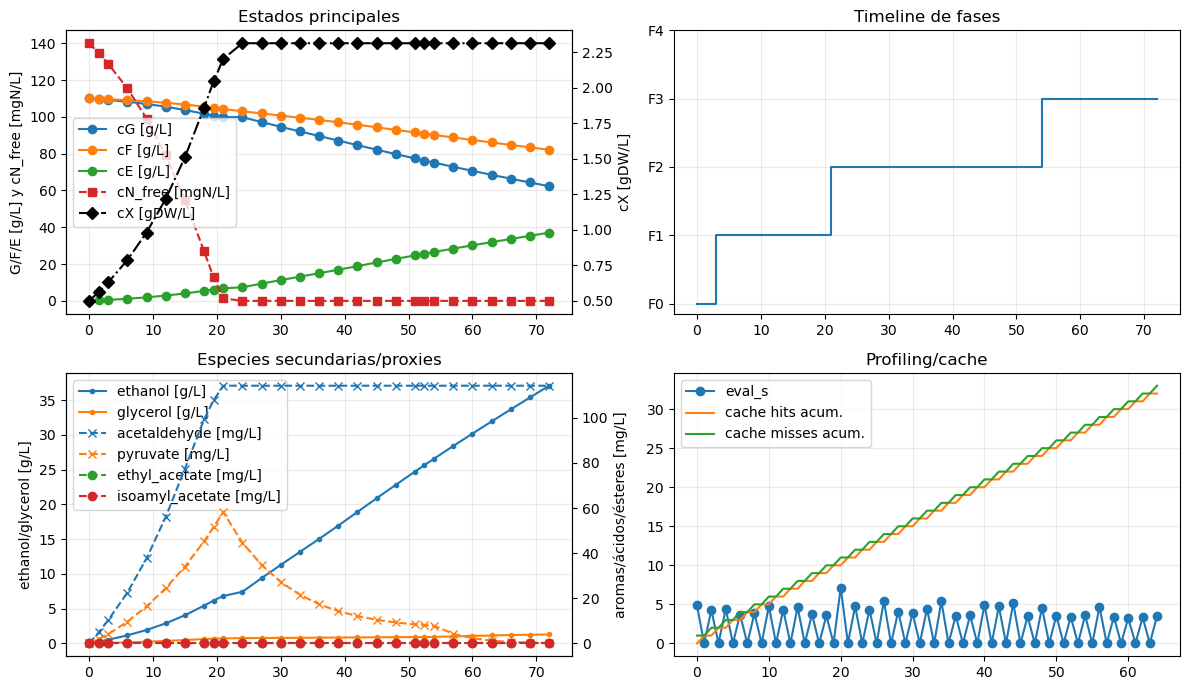

PASS: simulación completa end-to-end, eventos/cache/profiling trazables y salidas consistentes.


In [29]:
phase9_test_config = {
    "t_span": (0.0, 72.0),
    "output_interval_h": 6.0,
    "max_internal_steps": 80,
    "max_step_h": 3.0,
    "first_step_h": 1.5,
    "event_refinement_step_h": 0.5,
    "max_retries_per_step": 1,
    "refine_on_phase_change": True,
    "retry_on_invalid_rhs": True,
    "time_round_decimals": 3,
    "state_round_decimals": 5,
    "max_entries": 256,
    "store_snapshots": True,
    "store_rhs_traces": False,
    "store_snapshot_objects": False,
}


phase9_simulation_result = simulate_dfba_full(
    t_span=phase9_test_config["t_span"],
    config=phase9_test_config,
    return_raw_logs=False,
)

state_trajectory_df = phase9_simulation_result["state_trajectory_df"]
phase_trajectory_df = phase9_simulation_result["phase_trajectory_df"]
flux_trajectory_df = phase9_simulation_result["flux_trajectory_df"]
secondary_species_trajectory_df = phase9_simulation_result["secondary_species_trajectory_df"]
event_log_df = phase9_simulation_result["event_log_df"]
performance_log_df = phase9_simulation_result["performance_log_df"]
simulation_summary = phase9_simulation_result["simulation_summary"]

display(state_trajectory_df)
display(phase_trajectory_df)
display(flux_trajectory_df)
display(secondary_species_trajectory_df)
display(event_log_df)
display(performance_log_df)
display(pd.DataFrame([simulation_summary]))

phase9_failures = []
phase9_warnings = []

required_outputs = {
    "state_trajectory_df": state_trajectory_df,
    "phase_trajectory_df": phase_trajectory_df,
    "flux_trajectory_df": flux_trajectory_df,
    "secondary_species_trajectory_df": secondary_species_trajectory_df,
    "event_log_df": event_log_df,
    "performance_log_df": performance_log_df,
}
for name, df in required_outputs.items():
    if df is None or not isinstance(df, pd.DataFrame):
        phase9_failures.append(f"{name} no es DataFrame")
    elif name != "event_log_df" and df.empty:
        phase9_failures.append(f"{name} vacío")

if not bool(phase9_simulation_result.get("simulation_valid")):
    phase9_failures.append("simulation_valid=False")

if not state_trajectory_df.empty:
    if not state_trajectory_df["time"].is_monotonic_increasing:
        phase9_failures.append("state_trajectory_df no está ordenado temporalmente")
    if state_trajectory_df["time"].duplicated().any():
        phase9_warnings.append("state_trajectory_df contiene tiempos duplicados")
    numeric_state = state_trajectory_df.select_dtypes(include=[np.number])
    if not np.all(np.isfinite(numeric_state.to_numpy(dtype=float))):
        phase9_failures.append("state_trajectory_df contiene NaN/inf")

canonical_phases = set(PHASE_CLASSIFIER_DEFAULTS["canonical_phases"]) if "PHASE_CLASSIFIER_DEFAULTS" in globals() else {
    "F0_LAG_OSMO", "F1_EXP_GROWTH", "F2_N_LIMITED_CARB_ACC", "F3_STATIONARY", "F4_DECAY"
}
if not phase_trajectory_df.empty:
    observed_phases = set(phase_trajectory_df["phase_label"].dropna())
    invalid_phases = sorted(observed_phases - canonical_phases)
    if invalid_phases:
        phase9_failures.append(f"fases no canónicas: {invalid_phases}")
    phase_codes = phase_trajectory_df["phase_label"].map(_phase9_phase_order_index).to_numpy(dtype=float)
    jumps = np.diff(phase_codes[np.isfinite(phase_codes)])
    if len(jumps) and np.any(np.abs(jumps) > 2):
        phase9_warnings.append("saltos de fase grandes detectados; revisar event_log_df")

if not event_log_df.empty:
    if not event_log_df["event_time"].is_monotonic_increasing:
        phase9_failures.append("event_log_df no está ordenado por tiempo")
    if not set(event_log_df["event_id"]).issubset(set(PHASE_EVENT_DEFAULTS["canonical_events"])):
        phase9_failures.append("event_log_df contiene eventos no canónicos")
else:
    phase9_warnings.append("sin eventos detectados en la ventana corta de auditoría")

required_species = [
    "ethanol", "glycerol", "acetaldehyde", "pyruvate", "acetate", "ethyl_acetate",
    "isoamyl_acetate", "hexyl_acetate", "phenylethyl_acetate",
    "ethyl_octanoate", "ethyl_decanoate", "benzaldehyde", "benzyl_alcohol",
    "mcfa_c8_proxy", "mcfa_c10_proxy",
]
missing_species_columns = [sp for sp in required_species if sp not in secondary_species_trajectory_df.columns]
if missing_species_columns:
    phase9_failures.append(f"especies secundarias sin columna: {missing_species_columns}")
for sp in required_species:
    avail_col = f"{sp}_available"
    source_col = f"{sp}_source"
    if avail_col not in secondary_species_trajectory_df.columns or source_col not in secondary_species_trajectory_df.columns:
        phase9_failures.append(f"{sp}: faltan columnas de disponibilidad/fuente")
    elif not bool(secondary_species_trajectory_df[avail_col].any()):
        phase9_warnings.append(f"{sp}: no disponible explícitamente; reportado como {secondary_species_trajectory_df[source_col].iloc[0] if len(secondary_species_trajectory_df) else 'NA'}")

if performance_log_df.empty:
    phase9_failures.append("performance_log_df vacío")
else:
    for col in ["total_eval_s", "cache_status", "solver_status", "rhs_valid"]:
        if col not in performance_log_df.columns:
            phase9_failures.append(f"performance_log_df sin columna {col}")
    if "total_eval_s" in performance_log_df and not np.all(performance_log_df["total_eval_s"].fillna(0.0) >= 0.0):
        phase9_failures.append("performance_log_df tiene tiempos negativos")
    cache_statuses = set(performance_log_df.get("cache_status", pd.Series(dtype=object)).dropna())
    if not {"hit", "miss"}.intersection(cache_statuses):
        phase9_failures.append("cache sin métricas hit/miss explícitas")
    if "hit" not in cache_statuses:
        phase9_warnings.append("cache sin hits en corrida corta; puede ocurrir con pocos pasos/retries")
    if "miss" not in cache_statuses:
        phase9_warnings.append("cache sin misses; revisar política de construcción")

if simulation_summary:
    if "cache_hits" not in simulation_summary or "cache_misses" not in simulation_summary:
        phase9_failures.append("simulation_summary sin métricas de cache")
    if "total_profiled_eval_s" not in simulation_summary:
        phase9_failures.append("simulation_summary sin tiempo perfilado")
    absent_events = set(PHASE_EVENT_DEFAULTS["canonical_events"]) - set(event_log_df["event_id"]) if not event_log_df.empty else set(PHASE_EVENT_DEFAULTS["canonical_events"])
    print("Eventos no observados en la ventana de prueba:", sorted(absent_events))
else:
    phase9_failures.append("simulation_summary vacío")

phase9_audit_summary_df = pd.DataFrame([{
    "simulation_valid": phase9_simulation_result.get("simulation_valid"),
    "n_state_points": len(state_trajectory_df),
    "n_phase_points": len(phase_trajectory_df),
    "n_flux_points": len(flux_trajectory_df),
    "n_secondary_points": len(secondary_species_trajectory_df),
    "n_events": len(event_log_df),
    "n_perf_records": len(performance_log_df),
    "cache_hits": simulation_summary.get("cache_hits") if simulation_summary else np.nan,
    "cache_misses": simulation_summary.get("cache_misses") if simulation_summary else np.nan,
    "solver_failures": simulation_summary.get("solver_failures") if simulation_summary else np.nan,
    "fallback_count": simulation_summary.get("fallback_count") if simulation_summary else np.nan,
    "total_profiled_eval_s": simulation_summary.get("total_profiled_eval_s") if simulation_summary else np.nan,
}])
display(phase9_audit_summary_df)

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))

    # Estados principales: azúcares/etanol en eje izquierdo, cX en eje derecho.
    # cN_free se reporta explícitamente como mgN/L para evitar confusión con cN en gN/L.
    ax_state = axes[0, 0]
    ax_state_y2 = ax_state.twinx()
    for col in [c for c in ["cG", "cF", "cE"] if c in state_trajectory_df.columns]:
        ax_state.plot(state_trajectory_df["time"], state_trajectory_df[col], marker="o", label=f"{col} [g/L]")
    if "cN_free" in state_trajectory_df.columns:
        ax_state.plot(
            state_trajectory_df["time"],
            1000.0 * state_trajectory_df["cN_free"],
            marker="s",
            linestyle="--",
            label="cN_free [mgN/L]",
        )
    if "cX" in state_trajectory_df.columns:
        ax_state_y2.plot(
            state_trajectory_df["time"],
            state_trajectory_df["cX"],
            color="black",
            marker="D",
            linestyle="-.",
            label="cX [gDW/L]",
        )
    ax_state.set_title("Estados principales")
    ax_state.set_ylabel("G/F/E [g/L] y cN_free [mgN/L]")
    ax_state_y2.set_ylabel("cX [gDW/L]")
    h1, l1 = ax_state.get_legend_handles_labels()
    h2, l2 = ax_state_y2.get_legend_handles_labels()
    ax_state.legend(h1 + h2, l1 + l2, loc="best")
    ax_state.grid(True, alpha=0.25)

    phase_codes_plot = phase_trajectory_df["phase_label"].map(_phase9_phase_order_index) if not phase_trajectory_df.empty else pd.Series(dtype=float)
    axes[0, 1].step(phase_trajectory_df["time"], phase_codes_plot, where="post")
    axes[0, 1].set_title("Timeline de fases")
    axes[0, 1].set_yticks(range(5))
    axes[0, 1].set_yticklabels(["F0", "F1", "F2", "F3", "F4"])
    axes[0, 1].grid(True, alpha=0.25)

    def _phase9_plot_secondary_mg_L(species_name, mw_g_mol):
        """Convierte especies de éster a mg/L para visualización.

        Si la especie viene como `reaction_flux:*`, se integra un proxy de
        concentración: mmol/gDW/h * gDW/L * mg/mmol * dt. Si viene como estado,
        se asume g/L y se multiplica por 1000. Otros proxies quedan como NaN
        para no etiquetar señales adimensionales como concentración.
        """
        if species_name not in secondary_species_trajectory_df.columns:
            return None
        values = pd.to_numeric(secondary_species_trajectory_df[species_name], errors="coerce").to_numpy(dtype=float)
        times = pd.to_numeric(secondary_species_trajectory_df["time"], errors="coerce").to_numpy(dtype=float)
        sources = secondary_species_trajectory_df.get(
            f"{species_name}_source",
            pd.Series(["not_available"] * len(secondary_species_trajectory_df)),
        ).astype(str).to_numpy()
        if any(src.startswith("reaction_flux:") for src in sources):
            x_vals = pd.to_numeric(state_trajectory_df.get("cX", pd.Series(np.nan, index=state_trajectory_df.index)), errors="coerce").to_numpy(dtype=float)
            if len(x_vals) != len(values):
                x_vals = np.interp(times, state_trajectory_df["time"], state_trajectory_df["cX"]) if "cX" in state_trajectory_df else np.zeros_like(values)
            out = np.zeros_like(values, dtype=float)
            for i in range(1, len(values)):
                dt = max(0.0, times[i] - times[i - 1]) if np.isfinite(times[i]) and np.isfinite(times[i - 1]) else 0.0
                flux_prev = max(0.0, values[i - 1]) if np.isfinite(values[i - 1]) else 0.0
                x_prev = max(0.0, x_vals[i - 1]) if np.isfinite(x_vals[i - 1]) else 0.0
                out[i] = out[i - 1] + flux_prev * x_prev * float(mw_g_mol) * dt
            return out
        if any(src == "state" for src in sources):
            return 1000.0 * values
        return np.full_like(values, np.nan, dtype=float)

    ax_sec = axes[1, 0]
    ax_sec_y2 = ax_sec.twinx()
    for col in [c for c in ["ethanol", "glycerol"] if c in secondary_species_trajectory_df.columns]:
        ax_sec.plot(secondary_species_trajectory_df["time"], secondary_species_trajectory_df[col], marker=".", label=f"{col} [g/L]")
    secondary_mg_specs = {
        "acetaldehyde": 44.053,
        "pyruvate": 87.054,
        "ethyl_acetate": 88.106,
        "isoamyl_acetate": 130.187,
    }
    for col, mw in secondary_mg_specs.items():
        secondary_mg_L = _phase9_plot_secondary_mg_L(col, mw)
        if secondary_mg_L is not None:
            ax_sec_y2.plot(
                secondary_species_trajectory_df["time"],
                secondary_mg_L,
                marker="x" if col in {"acetaldehyde", "pyruvate"} else "o",
                linestyle="--",
                label=f"{col} [mg/L]",
            )
    ax_sec.set_title("Especies secundarias/proxies")
    ax_sec.set_ylabel("ethanol/glycerol [g/L]")
    ax_sec_y2.set_ylabel("aromas/ácidos/ésteres [mg/L]")
    h1, l1 = ax_sec.get_legend_handles_labels()
    h2, l2 = ax_sec_y2.get_legend_handles_labels()
    ax_sec.legend(h1 + h2, l1 + l2, loc="best")
    ax_sec.grid(True, alpha=0.25)

    if not performance_log_df.empty and "total_eval_s" in performance_log_df:
        axes[1, 1].plot(range(len(performance_log_df)), performance_log_df["total_eval_s"], marker="o", label="eval_s")
        if "cache_status" in performance_log_df:
            hit_series = performance_log_df["cache_status"].eq("hit").cumsum()
            miss_series = performance_log_df["cache_status"].eq("miss").cumsum()
            axes[1, 1].plot(range(len(performance_log_df)), hit_series, label="cache hits acum.")
            axes[1, 1].plot(range(len(performance_log_df)), miss_series, label="cache misses acum.")
    axes[1, 1].set_title("Profiling/cache")
    axes[1, 1].legend(loc="best")
    axes[1, 1].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[WARN] No se pudieron generar visualizaciones Fase 9: {exc}")

if phase9_failures:
    print("FAIL: simulación completa Fase 9 presenta inconsistencias graves.")
    for issue in phase9_failures:
        print(f"- {issue}")
    warnings.warn("Auditoría Fase 9 falló; revisar tablas de simulación.", RuntimeWarning)
elif phase9_warnings:
    print("WARNING: simulación Fase 9 completa y estable, con observaciones auditables.")
    for issue in phase9_warnings[:15]:
        print(f"- {issue}")
    if len(phase9_warnings) > 15:
        print(f"- ... {len(phase9_warnings) - 15} observaciones adicionales")
    warnings.warn("Auditoría Fase 9 con observaciones; revisar especies/eventos/cache.", RuntimeWarning)
else:
    print("PASS: simulación completa end-to-end, eventos/cache/profiling trazables y salidas consistentes.")


### Interpretación esperada de la Fase 9

En Fase 9 se implementó un runner completo de simulación secuencial sobre el RHS de Fase 8. La arquitectura ahora puede producir en una sola llamada trayectorias de estados, fases, flujos, especies secundarias, eventos, desempeño numérico y resumen de corrida.

El cambio respecto a Fase 8 es que ya no solo existe una evaluación local `rhs_dfba(t, y)`: ahora existe una rutina de simulación end-to-end con políticas explícitas de eventos, control de pasos, cache y profiling. Los eventos de fase se detectan durante la marcha temporal y quedan registrados con señales, fase previa/posterior y razón disparadora.

La evidencia de funcionamiento queda en `state_trajectory_df`, `phase_trajectory_df`, `flux_trajectory_df`, `secondary_species_trajectory_df`, `event_log_df`, `performance_log_df` y `simulation_summary`. En una ventana corta puede no aparecer toda la secuencia fisiológica, pero los eventos ausentes deben quedar reportados y las especies secundarias deben aparecer con disponibilidad/fuente explícita.

Las limitaciones restantes son esperadas: aún no hay comparación contra datos experimentales, calibración de parámetros, análisis de sensibilidad ni control óptimo. El control de pasos es una política secuencial conservadora, no un integrador adaptativo especializado para LPs discontinuos.

La siguiente etapa debería enfocarse en simulación completa contra datos: selección de horizonte real, eventos fisiológicos calibrados, comparación de trayectorias observadas vs simuladas, métricas de ajuste y preparación para calibración/sensibilidad.


### Inventario estructural y mapa de intervenci?n

Esta secci?n documenta los puntos de intervenci?n sobre la arquitectura ya existente. No redefine funciones, no cambia bounds, no altera par?metros y no ejecuta simulaciones; solo construye `intervention_map_df` para guiar cambios futuros en los bloques actuales.


In [32]:
INTERVENTION_MAP_COLUMNS = [
    "area",
    "function_or_variable",
    "current_role",
    "risk",
    "recommended_action",
    "requires_code_change",
    "priority",
]

_INTERVENTION_MAP_ROWS = [
    {
        "area": "Construcci?n del modelo",
        "function_or_variable": "apply_wine_medium",
        "current_role": "Aplica el medio v?nico base: fuentes C/N, vitaminas, iones, cierre de shuttles y ATPM fijo mediante set_bounds_logged.",
        "risk": "Cualquier cambio aqu? queda pegado a model_medium y a la base operativa; mezclar ajustes din?micos en esta funci?n duplicar?a l?gica de snapshots.",
        "recommended_action": "Mantener como capa est?tica de medio. Intervenir solo para cambios de composici?n basal del medio o auditor?a de bounds iniciales.",
        "requires_code_change": True,
        "priority": "Media",
    },
    {
        "area": "Construcci?n del modelo",
        "function_or_variable": "apply_zenteno_limits_to_model",
        "current_role": "Impone l?mites cin?ticos Zenteno sobre glucosa, fructosa, fuentes de N y O2; opcionalmente capea etanol y biomasa con APPLY_PRODUCT_CAPS.",
        "risk": "Es usado por diagn?sticos, snapshots temporales y RHS desde estado. Cambios no controlados alterar?an toda la trayectoria dFBA.",
        "recommended_action": "Usar como ?nico punto para l?mites Zenteno base. Si se ajustan caps o consumo, hacerlo aqu? y validar llamadas desde _apply_snapshot_constraints y build_mechanistic_snapshot_model_from_state.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Construcci?n del modelo",
        "function_or_variable": "build_operational_model",
        "current_role": "Construye model_operativo desde una copia con cierre Caso C de leaks/sumideros, etanol abierto, ATPM fijo, esteroles cerrados y objetivo de biomasa.",
        "risk": "Es la base que luego se copia y restaura. Cambios aqu? afectan todos los snapshots, incluso si los m?dulos din?micos est?n desactivados.",
        "recommended_action": "Intervenir solo para curaci?n estructural global. No agregar fases ni fisiolog?a din?mica en este constructor.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Construcci?n del modelo",
        "function_or_variable": "_build_phase_snapshot_model",
        "current_role": "Constructor base por tiempo/fase desde states_df_phase: copia model_operativo, restaura bounds, aplica restricciones de snapshot y opcionalmente resuelve.",
        "risk": "Depende de estados precalculados; no sirve como RHS puro para integraci?n si se necesita usar el vector y actual.",
        "recommended_action": "Mantener como constructor retrospectivo/auditor?a. Intervenir en _apply_snapshot_constraints para cambios base compartidos, no creando un constructor paralelo.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Construcci?n del modelo",
        "function_or_variable": "build_mechanistic_snapshot_model",
        "current_role": "Wrapper mecan?stico redefinido por fases sucesivas; la definici?n efectiva integra clasificaci?n, biomasa/GAM, turnover, N/NCR, solver lexicogr?fico y pipeline mecan?stico.",
        "risk": "Hay redefiniciones hist?ricas en Fases 1-7. Editar una versi?n antigua no afecta la versi?n activa y puede inducir diagn?stico falso.",
        "recommended_action": "Intervenir en la definici?n final y en los helpers que llama. Conservar el patr?n wrapper secuencial sin duplicar entrypoints.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Construcci?n del modelo",
        "function_or_variable": "build_mechanistic_snapshot_model_from_state",
        "current_role": "Puente de Fase 8 para construir snapshots desde t,y: convierte estado din?mico a row, aplica restricciones base, clasifica fase y delega el enriquecimiento de Fase 7.",
        "risk": "Es el punto cr?tico del RHS; inconsistencias entre estado vectorial, state_row y m?dulos se propagan a balances y simulaci?n completa.",
        "recommended_action": "Usarlo como punto principal para adaptar la simulaci?n din?mica. Cualquier nueva variable de estado debe entrar por DFBA_STATE_LAYOUT_DEFAULTS y este puente.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Fases",
        "function_or_variable": "classify_phase",
        "current_role": "Clasificador efectivo de Fase 2: calcula indicadores fisiol?gicos, asigna fases can?nicas F0-F4 y reporta razones/transiciones sin modificar el modelo.",
        "risk": "Las fases controlan activaciones, objetivos, eventos y m?dulos. Umbrales mal calibrados pueden activar bounds en momentos err?neos.",
        "recommended_action": "Ajustar umbrales e indicadores dentro del clasificador/configs existentes. Validar contra phase_trajectory_df y event_log_df.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Fases",
        "function_or_variable": "build_phase_objective_policy",
        "current_role": "Construye la pol?tica lexicogr?fica por fase a partir de PHASE_OBJECTIVE_POLICY_DEFAULTS y overrides.",
        "risk": "Cambios aqu? alteran prioridades de optimizaci?n y pueden cambiar flujos aunque los bounds no cambien.",
        "recommended_action": "Intervenir aqu? para objetivos por fase, no en solve_snapshot_lexicographic ni creando resolutores nuevos.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Fases/bounds",
        "function_or_variable": "_apply_snapshot_constraints",
        "current_role": "Aplica bounds dependientes de estado para Zenteno, O2, GAM variable, modo BIOMASS/TURNOVER_ATPM, precursores AA y objetivo activo.",
        "risk": "Concentra la l?gica base que m?s cambia bounds; cualquier ajuste afecta snapshots por tiempo y snapshots desde estado.",
        "recommended_action": "Usar como punto com?n para adaptar bounds base por fase. Extraer solo si reduce duplicaci?n real, manteniendo una sola ruta de aplicaci?n.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Fases/bounds",
        "function_or_variable": "apply_nitrogen_allocation_to_snapshot",
        "current_role": "Aplica el reparto fino NCR sobre fuentes externas de nitr?geno ajustando bounds de uptake por fuente.",
        "risk": "Puede sobreescribir o tensionar l?mites Zenteno/N total si la disponibilidad externa y reciclada no est?n conciliadas.",
        "recommended_action": "Intervenir aqu? para cambios de NCR/distribuci?n, preservando compute_global_nitrogen_cap y merge_external_and_recycled_nitrogen_supply como entradas.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Fases/bounds",
        "function_or_variable": "_phase3_apply_dynamic_gam_to_model",
        "current_role": "Aplica el GAM din?mico calculado usando _apply_variable_gam sobre la reacci?n de biomasa existente.",
        "risk": "Si se recalibra GAM sin revisar biomasa/prote?na/carbohidratos, se puede cambiar crecimiento y ATP indirectamente.",
        "recommended_action": "Intervenir desde compute_dynamic_gam y _phase3_enrich_snapshot_with_biomass_gam; mantener este helper como aplicador ?nico.",
        "requires_code_change": True,
        "priority": "Media",
    },
    {
        "area": "Fases/bounds",
        "function_or_variable": "_phase4_apply_turnover_to_model",
        "current_role": "Expande bounds de precursores AA con pool reciclable de turnover proteico sin crear reacciones nuevas.",
        "risk": "Puede introducir oferta interna efectiva de N/AA que compita con l?mites externos y NCR.",
        "recommended_action": "Ajustar escalas/caps en PROTEIN_TURNOVER_DEFAULTS y validar su integraci?n con N/NCR antes de cambiar la aplicaci?n.",
        "requires_code_change": True,
        "priority": "Media",
    },
    {
        "area": "Fases/bounds",
        "function_or_variable": "apply_redox_osmotic_constraints_to_snapshot",
        "current_role": "Aplicador agregado de Fase 7B: conserva targets redox previos y a?ade release piruvato/acetaldeh?do, piso de glicerol y capacidad ATPM.",
        "risk": "Combina constraints y bounds de distintos m?dulos; un fallo parcial puede quedar oculto si solo se revisa el status global.",
        "recommended_action": "Intervenir en subaplicadores espec?ficos y mantener este wrapper como ensamblador/auditor de aplicaciones.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "M?dulo fisiol?gico",
        "function_or_variable": "redox/osm?tico/glicerol",
        "current_role": "compute_redox_osmotic_module estima se?ales redox/osm?ticas; apply_redox_osmotic_constraints_to_snapshot y apply_glycerol_redox_floor_to_snapshot expresan targets/piso de glicerol.",
        "risk": "El piso de glicerol puede forzar secreci?n y afectar factibilidad si se activa con se?ales d?biles o fases tempranas.",
        "recommended_action": "Calibrar REDOX_GLYCEROL_FLOOR_DEFAULTS y MECHANISTIC_PIPELINE_DEFAULTS; revisar applied_constraints y failed_targets por fase.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "M?dulo fisiol?gico",
        "function_or_variable": "piruvato/acetaldeh?do",
        "current_role": "compute_pyr_acald_release_windows calcula se?ales de salida; apply_pyr_acald_release_to_snapshot abre/impone ventanas sobre exchanges r_2033 y r_1631.",
        "risk": "Ventanas duras pueden crear flujos no fisiol?gicos o infeasibilidad; el acetaldeh?do macro adem?s tiene clearance desactivado en RHS.",
        "recommended_action": "Ajustar PYR_ACALD_RELEASE_DEFAULTS y macro_pool_clearance de DFBA_RHS_DEFAULTS en la ruta existente.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "M?dulo fisiol?gico",
        "function_or_variable": "nitr?geno/NCR",
        "current_role": "Fase 5 calcula cap global de N, se?ales NCR, pesos por fuente y mezcla oferta externa con pool reciclado antes de aplicar bounds.",
        "risk": "Riesgo de doble conteo entre N externo, N libre y N reciclado; puede desacoplar crecimiento de limitaci?n real.",
        "recommended_action": "Intervenir en compute_ncr_signals, allocate_nitrogen_cap_across_sources y apply_nitrogen_allocation_to_snapshot, no fuera del pipeline.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "M?dulo fisiol?gico",
        "function_or_variable": "turnover proteico",
        "current_role": "Fase 4 calcula activaci?n, flujo de turnover y pool AA reciclable; aplica oferta reciclada como expansi?n de bounds de precursores.",
        "risk": "Puede compensar artificialmente depleci?n de N si el pool reciclado no se descuenta de biomasa/prote?na din?mica.",
        "recommended_action": "Coordinar con balances de cProt en compute_macro_balances_from_fluxes y con NCR antes de aumentar escalas.",
        "requires_code_change": True,
        "priority": "Media",
    },
    {
        "area": "M?dulo fisiol?gico",
        "function_or_variable": "biomasa din?mica",
        "current_role": "Fase 3 calcula composici?n din?mica de biomasa desde prote?nas, RNA y carbohidratos y la adjunta al snapshot.",
        "risk": "Si cProt/cCarb no evolucionan coherentemente, la composici?n puede ser un descriptor desconectado de la trayectoria.",
        "recommended_action": "Intervenir junto con DFBA_STATE_LAYOUT_DEFAULTS y compute_macro_balances_from_fluxes para mantener estado y snapshot sincronizados.",
        "requires_code_change": True,
        "priority": "Media",
    },
    {
        "area": "M?dulo fisiol?gico",
        "function_or_variable": "GAM din?mico",
        "current_role": "compute_dynamic_gam y _phase3_apply_dynamic_gam_to_model ajustan el t?rmino energ?tico de biomasa seg?n composici?n din?mica.",
        "risk": "Puede duplicar efectos de mantenimiento ATPM si se calibra sin separar crecimiento, stress y turnover.",
        "recommended_action": "Revisar DYNAMIC_GAM_DEFAULTS junto a ATPM_MAINTENANCE_CAPACITY_DEFAULTS; mantener una definici?n clara entre GAM y mantenimiento.",
        "requires_code_change": True,
        "priority": "Media",
    },
    {
        "area": "M?dulo fisiol?gico",
        "function_or_variable": "aromas/Ehrlich/?steres",
        "current_role": "Fase 7 calcula m?dulos ehrlich_benzenoid, acetate_ester y mcfa_faee, habilitando targets/proxies y reportando especies secundarias.",
        "risk": "Varios targets son proxies o reacciones no garantizadas; se puede confundir se?al fisiol?gica con producci?n cuantitativa.",
        "recommended_action": "Usar MECHANISTIC_PIPELINE_DEFAULTS[target_reactions] y SECONDARY_SPECIES_DEFAULTS para separar reacci?n expl?cita, proxy y disponibilidad.",
        "requires_code_change": True,
        "priority": "Media",
    },
    {
        "area": "Din?mica",
        "function_or_variable": "rhs_dfba",
        "current_role": "RHS externo ?nico: interpreta y, construye snapshot desde estado, extrae flujos, calcula balances y devuelve dy/dt con traza opcional.",
        "risk": "Es la ruta m?s sensible: cada evaluaci?n resuelve LP y convierte flujos a balances; fallbacks pueden ocultar problemas de factibilidad.",
        "recommended_action": "Intervenir aqu? solo para orquestaci?n del RHS. Cambios de fisiolog?a deben entrar en snapshot, extracci?n de flujos o balances espec?ficos.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Din?mica",
        "function_or_variable": "simulate_dfba_full",
        "current_role": "Runner completo de Fase 9 con Euler expl?cito, control de pasos, eventos de fase, cache, logs y dataframes de salida.",
        "risk": "Puede mezclar problemas num?ricos con problemas LP; el cache por estado/fase puede reutilizar snapshots si las llaves no capturan nuevas variables.",
        "recommended_action": "Mantener como entrypoint de simulaci?n. Si se agregan estados o se?ales, actualizar build_snapshot_cache/_phase9_cache_key y logs asociados.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Din?mica/extracci?n de flujos",
        "function_or_variable": "extract_macro_fluxes_from_snapshot",
        "current_role": "Lee flujos principales de la soluci?n LP: C, N, biomasa, ATPM, glicerol, piruvato y acetaldeh?do; permite fallback desde l?mites Zenteno.",
        "risk": "El fallback puede convertir l?mites en flujos aparentes; especies secundarias pueden aparecer como cero si no hay exchange expl?cito.",
        "recommended_action": "Intervenir aqu? para nuevas variables macro o cambios de unidades; auditar used_fallback en flux_trajectory_df.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Din?mica/extracci?n de flujos",
        "function_or_variable": "build_flux_trajectory_df",
        "current_role": "Resume logs de snapshots en trayectoria de flujos macrosc?picos y flags de fallback.",
        "risk": "Solo reporta columnas conocidas; nuevas especies o flujos pueden quedar fuera aunque existan en snapshot_summary.",
        "recommended_action": "Actualizar esta funci?n cuando se agreguen flujos macro a extract_macro_fluxes_from_snapshot.",
        "requires_code_change": True,
        "priority": "Media",
    },
    {
        "area": "Variable global",
        "function_or_variable": "APPLY_PRODUCT_CAPS",
        "current_role": "Flag global que decide si apply_zenteno_limits_to_model capea productos/biomasa; est? en False por defecto.",
        "risk": "Activarlo cambia l?mites de etanol/biomasa en diagn?sticos y snapshots; puede contaminar interpretaciones si se usa como base operativa.",
        "recommended_action": "Mantener False salvo experimento controlado. Documentar cualquier activaci?n en config/auditor?a, no como cambio silencioso.",
        "requires_code_change": False,
        "priority": "Alta",
    },
    {
        "area": "Variable global",
        "function_or_variable": "REDOX_GLYCEROL_FLOOR_DEFAULTS",
        "current_role": "Defaults del piso de glicerol redox/osm?tico: reacci?n r_1808, se?al m?nima, cap absoluto y fracciones por fase.",
        "risk": "Puede imponer secreci?n m?nima y alterar factibilidad o distribuci?n redox por fase.",
        "recommended_action": "Calibrar valores aqu? antes de tocar apply_glycerol_redox_floor_to_snapshot.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Variable global",
        "function_or_variable": "PYR_ACALD_RELEASE_DEFAULTS",
        "current_role": "Defaults para ventanas de release de piruvato y acetaldeh?do: se?ales, fases, m?ximos de exchange y constraints duras/blandas.",
        "risk": "Los m?nimos duros pueden forzar salida de metabolitos; m?ximos bajos pueden censurar se?ales observables.",
        "recommended_action": "Ajustar par?metros aqu? y validar contra p_pyruvate/p_acetaldehyde y especies secundarias.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Variable global",
        "function_or_variable": "DFBA_STATE_LAYOUT_DEFAULTS",
        "current_role": "Define el vector de estado expl?cito del RHS: biomasa, N, az?cares, etanol, O2, prote?na, carbohidratos, glicerol, piruvato y acetaldeh?do.",
        "risk": "Agregar/quitar estados exige cambios coordinados en conversiones, balances, cache, salida y condiciones iniciales.",
        "recommended_action": "Es el punto de entrada para nuevas variables din?micas; despu?s actualizar _phase8_state_to_row, balances y trajectories.",
        "requires_code_change": True,
        "priority": "Alta",
    },
    {
        "area": "Variable global",
        "function_or_variable": "ATPM_MAINTENANCE_CAPACITY_DEFAULTS",
        "current_role": "Defaults de capacidad/demanda ATPM agregada por estr?s, turnover, proteostasis y multiplicadores por fase; enable est? False.",
        "risk": "Si se activa, puede limitar o forzar ATPM y mezclarse con GAM din?mico y modo TURNOVER_ATPM.",
        "recommended_action": "Activar/calibrar solo junto con validaci?n de apply_atpm_capacity_to_snapshot y separaci?n conceptual GAM vs mantenimiento.",
        "requires_code_change": True,
        "priority": "Media",
    },
    {
        "area": "Variable global",
        "function_or_variable": "OBJ_ID",
        "current_role": "Identificador de reacci?n objetivo de biomasa r_2111 usado en constructores, snapshots, solver y extracci?n de flujos.",
        "risk": "Cambiarlo sin actualizar macro_flux_ids y objetivos por fase rompe crecimiento, logs y balances.",
        "recommended_action": "Tratar como constante estructural. Si cambia la biomasa del GEM, actualizar en una sola pasada todas las referencias derivadas.",
        "requires_code_change": False,
        "priority": "Alta",
    },
    {
        "area": "Variable global",
        "function_or_variable": "ATPM_ID",
        "current_role": "Identificador de mantenimiento ATP r_4046 usado en medio, modelo operativo, modo turnover, capacidad ATPM, solver y flujos.",
        "risk": "Cambios inconsistentes alteran mantenimiento, objetivos estacionarios y balances de ATPM.",
        "recommended_action": "Mantener como ID can?nico. Si se cambia, revisar ATPM_BOUNDS_CASE_C, macro_flux_ids y defaults de capacidad.",
        "requires_code_change": False,
        "priority": "Alta",
    },
]

intervention_map_df = pd.DataFrame(_INTERVENTION_MAP_ROWS, columns=INTERVENTION_MAP_COLUMNS)

print(f"intervention_map_df creado: {intervention_map_df.shape[0]} filas x {intervention_map_df.shape[1]} columnas")
print("Columnas:", list(intervention_map_df.columns))

display(intervention_map_df)
intervention_map_df


intervention_map_df creado: 31 filas x 7 columnas
Columnas: ['area', 'function_or_variable', 'current_role', 'risk', 'recommended_action', 'requires_code_change', 'priority']


,area,function_or_variable,current_role,risk,recommended_action,requires_code_change,priority
0,Construcci?n del modelo,apply_wine_medium,"Aplica el medio v?nico base: fuentes C/N, vita...",Cualquier cambio aqu? queda pegado a model_med...,Mantener como capa est?tica de medio. Interven...,True,Media
1,Construcci?n del modelo,apply_zenteno_limits_to_model,Impone l?mites cin?ticos Zenteno sobre glucosa...,"Es usado por diagn?sticos, snapshots temporale...",Usar como ?nico punto para l?mites Zenteno bas...,True,Alta
2,Construcci?n del modelo,build_operational_model,Construye model_operativo desde una copia con ...,Es la base que luego se copia y restaura. Camb...,Intervenir solo para curaci?n estructural glob...,True,Alta
3,Construcci?n del modelo,_build_phase_snapshot_model,Constructor base por tiempo/fase desde states_...,Depende de estados precalculados; no sirve com...,Mantener como constructor retrospectivo/audito...,True,Alta
4,Construcci?n del modelo,build_mechanistic_snapshot_model,Wrapper mecan?stico redefinido por fases suces...,Hay redefiniciones hist?ricas en Fases 1-7. Ed...,Intervenir en la definici?n final y en los hel...,True,Alta
5,Construcci?n del modelo,build_mechanistic_snapshot_model_from_state,Puente de Fase 8 para construir snapshots desd...,Es el punto cr?tico del RHS; inconsistencias e...,Usarlo como punto principal para adaptar la si...,True,Alta
6,Fases,classify_phase,Clasificador efectivo de Fase 2: calcula indic...,"Las fases controlan activaciones, objetivos, e...",Ajustar umbrales e indicadores dentro del clas...,True,Alta
7,Fases,build_phase_objective_policy,Construye la pol?tica lexicogr?fica por fase a...,Cambios aqu? alteran prioridades de optimizaci...,"Intervenir aqu? para objetivos por fase, no en...",True,Alta
8,Fases/bounds,_apply_snapshot_constraints,Aplica bounds dependientes de estado para Zent...,Concentra la l?gica base que m?s cambia bounds...,Usar como punto com?n para adaptar bounds base...,True,Alta
9,Fases/bounds,apply_nitrogen_allocation_to_snapshot,Aplica el reparto fino NCR sobre fuentes exter...,Puede sobreescribir o tensionar l?mites Zenten...,Intervenir aqu? para cambios de NCR/distribuci...,True,Alta


,area,function_or_variable,current_role,risk,recommended_action,requires_code_change,priority
0,Construcci?n del modelo,apply_wine_medium,"Aplica el medio v?nico base: fuentes C/N, vita...",Cualquier cambio aqu? queda pegado a model_med...,Mantener como capa est?tica de medio. Interven...,True,Media
1,Construcci?n del modelo,apply_zenteno_limits_to_model,Impone l?mites cin?ticos Zenteno sobre glucosa...,"Es usado por diagn?sticos, snapshots temporale...",Usar como ?nico punto para l?mites Zenteno bas...,True,Alta
2,Construcci?n del modelo,build_operational_model,Construye model_operativo desde una copia con ...,Es la base que luego se copia y restaura. Camb...,Intervenir solo para curaci?n estructural glob...,True,Alta
3,Construcci?n del modelo,_build_phase_snapshot_model,Constructor base por tiempo/fase desde states_...,Depende de estados precalculados; no sirve com...,Mantener como constructor retrospectivo/audito...,True,Alta
4,Construcci?n del modelo,build_mechanistic_snapshot_model,Wrapper mecan?stico redefinido por fases suces...,Hay redefiniciones hist?ricas en Fases 1-7. Ed...,Intervenir en la definici?n final y en los hel...,True,Alta
5,Construcci?n del modelo,build_mechanistic_snapshot_model_from_state,Puente de Fase 8 para construir snapshots desd...,Es el punto cr?tico del RHS; inconsistencias e...,Usarlo como punto principal para adaptar la si...,True,Alta
6,Fases,classify_phase,Clasificador efectivo de Fase 2: calcula indic...,"Las fases controlan activaciones, objetivos, e...",Ajustar umbrales e indicadores dentro del clas...,True,Alta
7,Fases,build_phase_objective_policy,Construye la pol?tica lexicogr?fica por fase a...,Cambios aqu? alteran prioridades de optimizaci...,"Intervenir aqu? para objetivos por fase, no en...",True,Alta
8,Fases/bounds,_apply_snapshot_constraints,Aplica bounds dependientes de estado para Zent...,Concentra la l?gica base que m?s cambia bounds...,Usar como punto com?n para adaptar bounds base...,True,Alta
9,Fases/bounds,apply_nitrogen_allocation_to_snapshot,Aplica el reparto fino NCR sobre fuentes exter...,Puede sobreescribir o tensionar l?mites Zenten...,Intervenir aqu? para cambios de NCR/distribuci...,True,Alta


In [ ]:
# Prueba ligera de politica estricta de productos/redox/osmotico
strict_config_probe = build_modeling_config(mode="strict")
strict_config_audit_df = assert_config_is_physiological_strict(strict_config_probe)
display(strict_config_audit_df)

representative_state_strict = {
    "cX": 0.1,
    "cN_free": 100.0,
    "cG": 100.0,
    "cF": 100.0,
    "cE": 0.0,
    "cO2": 0.0,
    "cProt": 0.3,
    "cCarb": 0.2,
    "cGly": 0.0,
    "cPyruvate": 0.0,
    "cAcetaldehyde": 0.0,
}

if "model_operativo" in globals() or "operational_model" in globals():
    strict_snapshot_result = build_mechanistic_snapshot_model_from_state(
        t=0.0,
        state_dict=representative_state_strict,
        config=strict_config_probe,
        solve=False,
    )
    strict_snapshot = strict_snapshot_result.get("snapshot") if isinstance(strict_snapshot_result, dict) else strict_snapshot_result
    product_forcing_audit_df = audit_product_forcing(
        strict_snapshot["model"] if isinstance(strict_snapshot, dict) and "model" in strict_snapshot else strict_snapshot,
        strict_config_probe,
    )
    display(product_forcing_audit_df)
    _strict_core = product_forcing_audit_df.loc[
        product_forcing_audit_df["product"].isin(["glycerol", "pyruvate", "acetaldehyde"])
    ]
    assert set(_strict_core["status"]) <= {"PASS", "WARN"}
    assert not bool(_strict_core["bound_forcing_detected"].any())
    assert not bool(_strict_core["solver_constraint_forcing_detected"].any())
    assert not bool(_strict_core["forcing_flag_detected"].any())
else:
    print("Prueba de snapshot omitida: no existe model_operativo ni operational_model en globals().")


# Prueba ligera de política de crecimiento en F0_LAG_OSMO
strict_phase_growth_config_probe = build_modeling_config(
    mode="strict",
    overrides={
        "phase_policy": {
            "mu_lag_max": 1e-4,
            "strict_zero_growth_lag": False,
            "no_biomass_primary_objective_in_lag": True,
        }
    },
)

if "model_operativo" in globals() or "operational_model" in globals():
    phase_growth_audit_df = audit_phase_growth_policy(
        model_operativo if "model_operativo" in globals() else operational_model,
        representative_states=None,
        config=strict_phase_growth_config_probe,
    )
    display(phase_growth_audit_df)
else:
    print("[WARN] Auditoría de crecimiento lag omitida: no existe model_operativo ni operational_model en globals().")


# Prueba ligera de política estricta de nitrógeno externo/NCR
strict_nitrogen_config_probe = build_modeling_config(
    mode="strict",
    overrides={
        "nitrogen_policy": {
            "prevent_reopening_depleted_sources": True,
            "external_n_eps": 1e-9,
            "turnover_may_open_external_exchanges": False,
        }
    },
)

state_n_available = {
    "cX": 0.1,
    "cN_free": 150.0,
    "cG": 100.0,
    "cF": 100.0,
    "cE": 0.0,
    "cO2": 0.0,
    "cProt": 0.3,
    "cCarb": 0.2,
    "cGly": 0.0,
    "cPyruvate": 0.0,
    "cAcetaldehyde": 0.0,
}

state_n_depleted = {
    "cX": 0.8,
    "cN_free": 0.0,
    "cG": 70.0,
    "cF": 80.0,
    "cE": 40.0,
    "cO2": 0.0,
    "cProt": 0.25,
    "cCarb": 0.2,
    "cGly": 3.0,
    "cPyruvate": 0.0,
    "cAcetaldehyde": 0.0,
}

if "model_operativo" in globals() or "operational_model" in globals():
    try:
        snapshot_available_res = build_mechanistic_snapshot_model_from_state(
            0.0,
            state_n_available,
            config=strict_nitrogen_config_probe,
            solve=True,
        )
        snapshot_depleted_res = build_mechanistic_snapshot_model_from_state(
            24.0,
            state_n_depleted,
            config=strict_nitrogen_config_probe,
            solve=True,
        )
        snapshot_available = snapshot_available_res.get("snapshot") if isinstance(snapshot_available_res, dict) else snapshot_available_res
        snapshot_depleted = snapshot_depleted_res.get("snapshot") if isinstance(snapshot_depleted_res, dict) else snapshot_depleted_res
        snapshot_available_model = snapshot_available.get("model") if isinstance(snapshot_available, dict) else snapshot_available
        snapshot_depleted_model = snapshot_depleted.get("model") if isinstance(snapshot_depleted, dict) else snapshot_depleted
        nitrogen_audit_available = audit_nitrogen_bounds(snapshot_available_model, state_n_available, strict_nitrogen_config_probe)
        nitrogen_audit_depleted = audit_nitrogen_bounds(snapshot_depleted_model, state_n_depleted, strict_nitrogen_config_probe)
        display(nitrogen_audit_available)
        display(nitrogen_audit_depleted)
        depleted_failures = nitrogen_audit_depleted.loc[nitrogen_audit_depleted["status"].eq("FAIL")]
        assert depleted_failures.empty, "N agotado no debe mantener uptake externo permitido en strict"
    except Exception as exc:
        print(f"[WARN] Auditoría de nitrógeno estricto omitida o incompleta: {exc}")
else:
    print("[WARN] Auditoría de nitrógeno omitida: no existe model_operativo ni operational_model en globals().")


# Prueba ligera de GAM dinámico estequiométricamente seguro
strict_gam_config_probe = build_modeling_config(
    mode="strict",
    overrides={
        "gam_policy": {
            "safe_exact_atp_hydrolysis_only": True,
            "fail_closed_if_atpm_not_inferred": True,
        }
    },
)

if "model_operativo" in globals() or "operational_model" in globals():
    _gam_probe_model = model_operativo if "model_operativo" in globals() else operational_model
    model_before = _gam_probe_model.copy()
    model_after = _gam_probe_model.copy()
    atpm_info = infer_atp_hydrolysis_stoichiometry(
        model_after,
        config=strict_gam_config_probe,
    )
    display(pd.DataFrame([{
        "status": atpm_info.get("status"),
        "message": atpm_info.get("message"),
        "atpm_rxn_id": atpm_info.get("atpm_rxn_id"),
        "confidence": atpm_info.get("confidence"),
    }]))
    gam_info = apply_variable_gam_exact(
        model_after,
        gam_value=100.0,
        config=strict_gam_config_probe,
    )
    gam_audit_df = audit_gam_changes(
        model_before,
        model_after,
        atpm_roles=gam_info.get("atp_hydrolysis_roles"),
        config=strict_gam_config_probe,
    )
    display(gam_audit_df)
    if atpm_info.get("status") == "PASS":
        _bad_gam_changes = gam_audit_df.loc[gam_audit_df["status"].eq("FAIL")]
        assert _bad_gam_changes.empty, "GAM exacto no debe modificar metabolitos fuera de ATP/H2O/ADP/Pi/H"
else:
    print("[WARN] Prueba GAM omitida: no existe model_operativo ni operational_model en globals().")



# Prueba ligera de turnover proteico interno/macro-auditado
strict_turnover_config_probe = build_modeling_config(
    mode="strict",
    overrides={
        "turnover_policy": {
            "mode": "macro_internal_audited",
            "debit_cProt": True,
            "allow_external_aa_exchange_from_turnover": False,
            "min_protein_depletion_time_h": 24.0,
        },
        "nitrogen_policy": {
            "turnover_may_open_external_exchanges": False,
        },
    },
)

state_with_protein = {
    "cX": 0.8,
    "cN_free": 0.0,
    "cG": 70.0,
    "cF": 80.0,
    "cE": 40.0,
    "cO2": 0.0,
    "cProt": 0.25,
    "cCarb": 0.2,
    "cGly": 3.0,
    "cPyruvate": 0.0,
    "cAcetaldehyde": 0.0,
}
state_without_protein = {
    "cX": 0.8,
    "cN_free": 0.0,
    "cG": 70.0,
    "cF": 80.0,
    "cE": 40.0,
    "cO2": 0.0,
    "cProt": 0.0,
    "cCarb": 0.2,
    "cGly": 3.0,
    "cPyruvate": 0.0,
    "cAcetaldehyde": 0.0,
}

if "model_operativo" in globals() or "operational_model" in globals():
    try:
        snapshot_with_protein_res = build_mechanistic_snapshot_model_from_state(
            24.0,
            state_with_protein,
            config=strict_turnover_config_probe,
            solve=True,
        )
        snapshot_without_protein_res = build_mechanistic_snapshot_model_from_state(
            24.0,
            state_without_protein,
            config=strict_turnover_config_probe,
            solve=True,
        )
        snapshot_with_protein = snapshot_with_protein_res.get("snapshot") if isinstance(snapshot_with_protein_res, dict) else snapshot_with_protein_res
        snapshot_without_protein = snapshot_without_protein_res.get("snapshot") if isinstance(snapshot_without_protein_res, dict) else snapshot_without_protein_res
        snapshot_with_protein_model = snapshot_with_protein.get("model") if isinstance(snapshot_with_protein, dict) else snapshot_with_protein
        snapshot_without_protein_model = snapshot_without_protein.get("model") if isinstance(snapshot_without_protein, dict) else snapshot_without_protein
        turnover_audit_with_protein = audit_turnover_internality(
            snapshot_with_protein_model,
            state_with_protein,
            strict_turnover_config_probe,
        )
        turnover_audit_without_protein = audit_turnover_internality(
            snapshot_without_protein_model,
            state_without_protein,
            strict_turnover_config_probe,
        )
        display(turnover_audit_with_protein)
        display(turnover_audit_without_protein)
        assert turnover_audit_with_protein.loc[turnover_audit_with_protein["status"].eq("FAIL")].empty, "Turnover con proteína no debe abrir exchanges externos ni violar internalidad"
        assert turnover_audit_without_protein.loc[turnover_audit_without_protein["status"].eq("FAIL")].empty, "Turnover sin proteína debe quedar en cero y sin exchanges externos"
    except Exception as exc:
        print(f"[WARN] Auditoría de turnover interno omitida o incompleta: {exc}")
else:
    print("[WARN] Prueba turnover omitida: no existe model_operativo ni operational_model en globals().")
